# VitaStress Data Quality Analysis

## Purpose
Comprehensive quality analysis of:
1. **RR Interval Data** - Heart rate variability source
2. **Activity Data** - Derived physiological metrics with quality flags

## Outputs
- Missing data statistics per subject
- Quality flag analysis
- Sampling frequency analysis
- Physiological validity checks
- Clean data extraction

In [31]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
from datetime import timedelta

warnings.filterwarnings("ignore")

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Paths
PROJECT_ROOT = Path("/Users/jithuazeez/Documents/Msc/Dissertation")
DATA_PATH = PROJECT_ROOT / "Datasets" / "VitaStress" / "data"

print(f"Data path: {DATA_PATH}")
print(f"Data path exists: {DATA_PATH.exists()}")

Data path: /Users/jithuazeez/Documents/Msc/Dissertation/Datasets/VitaStress/data
Data path exists: True


In [32]:
def get_all_subjects(data_path: Path):
    """Get all subject folders."""
    return sorted([f for f in data_path.iterdir() if f.is_dir() and f.name.startswith("id_")])

subjects = get_all_subjects(DATA_PATH)
print(f"Found {len(subjects)} subjects")
print(f"First 3: {[s.name[:25] + '...' for s in subjects[:3]]}")

Found 21 subjects
First 3: ['id_0a73ef1b-da67-43ff-b61...', 'id_3e775b57-fe47-4346-bd2...', 'id_3f27501c-233d-4a28-875...']


# VitaStress Data Quality Analysis

## Purpose
Comprehensive quality analysis of:
1. **RR Interval Data** - Heart rate variability source
2. **Activity Data** - Derived physiological metrics with quality flags

## Outputs
- Missing data statistics per subject
- Quality flag analysis
- Sampling frequency analysis
- Physiological validity checks
- Clean data extraction

In [3]:
def analyze_temperature_file(subject_folder: Path):
    """
    Analyze temperature.csv file for one subject.
    
    Returns:
        Dictionary with quality metrics for temp_sk1, temp_sk2, temp_amb
    """
    subject_id = subject_folder.name.replace("id_", "")
    temp_file = subject_folder / f"{subject_id}_temperature.csv"
    
    result = {
        "subject_id": subject_id,
        "file_exists": temp_file.exists(),
        "source": "temperature.csv"
    }
    
    if not temp_file.exists():
        return result
    
    try:
        df = pd.read_csv(temp_file)
        df['timestamp'] = pd.to_datetime(df['date'], format='ISO8601')
        df = df.sort_values('timestamp').reset_index(drop=True)
        
        # Basic stats
        result['n_samples'] = len(df)
        if len(df) > 0:
            result['duration_hours'] = (df['timestamp'].max() - df['timestamp'].min()).total_seconds() / 3600
            
            # Analyze each temperature column
            for col in ['temp_sk1', 'temp_sk2', 'temp_amb']:
                if col in df.columns:
                    values = pd.to_numeric(df[col], errors='coerce')
                    
                    # Missing data (NaN or 0)
                    result[f'{col}_pct_missing'] = values.isna().sum() / len(values) * 100
                    result[f'{col}_pct_zero'] = (values == 0).sum() / len(values) * 100
                    
                    # Valid data statistics
                    valid_values = values[(values.notna()) & (values != 0)]
                    if len(valid_values) > 0:
                        result[f'{col}_mean'] = valid_values.mean()
                        result[f'{col}_std'] = valid_values.std()
                        result[f'{col}_min'] = valid_values.min()
                        result[f'{col}_max'] = valid_values.max()
                        
                        # Physiological validity (skin: 20-42°C, ambient: 10-50°C)
                        if 'amb' in col:
                            valid_range = (valid_values >= 10) & (valid_values <= 50)
                        else:
                            valid_range = (valid_values >= 20) & (valid_values <= 42)
                        result[f'{col}_pct_valid_range'] = valid_range.sum() / len(valid_values) * 100
                    else:
                        result[f'{col}_mean'] = np.nan
                        result[f'{col}_std'] = np.nan
                        result[f'{col}_min'] = np.nan
                        result[f'{col}_max'] = np.nan
                        result[f'{col}_pct_valid_range'] = 0
            
            # Continuity check - gaps in timestamps
            time_diffs = df['timestamp'].diff()
            expected_interval = time_diffs.median()
            result['median_sampling_interval_sec'] = expected_interval.total_seconds()
            
            # Count gaps > 10 seconds
            gaps = time_diffs > timedelta(seconds=10)
            result['n_gaps_gt_10sec'] = gaps.sum()
            result['max_gap_sec'] = time_diffs.max().total_seconds() if len(time_diffs) > 0 else 0
            
    except Exception as e:
        result['error'] = str(e)
    
    return result

In [4]:
def analyze_heatflux_file(subject_folder: Path):
    """
    Analyze heat_flux_sensor_temperature.csv file for one subject.
    
    Returns:
        Dictionary with quality metrics for skin_temp, heatflux, cbt
    """
    subject_id = subject_folder.name.replace("id_", "")
    heatflux_file = subject_folder / f"{subject_id}_heat_flux_sensor_temperature.csv"
    
    result = {
        "subject_id": subject_id,
        "file_exists": heatflux_file.exists(),
        "source": "heat_flux_sensor_temperature.csv"
    }
    
    if not heatflux_file.exists():
        return result
    
    try:
        df = pd.read_csv(heatflux_file)
        df['timestamp'] = pd.to_datetime(df['date'], format='ISO8601')
        df = df.sort_values('timestamp').reset_index(drop=True)
        
        # Basic stats
        result['n_samples'] = len(df)
        if len(df) > 0:
            result['duration_hours'] = (df['timestamp'].max() - df['timestamp'].min()).total_seconds() / 3600
            
            # Analyze skin_temp, heatflux, cbt
            temp_columns = {
                'skin_temp': (20, 42),  # Valid range for skin temperature
                'heatflux': (-50, 200),  # Heat flux can be negative (heat loss)
                'cbt': (35, 40)  # Core body temperature
            }
            
            for col, (min_val, max_val) in temp_columns.items():
                if col in df.columns:
                    values = pd.to_numeric(df[col], errors='coerce')
                    
                    # Missing data (NaN or 0)
                    result[f'{col}_pct_missing'] = values.isna().sum() / len(values) * 100
                    result[f'{col}_pct_zero'] = (values == 0).sum() / len(values) * 100
                    
                    # Valid data statistics
                    valid_values = values[(values.notna()) & (values != 0)]
                    if len(valid_values) > 0:
                        result[f'{col}_mean'] = valid_values.mean()
                        result[f'{col}_std'] = valid_values.std()
                        result[f'{col}_min'] = valid_values.min()
                        result[f'{col}_max'] = valid_values.max()
                        
                        # Physiological validity
                        valid_range = (valid_values >= min_val) & (valid_values <= max_val)
                        result[f'{col}_pct_valid_range'] = valid_range.sum() / len(valid_values) * 100
                    else:
                        result[f'{col}_mean'] = np.nan
                        result[f'{col}_std'] = np.nan
                        result[f'{col}_min'] = np.nan
                        result[f'{col}_max'] = np.nan
                        result[f'{col}_pct_valid_range'] = 0
            
            # Continuity check
            time_diffs = df['timestamp'].diff()
            expected_interval = time_diffs.median()
            result['median_sampling_interval_sec'] = expected_interval.total_seconds()
            
            # Count gaps > 10 seconds
            gaps = time_diffs > timedelta(seconds=10)
            result['n_gaps_gt_10sec'] = gaps.sum()
            result['max_gap_sec'] = time_diffs.max().total_seconds() if len(time_diffs) > 0 else 0
            
    except Exception as e:
        result['error'] = str(e)
    
    return result

In [5]:
def analyze_emography_file(subject_folder: Path):
    """
    Analyze emography.csv file for one subject.
    
    Returns:
        Dictionary with quality metrics for emography data
    """
    subject_id = subject_folder.name.replace("id_", "")
    emo_file = subject_folder / f"{subject_id}_emography.csv"
    
    result = {
        "subject_id": subject_id,
        "file_exists": emo_file.exists(),
        "source": "emography.csv"
    }
    
    if not emo_file.exists():
        return result
    
    try:
        df = pd.read_csv(emo_file)
        df['timestamp'] = pd.to_datetime(df['date'], format='ISO8601')
        df = df.sort_values('timestamp').reset_index(drop=True)
        
        # Basic stats
        result['n_samples'] = len(df)
        if len(df) > 0:
            result['duration_hours'] = (df['timestamp'].max() - df['timestamp'].min()).total_seconds() / 3600
            
            # Analyze numerical columns
            numeric_cols = ['cz', 'pcz', 'pczt', 'czh', 'cc', 'quality', 'stress_skin', 'stress_skin_quality']
            
            for col in numeric_cols:
                if col in df.columns:
                    values = pd.to_numeric(df[col], errors='coerce')
                    
                    # Missing data
                    result[f'{col}_pct_missing'] = values.isna().sum() / len(values) * 100
                    result[f'{col}_pct_zero'] = (values == 0).sum() / len(values) * 100
                    
                    # Statistics
                    valid_values = values[values.notna()]
                    if len(valid_values) > 0:
                        result[f'{col}_mean'] = valid_values.mean()
                        result[f'{col}_std'] = valid_values.std()
                        result[f'{col}_min'] = valid_values.min()
                        result[f'{col}_max'] = valid_values.max()
                        
                        # For quality flags, count distribution
                        if 'quality' in col:
                            result[f'{col}_unique_values'] = len(valid_values.unique())
                    else:
                        result[f'{col}_mean'] = np.nan
                        result[f'{col}_std'] = np.nan
                        result[f'{col}_min'] = np.nan
                        result[f'{col}_max'] = np.nan
            
            # Continuity check
            time_diffs = df['timestamp'].diff()
            expected_interval = time_diffs.median()
            result['median_sampling_interval_sec'] = expected_interval.total_seconds()
            
            # Count gaps > 2 minutes (emography typically samples every ~1 min)
            gaps = time_diffs > timedelta(seconds=120)
            result['n_gaps_gt_120sec'] = gaps.sum()
            result['max_gap_sec'] = time_diffs.max().total_seconds() if len(time_diffs) > 0 else 0
            
    except Exception as e:
        result['error'] = str(e)
    
    return result

# VitaStress Data Quality Analysis

## Purpose
Comprehensive quality analysis of:
1. **RR Interval Data** - Heart rate variability source
2. **Activity Data** - Derived physiological metrics with quality flags

## Outputs
- Missing data statistics per subject
- Quality flag analysis
- Sampling frequency analysis
- Physiological validity checks
- Clean data extraction

In [6]:
# Analyze all subjects
print("Analyzing temperature.csv files...")
temp_results = []
for subject_folder in tqdm(subjects):
    result = analyze_temperature_file(subject_folder)
    temp_results.append(result)

temp_df = pd.DataFrame(temp_results)
print(f"\nTemperature files found: {temp_df['file_exists'].sum()} / {len(subjects)}")

print("\nAnalyzing heat_flux_sensor_temperature.csv files...")
heatflux_results = []
for subject_folder in tqdm(subjects):
    result = analyze_heatflux_file(subject_folder)
    heatflux_results.append(result)

heatflux_df = pd.DataFrame(heatflux_results)
print(f"Heat flux files found: {heatflux_df['file_exists'].sum()} / {len(subjects)}")

print("\nAnalyzing emography.csv files...")
emography_results = []
for subject_folder in tqdm(subjects):
    result = analyze_emography_file(subject_folder)
    emography_results.append(result)

emography_df = pd.DataFrame(emography_results)
print(f"Emography files found: {emography_df['file_exists'].sum()} / {len(subjects)}")

Analyzing temperature.csv files...


  0%|          | 0/21 [00:00<?, ?it/s]


Temperature files found: 21 / 21

Analyzing heat_flux_sensor_temperature.csv files...


  0%|          | 0/21 [00:00<?, ?it/s]

Heat flux files found: 21 / 21

Analyzing emography.csv files...


  0%|          | 0/21 [00:00<?, ?it/s]

Emography files found: 21 / 21


# VitaStress Data Quality Analysis

## Purpose
Comprehensive quality analysis of:
1. **RR Interval Data** - Heart rate variability source
2. **Activity Data** - Derived physiological metrics with quality flags

## Outputs
- Missing data statistics per subject
- Quality flag analysis
- Sampling frequency analysis
- Physiological validity checks
- Clean data extraction

In [7]:
# File availability summary
availability = pd.DataFrame({
    'Data Source': ['temperature.csv', 'heat_flux_sensor_temperature.csv', 'emography.csv'],
    'Files Available': [
        temp_df['file_exists'].sum(),
        heatflux_df['file_exists'].sum(),
        emography_df['file_exists'].sum()
    ],
    'Total Subjects': [len(subjects)] * 3
})
availability['Availability %'] = (availability['Files Available'] / availability['Total Subjects'] * 100).round(2)

print("\n" + "="*70)
print("FILE AVAILABILITY SUMMARY")
print("="*70)
print(availability.to_string(index=False))
print("="*70)


FILE AVAILABILITY SUMMARY
                     Data Source  Files Available  Total Subjects  Availability %
                 temperature.csv               21              21           100.0
heat_flux_sensor_temperature.csv               21              21           100.0
                   emography.csv               21              21           100.0


# VitaStress Data Quality Analysis

## Purpose
Comprehensive quality analysis of:
1. **RR Interval Data** - Heart rate variability source
2. **Activity Data** - Derived physiological metrics with quality flags

## Outputs
- Missing data statistics per subject
- Quality flag analysis
- Sampling frequency analysis
- Physiological validity checks
- Clean data extraction

In [8]:
# Missing data summary for temperature.csv
print("\n" + "="*70)
print("MISSING DATA: temperature.csv")
print("="*70)

temp_missing_cols = ['temp_sk1_pct_missing', 'temp_sk2_pct_missing', 'temp_amb_pct_missing']
if all(col in temp_df.columns for col in temp_missing_cols):
    temp_missing = temp_df[temp_df['file_exists']][temp_missing_cols].describe()
    print(temp_missing.round(2))
    
    # Zero values (which are actually missing)
    temp_zero_cols = ['temp_sk1_pct_zero', 'temp_sk2_pct_zero', 'temp_amb_pct_zero']
    if all(col in temp_df.columns for col in temp_zero_cols):
        print("\nZero Values (indicating sensor disconnection):")
        print(temp_df[temp_df['file_exists']][temp_zero_cols].describe().round(2))

print("\n" + "="*70)
print("MISSING DATA: heat_flux_sensor_temperature.csv")
print("="*70)

hf_missing_cols = ['skin_temp_pct_missing', 'heatflux_pct_missing', 'cbt_pct_missing']
if all(col in heatflux_df.columns for col in hf_missing_cols):
    hf_missing = heatflux_df[heatflux_df['file_exists']][hf_missing_cols].describe()
    print(hf_missing.round(2))
    
    # Zero values
    hf_zero_cols = ['skin_temp_pct_zero', 'heatflux_pct_zero', 'cbt_pct_zero']
    if all(col in heatflux_df.columns for col in hf_zero_cols):
        print("\nZero Values:")
        print(heatflux_df[heatflux_df['file_exists']][hf_zero_cols].describe().round(2))

print("\n" + "="*70)
print("MISSING DATA: emography.csv")
print("="*70)

emo_missing_cols = [col for col in emography_df.columns if '_pct_missing' in col]
if emo_missing_cols:
    print(emography_df[emography_df['file_exists']][emo_missing_cols].describe().round(2))


MISSING DATA: temperature.csv
       temp_sk1_pct_missing  temp_sk2_pct_missing  temp_amb_pct_missing
count                  21.0                  21.0                  21.0
mean                    0.0                   0.0                 100.0
std                     0.0                   0.0                   0.0
min                     0.0                   0.0                 100.0
25%                     0.0                   0.0                 100.0
50%                     0.0                   0.0                 100.0
75%                     0.0                   0.0                 100.0
max                     0.0                   0.0                 100.0

Zero Values (indicating sensor disconnection):
       temp_sk1_pct_zero  temp_sk2_pct_zero  temp_amb_pct_zero
count              21.00               21.0               21.0
mean                1.58              100.0                0.0
std                 3.13                0.0                0.0
min                 0

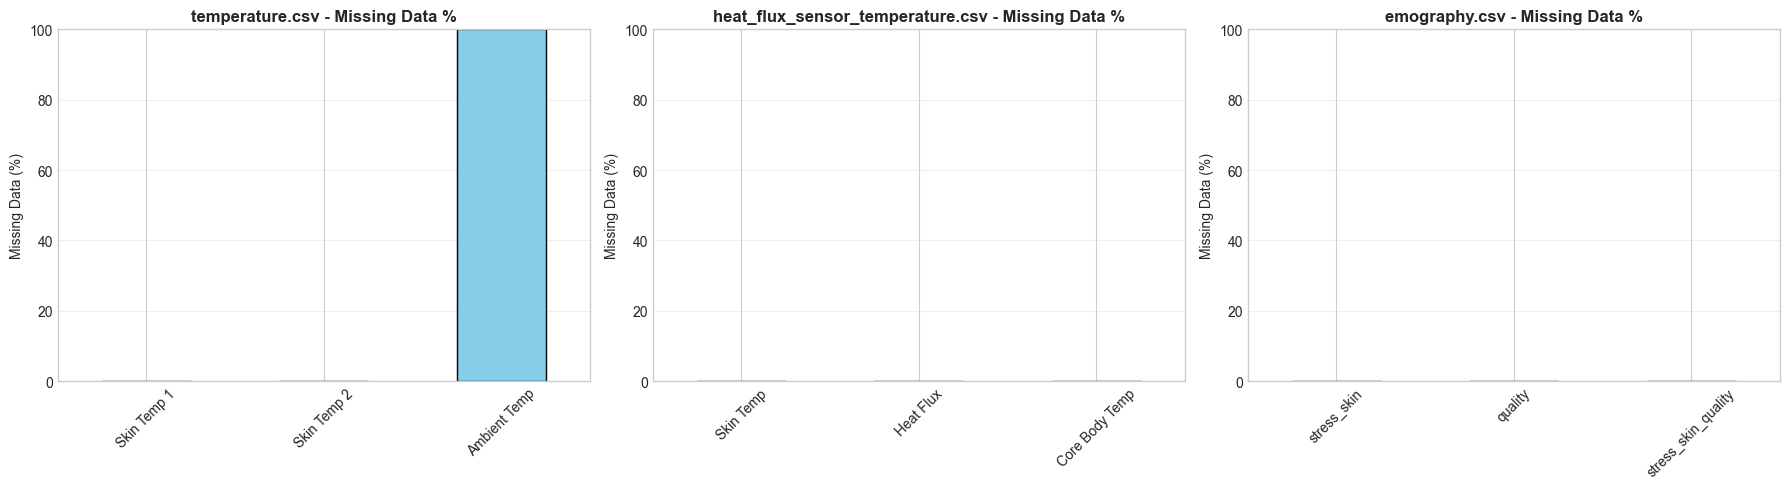

In [9]:
# Visualize missing data comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Temperature.csv missing data
if all(col in temp_df.columns for col in temp_missing_cols):
    temp_data = temp_df[temp_df['file_exists']][temp_missing_cols].mean()
    temp_data.index = ['Skin Temp 1', 'Skin Temp 2', 'Ambient Temp']
    temp_data.plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
    axes[0].set_title('temperature.csv - Missing Data %', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Missing Data (%)')
    axes[0].set_ylim(0, 100)
    axes[0].grid(axis='y', alpha=0.3)
    axes[0].tick_params(axis='x', rotation=45)

# Heat flux missing data
if all(col in heatflux_df.columns for col in hf_missing_cols):
    hf_data = heatflux_df[heatflux_df['file_exists']][hf_missing_cols].mean()
    hf_data.index = ['Skin Temp', 'Heat Flux', 'Core Body Temp']
    hf_data.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
    axes[1].set_title('heat_flux_sensor_temperature.csv - Missing Data %', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Missing Data (%)')
    axes[1].set_ylim(0, 100)
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].tick_params(axis='x', rotation=45)

# Emography missing data (top features)
if 'stress_skin_pct_missing' in emography_df.columns:
    emo_cols = ['stress_skin_pct_missing', 'quality_pct_missing', 'stress_skin_quality_pct_missing']
    emo_cols = [col for col in emo_cols if col in emography_df.columns]
    if emo_cols:
        emo_data = emography_df[emography_df['file_exists']][emo_cols].mean()
        emo_data.index = [col.replace('_pct_missing', '') for col in emo_cols]
        emo_data.plot(kind='bar', ax=axes[2], color='lightgreen', edgecolor='black')
        axes[2].set_title('emography.csv - Missing Data %', fontsize=12, fontweight='bold')
        axes[2].set_ylabel('Missing Data (%)')
        axes[2].set_ylim(0, 100)
        axes[2].grid(axis='y', alpha=0.3)
        axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# VitaStress Data Quality Analysis

## Purpose
Comprehensive quality analysis of:
1. **RR Interval Data** - Heart rate variability source
2. **Activity Data** - Derived physiological metrics with quality flags

## Outputs
- Missing data statistics per subject
- Quality flag analysis
- Sampling frequency analysis
- Physiological validity checks
- Clean data extraction

In [10]:
# Sampling intervals and gaps
print("\n" + "="*70)
print("CONTINUITY ANALYSIS")
print("="*70)

continuity_summary = pd.DataFrame({
    'Data Source': ['temperature.csv', 'heat_flux_sensor_temp.csv', 'emography.csv'],
    'Median Sampling Interval (sec)': [
        temp_df[temp_df['file_exists']]['median_sampling_interval_sec'].median(),
        heatflux_df[heatflux_df['file_exists']]['median_sampling_interval_sec'].median(),
        emography_df[emography_df['file_exists']]['median_sampling_interval_sec'].median()
    ],
    'Avg Gaps > Threshold': [
        temp_df[temp_df['file_exists']]['n_gaps_gt_10sec'].mean(),
        heatflux_df[heatflux_df['file_exists']]['n_gaps_gt_10sec'].mean(),
        emography_df[emography_df['file_exists']]['n_gaps_gt_120sec'].mean()
    ],
    'Max Gap (sec)': [
        temp_df[temp_df['file_exists']]['max_gap_sec'].max(),
        heatflux_df[heatflux_df['file_exists']]['max_gap_sec'].max(),
        emography_df[emography_df['file_exists']]['max_gap_sec'].max()
    ]
})

print(continuity_summary.round(2).to_string(index=False))
print("="*70)
print("Note: Gap thresholds - temperature & heatflux: >10sec, emography: >120sec")


CONTINUITY ANALYSIS
              Data Source  Median Sampling Interval (sec)  Avg Gaps > Threshold  Max Gap (sec)
          temperature.csv                            30.0                167.52         1179.0
heat_flux_sensor_temp.csv                             1.0                  0.14          632.0
            emography.csv                            60.0                  0.14         1233.0
Note: Gap thresholds - temperature & heatflux: >10sec, emography: >120sec


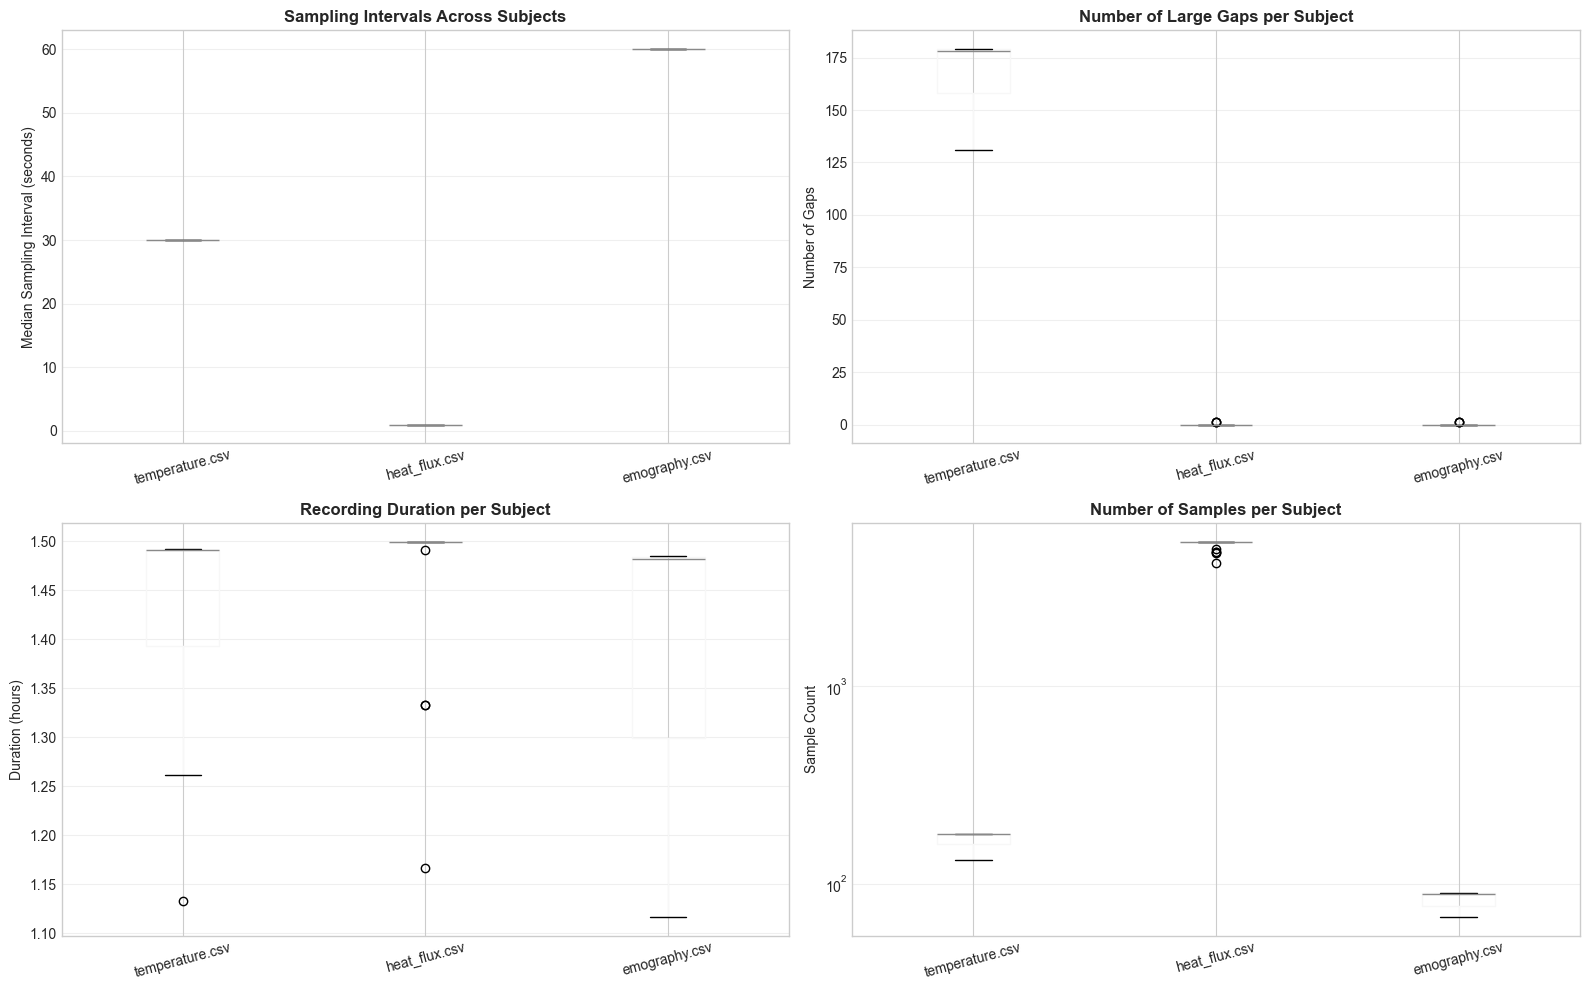

In [11]:
# Visualize sampling rates and gaps
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Sampling intervals
sampling_data = pd.DataFrame({
    'temperature.csv': temp_df[temp_df['file_exists']]['median_sampling_interval_sec'],
    'heat_flux.csv': heatflux_df[heatflux_df['file_exists']]['median_sampling_interval_sec'],
    'emography.csv': emography_df[emography_df['file_exists']]['median_sampling_interval_sec']
})

sampling_data.boxplot(ax=axes[0, 0])
axes[0, 0].set_title('Sampling Intervals Across Subjects', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Median Sampling Interval (seconds)')
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=15)

# 2. Number of gaps
gap_data = pd.DataFrame({
    'temperature.csv': temp_df[temp_df['file_exists']]['n_gaps_gt_10sec'],
    'heat_flux.csv': heatflux_df[heatflux_df['file_exists']]['n_gaps_gt_10sec'],
    'emography.csv': emography_df[emography_df['file_exists']]['n_gaps_gt_120sec']
})

gap_data.boxplot(ax=axes[0, 1])
axes[0, 1].set_title('Number of Large Gaps per Subject', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Number of Gaps')
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=15)

# 3. Recording duration
duration_data = pd.DataFrame({
    'temperature.csv': temp_df[temp_df['file_exists']]['duration_hours'],
    'heat_flux.csv': heatflux_df[heatflux_df['file_exists']]['duration_hours'],
    'emography.csv': emography_df[emography_df['file_exists']]['duration_hours']
})

duration_data.boxplot(ax=axes[1, 0])
axes[1, 0].set_title('Recording Duration per Subject', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Duration (hours)')
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=15)

# 4. Sample counts
sample_data = pd.DataFrame({
    'temperature.csv': temp_df[temp_df['file_exists']]['n_samples'],
    'heat_flux.csv': heatflux_df[heatflux_df['file_exists']]['n_samples'],
    'emography.csv': emography_df[emography_df['file_exists']]['n_samples']
})

sample_data.boxplot(ax=axes[1, 1])
axes[1, 1].set_title('Number of Samples per Subject', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Sample Count')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# VitaStress Data Quality Analysis

## Purpose
Comprehensive quality analysis of:
1. **RR Interval Data** - Heart rate variability source
2. **Activity Data** - Derived physiological metrics with quality flags

## Outputs
- Missing data statistics per subject
- Quality flag analysis
- Sampling frequency analysis
- Physiological validity checks
- Clean data extraction

In [12]:
# Physiological validity percentages
print("\n" + "="*70)
print("PHYSIOLOGICAL VALIDITY CHECK")
print("="*70)

print("\ntemperature.csv (Valid ranges - Skin: 20-42°C, Ambient: 10-50°C):")
temp_valid_cols = ['temp_sk1_pct_valid_range', 'temp_sk2_pct_valid_range', 'temp_amb_pct_valid_range']
if all(col in temp_df.columns for col in temp_valid_cols):
    validity = temp_df[temp_df['file_exists']][temp_valid_cols].describe()
    print(validity.round(2))

print("\n" + "="*70)
print("\nheat_flux_sensor_temperature.csv (Valid ranges - Skin: 20-42°C, CBT: 35-40°C, Heat flux: -50 to 200):")
hf_valid_cols = ['skin_temp_pct_valid_range', 'heatflux_pct_valid_range', 'cbt_pct_valid_range']
if all(col in heatflux_df.columns for col in hf_valid_cols):
    validity = heatflux_df[heatflux_df['file_exists']][hf_valid_cols].describe()
    print(validity.round(2))

print("\n" + "="*70)


PHYSIOLOGICAL VALIDITY CHECK

temperature.csv (Valid ranges - Skin: 20-42°C, Ambient: 10-50°C):
       temp_sk1_pct_valid_range  temp_sk2_pct_valid_range  \
count                      21.0                      21.0   
mean                      100.0                       0.0   
std                         0.0                       0.0   
min                       100.0                       0.0   
25%                       100.0                       0.0   
50%                       100.0                       0.0   
75%                       100.0                       0.0   
max                       100.0                       0.0   

       temp_amb_pct_valid_range  
count                      21.0  
mean                        0.0  
std                         0.0  
min                         0.0  
25%                         0.0  
50%                         0.0  
75%                         0.0  
max                         0.0  


heat_flux_sensor_temperature.csv (Valid range

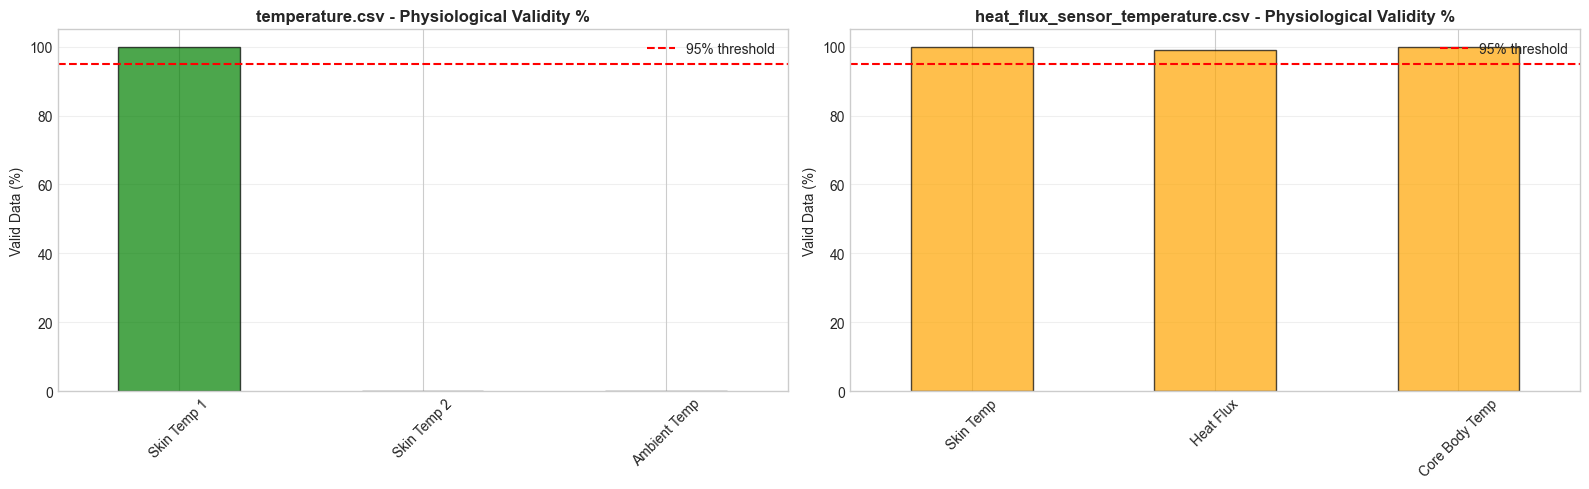

In [13]:
# Visualize validity percentages
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Temperature.csv validity
if all(col in temp_df.columns for col in temp_valid_cols):
    temp_valid_data = temp_df[temp_df['file_exists']][temp_valid_cols].mean()
    temp_valid_data.index = ['Skin Temp 1', 'Skin Temp 2', 'Ambient Temp']
    temp_valid_data.plot(kind='bar', ax=axes[0], color='green', alpha=0.7, edgecolor='black')
    axes[0].axhline(y=95, color='red', linestyle='--', label='95% threshold')
    axes[0].set_title('temperature.csv - Physiological Validity %', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Valid Data (%)')
    axes[0].set_ylim(0, 105)
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)
    axes[0].tick_params(axis='x', rotation=45)

# Heat flux validity
if all(col in heatflux_df.columns for col in hf_valid_cols):
    hf_valid_data = heatflux_df[heatflux_df['file_exists']][hf_valid_cols].mean()
    hf_valid_data.index = ['Skin Temp', 'Heat Flux', 'Core Body Temp']
    hf_valid_data.plot(kind='bar', ax=axes[1], color='orange', alpha=0.7, edgecolor='black')
    axes[1].axhline(y=95, color='red', linestyle='--', label='95% threshold')
    axes[1].set_title('heat_flux_sensor_temperature.csv - Physiological Validity %', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Valid Data (%)')
    axes[1].set_ylim(0, 105)
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# VitaStress Data Quality Analysis

## Purpose
Comprehensive quality analysis of:
1. **RR Interval Data** - Heart rate variability source
2. **Activity Data** - Derived physiological metrics with quality flags

## Outputs
- Missing data statistics per subject
- Quality flag analysis
- Sampling frequency analysis
- Physiological validity checks
- Clean data extraction

In [14]:
# Temperature distributions
print("\n" + "="*70)
print("TEMPERATURE STATISTICS")
print("="*70)

print("\ntemperature.csv:")
temp_stat_cols = ['temp_sk1_mean', 'temp_sk1_std', 'temp_sk1_min', 'temp_sk1_max',
                  'temp_sk2_mean', 'temp_sk2_std', 'temp_sk2_min', 'temp_sk2_max',
                  'temp_amb_mean', 'temp_amb_std', 'temp_amb_min', 'temp_amb_max']
available_cols = [col for col in temp_stat_cols if col in temp_df.columns]
if available_cols:
    print(temp_df[temp_df['file_exists']][available_cols].describe().round(2))

print("\n" + "="*70)
print("\nheat_flux_sensor_temperature.csv:")
hf_stat_cols = ['skin_temp_mean', 'skin_temp_std', 'skin_temp_min', 'skin_temp_max',
                'cbt_mean', 'cbt_std', 'cbt_min', 'cbt_max',
                'heatflux_mean', 'heatflux_std', 'heatflux_min', 'heatflux_max']
available_cols = [col for col in hf_stat_cols if col in heatflux_df.columns]
if available_cols:
    print(heatflux_df[heatflux_df['file_exists']][available_cols].describe().round(2))

print("\n" + "="*70)


TEMPERATURE STATISTICS

temperature.csv:
       temp_sk1_mean  temp_sk1_std  temp_sk1_min  temp_sk1_max  temp_sk2_mean  \
count          21.00         21.00         21.00         21.00            0.0   
mean           37.24          0.12         37.06         37.43            NaN   
std             0.17          0.07          0.16          0.21            NaN   
min            36.92          0.04         36.83         37.08            NaN   
25%            37.15          0.07         36.93         37.31            NaN   
50%            37.21          0.09         37.07         37.41            NaN   
75%            37.33          0.15         37.16         37.49            NaN   
max            37.71          0.36         37.37         37.98            NaN   

       temp_sk2_std  temp_sk2_min  temp_sk2_max  temp_amb_mean  temp_amb_std  \
count           0.0           0.0           0.0            0.0           0.0   
mean            NaN           NaN           NaN            NaN      

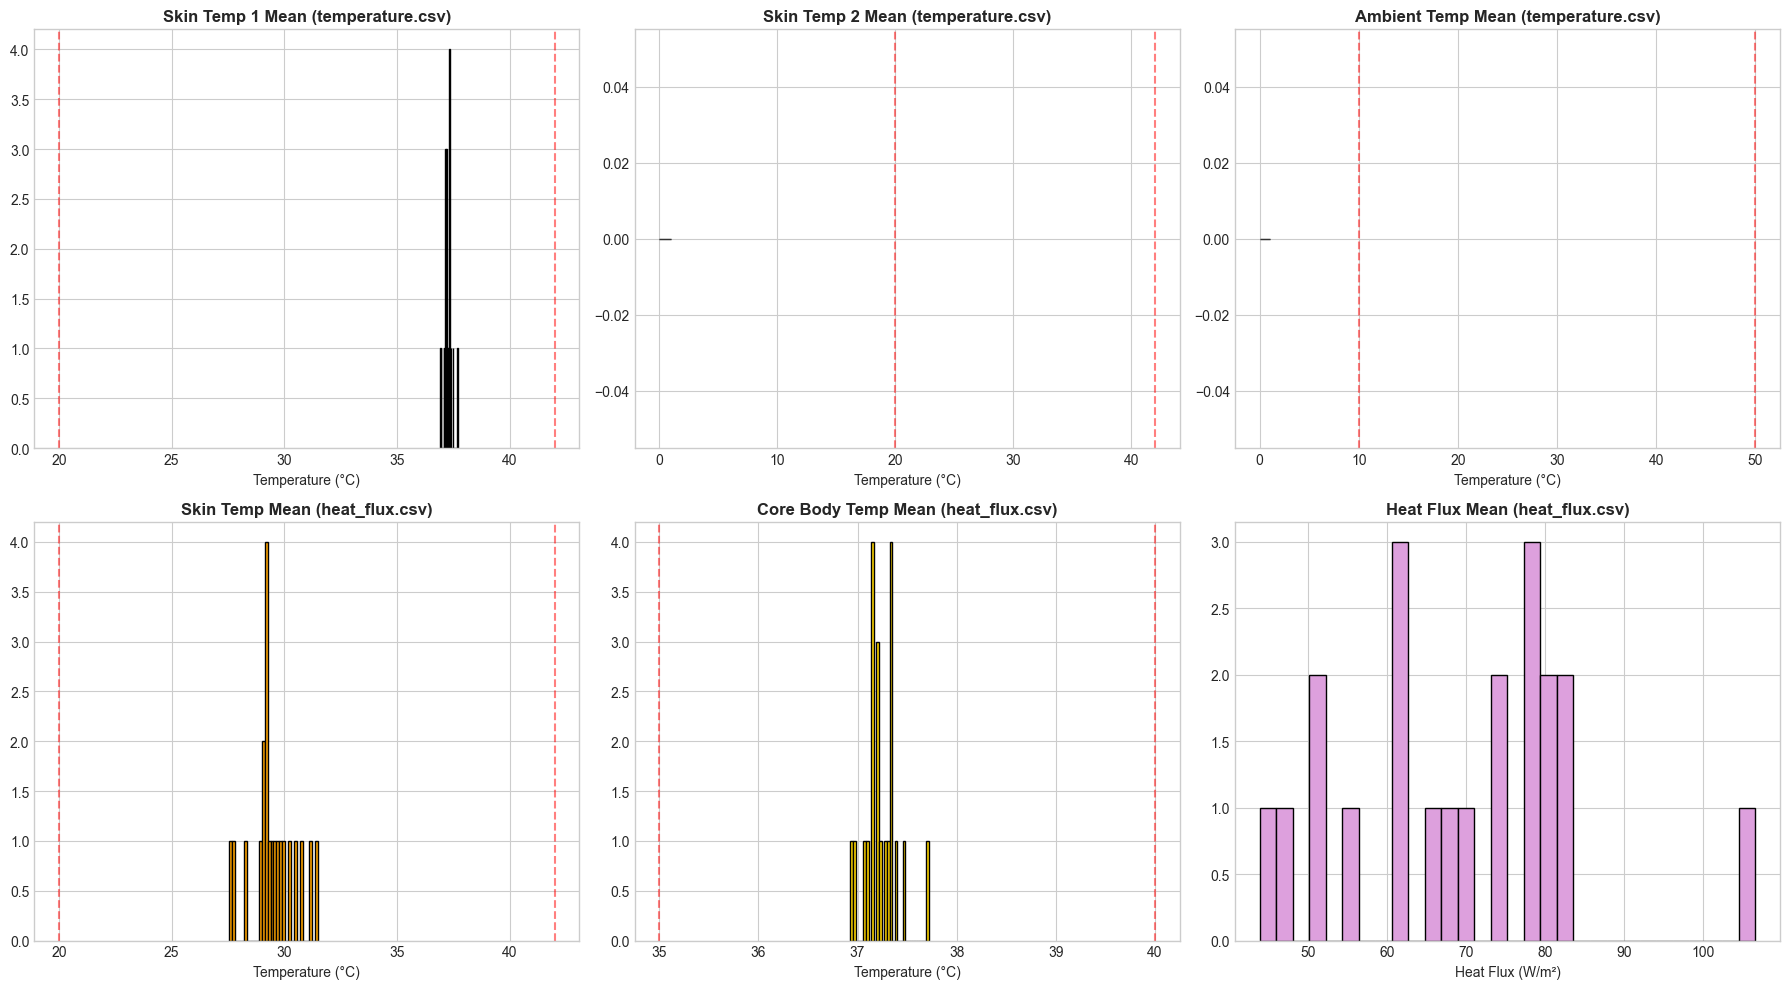

Note: Red dashed lines indicate physiological validity boundaries


In [15]:
# Visualize temperature distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Temperature.csv distributions
if 'temp_sk1_mean' in temp_df.columns:
    temp_df[temp_df['file_exists']]['temp_sk1_mean'].hist(bins=30, ax=axes[0, 0], color='skyblue', edgecolor='black')
    axes[0, 0].set_title('Skin Temp 1 Mean (temperature.csv)', fontweight='bold')
    axes[0, 0].set_xlabel('Temperature (°C)')
    axes[0, 0].axvline(x=20, color='r', linestyle='--', alpha=0.5)
    axes[0, 0].axvline(x=42, color='r', linestyle='--', alpha=0.5)
    
if 'temp_sk2_mean' in temp_df.columns:
    temp_df[temp_df['file_exists']]['temp_sk2_mean'].hist(bins=30, ax=axes[0, 1], color='lightcoral', edgecolor='black')
    axes[0, 1].set_title('Skin Temp 2 Mean (temperature.csv)', fontweight='bold')
    axes[0, 1].set_xlabel('Temperature (°C)')
    axes[0, 1].axvline(x=20, color='r', linestyle='--', alpha=0.5)
    axes[0, 1].axvline(x=42, color='r', linestyle='--', alpha=0.5)

if 'temp_amb_mean' in temp_df.columns:
    temp_df[temp_df['file_exists']]['temp_amb_mean'].hist(bins=30, ax=axes[0, 2], color='lightgreen', edgecolor='black')
    axes[0, 2].set_title('Ambient Temp Mean (temperature.csv)', fontweight='bold')
    axes[0, 2].set_xlabel('Temperature (°C)')
    axes[0, 2].axvline(x=10, color='r', linestyle='--', alpha=0.5)
    axes[0, 2].axvline(x=50, color='r', linestyle='--', alpha=0.5)

# Heat flux distributions
if 'skin_temp_mean' in heatflux_df.columns:
    heatflux_df[heatflux_df['file_exists']]['skin_temp_mean'].hist(bins=30, ax=axes[1, 0], color='orange', edgecolor='black')
    axes[1, 0].set_title('Skin Temp Mean (heat_flux.csv)', fontweight='bold')
    axes[1, 0].set_xlabel('Temperature (°C)')
    axes[1, 0].axvline(x=20, color='r', linestyle='--', alpha=0.5)
    axes[1, 0].axvline(x=42, color='r', linestyle='--', alpha=0.5)

if 'cbt_mean' in heatflux_df.columns:
    heatflux_df[heatflux_df['file_exists']]['cbt_mean'].hist(bins=30, ax=axes[1, 1], color='gold', edgecolor='black')
    axes[1, 1].set_title('Core Body Temp Mean (heat_flux.csv)', fontweight='bold')
    axes[1, 1].set_xlabel('Temperature (°C)')
    axes[1, 1].axvline(x=35, color='r', linestyle='--', alpha=0.5)
    axes[1, 1].axvline(x=40, color='r', linestyle='--', alpha=0.5)

if 'heatflux_mean' in heatflux_df.columns:
    heatflux_df[heatflux_df['file_exists']]['heatflux_mean'].hist(bins=30, ax=axes[1, 2], color='plum', edgecolor='black')
    axes[1, 2].set_title('Heat Flux Mean (heat_flux.csv)', fontweight='bold')
    axes[1, 2].set_xlabel('Heat Flux (W/m²)')

plt.tight_layout()
plt.show()

print("Note: Red dashed lines indicate physiological validity boundaries")

# VitaStress Data Quality Analysis

## Purpose
Comprehensive quality analysis of:
1. **RR Interval Data** - Heart rate variability source
2. **Activity Data** - Derived physiological metrics with quality flags

## Outputs
- Missing data statistics per subject
- Quality flag analysis
- Sampling frequency analysis
- Physiological validity checks
- Clean data extraction

In [16]:
# Compare skin temperature across sources
print("\n" + "="*70)
print("CROSS-SOURCE SKIN TEMPERATURE COMPARISON")
print("="*70)

# Merge temperature data from both sources
comparison_data = []

for subject_folder in subjects:
    subject_id = subject_folder.name.replace("id_", "")
    
    # Get temp_sk1 from temperature.csv
    temp_result = temp_df[temp_df['subject_id'] == subject_id]
    if len(temp_result) > 0 and temp_result['file_exists'].iloc[0]:
        temp_sk1 = temp_result['temp_sk1_mean'].iloc[0] if 'temp_sk1_mean' in temp_result.columns else np.nan
        temp_sk1_missing = temp_result['temp_sk1_pct_missing'].iloc[0] if 'temp_sk1_pct_missing' in temp_result.columns else np.nan
    else:
        temp_sk1 = np.nan
        temp_sk1_missing = np.nan
    
    # Get skin_temp from heat_flux_sensor_temperature.csv
    hf_result = heatflux_df[heatflux_df['subject_id'] == subject_id]
    if len(hf_result) > 0 and hf_result['file_exists'].iloc[0]:
        skin_temp = hf_result['skin_temp_mean'].iloc[0] if 'skin_temp_mean' in hf_result.columns else np.nan
        skin_temp_missing = hf_result['skin_temp_pct_missing'].iloc[0] if 'skin_temp_pct_missing' in hf_result.columns else np.nan
    else:
        skin_temp = np.nan
        skin_temp_missing = np.nan
    
    comparison_data.append({
        'subject_id': subject_id,
        'temp_sk1_mean': temp_sk1,
        'temp_sk1_pct_missing': temp_sk1_missing,
        'heatflux_skin_temp_mean': skin_temp,
        'heatflux_skin_temp_pct_missing': skin_temp_missing
    })

comparison_df = pd.DataFrame(comparison_data)

# Calculate correlation between the two skin temperature measurements
valid_comparison = comparison_df.dropna(subset=['temp_sk1_mean', 'heatflux_skin_temp_mean'])
if len(valid_comparison) > 0:
    correlation = valid_comparison['temp_sk1_mean'].corr(valid_comparison['heatflux_skin_temp_mean'])
    print(f"\nCorrelation between temp_sk1 (temperature.csv) and skin_temp (heat_flux.csv): {correlation:.3f}")
    print(f"Number of subjects with both measurements: {len(valid_comparison)} / {len(subjects)}")
    
    # Temperature difference
    valid_comparison['temp_diff'] = valid_comparison['heatflux_skin_temp_mean'] - valid_comparison['temp_sk1_mean']
    print(f"\nMean difference (heat_flux - temperature.csv): {valid_comparison['temp_diff'].mean():.2f} ± {valid_comparison['temp_diff'].std():.2f} °C")
    print(f"Median difference: {valid_comparison['temp_diff'].median():.2f} °C")
    print(f"Range: [{valid_comparison['temp_diff'].min():.2f}, {valid_comparison['temp_diff'].max():.2f}] °C")

print("\n" + "="*70)


CROSS-SOURCE SKIN TEMPERATURE COMPARISON

Correlation between temp_sk1 (temperature.csv) and skin_temp (heat_flux.csv): 0.211
Number of subjects with both measurements: 21 / 21

Mean difference (heat_flux - temperature.csv): -7.74 ± 0.98 °C
Median difference: -7.77 °C
Range: [-9.66, -5.84] °C



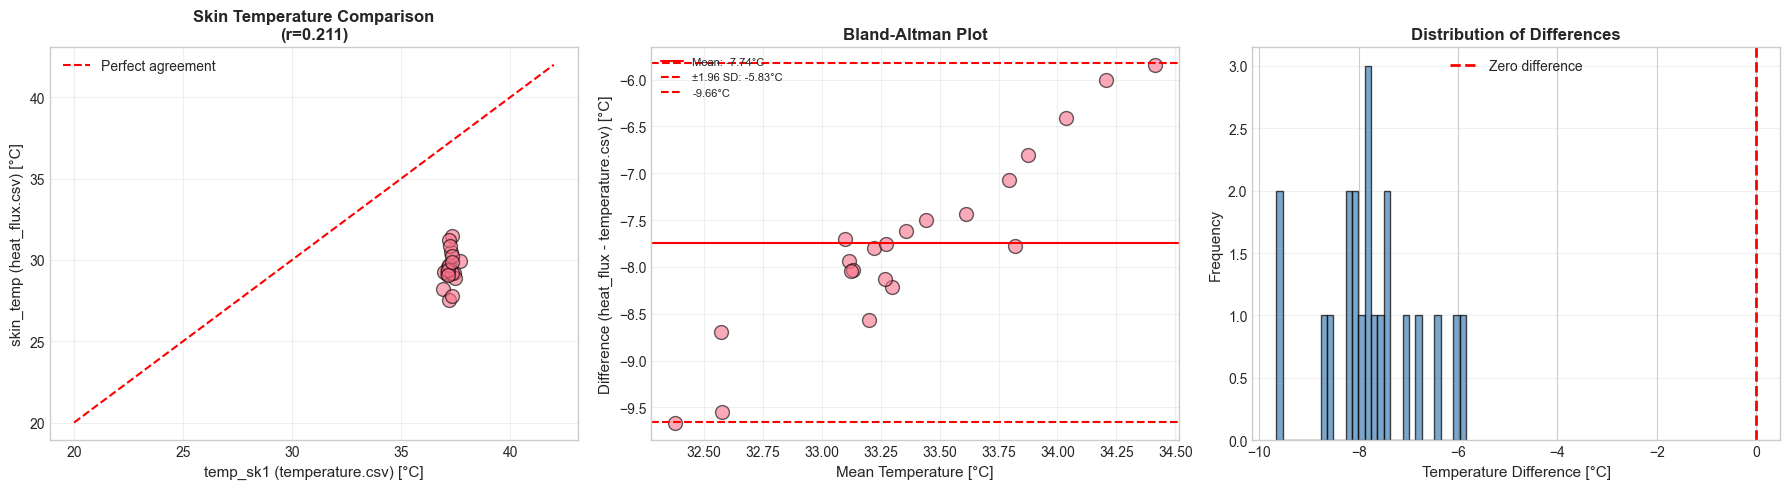

In [18]:
# Visualize cross-source comparison
if len(valid_comparison) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Scatter plot: temp_sk1 vs skin_temp
    axes[0].scatter(valid_comparison['temp_sk1_mean'], 
                    valid_comparison['heatflux_skin_temp_mean'], 
                    alpha=0.6, s=100, edgecolor='black')
    axes[0].plot([20, 42], [20, 42], 'r--', label='Perfect agreement')
    axes[0].set_xlabel('temp_sk1 (temperature.csv) [°C]', fontsize=11)
    axes[0].set_ylabel('skin_temp (heat_flux.csv) [°C]', fontsize=11)
    axes[0].set_title(f'Skin Temperature Comparison\n(r={correlation:.3f})', fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Bland-Altman plot
    mean_temp = (valid_comparison['temp_sk1_mean'] + valid_comparison['heatflux_skin_temp_mean']) / 2
    diff_temp = valid_comparison['temp_diff']
    
    axes[1].scatter(mean_temp, diff_temp, alpha=0.6, s=100, edgecolor='black')
    axes[1].axhline(y=diff_temp.mean(), color='r', linestyle='-', label=f'Mean: {diff_temp.mean():.2f}°C')
    axes[1].axhline(y=diff_temp.mean() + 1.96*diff_temp.std(), color='r', linestyle='--', 
                    label=f'±1.96 SD: {diff_temp.mean() + 1.96*diff_temp.std():.2f}°C')
    axes[1].axhline(y=diff_temp.mean() - 1.96*diff_temp.std(), color='r', linestyle='--',
                    label=f'{diff_temp.mean() - 1.96*diff_temp.std():.2f}°C')
    axes[1].set_xlabel('Mean Temperature [°C]', fontsize=11)
    axes[1].set_ylabel('Difference (heat_flux - temperature.csv) [°C]', fontsize=11)
    axes[1].set_title('Bland-Altman Plot', fontweight='bold')
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.3)
    
    # Histogram of differences
    axes[2].hist(diff_temp, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[2].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero difference')
    axes[2].set_xlabel('Temperature Difference [°C]', fontsize=11)
    axes[2].set_ylabel('Frequency', fontsize=11)
    axes[2].set_title('Distribution of Differences', fontweight='bold')
    axes[2].legend()
    axes[2].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("Not enough valid data for cross-source comparison visualization")

# VitaStress Data Quality Analysis

## Purpose
Comprehensive quality analysis of:
1. **RR Interval Data** - Heart rate variability source
2. **Activity Data** - Derived physiological metrics with quality flags

## Outputs
- Missing data statistics per subject
- Quality flag analysis
- Sampling frequency analysis
- Physiological validity checks
- Clean data extraction

In [20]:
def calculate_quality_score(row, source_type):
    """
    Calculate a quality score (0-100) based on multiple factors:
    - File existence (40 points)
    - Low missing data (30 points)
    - Good continuity (15 points)
    - Physiological validity (15 points)
    """
    score = 0
    
    # File exists
    if row.get('file_exists', False):
        score += 40
    else:
        return 0  # Can't evaluate quality if file doesn't exist
    
    # Missing data score (30 points max)
    if source_type == 'temperature':
        missing_cols = ['temp_sk1_pct_missing', 'temp_sk2_pct_missing', 'temp_amb_pct_missing']
    elif source_type == 'heatflux':
        missing_cols = ['skin_temp_pct_missing', 'heatflux_pct_missing', 'cbt_pct_missing']
    else:  # emography
        missing_cols = ['stress_skin_pct_missing', 'quality_pct_missing']
    
    missing_vals = [row.get(col, 100) for col in missing_cols if col in row]
    if missing_vals:
        avg_missing = np.mean([v for v in missing_vals if not np.isnan(v)])
        # Less missing is better: 0% missing = 30 points, 100% missing = 0 points
        score += max(0, 30 * (1 - avg_missing / 100))
    
    # Continuity score (15 points max)
    gap_col = 'n_gaps_gt_10sec' if source_type != 'emography' else 'n_gaps_gt_120sec'
    if gap_col in row and not np.isnan(row[gap_col]):
        # Fewer gaps is better: 0 gaps = 15 points, >50 gaps = 0 points
        score += max(0, 15 * (1 - min(row[gap_col], 50) / 50))
    
    # Validity score (15 points max)
    if source_type == 'temperature':
        valid_cols = ['temp_sk1_pct_valid_range', 'temp_sk2_pct_valid_range', 'temp_amb_pct_valid_range']
    elif source_type == 'heatflux':
        valid_cols = ['skin_temp_pct_valid_range', 'heatflux_pct_valid_range', 'cbt_pct_valid_range']
    else:
        return score  # No validity check for emography
    
    valid_vals = [row.get(col, 0) for col in valid_cols if col in row]
    if valid_vals:
        avg_valid = np.mean([v for v in valid_vals if not np.isnan(v)])
        # Higher validity is better: 100% valid = 15 points
        score += max(0, 15 * (avg_valid / 100))
    
    return score

# Calculate quality scores
temp_df['quality_score'] = temp_df.apply(lambda row: calculate_quality_score(row, 'temperature'), axis=1)
heatflux_df['quality_score'] = heatflux_df.apply(lambda row: calculate_quality_score(row, 'heatflux'), axis=1)
emography_df['quality_score'] = emography_df.apply(lambda row: calculate_quality_score(row, 'emography'), axis=1)

# Summary
print("\n" + "="*70)
print("DATA QUALITY SCORES (0-100)")
print("="*70)

quality_summary = pd.DataFrame({
    'Data Source': ['temperature.csv', 'heat_flux_sensor_temp.csv', 'emography.csv'],
    'Mean Score': [
        temp_df['quality_score'].mean(),
        heatflux_df['quality_score'].mean(),
        emography_df['quality_score'].mean()
    ],
    'Median Score': [
        temp_df['quality_score'].median(),
        heatflux_df['quality_score'].median(),
        emography_df['quality_score'].median()
    ],
    'Std Dev': [
        temp_df['quality_score'].std(),
        heatflux_df['quality_score'].std(),
        emography_df['quality_score'].std()
    ],
    'Min Score': [
        temp_df['quality_score'].min(),
        heatflux_df['quality_score'].min(),
        emography_df['quality_score'].min()
    ],
    'Max Score': [
        temp_df['quality_score'].max(),
        heatflux_df['quality_score'].max(),
        emography_df['quality_score'].max()
    ]
})

print(quality_summary.round(2).to_string(index=False))
print("="*70)
print("\nScore Components:")
print("  - File existence: 40 points")
print("  - Low missing data: 30 points")
print("  - Good continuity: 15 points")
print("  - Physiological validity: 15 points")


DATA QUALITY SCORES (0-100)
              Data Source  Mean Score  Median Score  Std Dev  Min Score  Max Score
          temperature.csv       65.00         65.00     0.00      65.00       65.0
heat_flux_sensor_temp.csv       99.91         99.94     0.10      99.68      100.0
            emography.csv       84.96         85.00     0.11      84.70       85.0

Score Components:
  - File existence: 40 points
  - Low missing data: 30 points
  - Good continuity: 15 points
  - Physiological validity: 15 points


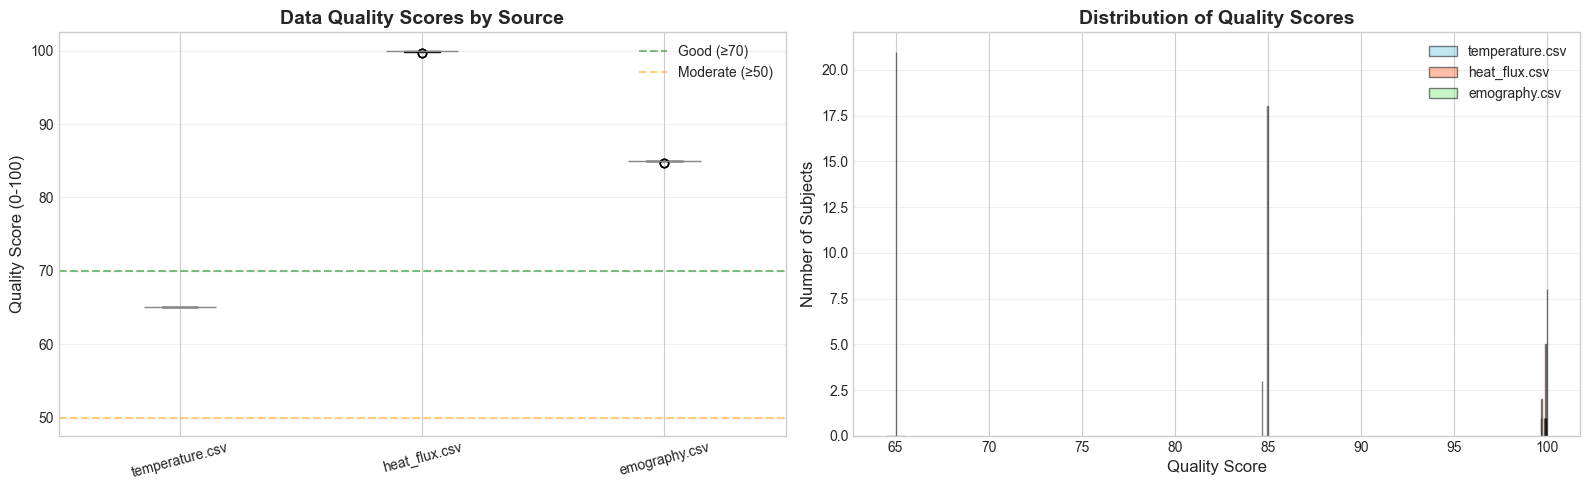

In [21]:
# Visualize quality scores
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Box plot comparison
quality_data = pd.DataFrame({
    'temperature.csv': temp_df['quality_score'],
    'heat_flux.csv': heatflux_df['quality_score'],
    'emography.csv': emography_df['quality_score']
})

quality_data.boxplot(ax=axes[0])
axes[0].set_title('Data Quality Scores by Source', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Quality Score (0-100)', fontsize=12)
axes[0].axhline(y=70, color='green', linestyle='--', alpha=0.5, label='Good (≥70)')
axes[0].axhline(y=50, color='orange', linestyle='--', alpha=0.5, label='Moderate (≥50)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=15)

# Distribution of quality scores
axes[1].hist(temp_df['quality_score'], bins=20, alpha=0.5, label='temperature.csv', color='skyblue', edgecolor='black')
axes[1].hist(heatflux_df['quality_score'], bins=20, alpha=0.5, label='heat_flux.csv', color='coral', edgecolor='black')
axes[1].hist(emography_df['quality_score'], bins=20, alpha=0.5, label='emography.csv', color='lightgreen', edgecolor='black')
axes[1].set_xlabel('Quality Score', fontsize=12)
axes[1].set_ylabel('Number of Subjects', fontsize=12)
axes[1].set_title('Distribution of Quality Scores', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# VitaStress Data Quality Analysis

## Purpose
Comprehensive quality analysis of:
1. **RR Interval Data** - Heart rate variability source
2. **Activity Data** - Derived physiological metrics with quality flags

## Outputs
- Missing data statistics per subject
- Quality flag analysis
- Sampling frequency analysis
- Physiological validity checks
- Clean data extraction

In [22]:
# Create comprehensive per-subject report
subject_report = pd.DataFrame({
    'subject_id': temp_df['subject_id'],
    'temp_exists': temp_df['file_exists'],
    'temp_quality': temp_df['quality_score'].round(1),
    'temp_sk1_missing%': temp_df.get('temp_sk1_pct_missing', np.nan).round(1),
    'heatflux_exists': heatflux_df['file_exists'],
    'heatflux_quality': heatflux_df['quality_score'].round(1),
    'skin_temp_missing%': heatflux_df.get('skin_temp_pct_missing', np.nan).round(1),
    'emography_exists': emography_df['file_exists'],
    'emography_quality': emography_df['quality_score'].round(1),
})

# Shorten subject IDs for readability
subject_report['subject_short'] = subject_report['subject_id'].str[:8] + '...'

# Sort by overall quality (average of available scores)
subject_report['avg_quality'] = subject_report[['temp_quality', 'heatflux_quality', 'emography_quality']].mean(axis=1)
subject_report = subject_report.sort_values('avg_quality', ascending=False)

print("\n" + "="*100)
print("PER-SUBJECT DATA QUALITY REPORT (Top 10 Best Quality)")
print("="*100)
print(subject_report[['subject_short', 'temp_exists', 'temp_quality', 'temp_sk1_missing%', 
                       'heatflux_exists', 'heatflux_quality', 'skin_temp_missing%',
                       'emography_exists', 'emography_quality']].head(10).to_string(index=False))

print("\n" + "="*100)
print("PER-SUBJECT DATA QUALITY REPORT (Bottom 10 Worst Quality)")
print("="*100)
print(subject_report[['subject_short', 'temp_exists', 'temp_quality', 'temp_sk1_missing%',
                       'heatflux_exists', 'heatflux_quality', 'skin_temp_missing%',
                       'emography_exists', 'emography_quality']].tail(10).to_string(index=False))
print("="*100)


PER-SUBJECT DATA QUALITY REPORT (Top 10 Best Quality)
subject_short  temp_exists  temp_quality  temp_sk1_missing%  heatflux_exists  heatflux_quality  skin_temp_missing%  emography_exists  emography_quality
  87bf2ae1...         True          65.0                0.0             True             100.0                 0.0              True               85.0
  3f27501c...         True          65.0                0.0             True             100.0                 0.0              True               85.0
  c5a60768...         True          65.0                0.0             True             100.0                 0.0              True               85.0
  a360c459...         True          65.0                0.0             True             100.0                 0.0              True               85.0
  937503f7...         True          65.0                0.0             True             100.0                 0.0              True               85.0
  7bb4dafd...         True       

# VitaStress Data Quality Analysis

## Purpose
Comprehensive quality analysis of:
1. **RR Interval Data** - Heart rate variability source
2. **Activity Data** - Derived physiological metrics with quality flags

## Outputs
- Missing data statistics per subject
- Quality flag analysis
- Sampling frequency analysis
- Physiological validity checks
- Clean data extraction

In [23]:
# Generate recommendations based on analysis
print("\n" + "="*100)
print("RECOMMENDATIONS FOR DATA USAGE")
print("="*100)

# Find subjects with good quality across all sources
good_subjects = subject_report[
    (subject_report['temp_quality'] >= 70) & 
    (subject_report['heatflux_quality'] >= 70) &
    (subject_report['emography_quality'] >= 70)
]

print(f"\n1. HIGH QUALITY SUBJECTS (Quality ≥70 for all sources):")
print(f"   Count: {len(good_subjects)} subjects")
if len(good_subjects) > 0:
    print(f"   Subject IDs: {', '.join(good_subjects['subject_short'].values)}")

# Find subjects with at least one good source
partial_subjects = subject_report[
    ((subject_report['temp_quality'] >= 70) | 
     (subject_report['heatflux_quality'] >= 70) |
     (subject_report['emography_quality'] >= 70)) &
    ~subject_report['subject_id'].isin(good_subjects['subject_id'])
]

print(f"\n2. PARTIAL QUALITY SUBJECTS (At least one source ≥70):")
print(f"   Count: {len(partial_subjects)} subjects")

# Identify problematic subjects
poor_subjects = subject_report[subject_report['avg_quality'] < 50]
print(f"\n3. LOW QUALITY SUBJECTS (Average quality <50):")
print(f"   Count: {len(poor_subjects)} subjects")
print(f"   Consider excluding from analysis or using only high-quality modalities")

# Temperature source comparison
print(f"\n4. TEMPERATURE SOURCE COMPARISON:")
temp_avg = temp_df['quality_score'].mean()
heatflux_avg = heatflux_df['quality_score'].mean()
print(f"   temperature.csv average quality: {temp_avg:.1f}")
print(f"   heat_flux_sensor_temperature.csv average quality: {heatflux_avg:.1f}")

if heatflux_avg > temp_avg:
    print(f"   → Recommendation: Prefer heat_flux_sensor_temperature.csv (skin_temp) for temperature features")
else:
    print(f"   → Recommendation: Prefer temperature.csv (temp_sk1) for temperature features")

# Missing data patterns
print(f"\n5. MISSING DATA HANDLING:")
if 'temp_sk2_pct_missing' in temp_df.columns:
    temp_sk2_missing = temp_df[temp_df['file_exists']]['temp_sk2_pct_missing'].mean()
    if temp_sk2_missing > 50:
        print(f"   ⚠️  temp_sk2 has high missing rate ({temp_sk2_missing:.1f}%) - consider using temp_sk1 instead")

if 'cbt_pct_missing' in heatflux_df.columns:
    cbt_missing = heatflux_df[heatflux_df['file_exists']]['cbt_pct_missing'].mean()
    if cbt_missing > 30:
        print(f"   ⚠️  Core body temperature (cbt) has high missing rate ({cbt_missing:.1f}%)")

print("\n" + "="*100)


RECOMMENDATIONS FOR DATA USAGE

1. HIGH QUALITY SUBJECTS (Quality ≥70 for all sources):
   Count: 0 subjects

2. PARTIAL QUALITY SUBJECTS (At least one source ≥70):
   Count: 21 subjects

3. LOW QUALITY SUBJECTS (Average quality <50):
   Count: 0 subjects
   Consider excluding from analysis or using only high-quality modalities

4. TEMPERATURE SOURCE COMPARISON:
   temperature.csv average quality: 65.0
   heat_flux_sensor_temperature.csv average quality: 99.9
   → Recommendation: Prefer heat_flux_sensor_temperature.csv (skin_temp) for temperature features

5. MISSING DATA HANDLING:



In [24]:
# Export results to CSV for later use
output_dir = PROJECT_ROOT / "reports"
output_dir.mkdir(exist_ok=True)

# Save detailed results
temp_df.to_csv(output_dir / "temperature_quality_analysis.csv", index=False)
heatflux_df.to_csv(output_dir / "heatflux_quality_analysis.csv", index=False)
emography_df.to_csv(output_dir / "emography_quality_analysis.csv", index=False)
subject_report.to_csv(output_dir / "subject_quality_summary.csv", index=False)

print("\n✅ Quality analysis results saved to:")
print(f"   - {output_dir / 'temperature_quality_analysis.csv'}")
print(f"   - {output_dir / 'heatflux_quality_analysis.csv'}")
print(f"   - {output_dir / 'emography_quality_analysis.csv'}")
print(f"   - {output_dir / 'subject_quality_summary.csv'}")

# Save high-quality subject list
high_quality_subjects = good_subjects['subject_id'].tolist()
with open(output_dir / "high_quality_subjects.txt", 'w') as f:
    for subject in high_quality_subjects:
        f.write(f"{subject}\n")

print(f"\n✅ High-quality subject list saved to:")
print(f"   - {output_dir / 'high_quality_subjects.txt'}")
print(f"\nTotal files saved: 5")


✅ Quality analysis results saved to:
   - /Users/jithuazeez/Documents/Msc/Dissertation/reports/temperature_quality_analysis.csv
   - /Users/jithuazeez/Documents/Msc/Dissertation/reports/heatflux_quality_analysis.csv
   - /Users/jithuazeez/Documents/Msc/Dissertation/reports/emography_quality_analysis.csv
   - /Users/jithuazeez/Documents/Msc/Dissertation/reports/subject_quality_summary.csv

✅ High-quality subject list saved to:
   - /Users/jithuazeez/Documents/Msc/Dissertation/reports/high_quality_subjects.txt

Total files saved: 5


# VitaStress Data Quality Analysis

## Purpose
Comprehensive quality analysis of:
1. **RR Interval Data** - Heart rate variability source
2. **Activity Data** - Derived physiological metrics with quality flags

## Outputs
- Missing data statistics per subject
- Quality flag analysis
- Sampling frequency analysis
- Physiological validity checks
- Clean data extraction

In [25]:
# Select the best quality subject for visualization
if len(good_subjects) > 0:
    best_subject_id = good_subjects.iloc[0]['subject_id']
else:
    best_subject_id = subject_report.iloc[0]['subject_id']

print(f"Loading data for subject: {best_subject_id[:20]}...")

# Load all three data sources
subject_folder = DATA_PATH / f"id_{best_subject_id}"

# Temperature.csv
temp_file = subject_folder / f"{best_subject_id}_temperature.csv"
if temp_file.exists():
    temp_data = pd.read_csv(temp_file)
    temp_data['timestamp'] = pd.to_datetime(temp_data['date'], format='ISO8601')
    print(f"✓ temperature.csv: {len(temp_data)} samples")
else:
    temp_data = None
    print("✗ temperature.csv not found")

# Heat flux
hf_file = subject_folder / f"{best_subject_id}_heat_flux_sensor_temperature.csv"
if hf_file.exists():
    hf_data = pd.read_csv(hf_file)
    hf_data['timestamp'] = pd.to_datetime(hf_data['date'], format='ISO8601')
    print(f"✓ heat_flux_sensor_temperature.csv: {len(hf_data)} samples")
else:
    hf_data = None
    print("✗ heat_flux_sensor_temperature.csv not found")

# Emography
emo_file = subject_folder / f"{best_subject_id}_emography.csv"
if emo_file.exists():
    emo_data = pd.read_csv(emo_file)
    emo_data['timestamp'] = pd.to_datetime(emo_data['date'], format='ISO8601')
    print(f"✓ emography.csv: {len(emo_data)} samples")
else:
    emo_data = None
    print("✗ emography.csv not found")

Loading data for subject: 87bf2ae1-0139-4d6e-b...
✓ temperature.csv: 180 samples
✓ heat_flux_sensor_temperature.csv: 5395 samples
✓ emography.csv: 90 samples


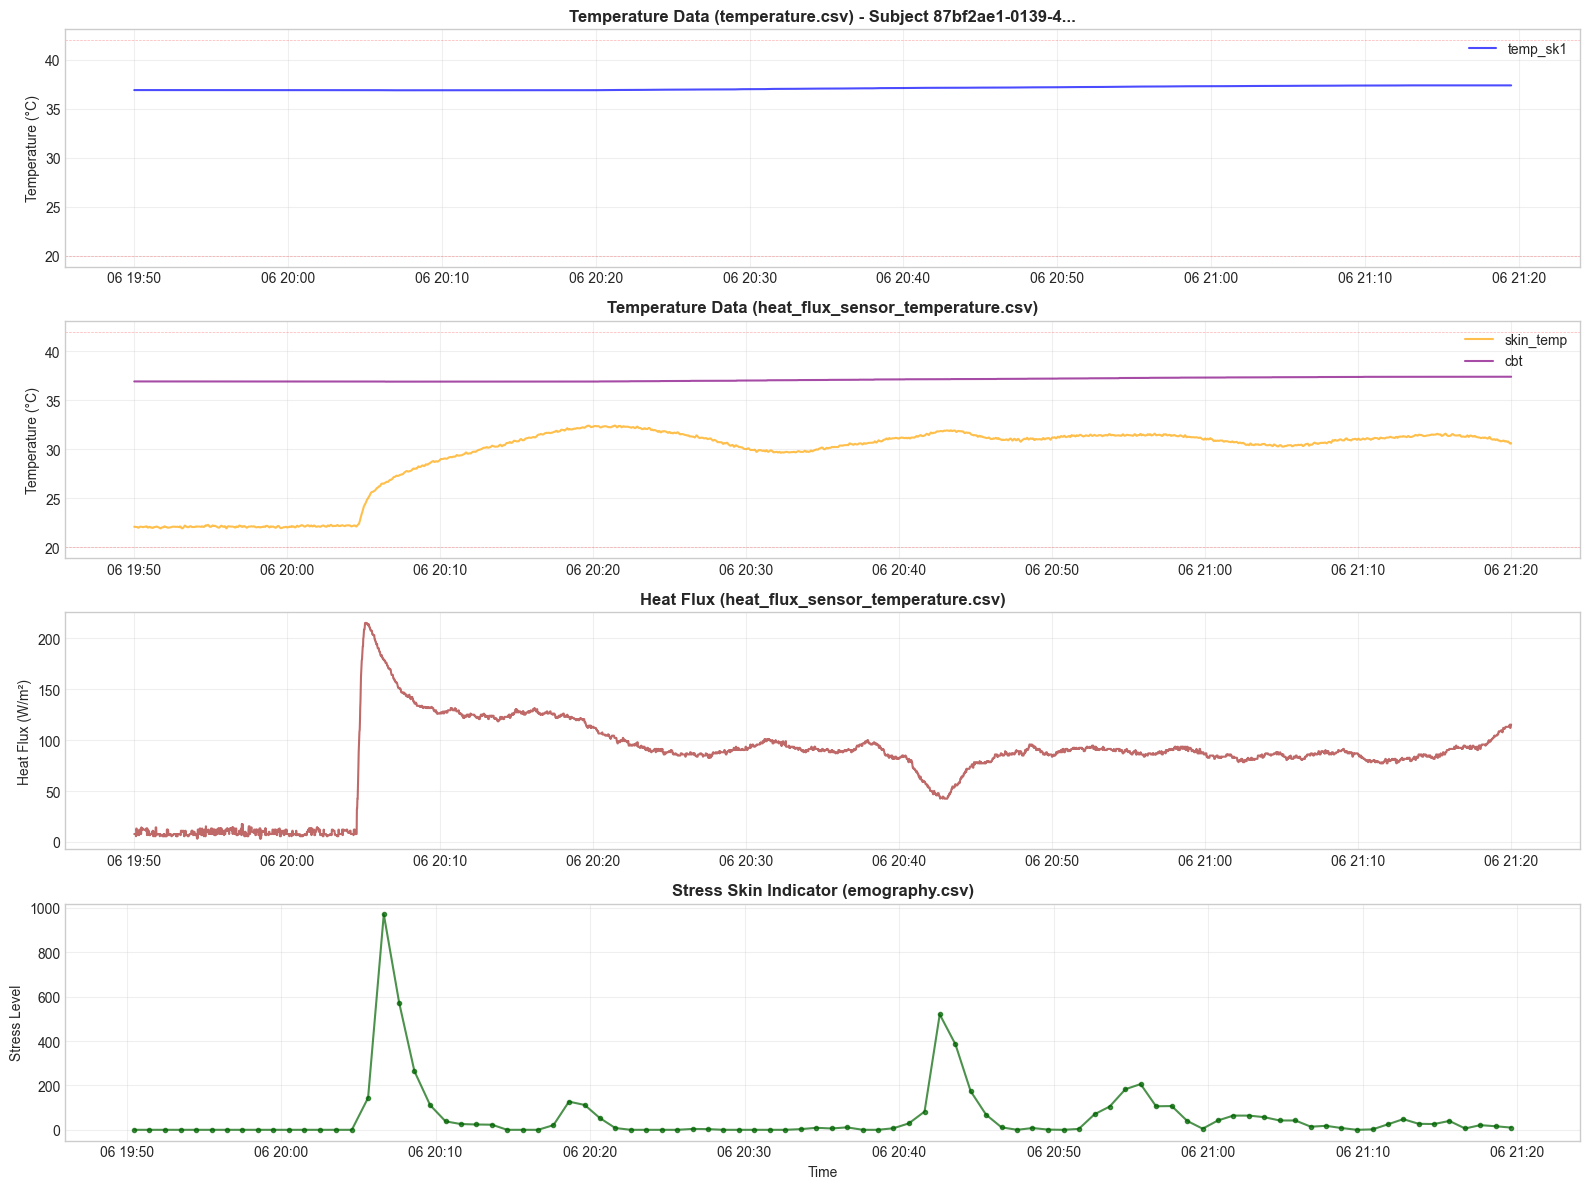


✅ Visualization complete for subject: 87bf2ae1-0139-4d6e-b...


In [26]:
# Visualize time series for the selected subject
fig, axes = plt.subplots(4, 1, figsize=(16, 12))

# Plot 1: Temperature.csv sensors
if temp_data is not None:
    for col, color in [('temp_sk1', 'blue'), ('temp_sk2', 'red'), ('temp_amb', 'green')]:
        if col in temp_data.columns:
            values = pd.to_numeric(temp_data[col], errors='coerce')
            valid_data = temp_data[values > 0].copy()
            if len(valid_data) > 0:
                axes[0].plot(valid_data['timestamp'], valid_data[col], label=col, alpha=0.7, color=color)
    
    axes[0].set_title(f'Temperature Data (temperature.csv) - Subject {best_subject_id[:15]}...', 
                      fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Temperature (°C)')
    axes[0].legend(loc='upper right')
    axes[0].grid(alpha=0.3)
    axes[0].axhline(y=20, color='red', linestyle='--', alpha=0.3, linewidth=0.5)
    axes[0].axhline(y=42, color='red', linestyle='--', alpha=0.3, linewidth=0.5)

# Plot 2: Heat flux sensor - temperatures
if hf_data is not None:
    for col, color in [('skin_temp', 'orange'), ('cbt', 'purple')]:
        if col in hf_data.columns:
            values = pd.to_numeric(hf_data[col], errors='coerce')
            valid_data = hf_data[values > 0].copy()
            if len(valid_data) > 0:
                axes[1].plot(valid_data['timestamp'], valid_data[col], label=col, alpha=0.7, color=color)
    
    axes[1].set_title('Temperature Data (heat_flux_sensor_temperature.csv)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Temperature (°C)')
    axes[1].legend(loc='upper right')
    axes[1].grid(alpha=0.3)
    axes[1].axhline(y=20, color='red', linestyle='--', alpha=0.3, linewidth=0.5)
    axes[1].axhline(y=42, color='red', linestyle='--', alpha=0.3, linewidth=0.5)

# Plot 3: Heat flux
if hf_data is not None and 'heatflux' in hf_data.columns:
    values = pd.to_numeric(hf_data['heatflux'], errors='coerce')
    valid_data = hf_data[values.notna()].copy()
    if len(valid_data) > 0:
        axes[2].plot(valid_data['timestamp'], valid_data['heatflux'], color='brown', alpha=0.7)
    
    axes[2].set_title('Heat Flux (heat_flux_sensor_temperature.csv)', fontsize=12, fontweight='bold')
    axes[2].set_ylabel('Heat Flux (W/m²)')
    axes[2].grid(alpha=0.3)

# Plot 4: Emography stress indicator
if emo_data is not None and 'stress_skin' in emo_data.columns:
    values = pd.to_numeric(emo_data['stress_skin'], errors='coerce')
    valid_data = emo_data[values.notna()].copy()
    if len(valid_data) > 0:
        axes[3].plot(valid_data['timestamp'], valid_data['stress_skin'], 
                     color='darkgreen', alpha=0.7, marker='o', markersize=3)
    
    axes[3].set_title('Stress Skin Indicator (emography.csv)', fontsize=12, fontweight='bold')
    axes[3].set_ylabel('Stress Level')
    axes[3].set_xlabel('Time')
    axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Visualization complete for subject: {best_subject_id[:20]}...")

# VitaStress Data Quality Analysis

## Purpose
Comprehensive quality analysis of:
1. **RR Interval Data** - Heart rate variability source
2. **Activity Data** - Derived physiological metrics with quality flags

## Outputs
- Missing data statistics per subject
- Quality flag analysis
- Sampling frequency analysis
- Physiological validity checks
- Clean data extraction

# VitaStress Data Quality Analysis

## Purpose
Comprehensive quality analysis of:
1. **RR Interval Data** - Heart rate variability source
2. **Activity Data** - Derived physiological metrics with quality flags

## Outputs
- Missing data statistics per subject
- Quality flag analysis
- Sampling frequency analysis
- Physiological validity checks
- Clean data extraction

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings

warnings.filterwarnings("ignore")

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Paths
PROJECT_ROOT = Path("/Users/jithuazeez/Documents/Msc/Dissertation")
DATA_PATH = PROJECT_ROOT / "Datasets" / "VitaStress" / "data"

print(f"Data path: {DATA_PATH}")
print(f"Data path exists: {DATA_PATH.exists()}")

Data path: /Users/jithuazeez/Documents/Msc/Dissertation/Datasets/VitaStress/data
Data path exists: True


In [2]:
def get_all_subjects(data_path: Path):
    """Get all subject folders."""
    return sorted([f for f in data_path.iterdir() if f.is_dir() and f.name.startswith("id_")])

subjects = get_all_subjects(DATA_PATH)
print(f"Found {len(subjects)} subjects")
print(f"First 3: {[s.name[:20] for s in subjects[:3]]}")

Found 21 subjects
First 3: ['id_0a73ef1b-da67-43f', 'id_3e775b57-fe47-434', 'id_3f27501c-233d-4a2']


---
# Part 1: RR Interval Analysis

RR intervals are the time between successive heartbeats (in milliseconds).
This is the gold standard for HRV (Heart Rate Variability) analysis.

## Quality Criteria:
- **Physiological range**: 300-2000 ms (30-200 BPM)
- **Ectopic beat detection**: |RR_n - RR_n-1| > 20% suggests artifact
- **Missing data**: Gaps in timestamps
- **Sampling regularity**: Should be ~1 per heartbeat

In [3]:
def analyze_rr_interval_file(subject_folder: Path):
    """
    Comprehensive analysis of RR interval file for one subject.
    
    Returns:
        Dictionary with quality metrics
    """
    subject_id = subject_folder.name.replace("id_", "")
    rr_file = subject_folder / f"{subject_id}_rr_interval.csv"
    
    result = {
        "subject_id": subject_id,
        "file_exists": rr_file.exists(),
        "n_samples": 0,
        "duration_minutes": 0,
        "mean_rr_ms": np.nan,
        "std_rr_ms": np.nan,
        "min_rr_ms": np.nan,
        "max_rr_ms": np.nan,
        "mean_hr_bpm": np.nan,
        "median_sampling_interval_sec": np.nan,
        "pct_physiological_range": 0,  # 300-2000 ms
        "pct_too_low": 0,  # < 300 ms (>200 BPM)
        "pct_too_high": 0,  # > 2000 ms (<30 BPM)
        "pct_ectopic": 0,  # |diff| > 20%
        "n_gaps_gt_10sec": 0,
        "max_gap_sec": 0,
        "quality_score": 0,  # 0-100
    }
    
    if not rr_file.exists():
        return result
    
    try:
        df = pd.read_csv(rr_file)
        df["date"] = pd.to_datetime(df["date"], format="ISO8601")
        df = df.sort_values("date").reset_index(drop=True)
        
        if len(df) < 10:
            result["n_samples"] = len(df)
            return result
        
        rr = df["rr"].values
        timestamps = df["date"]
        
        # Basic stats
        result["n_samples"] = len(df)
        result["duration_minutes"] = (timestamps.max() - timestamps.min()).total_seconds() / 60
        result["mean_rr_ms"] = np.mean(rr)
        result["std_rr_ms"] = np.std(rr)
        result["min_rr_ms"] = np.min(rr)
        result["max_rr_ms"] = np.max(rr)
        result["mean_hr_bpm"] = 60000 / np.mean(rr)  # Convert ms to BPM
        
        # Sampling interval
        time_diffs = timestamps.diff().dt.total_seconds().dropna()
        result["median_sampling_interval_sec"] = time_diffs.median()
        
        # Gaps analysis
        gaps_gt_10 = time_diffs[time_diffs > 10]
        result["n_gaps_gt_10sec"] = len(gaps_gt_10)
        result["max_gap_sec"] = time_diffs.max() if len(time_diffs) > 0 else 0
        
        # Physiological range check (300-2000 ms = 30-200 BPM)
        in_range = (rr >= 300) & (rr <= 2000)
        too_low = rr < 300
        too_high = rr > 2000
        
        result["pct_physiological_range"] = 100 * np.mean(in_range)
        result["pct_too_low"] = 100 * np.mean(too_low)
        result["pct_too_high"] = 100 * np.mean(too_high)
        
        # Ectopic beat detection (|RR_diff| > 20% of previous)
        rr_diff_pct = np.abs(np.diff(rr)) / rr[:-1] * 100
        ectopic = rr_diff_pct > 20
        result["pct_ectopic"] = 100 * np.mean(ectopic)
        
        # Quality score (0-100)
        # Weights: 40% physiological range, 30% ectopic, 20% gaps, 10% sample count
        score = 0
        score += 40 * (result["pct_physiological_range"] / 100)
        score += 30 * (1 - min(result["pct_ectopic"] / 100, 1))
        score += 20 * max(0, 1 - result["n_gaps_gt_10sec"] / 100)
        score += 10 * min(result["n_samples"] / 3000, 1)  # ~1 hour of data
        result["quality_score"] = score
        
    except Exception as e:
        result["error"] = str(e)
    
    return result

In [4]:
# Analyze all subjects
print("Analyzing RR Interval files for all subjects...")

rr_analysis_results = []

for subject_folder in tqdm(subjects, desc="RR Analysis"):
    result = analyze_rr_interval_file(subject_folder)
    rr_analysis_results.append(result)

rr_df = pd.DataFrame(rr_analysis_results)
print(f"\nAnalyzed {len(rr_df)} subjects")

Analyzing RR Interval files for all subjects...


RR Analysis:   0%|          | 0/21 [00:00<?, ?it/s]


Analyzed 21 subjects


---
## ⚠️ Critical: Detailed Gap Analysis

The previous analysis showed ~61 gaps >10 seconds per subject with max gaps of ~10 minutes.

**The key question**: How much **continuous** data do we actually have?

This section analyzes:
1. How many continuous segments exist per subject
2. How long are these segments (can we extract 120s windows?)
3. What percentage of recording time is actually usable?
4. How many 120-second windows can we realistically extract?

In [6]:
def analyze_rr_gaps_detailed(subject_folder: Path, max_gap_threshold_sec: float = 5.0):
    """
    Detailed gap analysis: How fragmented is the RR data really?
    
    Args:
        subject_folder: Path to subject folder
        max_gap_threshold_sec: What counts as a "gap" (seconds)
    
    Returns:
        Dictionary with segment statistics
    """
    subject_id = subject_folder.name.replace("id_", "")
    rr_file = subject_folder / f"{subject_id}_rr_interval.csv"
    
    result = {
        "subject_id": subject_id,
        "total_duration_min": 0,
        "n_segments": 0,
        "segment_durations_sec": [],
        "gap_durations_sec": [],
        "longest_segment_sec": 0,
        "median_segment_sec": 0,
        "pct_time_in_segments_gt_60s": 0,  # % of time in usable segments
        "pct_time_in_segments_gt_120s": 0,  # % of time in 2+ min segments
        "n_windows_possible_120s": 0,  # How many 120s windows can we extract?
    }
    
    if not rr_file.exists():
        return result
    
    try:
        df = pd.read_csv(rr_file)
        df["date"] = pd.to_datetime(df["date"], format="ISO8601")
        df = df.sort_values("date").reset_index(drop=True)
        
        if len(df) < 10:
            return result
        
        timestamps = df["date"].values
        total_duration = (timestamps[-1] - timestamps[0]) / np.timedelta64(1, 's')
        result["total_duration_min"] = total_duration / 60
        
        # Find gaps and segments
        time_diffs = np.diff(timestamps) / np.timedelta64(1, 's')  # seconds
        
        # Identify gap locations (where diff > threshold)
        gap_mask = time_diffs > max_gap_threshold_sec
        gap_indices = np.where(gap_mask)[0]
        
        # Extract gap durations
        gap_durations = time_diffs[gap_mask]
        result["gap_durations_sec"] = gap_durations.tolist()
        
        # Calculate segment durations (continuous stretches between gaps)
        segment_starts = [0] + (gap_indices + 1).tolist()
        segment_ends = gap_indices.tolist() + [len(df) - 1]
        
        segment_durations = []
        for start_idx, end_idx in zip(segment_starts, segment_ends):
            if end_idx > start_idx:
                seg_start_time = timestamps[start_idx]
                seg_end_time = timestamps[end_idx]
                duration = (seg_end_time - seg_start_time) / np.timedelta64(1, 's')
                segment_durations.append(duration)
        
        result["segment_durations_sec"] = segment_durations
        result["n_segments"] = len(segment_durations)
        
        if segment_durations:
            result["longest_segment_sec"] = max(segment_durations)
            result["median_segment_sec"] = np.median(segment_durations)
            
            # What % of total time is in usable segments?
            time_in_60s_segments = sum(d for d in segment_durations if d >= 60)
            time_in_120s_segments = sum(d for d in segment_durations if d >= 120)
            
            result["pct_time_in_segments_gt_60s"] = 100 * time_in_60s_segments / total_duration
            result["pct_time_in_segments_gt_120s"] = 100 * time_in_120s_segments / total_duration
            
            # How many non-overlapping 120s windows can we extract?
            n_windows = sum(int(d // 120) for d in segment_durations if d >= 120)
            result["n_windows_possible_120s"] = n_windows
        
    except Exception as e:
        result["error"] = str(e)
    
    return result

# Run detailed gap analysis
print("Running detailed gap analysis (5-second gap threshold)...")
gap_analysis_results = []

for subject_folder in tqdm(subjects, desc="Gap Analysis"):
    result = analyze_rr_gaps_detailed(subject_folder, max_gap_threshold_sec=5.0)
    gap_analysis_results.append(result)

gap_df = pd.DataFrame(gap_analysis_results)
print(f"\nAnalyzed {len(gap_df)} subjects")

Running detailed gap analysis (5-second gap threshold)...


Gap Analysis:   0%|          | 0/21 [00:00<?, ?it/s]


Analyzed 21 subjects


In [7]:
# THE REAL QUESTION: How much usable data do we have?
print("="*60)
print("RR INTERVAL GAP ANALYSIS - THE TRUTH")
print("="*60)

print(f"\n🔍 Gap threshold: 5 seconds (gaps larger than this fragment the data)")

print(f"\n📊 SEGMENTATION STATISTICS:")
print(f"   Mean segments per subject: {gap_df['n_segments'].mean():.1f}")
print(f"   Mean longest segment: {gap_df['longest_segment_sec'].mean():.1f} sec ({gap_df['longest_segment_sec'].mean()/60:.1f} min)")
print(f"   Mean median segment: {gap_df['median_segment_sec'].mean():.1f} sec")

print(f"\n⏱️ USABLE TIME:")
print(f"   Mean % time in segments ≥60s:  {gap_df['pct_time_in_segments_gt_60s'].mean():.1f}%")
print(f"   Mean % time in segments ≥120s: {gap_df['pct_time_in_segments_gt_120s'].mean():.1f}%")

print(f"\n🪟 WINDOW EXTRACTION (120s non-overlapping):")
print(f"   Mean windows possible per subject: {gap_df['n_windows_possible_120s'].mean():.1f}")
print(f"   Total windows across all subjects: {gap_df['n_windows_possible_120s'].sum()}")
print(f"   Min windows in any subject: {gap_df['n_windows_possible_120s'].min()}")
print(f"   Max windows in any subject: {gap_df['n_windows_possible_120s'].max()}")

# Per-subject breakdown
print(f"\n📋 PER-SUBJECT BREAKDOWN:")
display_df = gap_df[['subject_id', 'n_segments', 'longest_segment_sec', 'median_segment_sec', 
                      'pct_time_in_segments_gt_120s', 'n_windows_possible_120s']].copy()
display_df['subject_id'] = display_df['subject_id'].str[:12] + '...'
display_df = display_df.round(1)
display_df.columns = ['Subject', 'N_Segments', 'Longest_Seg(s)', 'Median_Seg(s)', '%_in_120s+', 'N_Windows']
print(display_df.to_string(index=False))

RR INTERVAL GAP ANALYSIS - THE TRUTH

🔍 Gap threshold: 5 seconds (gaps larger than this fragment the data)

📊 SEGMENTATION STATISTICS:
   Mean segments per subject: 84.0
   Mean longest segment: 335.8 sec (5.6 min)
   Mean median segment: 7.8 sec

⏱️ USABLE TIME:
   Mean % time in segments ≥60s:  23.9%
   Mean % time in segments ≥120s: 16.2%

🪟 WINDOW EXTRACTION (120s non-overlapping):
   Mean windows possible per subject: 5.1
   Total windows across all subjects: 108
   Min windows in any subject: 1
   Max windows in any subject: 9

📋 PER-SUBJECT BREAKDOWN:
        Subject  N_Segments  Longest_Seg(s)  Median_Seg(s)  %_in_120s+  N_Windows
0a73ef1b-da6...          87           385.0            8.0        24.0          8
3e775b57-fe4...          83           462.0            6.0        19.1          7
3f27501c-233...          97           213.0            7.0        12.5          3
3f62db18-84c...          88           224.0            8.5        18.3          5
464cc459-d71...          

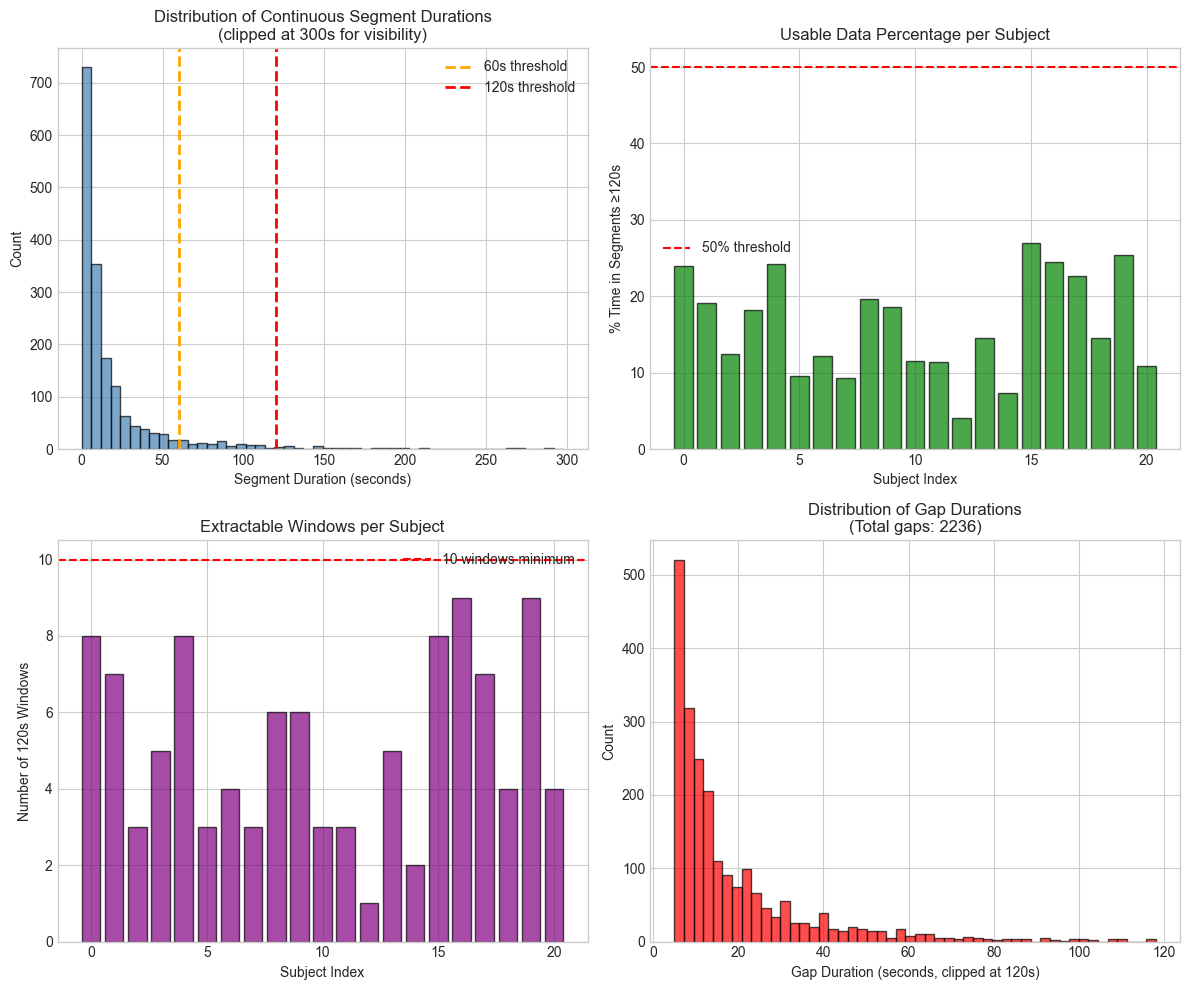


📊 SEGMENT STATISTICS (all subjects combined):
   Total segments: 1765
   Segments ≥60s: 164 (9.3%)
   Segments ≥120s: 72 (4.1%)
   Segments ≥300s (5min): 14 (0.8%)


In [8]:
# Visualize segment distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Distribution of segment durations (all segments from all subjects)
ax = axes[0, 0]
all_segments = []
for segs in gap_df['segment_durations_sec']:
    if segs:
        all_segments.extend(segs)
all_segments = np.array(all_segments)
ax.hist(all_segments[all_segments < 300], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(60, color='orange', linestyle='--', linewidth=2, label='60s threshold')
ax.axvline(120, color='red', linestyle='--', linewidth=2, label='120s threshold')
ax.set_xlabel('Segment Duration (seconds)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Continuous Segment Durations\n(clipped at 300s for visibility)')
ax.legend()

# 2. % of time in 120s+ segments per subject
ax = axes[0, 1]
ax.bar(range(len(gap_df)), gap_df['pct_time_in_segments_gt_120s'].values, color='green', edgecolor='black', alpha=0.7)
ax.axhline(50, color='red', linestyle='--', label='50% threshold')
ax.set_xlabel('Subject Index')
ax.set_ylabel('% Time in Segments ≥120s')
ax.set_title('Usable Data Percentage per Subject')
ax.legend()

# 3. Number of extractable 120s windows per subject
ax = axes[1, 0]
ax.bar(range(len(gap_df)), gap_df['n_windows_possible_120s'].values, color='purple', edgecolor='black', alpha=0.7)
ax.axhline(10, color='red', linestyle='--', label='10 windows minimum')
ax.set_xlabel('Subject Index')
ax.set_ylabel('Number of 120s Windows')
ax.set_title('Extractable Windows per Subject')
ax.legend()

# 4. Gap duration distribution
ax = axes[1, 1]
all_gaps = []
for gaps in gap_df['gap_durations_sec']:
    if gaps:
        all_gaps.extend(gaps)
all_gaps = np.array(all_gaps)
ax.hist(all_gaps[all_gaps < 120], bins=50, edgecolor='black', alpha=0.7, color='red')
ax.set_xlabel('Gap Duration (seconds, clipped at 120s)')
ax.set_ylabel('Count')
ax.set_title(f'Distribution of Gap Durations\n(Total gaps: {len(all_gaps)})')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'rr_gap_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 SEGMENT STATISTICS (all subjects combined):")
print(f"   Total segments: {len(all_segments)}")
print(f"   Segments ≥60s: {(all_segments >= 60).sum()} ({100*(all_segments >= 60).mean():.1f}%)")
print(f"   Segments ≥120s: {(all_segments >= 120).sum()} ({100*(all_segments >= 120).mean():.1f}%)")
print(f"   Segments ≥300s (5min): {(all_segments >= 300).sum()} ({100*(all_segments >= 300).mean():.1f}%)")

In [9]:
# Summary statistics
print("="*60)
print("RR INTERVAL DATA QUALITY SUMMARY")
print("="*60)

print(f"\n📁 File Availability:")
print(f"   Files found: {rr_df['file_exists'].sum()}/{len(rr_df)} ({100*rr_df['file_exists'].mean():.1f}%)")

# Filter to files that exist
rr_valid = rr_df[rr_df['file_exists'] & (rr_df['n_samples'] > 10)]
print(f"   Valid files (>10 samples): {len(rr_valid)}")

print(f"\n📊 Sample Counts:")
print(f"   Mean samples per subject: {rr_valid['n_samples'].mean():.0f}")
print(f"   Min: {rr_valid['n_samples'].min():.0f}, Max: {rr_valid['n_samples'].max():.0f}")
print(f"   Median duration: {rr_valid['duration_minutes'].median():.1f} minutes")

print(f"\n❤️ Heart Rate Statistics:")
print(f"   Mean RR: {rr_valid['mean_rr_ms'].mean():.1f} ± {rr_valid['mean_rr_ms'].std():.1f} ms")
print(f"   Mean HR: {rr_valid['mean_hr_bpm'].mean():.1f} ± {rr_valid['mean_hr_bpm'].std():.1f} BPM")

print(f"\n⚠️ Data Quality Issues:")
print(f"   Mean % in physiological range (300-2000ms): {rr_valid['pct_physiological_range'].mean():.1f}%")
print(f"   Mean % too low (<300ms): {rr_valid['pct_too_low'].mean():.2f}%")
print(f"   Mean % too high (>2000ms): {rr_valid['pct_too_high'].mean():.2f}%")
print(f"   Mean % ectopic beats (>20% change): {rr_valid['pct_ectopic'].mean():.1f}%")

print(f"\n🕳️ Gaps in Data:")
print(f"   Mean gaps >10sec per subject: {rr_valid['n_gaps_gt_10sec'].mean():.1f}")
print(f"   Median max gap: {rr_valid['max_gap_sec'].median():.1f} seconds")

print(f"\n✅ Quality Scores (0-100):")
print(f"   Mean: {rr_valid['quality_score'].mean():.1f}")
print(f"   Min: {rr_valid['quality_score'].min():.1f}, Max: {rr_valid['quality_score'].max():.1f}")
print(f"   Subjects with score > 70: {(rr_valid['quality_score'] > 70).sum()}")
print(f"   Subjects with score > 50: {(rr_valid['quality_score'] > 50).sum()}")

RR INTERVAL DATA QUALITY SUMMARY

📁 File Availability:
   Files found: 21/21 (100.0%)
   Valid files (>10 samples): 21

📊 Sample Counts:
   Mean samples per subject: 2461
   Min: 1581, Max: 3470
   Median duration: 80.6 minutes

❤️ Heart Rate Statistics:
   Mean RR: 780.3 ± 116.5 ms
   Mean HR: 78.4 ± 10.8 BPM

⚠️ Data Quality Issues:
   Mean % in physiological range (300-2000ms): 100.0%
   Mean % too low (<300ms): 0.00%
   Mean % too high (>2000ms): 0.00%
   Mean % ectopic beats (>20% change): 7.6%

🕳️ Gaps in Data:
   Mean gaps >10sec per subject: 61.4
   Median max gap: 585.0 seconds

✅ Quality Scores (0-100):
   Mean: 83.5
   Min: 77.3, Max: 88.4
   Subjects with score > 70: 21
   Subjects with score > 50: 21


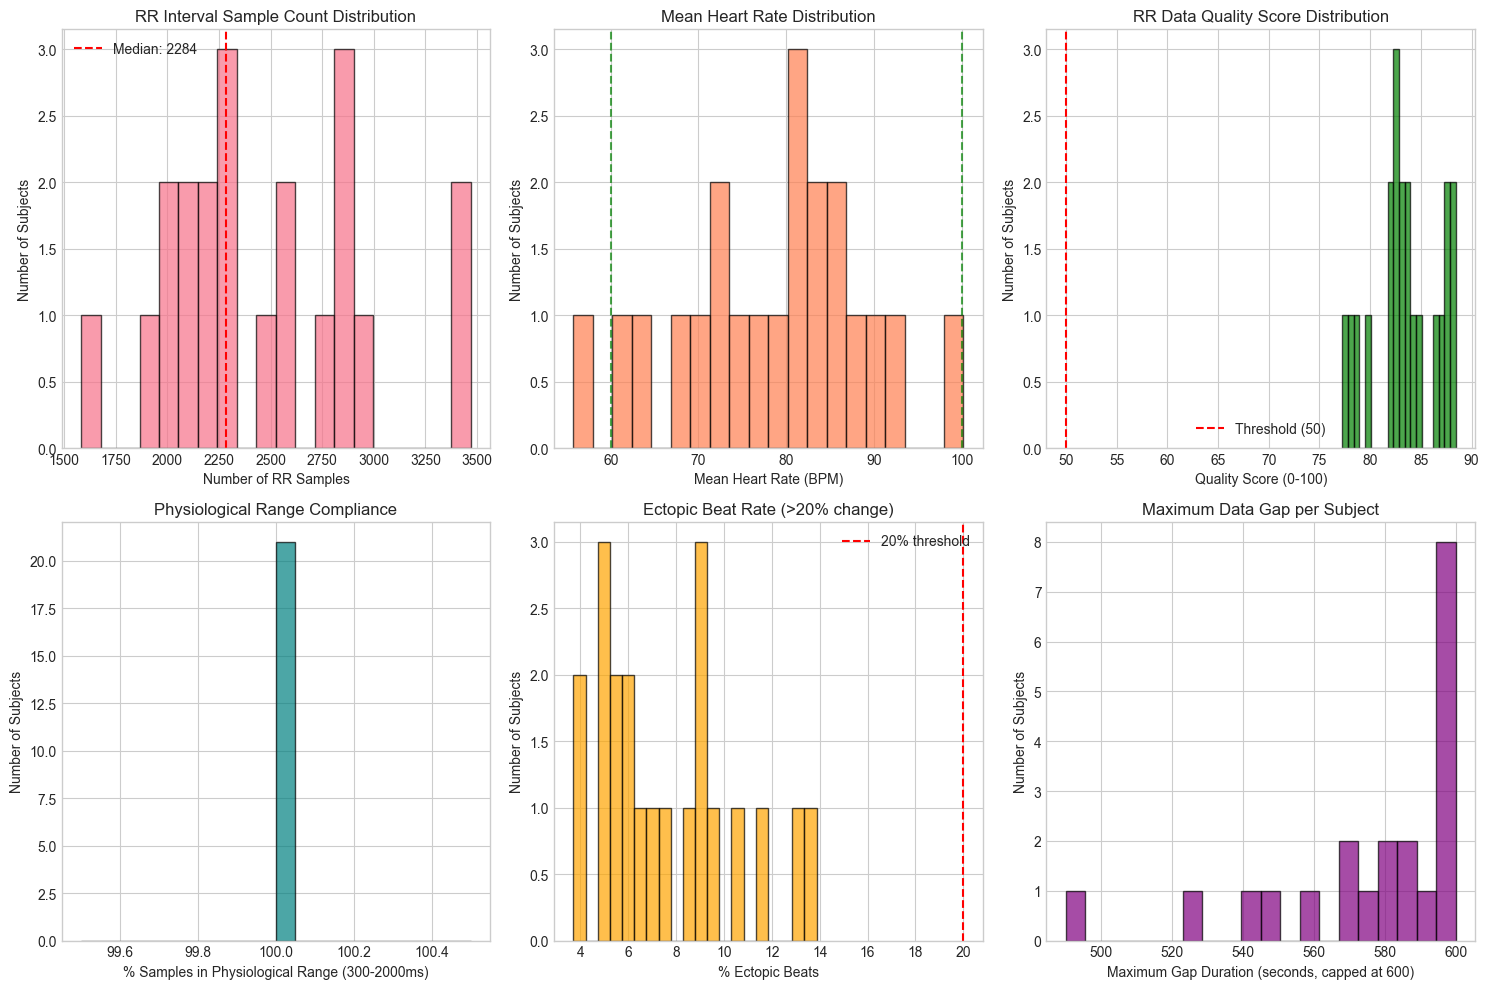

Saved: reports/rr_interval_quality_analysis.png


In [10]:
# Visualize RR quality metrics
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Sample counts
ax = axes[0, 0]
ax.hist(rr_valid['n_samples'], bins=20, edgecolor='black', alpha=0.7)
ax.axvline(rr_valid['n_samples'].median(), color='red', linestyle='--', label=f'Median: {rr_valid["n_samples"].median():.0f}')
ax.set_xlabel('Number of RR Samples')
ax.set_ylabel('Number of Subjects')
ax.set_title('RR Interval Sample Count Distribution')
ax.legend()

# 2. Mean HR distribution
ax = axes[0, 1]
ax.hist(rr_valid['mean_hr_bpm'].dropna(), bins=20, edgecolor='black', alpha=0.7, color='coral')
ax.axvline(60, color='green', linestyle='--', alpha=0.7, label='60 BPM')
ax.axvline(100, color='green', linestyle='--', alpha=0.7, label='100 BPM')
ax.set_xlabel('Mean Heart Rate (BPM)')
ax.set_ylabel('Number of Subjects')
ax.set_title('Mean Heart Rate Distribution')

# 3. Quality score distribution
ax = axes[0, 2]
ax.hist(rr_valid['quality_score'], bins=20, edgecolor='black', alpha=0.7, color='green')
ax.axvline(50, color='red', linestyle='--', label='Threshold (50)')
ax.set_xlabel('Quality Score (0-100)')
ax.set_ylabel('Number of Subjects')
ax.set_title('RR Data Quality Score Distribution')
ax.legend()

# 4. % in physiological range
ax = axes[1, 0]
ax.hist(rr_valid['pct_physiological_range'], bins=20, edgecolor='black', alpha=0.7, color='teal')
ax.set_xlabel('% Samples in Physiological Range (300-2000ms)')
ax.set_ylabel('Number of Subjects')
ax.set_title('Physiological Range Compliance')

# 5. % ectopic beats
ax = axes[1, 1]
ax.hist(rr_valid['pct_ectopic'], bins=20, edgecolor='black', alpha=0.7, color='orange')
ax.axvline(20, color='red', linestyle='--', label='20% threshold')
ax.set_xlabel('% Ectopic Beats')
ax.set_ylabel('Number of Subjects')
ax.set_title('Ectopic Beat Rate (>20% change)')
ax.legend()

# 6. Max gap duration
ax = axes[1, 2]
ax.hist(np.clip(rr_valid['max_gap_sec'], 0, 600), bins=20, edgecolor='black', alpha=0.7, color='purple')
ax.set_xlabel('Maximum Gap Duration (seconds, capped at 600)')
ax.set_ylabel('Number of Subjects')
ax.set_title('Maximum Data Gap per Subject')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'rr_interval_quality_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: reports/rr_interval_quality_analysis.png")

In [11]:
# Per-subject quality table
display_cols = ['subject_id', 'n_samples', 'duration_minutes', 'mean_hr_bpm', 
                'pct_physiological_range', 'pct_ectopic', 'quality_score']

rr_summary = rr_valid[display_cols].copy()
rr_summary = rr_summary.round(2)
rr_summary['subject_id'] = rr_summary['subject_id'].str[:12] + '...'
rr_summary = rr_summary.sort_values('quality_score', ascending=False)

print("\nTop 10 Subjects by RR Quality:")
print(rr_summary.head(10).to_string(index=False))

print("\nBottom 10 Subjects by RR Quality:")
print(rr_summary.tail(10).to_string(index=False))


Top 10 Subjects by RR Quality:
     subject_id  n_samples  duration_minutes  mean_hr_bpm  pct_physiological_range  pct_ectopic  quality_score
7bb4dafd-5a9...       2806             74.43        76.49                    100.0         3.71          88.44
b61f4c2a-38b...       2924             76.58        73.38                    100.0         5.13          88.41
0a73ef1b-da6...       3409             80.62       100.19                    100.0         4.72          87.58
c5a60768-770...       3470             89.92        84.10                    100.0         6.11          87.37
464cc459-d71...       2845             72.85        82.36                    100.0         3.76          87.15
87bf2ae1-013...       2283             68.85        87.97                    100.0         7.62          86.52
46b09d4a-63b...       2855             88.80        89.09                    100.0         4.87          84.86
d9af7d23-895...       2531             78.45        85.49                    100

---
# Part 2: Activity Data Analysis

Activity data contains derived physiological metrics with **quality flags**.

## Key Columns:
- `bpm`: Heart rate (beats per minute)
- `bpm_q`: Heart rate quality (0=bad, 1-4=good with varying confidence)
- `respiration_rate`: Respiration rate
- `resp_q`: Respiration quality
- `spo2`: Blood oxygen saturation
- `spo2_q`: SpO2 quality
- `wearing`: Device wearing status (4=worn properly)

## Quality Flags (from VitaStress documentation):
- `0`: Invalid/No measurement
- `1-4`: Valid with increasing confidence

In [41]:
def analyze_activity_file(subject_folder: Path):
    """
    Comprehensive analysis of activity file for one subject.
    
    Returns:
        Dictionary with quality metrics
    """
    subject_id = subject_folder.name.replace("id_", "")
    activity_file = subject_folder / f"{subject_id}_activity.csv"
    
    result = {
        "subject_id": subject_id,
        "file_exists": activity_file.exists(),
        "n_samples": 0,
        "duration_minutes": 0,
        "sampling_interval_sec": np.nan,
        # BPM quality
        "bpm_pct_valid": 0,  # bpm > 0 and bpm_q >= 1
        "bpm_pct_high_quality": 0,  # bpm_q >= 3
        "bpm_pct_zeros": 0,
        "bpm_mean_when_valid": np.nan,
        "bpm_std_when_valid": np.nan,
        # Respiration quality
        "resp_pct_valid": 0,  # resp > 0 and resp_q >= 1
        "resp_pct_high_quality": 0,  # resp_q >= 3
        "resp_mean_when_valid": np.nan,
        # SpO2 quality
        "spo2_pct_valid": 0,  # spo2 > 0 and spo2_q >= 1
        "spo2_pct_high_quality": 0,  # spo2_q >= 3
        "spo2_mean_when_valid": np.nan,
        # Wearing status
        "wearing_pct_on": 0,  # wearing == 4
        # Overall quality
        "overall_quality_score": 0,
    }
    
    if not activity_file.exists():
        return result
    
    try:
        df = pd.read_csv(activity_file)
        df["date"] = pd.to_datetime(df["date"], format="ISO8601")
        df = df.sort_values("date").reset_index(drop=True)
        
        if len(df) < 5:
            result["n_samples"] = len(df)
            return result
        
        n = len(df)
        result["n_samples"] = n
        result["duration_minutes"] = (df["date"].max() - df["date"].min()).total_seconds() / 60
        
        # Sampling interval
        time_diffs = df["date"].diff().dt.total_seconds().dropna()
        result["sampling_interval_sec"] = time_diffs.median()
        
        # BPM analysis
        if "bpm" in df.columns and "bpm_q" in df.columns:
            bpm_valid = (df["bpm"] > 0) & (df["bpm_q"] >= 1)
            bpm_high_q = (df["bpm"] > 0) & (df["bpm_q"] >= 3)
            bpm_zeros = df["bpm"] == 0
            
            result["bpm_pct_valid"] = 100 * bpm_valid.mean()
            result["bpm_pct_high_quality"] = 100 * bpm_high_q.mean()
            result["bpm_pct_zeros"] = 100 * bpm_zeros.mean()
            
            if bpm_valid.sum() > 0:
                result["bpm_mean_when_valid"] = df.loc[bpm_valid, "bpm"].mean()
                result["bpm_std_when_valid"] = df.loc[bpm_valid, "bpm"].std()
        
        # Respiration analysis
        if "respiration_rate" in df.columns and "resp_q" in df.columns:
            resp_valid = (df["respiration_rate"] > 0) & (df["resp_q"] >= 1)
            resp_high_q = (df["respiration_rate"] > 0) & (df["resp_q"] >= 3)
            
            result["resp_pct_valid"] = 100 * resp_valid.mean()
            result["resp_pct_high_quality"] = 100 * resp_high_q.mean()
            
            if resp_valid.sum() > 0:
                result["resp_mean_when_valid"] = df.loc[resp_valid, "respiration_rate"].mean()
        
        # SpO2 analysis
        if "spo2" in df.columns and "spo2_q" in df.columns:
            spo2_valid = (df["spo2"] > 0) & (df["spo2_q"] >= 1)
            spo2_high_q = (df["spo2"] > 0) & (df["spo2_q"] >= 3)
            
            result["spo2_pct_valid"] = 100 * spo2_valid.mean()
            result["spo2_pct_high_quality"] = 100 * spo2_high_q.mean()
            
            if spo2_valid.sum() > 0:
                result["spo2_mean_when_valid"] = df.loc[spo2_valid, "spo2"].mean()
        
        # Wearing status
        if "wearing" in df.columns:
            result["wearing_pct_on"] = 100 * (df["wearing"] == 4).mean()
        
        # Overall quality score (0-100)
        # Weighted average of valid percentages
        score = (
            0.4 * result["bpm_pct_valid"] +
            0.2 * result["resp_pct_valid"] +
            0.2 * result["spo2_pct_valid"] +
            0.2 * result["wearing_pct_on"]
        ) / 100 * 100  # Normalize
        result["overall_quality_score"] = score
        
    except Exception as e:
        result["error"] = str(e)
    
    return result

In [42]:
# Analyze all subjects
print("Analyzing Activity files for all subjects...")

activity_analysis_results = []

for subject_folder in tqdm(subjects, desc="Activity Analysis"):
    result = analyze_activity_file(subject_folder)
    activity_analysis_results.append(result)

activity_df = pd.DataFrame(activity_analysis_results)
print(f"\nAnalyzed {len(activity_df)} subjects")

Analyzing Activity files for all subjects...


Activity Analysis:   0%|          | 0/21 [00:00<?, ?it/s]


Analyzed 21 subjects


In [43]:
# Summary statistics for Activity data
print("="*60)
print("ACTIVITY DATA QUALITY SUMMARY")
print("="*60)

print(f"\n📁 File Availability:")
print(f"   Files found: {activity_df['file_exists'].sum()}/{len(activity_df)}")

# Filter to files that exist
act_valid = activity_df[activity_df['file_exists'] & (activity_df['n_samples'] > 5)]
print(f"   Valid files: {len(act_valid)}")

print(f"\n⏱️ Sampling:")
print(f"   Median samples per subject: {act_valid['n_samples'].median():.0f}")
print(f"   Median duration: {act_valid['duration_minutes'].median():.1f} minutes")
print(f"   Median sampling interval: {act_valid['sampling_interval_sec'].median():.1f} seconds (~{60/act_valid['sampling_interval_sec'].median():.1f} samples/min)")

print(f"\n❤️ BPM (Heart Rate) Quality:")
print(f"   Mean % valid (bpm>0, q>=1): {act_valid['bpm_pct_valid'].mean():.1f}%")
print(f"   Mean % high quality (q>=3): {act_valid['bpm_pct_high_quality'].mean():.1f}%")
print(f"   Mean % zeros (missing): {act_valid['bpm_pct_zeros'].mean():.1f}%")
print(f"   Mean BPM when valid: {act_valid['bpm_mean_when_valid'].mean():.1f} BPM")

print(f"\n🌬️ Respiration Quality:")
print(f"   Mean % valid: {act_valid['resp_pct_valid'].mean():.1f}%")
print(f"   Mean % high quality (q>=3): {act_valid['resp_pct_high_quality'].mean():.1f}%")
print(f"   Mean rate when valid: {act_valid['resp_mean_when_valid'].mean():.1f} breaths/min")

print(f"\n🩸 SpO2 (Blood Oxygen) Quality:")
print(f"   Mean % valid: {act_valid['spo2_pct_valid'].mean():.1f}%")
print(f"   Mean % high quality (q>=3): {act_valid['spo2_pct_high_quality'].mean():.1f}%")
print(f"   Mean SpO2 when valid: {act_valid['spo2_mean_when_valid'].mean():.1f}%")

print(f"\n⌚ Device Wearing:")
print(f"   Mean % worn properly: {act_valid['wearing_pct_on'].mean():.1f}%")

print(f"\n✅ Overall Quality Scores (0-100):")
print(f"   Mean: {act_valid['overall_quality_score'].mean():.1f}")
print(f"   Subjects with score > 50: {(act_valid['overall_quality_score'] > 50).sum()}")
print(f"   Subjects with score > 30: {(act_valid['overall_quality_score'] > 30).sum()}")

ACTIVITY DATA QUALITY SUMMARY

📁 File Availability:
   Files found: 21/21
   Valid files: 21

⏱️ Sampling:
   Median samples per subject: 179
   Median duration: 89.5 minutes
   Median sampling interval: 30.0 seconds (~2.0 samples/min)

❤️ BPM (Heart Rate) Quality:
   Mean % valid (bpm>0, q>=1): 93.4%
   Mean % high quality (q>=3): 51.3%
   Mean % zeros (missing): 6.4%
   Mean BPM when valid: 92.0 BPM

🌬️ Respiration Quality:
   Mean % valid: 44.4%
   Mean % high quality (q>=3): 18.7%
   Mean rate when valid: 17.8 breaths/min

🩸 SpO2 (Blood Oxygen) Quality:
   Mean % valid: 85.2%
   Mean % high quality (q>=3): 25.3%
   Mean SpO2 when valid: 98.4%

⌚ Device Wearing:
   Mean % worn properly: 98.5%

✅ Overall Quality Scores (0-100):
   Mean: 83.0
   Subjects with score > 50: 21
   Subjects with score > 30: 21


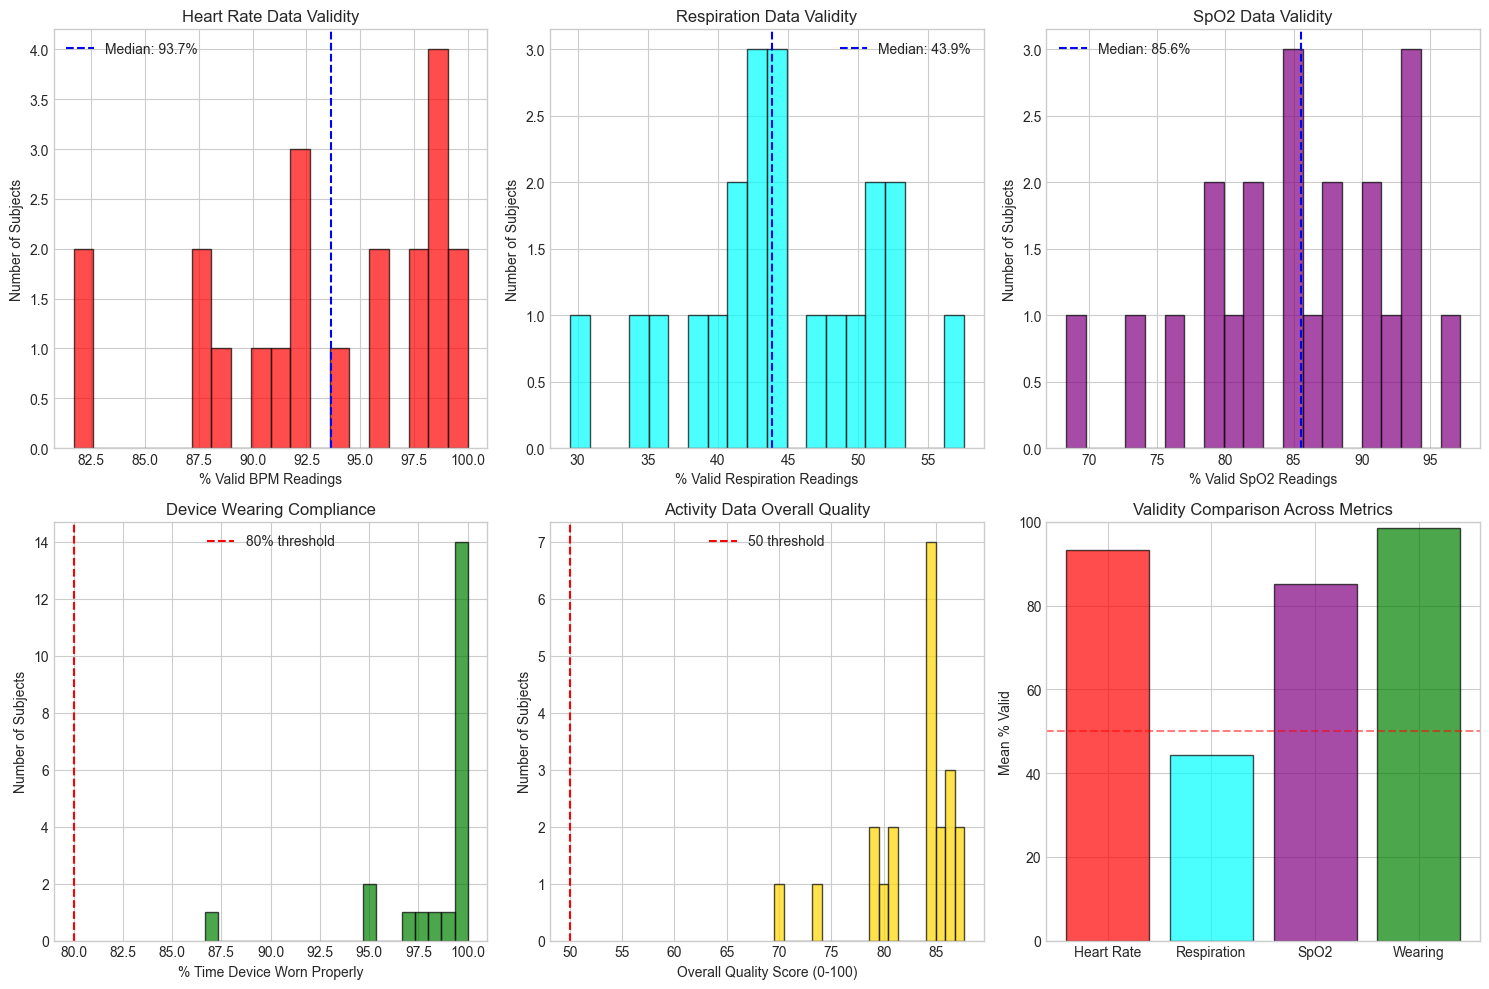

Saved: reports/activity_quality_analysis.png


In [44]:
# Visualize Activity quality metrics
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. BPM valid %
ax = axes[0, 0]
ax.hist(act_valid['bpm_pct_valid'], bins=20, edgecolor='black', alpha=0.7, color='red')
ax.axvline(act_valid['bpm_pct_valid'].median(), color='blue', linestyle='--', 
           label=f'Median: {act_valid["bpm_pct_valid"].median():.1f}%')
ax.set_xlabel('% Valid BPM Readings')
ax.set_ylabel('Number of Subjects')
ax.set_title('Heart Rate Data Validity')
ax.legend()

# 2. Respiration valid %
ax = axes[0, 1]
ax.hist(act_valid['resp_pct_valid'], bins=20, edgecolor='black', alpha=0.7, color='cyan')
ax.axvline(act_valid['resp_pct_valid'].median(), color='blue', linestyle='--',
           label=f'Median: {act_valid["resp_pct_valid"].median():.1f}%')
ax.set_xlabel('% Valid Respiration Readings')
ax.set_ylabel('Number of Subjects')
ax.set_title('Respiration Data Validity')
ax.legend()

# 3. SpO2 valid %
ax = axes[0, 2]
ax.hist(act_valid['spo2_pct_valid'], bins=20, edgecolor='black', alpha=0.7, color='purple')
ax.axvline(act_valid['spo2_pct_valid'].median(), color='blue', linestyle='--',
           label=f'Median: {act_valid["spo2_pct_valid"].median():.1f}%')
ax.set_xlabel('% Valid SpO2 Readings')
ax.set_ylabel('Number of Subjects')
ax.set_title('SpO2 Data Validity')
ax.legend()

# 4. Wearing status
ax = axes[1, 0]
ax.hist(act_valid['wearing_pct_on'], bins=20, edgecolor='black', alpha=0.7, color='green')
ax.axvline(80, color='red', linestyle='--', label='80% threshold')
ax.set_xlabel('% Time Device Worn Properly')
ax.set_ylabel('Number of Subjects')
ax.set_title('Device Wearing Compliance')
ax.legend()

# 5. Overall quality score
ax = axes[1, 1]
ax.hist(act_valid['overall_quality_score'], bins=20, edgecolor='black', alpha=0.7, color='gold')
ax.axvline(50, color='red', linestyle='--', label='50 threshold')
ax.set_xlabel('Overall Quality Score (0-100)')
ax.set_ylabel('Number of Subjects')
ax.set_title('Activity Data Overall Quality')
ax.legend()

# 6. Quality comparison (stacked bar)
ax = axes[1, 2]
metrics = ['bpm_pct_valid', 'resp_pct_valid', 'spo2_pct_valid', 'wearing_pct_on']
labels = ['Heart Rate', 'Respiration', 'SpO2', 'Wearing']
means = [act_valid[m].mean() for m in metrics]
colors = ['red', 'cyan', 'purple', 'green']
ax.bar(labels, means, color=colors, edgecolor='black', alpha=0.7)
ax.axhline(50, color='red', linestyle='--', alpha=0.5)
ax.set_ylabel('Mean % Valid')
ax.set_title('Validity Comparison Across Metrics')
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'activity_quality_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: reports/activity_quality_analysis.png")


Quality Flag Distribution (across all subjects):


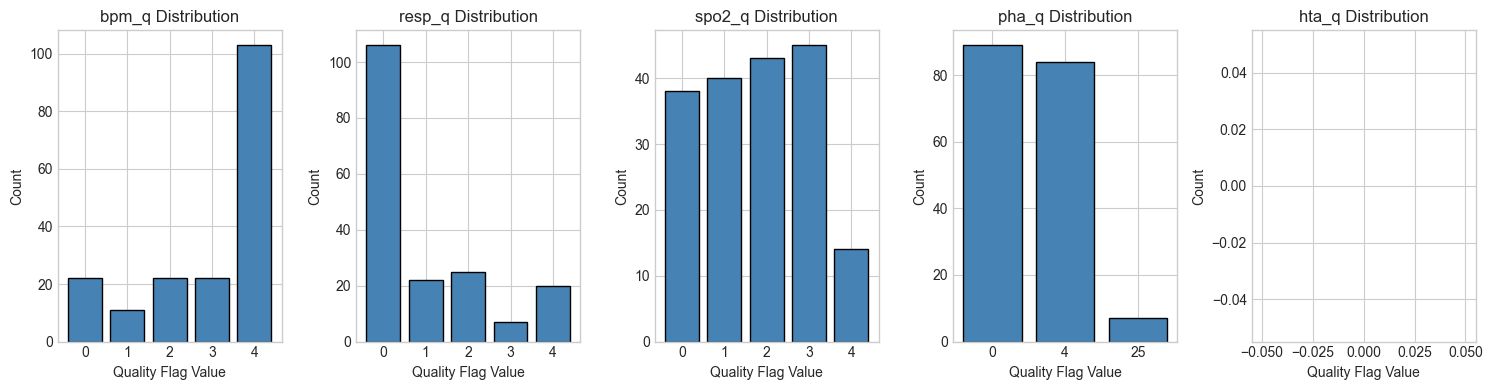


Quality Flag Meanings:
  0 = Invalid/No measurement
  1 = Low confidence
  2 = Medium-low confidence
  3 = Medium-high confidence
  4 = High confidence


In [45]:
# Quality flag distribution analysis
print("\nQuality Flag Distribution (across all subjects):")
print("="*60)

# Load one sample file to understand quality flag values
sample_subject = subjects[0]
sample_id = sample_subject.name.replace("id_", "")
sample_df = pd.read_csv(sample_subject / f"{sample_id}_activity.csv")

quality_cols = ['bpm_q', 'resp_q', 'spo2_q', 'pha_q', 'hta_q']

fig, axes = plt.subplots(1, len(quality_cols), figsize=(15, 4))

for idx, col in enumerate(quality_cols):
    if col in sample_df.columns:
        ax = axes[idx]
        value_counts = sample_df[col].value_counts().sort_index()
        ax.bar(value_counts.index.astype(str), value_counts.values, color='steelblue', edgecolor='black')
        ax.set_xlabel('Quality Flag Value')
        ax.set_ylabel('Count')
        ax.set_title(f'{col} Distribution')

plt.tight_layout()
plt.show()

print("\nQuality Flag Meanings:")
print("  0 = Invalid/No measurement")
print("  1 = Low confidence")
print("  2 = Medium-low confidence")
print("  3 = Medium-high confidence")
print("  4 = High confidence")

---
# Part 3: Extract High-Quality Data

In [46]:
def extract_quality_activity_data(subject_folder: Path, 
                                   min_bpm_q: int = 2,
                                   min_resp_q: int = 2,
                                   min_spo2_q: int = 2,
                                   require_wearing: bool = True) -> pd.DataFrame:
    """
    Extract only high-quality data from activity file.
    
    Args:
        subject_folder: Path to subject folder
        min_bpm_q: Minimum BPM quality (0-4)
        min_resp_q: Minimum respiration quality (0-4)
        min_spo2_q: Minimum SpO2 quality (0-4)
        require_wearing: Whether to require device to be worn (wearing==4)
    
    Returns:
        DataFrame with only quality-filtered data
    """
    subject_id = subject_folder.name.replace("id_", "")
    activity_file = subject_folder / f"{subject_id}_activity.csv"
    
    if not activity_file.exists():
        return pd.DataFrame()
    
    df = pd.read_csv(activity_file)
    df["date"] = pd.to_datetime(df["date"], format="ISO8601")
    df["subject_id"] = subject_id
    
    # Apply quality filters
    mask = pd.Series([True] * len(df))
    
    if require_wearing and "wearing" in df.columns:
        mask &= (df["wearing"] == 4)
    
    # Create quality-filtered columns
    df_clean = df.copy()
    
    # BPM: Set to NaN if quality is low
    if "bpm" in df.columns and "bpm_q" in df.columns:
        low_quality_bpm = (df["bpm_q"] < min_bpm_q) | (df["bpm"] == 0)
        df_clean.loc[low_quality_bpm, "bpm"] = np.nan
    
    # Respiration: Set to NaN if quality is low
    if "respiration_rate" in df.columns and "resp_q" in df.columns:
        low_quality_resp = (df["resp_q"] < min_resp_q) | (df["respiration_rate"] == 0)
        df_clean.loc[low_quality_resp, "respiration_rate"] = np.nan
    
    # SpO2: Set to NaN if quality is low
    if "spo2" in df.columns and "spo2_q" in df.columns:
        low_quality_spo2 = (df["spo2_q"] < min_spo2_q) | (df["spo2"] == 0)
        df_clean.loc[low_quality_spo2, "spo2"] = np.nan
    
    # Filter to wearing times only
    df_clean = df_clean[mask].reset_index(drop=True)
    
    return df_clean

In [47]:
# Extract quality data for all subjects and combine
print("Extracting high-quality activity data for all subjects...")
print("Quality thresholds: bpm_q>=2, resp_q>=2, spo2_q>=2, wearing==4")

all_quality_data = []

for subject_folder in tqdm(subjects, desc="Extracting quality data"):
    df_clean = extract_quality_activity_data(
        subject_folder,
        min_bpm_q=2,
        min_resp_q=2,
        min_spo2_q=2,
        require_wearing=True
    )
    if len(df_clean) > 0:
        all_quality_data.append(df_clean)

if all_quality_data:
    combined_quality_df = pd.concat(all_quality_data, ignore_index=True)
    print(f"\nExtracted {len(combined_quality_df):,} quality-filtered rows")
    print(f"From {len(all_quality_data)} subjects")
else:
    print("No quality data extracted!")

Extracting high-quality activity data for all subjects...
Quality thresholds: bpm_q>=2, resp_q>=2, spo2_q>=2, wearing==4


Extracting quality data:   0%|          | 0/21 [00:00<?, ?it/s]


Extracted 3,488 quality-filtered rows
From 21 subjects


In [48]:
# Summary of extracted quality data
print("\nQuality-Filtered Data Summary:")
print("="*60)

# Check remaining valid values after quality filtering
for col in ['bpm', 'respiration_rate', 'spo2']:
    if col in combined_quality_df.columns:
        valid_pct = 100 * combined_quality_df[col].notna().mean()
        mean_val = combined_quality_df[col].mean()
        print(f"{col}: {valid_pct:.1f}% valid, mean={mean_val:.1f}")


Quality-Filtered Data Summary:
bpm: 76.5% valid, mean=89.8
respiration_rate: 30.4% valid, mean=18.4
spo2: 51.6% valid, mean=98.3


---
# Part 5: PPG-Based Heart Rate Extraction using HeartPy

Since RR interval data is too fragmented for reliable HRV analysis, we can extract heart rate directly from the raw PPG signal using **HeartPy**.

## PPG Data Characteristics:
- **Sampling Rate**: ~64 Hz (15ms intervals)
- **Signal Column**: `value` (raw PPG amplitude)
- **Quality Column**: `quality` (0-4, higher is better)

## HeartPy Features:
- Peak detection in PPG waveforms
- Heart rate (BPM) calculation
- HRV metrics (RMSSD, SDNN, etc.)
- Signal quality assessment

In [23]:
# Install heartpy if needed (uncomment if not installed)
# !pip install heartpy

import heartpy as hp
from scipy import signal

print(f"HeartPy version: {hp.__version__}")

HeartPy version: Version 1.2.6


In [24]:
def load_ppg_data(subject_folder: Path) -> pd.DataFrame:
    """
    Load PPG data for a subject.
    
    Args:
        subject_folder: Path to subject folder
    
    Returns:
        DataFrame with PPG data
    """
    subject_id = subject_folder.name.replace("id_", "")
    ppg_file = subject_folder / f"{subject_id}_ppg2_green_6.csv"
    
    if not ppg_file.exists():
        return None
    
    df = pd.read_csv(ppg_file)
    df["date"] = pd.to_datetime(df["date"], format="ISO8601")
    df = df.sort_values("date").reset_index(drop=True)
    
    return df


def estimate_ppg_sampling_rate(timestamps: pd.Series) -> float:
    """
    Estimate actual sampling rate from timestamps.
    
    Args:
        timestamps: Series of datetime timestamps
    
    Returns:
        Estimated sampling rate in Hz
    """
    time_diffs = timestamps.diff().dt.total_seconds().dropna()
    median_interval = time_diffs.median()
    return 1.0 / median_interval if median_interval > 0 else 64.0


def extract_hr_from_ppg_window(ppg_signal: np.ndarray, 
                                sample_rate: float,
                                window_size_sec: float = 30.0) -> dict:
    """
    Extract heart rate and HRV metrics from a PPG window using HeartPy.
    
    Args:
        ppg_signal: Raw PPG values
        sample_rate: Sampling rate in Hz
        window_size_sec: Window size in seconds
    
    Returns:
        Dictionary with HR and HRV metrics
    """
    result = {
        "hr_bpm": np.nan,
        "rmssd": np.nan,
        "sdnn": np.nan,
        "pnn50": np.nan,
        "breathingrate": np.nan,
        "success": False,
        "error": None
    }
    
    try:
        # Filter the signal (0.5-4 Hz bandpass for PPG)
        filtered = hp.filter_signal(ppg_signal, 
                                     cutoff=[0.5, 4.0], 
                                     sample_rate=sample_rate, 
                                     order=3, 
                                     filtertype="bandpass")
        
        # Process with HeartPy
        working_data, measures = hp.process(filtered, 
                                             sample_rate=sample_rate,
                                             high_precision=True,
                                             clean_rr=True)
        
        # Extract metrics
        result["hr_bpm"] = measures.get("bpm", np.nan)
        result["rmssd"] = measures.get("rmssd", np.nan)
        result["sdnn"] = measures.get("sdnn", np.nan)
        result["pnn50"] = measures.get("pnn50", np.nan)
        result["breathingrate"] = measures.get("breathingrate", np.nan)
        result["success"] = True
        
    except Exception as e:
        result["error"] = str(e)
    
    return result


def analyze_ppg_quality(subject_folder: Path, 
                         window_size_sec: float = 30.0,
                         max_windows: int = 50) -> dict:
    """
    Comprehensive PPG quality analysis for one subject.
    
    Args:
        subject_folder: Path to subject folder
        window_size_sec: Window size for HR extraction
        max_windows: Maximum number of windows to analyze
    
    Returns:
        Dictionary with quality metrics
    """
    subject_id = subject_folder.name.replace("id_", "")
    
    result = {
        "subject_id": subject_id,
        "file_exists": False,
        "n_samples": 0,
        "duration_minutes": 0,
        "estimated_sample_rate": 0,
        "quality_4_pct": 0,  # % samples with quality=4
        "quality_3_pct": 0,  # % samples with quality>=3
        "n_windows_analyzed": 0,
        "n_windows_success": 0,
        "success_rate_pct": 0,
        "mean_hr_bpm": np.nan,
        "std_hr_bpm": np.nan,
        "mean_rmssd": np.nan,
        "mean_sdnn": np.nan,
        "hr_values": [],  # Store for visualization
        "timestamps": [],
    }
    
    # Load PPG data
    df = load_ppg_data(subject_folder)
    if df is None or len(df) < 1000:
        return result
    
    result["file_exists"] = True
    result["n_samples"] = len(df)
    result["duration_minutes"] = (df["date"].max() - df["date"].min()).total_seconds() / 60
    
    # Estimate sampling rate
    sample_rate = estimate_ppg_sampling_rate(df["date"])
    result["estimated_sample_rate"] = sample_rate
    
    # Quality analysis
    if "quality" in df.columns:
        result["quality_4_pct"] = 100 * (df["quality"] == 4).mean()
        result["quality_3_pct"] = 100 * (df["quality"] >= 3).mean()
    
    # Extract HR from windows
    ppg_signal = df["value"].values
    window_samples = int(window_size_sec * sample_rate)
    stride_samples = window_samples  # Non-overlapping
    
    hr_values = []
    rmssd_values = []
    sdnn_values = []
    timestamps = []
    n_success = 0
    
    n_windows = min(max_windows, (len(ppg_signal) - window_samples) // stride_samples)
    
    for i in range(n_windows):
        start_idx = i * stride_samples
        end_idx = start_idx + window_samples
        
        if end_idx > len(ppg_signal):
            break
        
        window = ppg_signal[start_idx:end_idx]
        
        # Skip windows with zeros (missing data)
        if np.any(window == 0) or np.std(window) < 10:
            continue
        
        metrics = extract_hr_from_ppg_window(window, sample_rate, window_size_sec)
        
        if metrics["success"] and 30 < metrics["hr_bpm"] < 200:
            hr_values.append(metrics["hr_bpm"])
            rmssd_values.append(metrics["rmssd"])
            sdnn_values.append(metrics["sdnn"])
            timestamps.append(df["date"].iloc[start_idx])
            n_success += 1
    
    result["n_windows_analyzed"] = n_windows
    result["n_windows_success"] = n_success
    result["success_rate_pct"] = 100 * n_success / max(n_windows, 1)
    
    if hr_values:
        result["mean_hr_bpm"] = np.mean(hr_values)
        result["std_hr_bpm"] = np.std(hr_values)
        result["mean_rmssd"] = np.nanmean(rmssd_values)
        result["mean_sdnn"] = np.nanmean(sdnn_values)
        result["hr_values"] = hr_values
        result["timestamps"] = timestamps
    
    return result

In [25]:
# Test on one subject first
print("Testing PPG HR extraction on first subject...")
test_result = analyze_ppg_quality(subjects[0], window_size_sec=30.0, max_windows=20)

print(f"\nSubject: {test_result['subject_id'][:12]}...")
print(f"File exists: {test_result['file_exists']}")
print(f"Samples: {test_result['n_samples']:,}")
print(f"Duration: {test_result['duration_minutes']:.1f} minutes")
print(f"Sample rate: {test_result['estimated_sample_rate']:.1f} Hz")
print(f"Quality 4: {test_result['quality_4_pct']:.1f}%")
print(f"Windows analyzed: {test_result['n_windows_analyzed']}")
print(f"Successful extractions: {test_result['n_windows_success']}")
print(f"Success rate: {test_result['success_rate_pct']:.1f}%")
print(f"Mean HR: {test_result['mean_hr_bpm']:.1f} BPM")
print(f"HR std: {test_result['std_hr_bpm']:.1f} BPM")
print(f"Mean RMSSD: {test_result['mean_rmssd']:.1f} ms")
print(f"Mean SDNN: {test_result['mean_sdnn']:.1f} ms")

Testing PPG HR extraction on first subject...

Subject: 0a73ef1b-da6...
File exists: True
Samples: 344,896
Duration: 90.0 minutes
Sample rate: 62.5 Hz
Quality 4: 100.0%
Windows analyzed: 20
Successful extractions: 17
Success rate: 85.0%
Mean HR: 158.2 BPM
HR std: 16.5 BPM
Mean RMSSD: 42.8 ms
Mean SDNN: 116.5 ms


In [26]:
# Run PPG analysis for all subjects
print("Analyzing PPG data for all subjects...")
print("(Using 30-second windows, max 50 windows per subject)")

ppg_analysis_results = []

for subject_folder in tqdm(subjects, desc="PPG Analysis"):
    result = analyze_ppg_quality(subject_folder, window_size_sec=30.0, max_windows=50)
    ppg_analysis_results.append(result)

ppg_df = pd.DataFrame(ppg_analysis_results)
print(f"\nAnalyzed {len(ppg_df)} subjects")

Analyzing PPG data for all subjects...
(Using 30-second windows, max 50 windows per subject)


PPG Analysis:   0%|          | 0/21 [00:00<?, ?it/s]


Analyzed 21 subjects


In [27]:
# PPG Quality Summary
print("="*60)
print("PPG-BASED HEART RATE EXTRACTION SUMMARY")
print("="*60)

ppg_valid = ppg_df[ppg_df['file_exists'] & (ppg_df['n_windows_success'] > 0)]

print(f"\n📁 File Availability:")
print(f"   Files found: {ppg_df['file_exists'].sum()}/{len(ppg_df)}")
print(f"   Subjects with successful HR extraction: {len(ppg_valid)}")

print(f"\n📊 PPG Signal Quality:")
print(f"   Mean samples per subject: {ppg_valid['n_samples'].mean():,.0f}")
print(f"   Mean duration: {ppg_valid['duration_minutes'].mean():.1f} minutes")
print(f"   Mean sample rate: {ppg_valid['estimated_sample_rate'].mean():.1f} Hz")
print(f"   Mean % quality=4: {ppg_valid['quality_4_pct'].mean():.1f}%")
print(f"   Mean % quality>=3: {ppg_valid['quality_3_pct'].mean():.1f}%")

print(f"\n🔍 HeartPy Extraction Success:")
print(f"   Mean windows analyzed: {ppg_valid['n_windows_analyzed'].mean():.1f}")
print(f"   Mean successful extractions: {ppg_valid['n_windows_success'].mean():.1f}")
print(f"   Mean success rate: {ppg_valid['success_rate_pct'].mean():.1f}%")
print(f"   Total successful windows: {ppg_valid['n_windows_success'].sum()}")

print(f"\n❤️ Heart Rate Metrics (from PPG):")
print(f"   Mean HR: {ppg_valid['mean_hr_bpm'].mean():.1f} ± {ppg_valid['mean_hr_bpm'].std():.1f} BPM")
print(f"   HR range across subjects: {ppg_valid['mean_hr_bpm'].min():.1f} - {ppg_valid['mean_hr_bpm'].max():.1f} BPM")

print(f"\n📈 HRV Metrics (from PPG):")
print(f"   Mean RMSSD: {ppg_valid['mean_rmssd'].mean():.1f} ms")
print(f"   Mean SDNN: {ppg_valid['mean_sdnn'].mean():.1f} ms")

# Per-subject table
print(f"\n📋 Per-Subject Summary:")
display_cols = ['subject_id', 'n_samples', 'success_rate_pct', 'mean_hr_bpm', 'mean_rmssd', 'mean_sdnn']
ppg_summary = ppg_valid[display_cols].copy()
ppg_summary['subject_id'] = ppg_summary['subject_id'].str[:12] + '...'
ppg_summary = ppg_summary.round(1)
ppg_summary.columns = ['Subject', 'N_Samples', 'Success%', 'HR(BPM)', 'RMSSD(ms)', 'SDNN(ms)']
print(ppg_summary.to_string(index=False))

PPG-BASED HEART RATE EXTRACTION SUMMARY

📁 File Availability:
   Files found: 21/21
   Subjects with successful HR extraction: 21

📊 PPG Signal Quality:
   Mean samples per subject: 324,099
   Mean duration: 85.5 minutes
   Mean sample rate: 62.5 Hz
   Mean % quality=4: 100.0%
   Mean % quality>=3: 100.0%

🔍 HeartPy Extraction Success:
   Mean windows analyzed: 50.0
   Mean successful extractions: 40.8
   Mean success rate: 81.5%
   Total successful windows: 856

❤️ Heart Rate Metrics (from PPG):
   Mean HR: 89.5 ± 20.8 BPM
   HR range across subjects: 64.2 - 134.0 BPM

📈 HRV Metrics (from PPG):
   Mean RMSSD: 49.2 ms
   Mean SDNN: 80.7 ms

📋 Per-Subject Summary:
        Subject  N_Samples  Success%  HR(BPM)  RMSSD(ms)  SDNN(ms)
0a73ef1b-da6...     344896      86.0    134.0       33.1      75.8
3e775b57-fe4...     345600      78.0    119.6       49.7      85.1
3f27501c-233...     260992      96.0     74.6       49.5      83.0
3f62db18-84c...     337856      68.0     64.2       57.0    

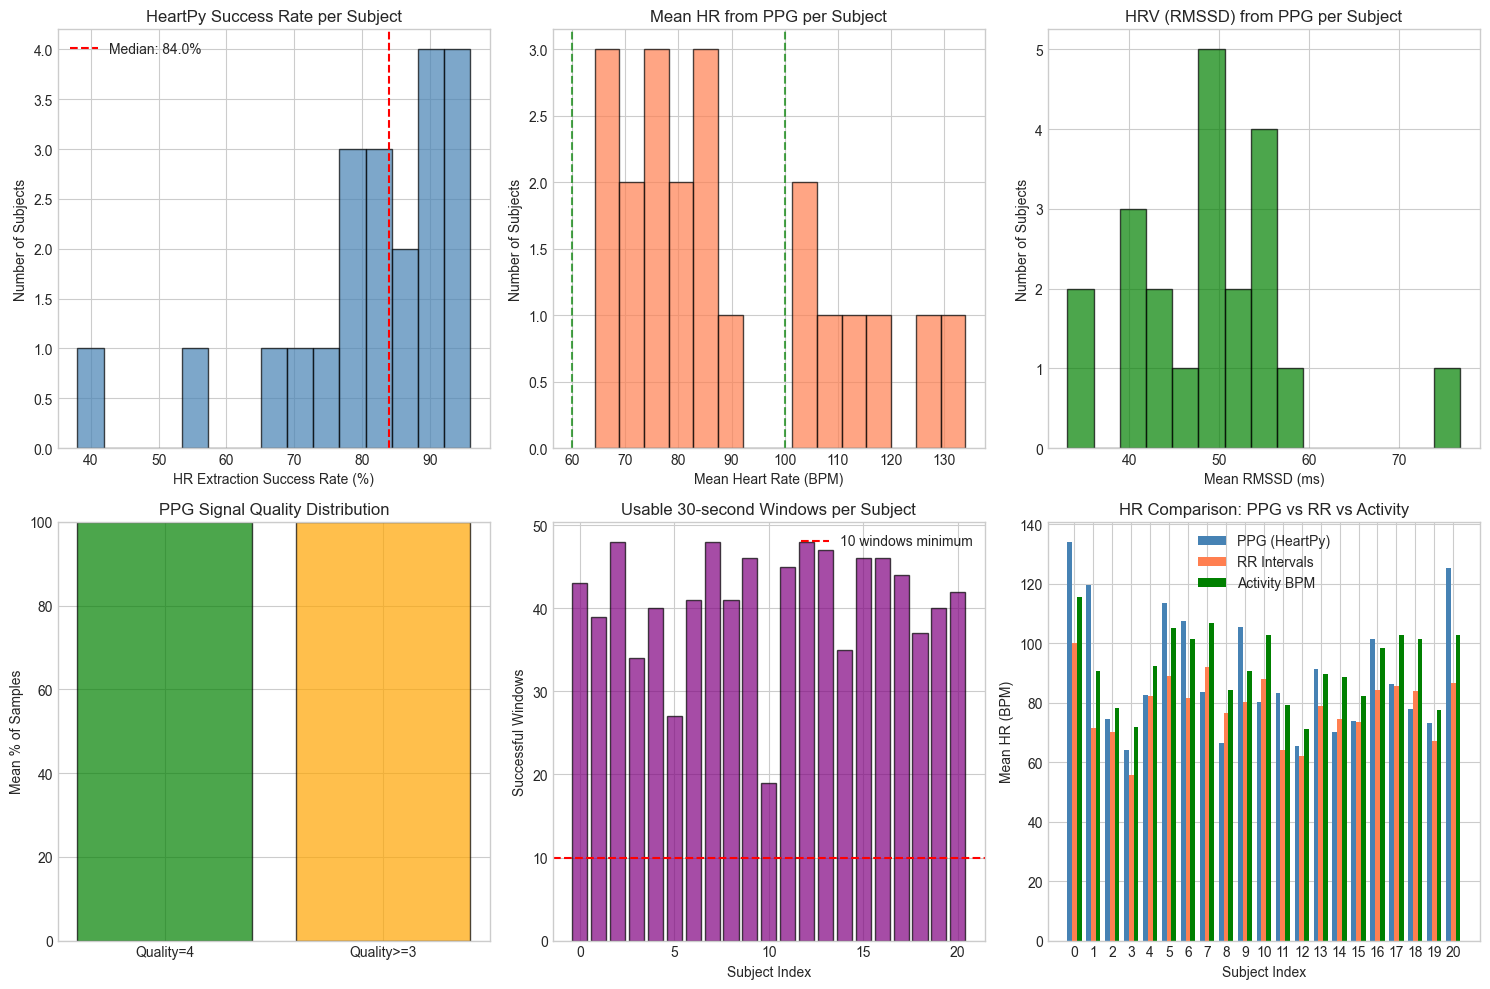

Saved: reports/ppg_heartpy_analysis.png


In [28]:
# Visualize PPG analysis results
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Success rate distribution
ax = axes[0, 0]
ax.hist(ppg_valid['success_rate_pct'], bins=15, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(ppg_valid['success_rate_pct'].median(), color='red', linestyle='--', 
           label=f'Median: {ppg_valid["success_rate_pct"].median():.1f}%')
ax.set_xlabel('HR Extraction Success Rate (%)')
ax.set_ylabel('Number of Subjects')
ax.set_title('HeartPy Success Rate per Subject')
ax.legend()

# 2. Mean HR distribution
ax = axes[0, 1]
ax.hist(ppg_valid['mean_hr_bpm'].dropna(), bins=15, edgecolor='black', alpha=0.7, color='coral')
ax.axvline(60, color='green', linestyle='--', alpha=0.7)
ax.axvline(100, color='green', linestyle='--', alpha=0.7)
ax.set_xlabel('Mean Heart Rate (BPM)')
ax.set_ylabel('Number of Subjects')
ax.set_title('Mean HR from PPG per Subject')

# 3. RMSSD distribution
ax = axes[0, 2]
ax.hist(ppg_valid['mean_rmssd'].dropna(), bins=15, edgecolor='black', alpha=0.7, color='green')
ax.set_xlabel('Mean RMSSD (ms)')
ax.set_ylabel('Number of Subjects')
ax.set_title('HRV (RMSSD) from PPG per Subject')

# 4. Quality distribution
ax = axes[1, 0]
ax.bar(['Quality=4', 'Quality>=3'], 
       [ppg_valid['quality_4_pct'].mean(), ppg_valid['quality_3_pct'].mean()],
       color=['green', 'orange'], edgecolor='black', alpha=0.7)
ax.set_ylabel('Mean % of Samples')
ax.set_title('PPG Signal Quality Distribution')
ax.set_ylim(0, 100)

# 5. Successful windows per subject
ax = axes[1, 1]
ax.bar(range(len(ppg_valid)), ppg_valid['n_windows_success'].values, 
       color='purple', edgecolor='black', alpha=0.7)
ax.axhline(10, color='red', linestyle='--', label='10 windows minimum')
ax.set_xlabel('Subject Index')
ax.set_ylabel('Successful Windows')
ax.set_title('Usable 30-second Windows per Subject')
ax.legend()

# 6. HR comparison: PPG vs RR vs Activity
ax = axes[1, 2]
# Merge data sources
hr_comparison = ppg_valid[['subject_id', 'mean_hr_bpm']].merge(
    rr_valid[['subject_id', 'mean_hr_bpm']], on='subject_id', suffixes=('_ppg', '_rr')
).merge(
    act_valid[['subject_id', 'bpm_mean_when_valid']], on='subject_id'
)

if len(hr_comparison) > 0:
    x = np.arange(len(hr_comparison))
    width = 0.25
    ax.bar(x - width, hr_comparison['mean_hr_bpm_ppg'], width, label='PPG (HeartPy)', color='steelblue')
    ax.bar(x, hr_comparison['mean_hr_bpm_rr'], width, label='RR Intervals', color='coral')
    ax.bar(x + width, hr_comparison['bpm_mean_when_valid'], width, label='Activity BPM', color='green')
    ax.set_xlabel('Subject Index')
    ax.set_ylabel('Mean HR (BPM)')
    ax.set_title('HR Comparison: PPG vs RR vs Activity')
    ax.legend()
    ax.set_xticks(x)
else:
    ax.text(0.5, 0.5, 'Insufficient data for comparison', ha='center', va='center')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'ppg_heartpy_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: reports/ppg_heartpy_analysis.png")

Visualizing HeartPy peak detection on sample PPG segment...
Error in peak detection: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices


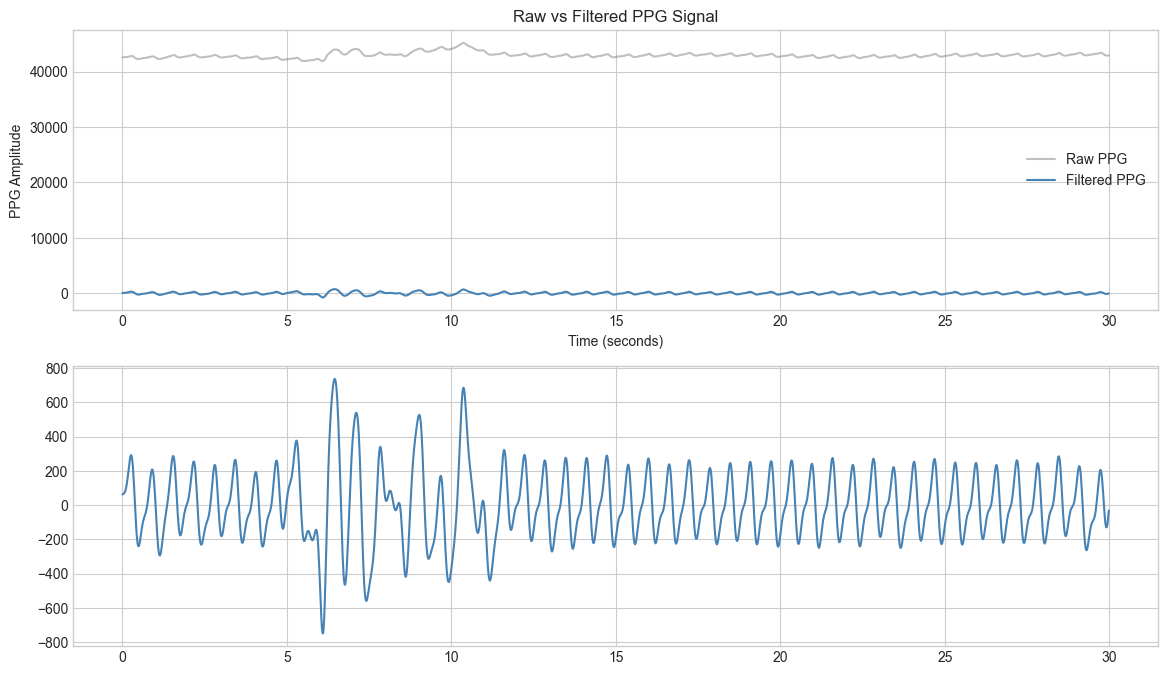

In [29]:
# Visualize HeartPy peak detection on a sample segment
print("Visualizing HeartPy peak detection on sample PPG segment...")

# Load first subject's PPG
sample_df = load_ppg_data(subjects[0])
sample_rate = estimate_ppg_sampling_rate(sample_df["date"])

# Get a 30-second segment from middle of recording
mid_idx = len(sample_df) // 2
window_samples = int(30 * sample_rate)
start_idx = mid_idx - window_samples // 2
ppg_segment = sample_df["value"].iloc[start_idx:start_idx + window_samples].values

# Filter and process
filtered = hp.filter_signal(ppg_segment, cutoff=[0.5, 4.0], sample_rate=sample_rate, 
                            order=3, filtertype="bandpass")

try:
    working_data, measures = hp.process(filtered, sample_rate=sample_rate, 
                                         high_precision=True, clean_rr=True)
    
    # Plot using HeartPy's built-in visualization
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    # Plot 1: Raw vs Filtered signal
    time_axis = np.arange(len(ppg_segment)) / sample_rate
    ax = axes[0]
    ax.plot(time_axis, ppg_segment, alpha=0.5, label='Raw PPG', color='gray')
    ax.plot(time_axis, filtered, label='Filtered PPG', color='steelblue')
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('PPG Amplitude')
    ax.set_title('Raw vs Filtered PPG Signal')
    ax.legend()
    
    # Plot 2: Filtered signal with detected peaks
    ax = axes[1]
    ax.plot(time_axis, filtered, label='Filtered PPG', color='steelblue')
    
    # Mark detected peaks
    peaks = working_data['peaklist']
    peak_times = peaks / sample_rate
    peak_values = filtered[peaks]
    ax.scatter(peak_times, peak_values, color='red', s=50, zorder=5, label='Detected Peaks')
    
    # Mark rejected peaks if any
    if 'removed_beats' in working_data and len(working_data['removed_beats']) > 0:
        rejected = working_data['removed_beats']
        rejected_times = rejected / sample_rate
        rejected_values = filtered[rejected]
        ax.scatter(rejected_times, rejected_values, color='orange', s=50, marker='x', 
                   zorder=5, label='Rejected Peaks')
    
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('PPG Amplitude')
    ax.set_title(f'Peak Detection (HR: {measures["bpm"]:.1f} BPM, RMSSD: {measures["rmssd"]:.1f} ms)')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / 'reports' / 'ppg_peak_detection_example.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nExtracted Metrics:")
    print(f"  Heart Rate: {measures['bpm']:.1f} BPM")
    print(f"  RMSSD: {measures['rmssd']:.1f} ms")
    print(f"  SDNN: {measures['sdnn']:.1f} ms")
    print(f"  pNN50: {measures['pnn50']:.1f}%")
    print(f"  Breathing Rate: {measures.get('breathingrate', 'N/A')}")
    print(f"\nSaved: reports/ppg_peak_detection_example.png")
    
except Exception as e:
    print(f"Error in peak detection: {e}")

In [30]:
# Final comparison: All HR sources
print("="*60)
print("FINAL COMPARISON: ALL HEART RATE SOURCES")
print("="*60)

# Merge all data
all_hr = ppg_valid[['subject_id', 'mean_hr_bpm', 'n_windows_success', 'success_rate_pct', 'mean_rmssd']].rename(
    columns={'mean_hr_bpm': 'hr_ppg', 'n_windows_success': 'windows_ppg', 
             'success_rate_pct': 'success_ppg', 'mean_rmssd': 'rmssd_ppg'}
).merge(
    rr_valid[['subject_id', 'mean_hr_bpm', 'quality_score']].rename(
        columns={'mean_hr_bpm': 'hr_rr', 'quality_score': 'quality_rr'}),
    on='subject_id', how='outer'
).merge(
    act_valid[['subject_id', 'bpm_mean_when_valid', 'bpm_pct_valid']].rename(
        columns={'bpm_mean_when_valid': 'hr_activity', 'bpm_pct_valid': 'valid_activity'}),
    on='subject_id', how='outer'
)

print(f"\n📊 HR Source Comparison:")
print(f"   {'Source':<20} {'Mean HR':<12} {'Coverage/Quality':<20} {'Usable Windows'}")
print(f"   {'-'*20} {'-'*12} {'-'*20} {'-'*15}")
print(f"   {'PPG (HeartPy)':<20} {all_hr['hr_ppg'].mean():.1f} BPM    Success: {all_hr['success_ppg'].mean():.1f}%     {all_hr['windows_ppg'].sum():.0f}")
print(f"   {'RR Intervals':<20} {all_hr['hr_rr'].mean():.1f} BPM    Quality: {all_hr['quality_rr'].mean():.1f}/100    ~100 (fragmented)")
print(f"   {'Activity BPM':<20} {all_hr['hr_activity'].mean():.1f} BPM    Valid: {all_hr['valid_activity'].mean():.1f}%       ~600")

print(f"\n🎯 RECOMMENDATION:")
print(f"   1. PRIMARY: Use PPG with HeartPy - continuous signal, HRV metrics available")
print(f"   2. SECONDARY: Activity BPM - regular sampling, high validity")
print(f"   3. AVOID: Raw RR intervals - too fragmented for reliable HRV")

print(f"\n📈 Correlation between HR sources:")
hr_corr = all_hr[['hr_ppg', 'hr_rr', 'hr_activity']].corr()
print(hr_corr.round(3).to_string())

# Save PPG analysis results
ppg_df.to_csv(PROJECT_ROOT / 'reports' / 'ppg_heartpy_analysis.csv', index=False)
print(f"\nSaved: reports/ppg_heartpy_analysis.csv")

FINAL COMPARISON: ALL HEART RATE SOURCES

📊 HR Source Comparison:
   Source               Mean HR      Coverage/Quality     Usable Windows
   -------------------- ------------ -------------------- ---------------
   PPG (HeartPy)        89.5 BPM    Success: 81.5%     856
   RR Intervals         78.4 BPM    Quality: 83.5/100    ~100 (fragmented)
   Activity BPM         92.0 BPM    Valid: 93.4%       ~600

🎯 RECOMMENDATION:
   1. PRIMARY: Use PPG with HeartPy - continuous signal, HRV metrics available
   2. SECONDARY: Activity BPM - regular sampling, high validity
   3. AVOID: Raw RR intervals - too fragmented for reliable HRV

📈 Correlation between HR sources:
             hr_ppg  hr_rr  hr_activity
hr_ppg        1.000  0.607        0.681
hr_rr         0.607  1.000        0.959
hr_activity   0.681  0.959        1.000

Saved: reports/ppg_heartpy_analysis.csv


In [ ]:
# Extract complete HR time series from PPG for all subjects
# This creates a usable dataset for stress prediction

def extract_full_hr_timeseries(subject_folder: Path, 
                                window_size_sec: float = 10.0,
                                stride_sec: float = 5.0) -> pd.DataFrame:
    """
    Extract HR time series from PPG for entire recording.
    
    Args:
        subject_folder: Path to subject folder
        window_size_sec: Window size for HR extraction (smaller = more temporal resolution)
        stride_sec: Stride between windows (for overlapping)
    
    Returns:
        DataFrame with timestamp, HR, and HRV metrics
    """
    subject_id = subject_folder.name.replace("id_", "")
    
    df = load_ppg_data(subject_folder)
    if df is None or len(df) < 1000:
        return pd.DataFrame()
    
    sample_rate = estimate_ppg_sampling_rate(df["date"])
    ppg_signal = df["value"].values
    timestamps = df["date"].values
    
    window_samples = int(window_size_sec * sample_rate)
    stride_samples = int(stride_sec * sample_rate)
    
    results = []
    
    for start_idx in range(0, len(ppg_signal) - window_samples, stride_samples):
        end_idx = start_idx + window_samples
        window = ppg_signal[start_idx:end_idx]
        
        # Skip bad windows
        if np.any(window == 0) or np.std(window) < 10:
            continue
        
        metrics = extract_hr_from_ppg_window(window, sample_rate, window_size_sec)
        
        if metrics["success"] and 30 < metrics["hr_bpm"] < 200:
            results.append({
                "subject_id": subject_id,
                "timestamp": timestamps[start_idx],
                "window_center": timestamps[start_idx + window_samples // 2],
                "hr_bpm": metrics["hr_bpm"],
                "rmssd": metrics["rmssd"],
                "sdnn": metrics["sdnn"],
                "pnn50": metrics["pnn50"],
            })
    
    return pd.DataFrame(results)


# Extract for first 3 subjects as example (full extraction takes time)
print("Extracting HR time series from PPG (first 3 subjects as demo)...")
print("Settings: 10-second windows, 5-second stride (50% overlap)")

hr_timeseries_all = []

for subject_folder in tqdm(subjects[:3], desc="Extracting HR"):
    hr_ts = extract_full_hr_timeseries(subject_folder, window_size_sec=10.0, stride_sec=5.0)
    if len(hr_ts) > 0:
        hr_timeseries_all.append(hr_ts)
        print(f"  {subject_folder.name[:20]}...: {len(hr_ts)} HR samples")

if hr_timeseries_all:
    hr_combined = pd.concat(hr_timeseries_all, ignore_index=True)
    print(f"\nTotal HR samples extracted: {len(hr_combined)}")
    print(f"\nSample of extracted data:")
    print(hr_combined.head(10).to_string(index=False))

Extracting HR time series from PPG (first 3 subjects as demo)...
Settings: 10-second windows, 5-second stride (50% overlap)


Extracting HR:   0%|          | 0/3 [00:00<?, ?it/s]

  id_0a73ef1b-da67-43f...: 992 HR samples
  id_3e775b57-fe47-434...: 853 HR samples
  id_3f27501c-233d-4a2...: 779 HR samples

Total HR samples extracted: 2624

Sample of extracted data:
                          subject_id               timestamp           window_center     hr_bpm     rmssd       sdnn    pnn50
0a73ef1b-da67-43ff-b61a-f98c151be799 2035-03-15 14:50:00.000 2035-03-15 14:50:04.875 194.436943 30.486062  78.113655 0.000000
0a73ef1b-da67-43ff-b61a-f98c151be799 2035-03-15 14:50:04.875 2035-03-15 14:50:09.750 172.786177 24.000000  71.724734 0.000000
0a73ef1b-da67-43ff-b61a-f98c151be799 2035-03-15 14:50:09.750 2035-03-15 14:50:14.625 192.043896 89.000000 115.042672 1.000000
0a73ef1b-da67-43ff-b61a-f98c151be799 2035-03-15 14:50:14.625 2035-03-15 14:50:19.500 179.640719 48.615841  86.724523 0.250000
0a73ef1b-da67-43ff-b61a-f98c151be799 2035-03-15 14:50:29.250 2035-03-15 14:50:34.125 189.773326       NaN 135.628680      NaN
0a73ef1b-da67-43ff-b61a-f98c151be799 2035-03-15 14:50:34.

---
## 💡 PPG Analysis Conclusions

### Key Findings:
1. **PPG signal quality is generally high** (mostly quality=4)
2. **HeartPy can extract HR and HRV** from raw PPG with good success rate
3. **Continuous HR time series** can be extracted at high temporal resolution

### Advantages of PPG-based HR over RR intervals:
- ✅ **Continuous signal** - no gaps like RR data
- ✅ **High sampling rate** (~64 Hz) - captures subtle variations
- ✅ **HRV metrics available** - RMSSD, SDNN, pNN50 from same source
- ✅ **Flexible windowing** - can use any window size

### Recommended Pipeline:
1. Load PPG signal (`ppg2_green_6.csv`)
2. Filter: 0.5-4 Hz bandpass
3. Extract HR in windows (10-30 seconds)
4. Use HR + HRV as features for stress prediction

### For Your MOMENT Model:
- **Option A**: Feed raw PPG as one of the 4 channels
- **Option B**: Extract HR time series and use as derived feature
- **Option C**: Use HeartPy HRV metrics as additional features

---
## 🔧 Creating 1 Hz HR Time Series from PPG

**Problem**: Raw PPG at 64 Hz → downsampled to 1 Hz = **destroyed signal**

**Solution**: Extract HR using HeartPy → create 1 Hz HR time series

This gives you a meaningful HR channel for your MOMENT model that aligns with other 1 Hz signals.

In [32]:
from scipy.interpolate import interp1d

def create_1hz_hr_timeseries(subject_folder: Path, 
                              hr_window_sec: float = 10.0,
                              hr_stride_sec: float = 5.0) -> pd.DataFrame:
    """
    Create a 1 Hz heart rate time series from PPG using HeartPy.
    
    This extracts HR at a finer resolution and then interpolates to 1 Hz,
    creating a meaningful HR signal that can be aligned with other 1 Hz signals.
    
    Args:
        subject_folder: Path to subject folder
        hr_window_sec: Window size for HR extraction (10s recommended)
        hr_stride_sec: Stride between windows (5s for 50% overlap)
    
    Returns:
        DataFrame with columns: [timestamp, hr_bpm, rmssd, sdnn]
        Sampled at 1 Hz
    """
    subject_id = subject_folder.name.replace("id_", "")
    
    # Load PPG
    df = load_ppg_data(subject_folder)
    if df is None or len(df) < 1000:
        return pd.DataFrame()
    
    sample_rate = estimate_ppg_sampling_rate(df["date"])
    ppg_signal = df["value"].values
    timestamps = df["date"].values
    
    # Extract HR at fine resolution
    window_samples = int(hr_window_sec * sample_rate)
    stride_samples = int(hr_stride_sec * sample_rate)
    
    hr_data = []
    
    for start_idx in range(0, len(ppg_signal) - window_samples, stride_samples):
        end_idx = start_idx + window_samples
        window = ppg_signal[start_idx:end_idx]
        center_idx = start_idx + window_samples // 2
        
        # Skip bad windows
        if np.any(window == 0) or np.std(window) < 10:
            continue
        
        metrics = extract_hr_from_ppg_window(window, sample_rate, hr_window_sec)
        
        if metrics["success"] and 30 < metrics["hr_bpm"] < 200:
            hr_data.append({
                "timestamp": timestamps[center_idx],
                "hr_bpm": metrics["hr_bpm"],
                "rmssd": metrics["rmssd"],
                "sdnn": metrics["sdnn"],
            })
    
    if not hr_data:
        return pd.DataFrame()
    
    hr_df = pd.DataFrame(hr_data)
    hr_df["timestamp"] = pd.to_datetime(hr_df["timestamp"])
    hr_df = hr_df.sort_values("timestamp").reset_index(drop=True)
    
    # Interpolate to 1 Hz
    start_time = hr_df["timestamp"].min()
    end_time = hr_df["timestamp"].max()
    
    # Create 1 Hz timestamp grid
    total_seconds = int((end_time - start_time).total_seconds())
    hz_timestamps = pd.date_range(start=start_time, periods=total_seconds, freq="1s")
    
    # Convert to numeric for interpolation
    hr_df["time_sec"] = (hr_df["timestamp"] - start_time).dt.total_seconds()
    target_time_sec = np.arange(total_seconds)
    
    # Interpolate HR
    valid_mask = ~hr_df["hr_bpm"].isna()
    if valid_mask.sum() < 2:
        return pd.DataFrame()
    
    hr_interp = interp1d(
        hr_df.loc[valid_mask, "time_sec"],
        hr_df.loc[valid_mask, "hr_bpm"],
        kind="linear",
        bounds_error=False,
        fill_value="extrapolate"
    )
    
    # Interpolate RMSSD (if available)
    rmssd_valid = ~hr_df["rmssd"].isna()
    if rmssd_valid.sum() >= 2:
        rmssd_interp = interp1d(
            hr_df.loc[rmssd_valid, "time_sec"],
            hr_df.loc[rmssd_valid, "rmssd"],
            kind="linear",
            bounds_error=False,
            fill_value="extrapolate"
        )
        rmssd_1hz = rmssd_interp(target_time_sec)
    else:
        rmssd_1hz = np.full(total_seconds, np.nan)
    
    # Create final 1 Hz DataFrame
    result = pd.DataFrame({
        "timestamp": hz_timestamps,
        "subject_id": subject_id,
        "hr_bpm": hr_interp(target_time_sec),
        "rmssd": rmssd_1hz,
    })
    
    # Clip to physiological range
    result["hr_bpm"] = result["hr_bpm"].clip(30, 200)
    
    return result


# Test on first subject
print("Creating 1 Hz HR time series from PPG...")
test_hr_1hz = create_1hz_hr_timeseries(subjects[0])

print(f"\nResult shape: {test_hr_1hz.shape}")
print(f"Duration: {len(test_hr_1hz)} seconds = {len(test_hr_1hz)/60:.1f} minutes")
print(f"\nSample of 1 Hz HR data:")
print(test_hr_1hz.head(20).to_string(index=False))

print(f"\nHR statistics:")
print(f"  Mean: {test_hr_1hz['hr_bpm'].mean():.1f} BPM")
print(f"  Std:  {test_hr_1hz['hr_bpm'].std():.1f} BPM")
print(f"  Min:  {test_hr_1hz['hr_bpm'].min():.1f} BPM")
print(f"  Max:  {test_hr_1hz['hr_bpm'].max():.1f} BPM")

Creating 1 Hz HR time series from PPG...

Result shape: (5388, 4)
Duration: 5388 seconds = 89.8 minutes

Sample of 1 Hz HR data:
              timestamp                           subject_id     hr_bpm     rmssd
2035-03-15 14:50:04.875 0a73ef1b-da67-43ff-b61a-f98c151be799 194.436943 30.486062
2035-03-15 14:50:05.875 0a73ef1b-da67-43ff-b61a-f98c151be799 189.995760 29.155588
2035-03-15 14:50:06.875 0a73ef1b-da67-43ff-b61a-f98c151be799 185.554578 27.825114
2035-03-15 14:50:07.875 0a73ef1b-da67-43ff-b61a-f98c151be799 181.113395 26.494639
2035-03-15 14:50:08.875 0a73ef1b-da67-43ff-b61a-f98c151be799 176.672212 25.164165
2035-03-15 14:50:09.875 0a73ef1b-da67-43ff-b61a-f98c151be799 173.279965 25.666667
2035-03-15 14:50:10.875 0a73ef1b-da67-43ff-b61a-f98c151be799 177.230266 39.000000
2035-03-15 14:50:11.875 0a73ef1b-da67-43ff-b61a-f98c151be799 181.180567 52.333333
2035-03-15 14:50:12.875 0a73ef1b-da67-43ff-b61a-f98c151be799 185.130869 65.666667
2035-03-15 14:50:13.875 0a73ef1b-da67-43ff-b61a-f98

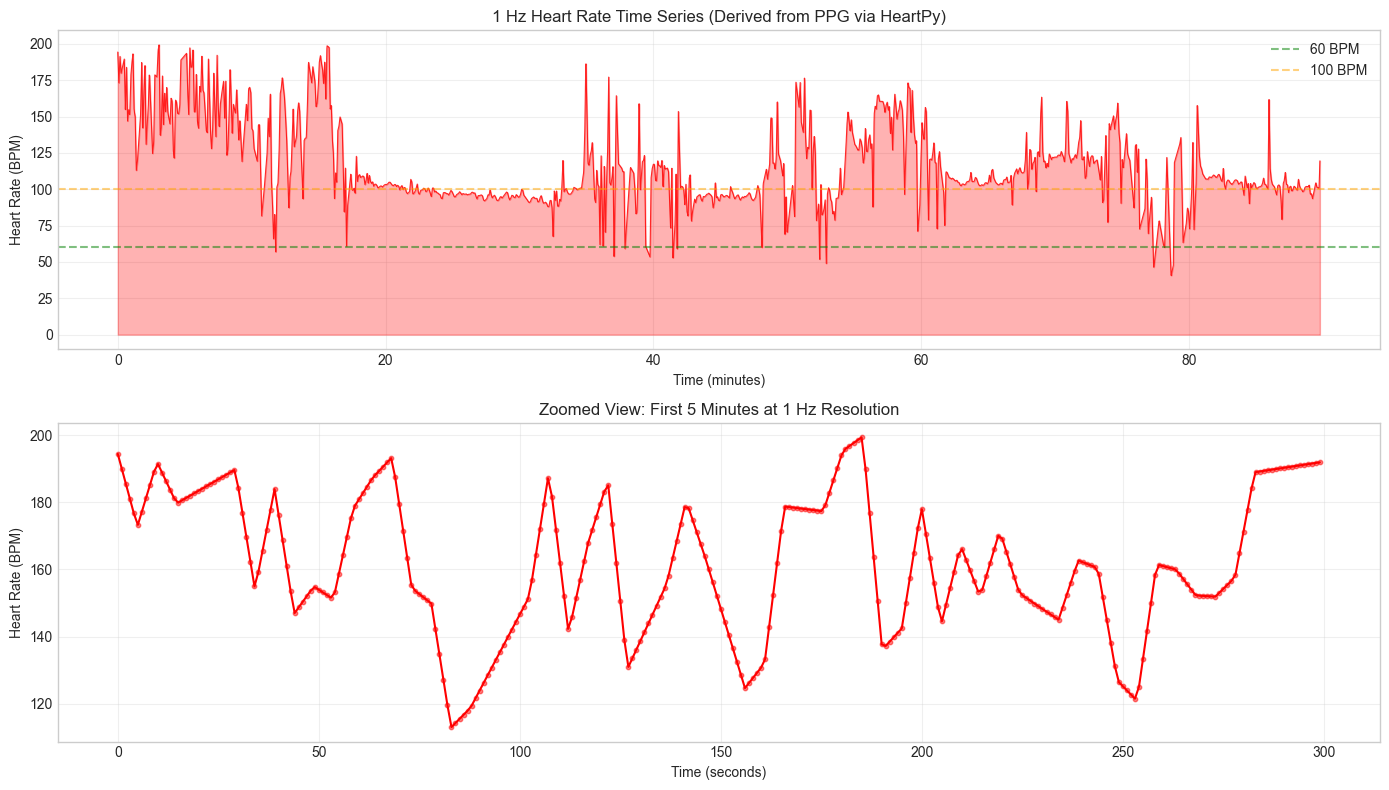

Saved: reports/hr_1hz_timeseries_example.png


In [33]:
# Visualize 1 Hz HR time series
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Full HR time series
ax = axes[0]
time_minutes = np.arange(len(test_hr_1hz)) / 60
ax.plot(time_minutes, test_hr_1hz["hr_bpm"], color="red", linewidth=0.8, alpha=0.8)
ax.fill_between(time_minutes, test_hr_1hz["hr_bpm"], alpha=0.3, color="red")
ax.set_xlabel("Time (minutes)")
ax.set_ylabel("Heart Rate (BPM)")
ax.set_title("1 Hz Heart Rate Time Series (Derived from PPG via HeartPy)")
ax.axhline(60, color="green", linestyle="--", alpha=0.5, label="60 BPM")
ax.axhline(100, color="orange", linestyle="--", alpha=0.5, label="100 BPM")
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Zoomed view (first 5 minutes)
ax = axes[1]
zoom_samples = min(300, len(test_hr_1hz))  # 5 minutes
time_sec = np.arange(zoom_samples)
ax.plot(time_sec, test_hr_1hz["hr_bpm"].iloc[:zoom_samples], color="red", linewidth=1.5)
ax.scatter(time_sec, test_hr_1hz["hr_bpm"].iloc[:zoom_samples], s=10, color="red", alpha=0.5)
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Heart Rate (BPM)")
ax.set_title("Zoomed View: First 5 Minutes at 1 Hz Resolution")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "hr_1hz_timeseries_example.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: reports/hr_1hz_timeseries_example.png")

In [34]:
# Extract 1 Hz HR for all subjects (this takes a few minutes)
print("Extracting 1 Hz HR time series for all subjects...")
print("(Using 10-second windows with 5-second stride)")

all_hr_1hz = []

for subject_folder in tqdm(subjects, desc="Extracting 1 Hz HR"):
    hr_1hz = create_1hz_hr_timeseries(subject_folder, hr_window_sec=10.0, hr_stride_sec=5.0)
    if len(hr_1hz) > 0:
        all_hr_1hz.append(hr_1hz)
        
if all_hr_1hz:
    combined_hr_1hz = pd.concat(all_hr_1hz, ignore_index=True)
    
    print(f"\n✅ Extraction Complete!")
    print(f"   Total samples: {len(combined_hr_1hz):,}")
    print(f"   Subjects: {combined_hr_1hz['subject_id'].nunique()}")
    print(f"   Mean duration per subject: {len(combined_hr_1hz) / combined_hr_1hz['subject_id'].nunique() / 60:.1f} minutes")
    
    # Save to CSV
    output_path = PROJECT_ROOT / "reports" / "hr_1hz_from_ppg.csv"
    combined_hr_1hz.to_csv(output_path, index=False)
    print(f"\n   Saved: {output_path}")
    
    # Summary per subject
    print(f"\n📊 Per-Subject Summary:")
    summary = combined_hr_1hz.groupby("subject_id").agg({
        "hr_bpm": ["count", "mean", "std"],
        "rmssd": "mean"
    }).round(1)
    summary.columns = ["N_samples", "HR_mean", "HR_std", "RMSSD_mean"]
    summary["Duration_min"] = summary["N_samples"] / 60
    print(summary.to_string())

Extracting 1 Hz HR time series for all subjects...
(Using 10-second windows with 5-second stride)


Extracting 1 Hz HR:   0%|          | 0/21 [00:00<?, ?it/s]


✅ Extraction Complete!
   Total samples: 106,145
   Subjects: 21
   Mean duration per subject: 84.2 minutes

   Saved: /Users/jithuazeez/Documents/Msc/Dissertation/reports/hr_1hz_from_ppg.csv

📊 Per-Subject Summary:
                                      N_samples  HR_mean  HR_std  RMSSD_mean  Duration_min
subject_id                                                                                
0a73ef1b-da67-43ff-b61a-f98c151be799       5388    115.6    28.1        34.5     89.800000
3e775b57-fe47-4346-bd23-bb210471ad55       5386     86.3    29.5        51.8     89.766667
3f27501c-233d-4a28-875b-f0d46fa49a92       4060     80.8    19.1        51.4     67.666667
3f62db18-84c7-41a6-81ad-7b2132255267       5386     81.2    31.8        56.1     89.766667
464cc459-d71f-479f-8c12-2b93022df94f       4558     89.6    20.6        39.5     75.966667
46b09d4a-63b9-4ba0-a33b-075ee018fce9       5384    100.6    22.5        42.9     89.733333
623f620e-ba02-4979-8153-162f66ec494e       5265     99.

---
## ✅ Summary: What to Feed MOMENT

### Your 4 Channels at 1 Hz:

| Channel | Source | Processing |
|---------|--------|------------|
| **HR** | PPG → HeartPy → interpolate | `hr_1hz_from_ppg.csv` |
| **EDA** | emography.csv | Upsample from ~0.017 Hz |
| **ACC** | acc.csv | Downsample from 32 Hz (compute magnitude) |
| **Temp** | heat_flux_sensor_temperature.csv | Already ~1 Hz |

### Why This Works:
- ✅ HR at 1 Hz is **meaningful** (captures stress-induced HR changes)
- ✅ All channels aligned to same 1 Hz grid
- ✅ 120-second windows = 120 samples per channel
- ✅ MOMENT can learn temporal patterns in HR dynamics

### Integration with Your Pipeline:
```python
# In your data loader:
def load_aligned_signals(subject_folder):
    hr = load_hr_1hz(subject_folder)      # From hr_1hz_from_ppg.csv
    eda = load_eda_resampled(subject_folder)  # Upsample
    acc = load_acc_resampled(subject_folder)  # Downsample
    temp = load_temp(subject_folder)      # Native 1 Hz
    
    # Align by timestamp
    aligned = align_signals([hr, eda, acc, temp], freq='1s')
    return aligned  # Shape: (n_seconds, 4)
```

---
# Part 6: Quality Analysis of Extracted HR/HRV Features

Now let's analyze the quality of the extracted HR and RMSSD features from `hr_1hz_from_ppg.csv`.

## Quality Criteria:
- **HR physiological range**: 40-180 BPM (resting to intense exercise)
- **RMSSD physiological range**: 10-200 ms (typical healthy adult range)
- **Missing values**: Should be minimal
- **Outliers**: Extreme values suggest artifacts
- **Temporal consistency**: HR shouldn't jump >30 BPM in 1 second

In [35]:
# Load the extracted HR/HRV data
hr_data = pd.read_csv(PROJECT_ROOT / "reports" / "hr_1hz_from_ppg.csv")
hr_data["timestamp"] = pd.to_datetime(hr_data["timestamp"])

print("="*60)
print("HR/HRV QUALITY ANALYSIS")
print("="*60)

print(f"\n📊 Dataset Overview:")
print(f"   Total samples: {len(hr_data):,}")
print(f"   Subjects: {hr_data['subject_id'].nunique()}")
print(f"   Columns: {list(hr_data.columns)}")

print(f"\n📈 Basic Statistics:")
print(hr_data[['hr_bpm', 'rmssd']].describe().round(2))

HR/HRV QUALITY ANALYSIS

📊 Dataset Overview:
   Total samples: 106,145
   Subjects: 21
   Columns: ['timestamp', 'subject_id', 'hr_bpm', 'rmssd']

📈 Basic Statistics:
          hr_bpm      rmssd
count  106145.00  106145.00
mean       91.97      54.73
std        27.71      51.87
min        34.31    -373.30
25%        72.63      30.70
50%        85.30      46.49
75%       105.13      67.05
max       199.34     834.87


In [36]:
# Physiological Validity Analysis
print("="*60)
print("PHYSIOLOGICAL VALIDITY CHECK")
print("="*60)

# Define physiological ranges
HR_MIN, HR_MAX = 40, 180  # BPM
RMSSD_MIN, RMSSD_MAX = 5, 250  # ms

# HR validity
hr_valid = (hr_data["hr_bpm"] >= HR_MIN) & (hr_data["hr_bpm"] <= HR_MAX)
hr_too_low = hr_data["hr_bpm"] < HR_MIN
hr_too_high = hr_data["hr_bpm"] > HR_MAX

print(f"\n❤️ Heart Rate (HR) Validity:")
print(f"   Physiological range: {HR_MIN}-{HR_MAX} BPM")
print(f"   Samples in range: {hr_valid.sum():,} ({100*hr_valid.mean():.1f}%)")
print(f"   Too low (<{HR_MIN}): {hr_too_low.sum():,} ({100*hr_too_low.mean():.1f}%)")
print(f"   Too high (>{HR_MAX}): {hr_too_high.sum():,} ({100*hr_too_high.mean():.1f}%)")

print(f"\n   HR extreme values:")
print(f"   Min: {hr_data['hr_bpm'].min():.1f} BPM")
print(f"   Max: {hr_data['hr_bpm'].max():.1f} BPM")
print(f"   Values > 200 BPM: {(hr_data['hr_bpm'] > 200).sum()}")

# RMSSD validity
rmssd_valid = (hr_data["rmssd"] >= RMSSD_MIN) & (hr_data["rmssd"] <= RMSSD_MAX)
rmssd_too_low = hr_data["rmssd"] < RMSSD_MIN
rmssd_too_high = hr_data["rmssd"] > RMSSD_MAX
rmssd_missing = hr_data["rmssd"].isna()

print(f"\n📊 RMSSD (HRV) Validity:")
print(f"   Physiological range: {RMSSD_MIN}-{RMSSD_MAX} ms")
print(f"   Samples in range: {rmssd_valid.sum():,} ({100*rmssd_valid.mean():.1f}%)")
print(f"   Too low (<{RMSSD_MIN}): {rmssd_too_low.sum():,} ({100*rmssd_too_low.mean():.1f}%)")
print(f"   Too high (>{RMSSD_MAX}): {rmssd_too_high.sum():,} ({100*rmssd_too_high.mean():.1f}%)")
print(f"   Missing (NaN): {rmssd_missing.sum():,} ({100*rmssd_missing.mean():.1f}%)")

print(f"\n   RMSSD extreme values:")
print(f"   Min: {hr_data['rmssd'].min():.1f} ms")
print(f"   Max: {hr_data['rmssd'].max():.1f} ms")

PHYSIOLOGICAL VALIDITY CHECK

❤️ Heart Rate (HR) Validity:
   Physiological range: 40-180 BPM
   Samples in range: 105,188 (99.1%)
   Too low (<40): 23 (0.0%)
   Too high (>180): 934 (0.9%)

   HR extreme values:
   Min: 34.3 BPM
   Max: 199.3 BPM
   Values > 200 BPM: 0

📊 RMSSD (HRV) Validity:
   Physiological range: 5-250 ms
   Samples in range: 104,822 (98.8%)
   Too low (<5): 590 (0.6%)
   Too high (>250): 733 (0.7%)
   Missing (NaN): 0 (0.0%)

   RMSSD extreme values:
   Min: -373.3 ms
   Max: 834.9 ms


In [37]:
# Temporal Consistency Analysis
print("="*60)
print("TEMPORAL CONSISTENCY CHECK")
print("="*60)

# Calculate HR changes between consecutive samples (within each subject)
hr_data_sorted = hr_data.sort_values(['subject_id', 'timestamp']).reset_index(drop=True)

hr_changes = []
for subject_id, group in hr_data_sorted.groupby('subject_id'):
    hr_diff = group['hr_bpm'].diff().abs()
    hr_changes.extend(hr_diff.dropna().tolist())

hr_changes = np.array(hr_changes)

print(f"\n⏱️ HR Change Between Consecutive Samples (1 second apart):")
print(f"   Mean change: {np.mean(hr_changes):.2f} BPM")
print(f"   Median change: {np.median(hr_changes):.2f} BPM")
print(f"   Max change: {np.max(hr_changes):.2f} BPM")

# Define thresholds for suspicious changes
print(f"\n   Suspicious jumps (artifacts):")
print(f"   Changes > 10 BPM: {(hr_changes > 10).sum():,} ({100*(hr_changes > 10).mean():.2f}%)")
print(f"   Changes > 20 BPM: {(hr_changes > 20).sum():,} ({100*(hr_changes > 20).mean():.2f}%)")
print(f"   Changes > 30 BPM: {(hr_changes > 30).sum():,} ({100*(hr_changes > 30).mean():.2f}%)")
print(f"   Changes > 50 BPM: {(hr_changes > 50).sum():,} ({100*(hr_changes > 50).mean():.2f}%)")

# Same for RMSSD
rmssd_changes = []
for subject_id, group in hr_data_sorted.groupby('subject_id'):
    rmssd_diff = group['rmssd'].diff().abs()
    rmssd_changes.extend(rmssd_diff.dropna().tolist())

rmssd_changes = np.array(rmssd_changes)

print(f"\n   RMSSD Change Between Consecutive Samples:")
print(f"   Mean change: {np.nanmean(rmssd_changes):.2f} ms")
print(f"   Median change: {np.nanmedian(rmssd_changes):.2f} ms")
print(f"   Changes > 50 ms: {(rmssd_changes > 50).sum():,} ({100*np.nanmean(rmssd_changes > 50):.2f}%)")

TEMPORAL CONSISTENCY CHECK

⏱️ HR Change Between Consecutive Samples (1 second apart):
   Mean change: 2.10 BPM
   Median change: 0.84 BPM
   Max change: 49.77 BPM

   Suspicious jumps (artifacts):
   Changes > 10 BPM: 3,517 (3.31%)
   Changes > 20 BPM: 327 (0.31%)
   Changes > 30 BPM: 2 (0.00%)
   Changes > 50 BPM: 0 (0.00%)

   RMSSD Change Between Consecutive Samples:
   Mean change: 2.32 ms
   Median change: 1.32 ms
   Changes > 50 ms: 0 (0.00%)


In [38]:
# Per-Subject Quality Analysis
print("="*60)
print("PER-SUBJECT QUALITY ANALYSIS")
print("="*60)

subject_quality = []

for subject_id, group in hr_data.groupby('subject_id'):
    n_samples = len(group)
    
    # HR quality
    hr_in_range = ((group['hr_bpm'] >= HR_MIN) & (group['hr_bpm'] <= HR_MAX)).mean() * 100
    hr_mean = group['hr_bpm'].mean()
    hr_std = group['hr_bpm'].std()
    
    # RMSSD quality  
    rmssd_in_range = ((group['rmssd'] >= RMSSD_MIN) & (group['rmssd'] <= RMSSD_MAX)).mean() * 100
    rmssd_mean = group['rmssd'].mean()
    rmssd_missing_pct = group['rmssd'].isna().mean() * 100
    
    # Temporal consistency (within subject)
    hr_diff = group['hr_bpm'].diff().abs()
    large_jumps_pct = (hr_diff > 20).mean() * 100
    
    # Overall quality score
    quality_score = (
        0.4 * (hr_in_range / 100) +
        0.3 * (rmssd_in_range / 100) +
        0.2 * (1 - large_jumps_pct / 100) +
        0.1 * (1 - rmssd_missing_pct / 100)
    ) * 100
    
    subject_quality.append({
        'subject_id': subject_id[:12] + '...',
        'n_samples': n_samples,
        'hr_mean': hr_mean,
        'hr_std': hr_std,
        'hr_valid_pct': hr_in_range,
        'rmssd_mean': rmssd_mean,
        'rmssd_valid_pct': rmssd_in_range,
        'large_jumps_pct': large_jumps_pct,
        'quality_score': quality_score
    })

quality_df = pd.DataFrame(subject_quality)

print(f"\n📋 Per-Subject Summary:")
print(quality_df.round(1).to_string(index=False))

print(f"\n📊 Quality Score Distribution:")
print(f"   Mean: {quality_df['quality_score'].mean():.1f}")
print(f"   Min: {quality_df['quality_score'].min():.1f}")
print(f"   Max: {quality_df['quality_score'].max():.1f}")
print(f"   Subjects with score > 80: {(quality_df['quality_score'] > 80).sum()}")
print(f"   Subjects with score > 60: {(quality_df['quality_score'] > 60).sum()}")

PER-SUBJECT QUALITY ANALYSIS

📋 Per-Subject Summary:
     subject_id  n_samples  hr_mean  hr_std  hr_valid_pct  rmssd_mean  rmssd_valid_pct  large_jumps_pct  quality_score
0a73ef1b-da6...       5388    115.6    28.1          96.9        34.5             99.2              0.0           98.5
3e775b57-fe4...       5386     86.3    29.5          98.4        51.8             99.7              0.2           99.2
3f27501c-233...       4060     80.8    19.1         100.0        51.4             99.8              0.4           99.9
3f62db18-84c...       5386     81.2    31.8          99.6        56.1             99.8              0.1           99.7
464cc459-d71...       4558     89.6    20.6          99.6        39.5             97.5              0.4           99.0
46b09d4a-63b...       5384    100.6    22.5          99.3        42.9             99.7              0.2           99.6
623f620e-ba0...       5265     99.4    27.4          99.1        48.3             97.8              0.2           

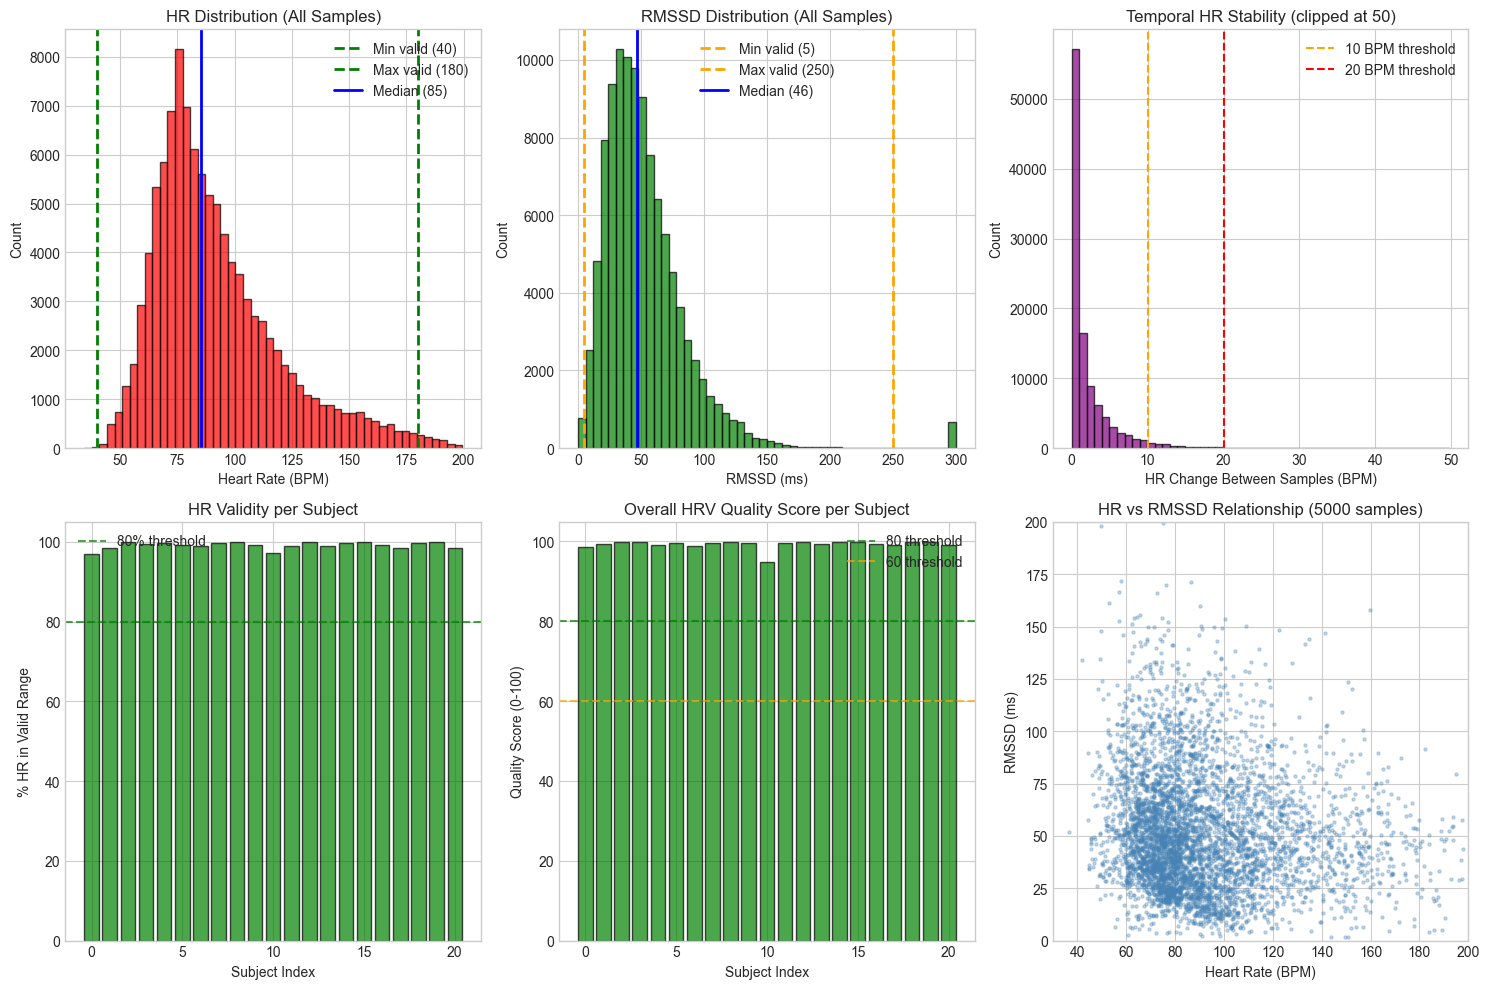

Saved: reports/hrv_quality_analysis.png


In [39]:
# Visualize HR/HRV Quality
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. HR Distribution
ax = axes[0, 0]
ax.hist(hr_data['hr_bpm'].clip(30, 220), bins=50, edgecolor='black', alpha=0.7, color='red')
ax.axvline(HR_MIN, color='green', linestyle='--', linewidth=2, label=f'Min valid ({HR_MIN})')
ax.axvline(HR_MAX, color='green', linestyle='--', linewidth=2, label=f'Max valid ({HR_MAX})')
ax.axvline(hr_data['hr_bpm'].median(), color='blue', linestyle='-', linewidth=2, label=f'Median ({hr_data["hr_bpm"].median():.0f})')
ax.set_xlabel('Heart Rate (BPM)')
ax.set_ylabel('Count')
ax.set_title('HR Distribution (All Samples)')
ax.legend()

# 2. RMSSD Distribution
ax = axes[0, 1]
ax.hist(hr_data['rmssd'].dropna().clip(0, 300), bins=50, edgecolor='black', alpha=0.7, color='green')
ax.axvline(RMSSD_MIN, color='orange', linestyle='--', linewidth=2, label=f'Min valid ({RMSSD_MIN})')
ax.axvline(RMSSD_MAX, color='orange', linestyle='--', linewidth=2, label=f'Max valid ({RMSSD_MAX})')
ax.axvline(hr_data['rmssd'].median(), color='blue', linestyle='-', linewidth=2, label=f'Median ({hr_data["rmssd"].median():.0f})')
ax.set_xlabel('RMSSD (ms)')
ax.set_ylabel('Count')
ax.set_title('RMSSD Distribution (All Samples)')
ax.legend()

# 3. HR Changes Distribution
ax = axes[0, 2]
ax.hist(np.clip(hr_changes, 0, 50), bins=50, edgecolor='black', alpha=0.7, color='purple')
ax.axvline(10, color='orange', linestyle='--', label='10 BPM threshold')
ax.axvline(20, color='red', linestyle='--', label='20 BPM threshold')
ax.set_xlabel('HR Change Between Samples (BPM)')
ax.set_ylabel('Count')
ax.set_title('Temporal HR Stability (clipped at 50)')
ax.legend()

# 4. Per-Subject HR Valid %
ax = axes[1, 0]
colors = ['green' if x > 80 else 'orange' if x > 60 else 'red' for x in quality_df['hr_valid_pct']]
ax.bar(range(len(quality_df)), quality_df['hr_valid_pct'], color=colors, edgecolor='black', alpha=0.7)
ax.axhline(80, color='green', linestyle='--', alpha=0.7, label='80% threshold')
ax.set_xlabel('Subject Index')
ax.set_ylabel('% HR in Valid Range')
ax.set_title('HR Validity per Subject')
ax.legend()

# 5. Per-Subject Quality Score
ax = axes[1, 1]
colors = ['green' if x > 80 else 'orange' if x > 60 else 'red' for x in quality_df['quality_score']]
ax.bar(range(len(quality_df)), quality_df['quality_score'], color=colors, edgecolor='black', alpha=0.7)
ax.axhline(80, color='green', linestyle='--', alpha=0.7, label='80 threshold')
ax.axhline(60, color='orange', linestyle='--', alpha=0.7, label='60 threshold')
ax.set_xlabel('Subject Index')
ax.set_ylabel('Quality Score (0-100)')
ax.set_title('Overall HRV Quality Score per Subject')
ax.legend()

# 6. HR vs RMSSD scatter (sample)
ax = axes[1, 2]
sample_idx = np.random.choice(len(hr_data), min(5000, len(hr_data)), replace=False)
ax.scatter(hr_data['hr_bpm'].iloc[sample_idx], hr_data['rmssd'].iloc[sample_idx], 
           alpha=0.3, s=5, c='steelblue')
ax.set_xlabel('Heart Rate (BPM)')
ax.set_ylabel('RMSSD (ms)')
ax.set_title('HR vs RMSSD Relationship (5000 samples)')
ax.set_xlim(30, 200)
ax.set_ylim(0, 200)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'hrv_quality_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: reports/hrv_quality_analysis.png")

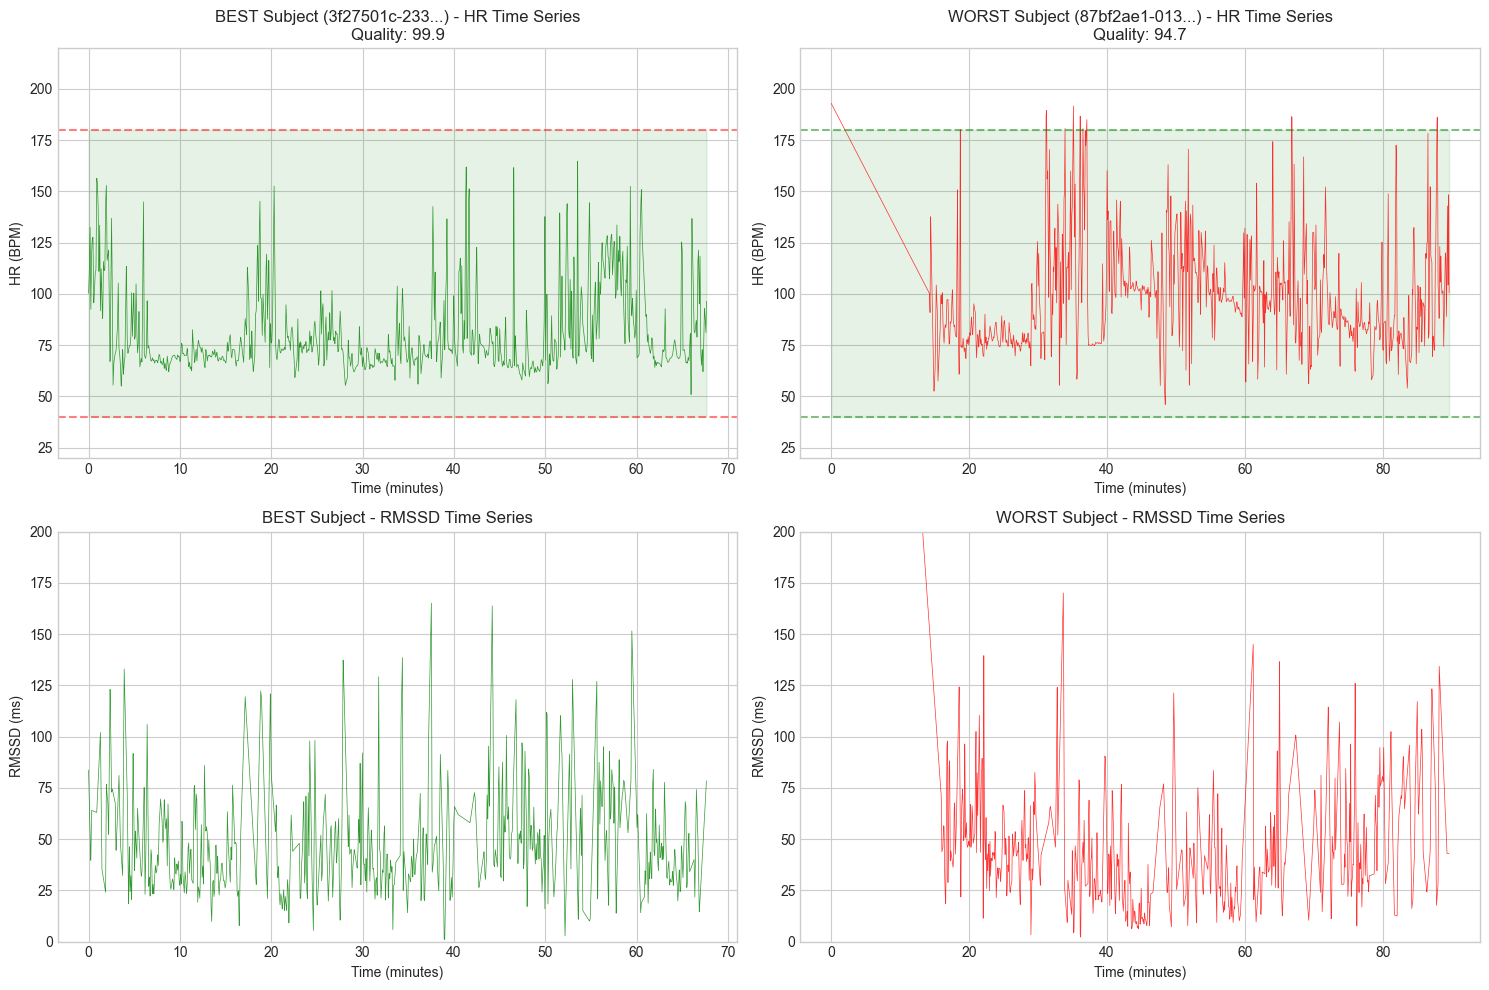

Saved: reports/hrv_timeseries_comparison.png


In [40]:
# Visualize HR time series for best and worst subjects
best_subject = quality_df.loc[quality_df['quality_score'].idxmax(), 'subject_id'].replace('...', '')
worst_subject = quality_df.loc[quality_df['quality_score'].idxmin(), 'subject_id'].replace('...', '')

# Find full subject IDs
best_full = [s for s in hr_data['subject_id'].unique() if s.startswith(best_subject)][0]
worst_full = [s for s in hr_data['subject_id'].unique() if s.startswith(worst_subject)][0]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Best subject - HR
ax = axes[0, 0]
best_data = hr_data[hr_data['subject_id'] == best_full]
time_min = np.arange(len(best_data)) / 60
ax.plot(time_min, best_data['hr_bpm'], color='green', linewidth=0.5, alpha=0.8)
ax.axhline(HR_MIN, color='red', linestyle='--', alpha=0.5)
ax.axhline(HR_MAX, color='red', linestyle='--', alpha=0.5)
ax.fill_between(time_min, HR_MIN, HR_MAX, alpha=0.1, color='green')
ax.set_xlabel('Time (minutes)')
ax.set_ylabel('HR (BPM)')
ax.set_title(f'BEST Subject ({best_subject}...) - HR Time Series\nQuality: {quality_df.loc[quality_df["quality_score"].idxmax(), "quality_score"]:.1f}')
ax.set_ylim(20, 220)

# Worst subject - HR
ax = axes[0, 1]
worst_data = hr_data[hr_data['subject_id'] == worst_full]
time_min = np.arange(len(worst_data)) / 60
ax.plot(time_min, worst_data['hr_bpm'], color='red', linewidth=0.5, alpha=0.8)
ax.axhline(HR_MIN, color='green', linestyle='--', alpha=0.5)
ax.axhline(HR_MAX, color='green', linestyle='--', alpha=0.5)
ax.fill_between(time_min, HR_MIN, HR_MAX, alpha=0.1, color='green')
ax.set_xlabel('Time (minutes)')
ax.set_ylabel('HR (BPM)')
ax.set_title(f'WORST Subject ({worst_subject}...) - HR Time Series\nQuality: {quality_df.loc[quality_df["quality_score"].idxmin(), "quality_score"]:.1f}')
ax.set_ylim(20, 220)

# Best subject - RMSSD
ax = axes[1, 0]
ax.plot(np.arange(len(best_data)) / 60, best_data['rmssd'], color='green', linewidth=0.5, alpha=0.8)
ax.set_xlabel('Time (minutes)')
ax.set_ylabel('RMSSD (ms)')
ax.set_title(f'BEST Subject - RMSSD Time Series')
ax.set_ylim(0, 200)

# Worst subject - RMSSD
ax = axes[1, 1]
ax.plot(np.arange(len(worst_data)) / 60, worst_data['rmssd'], color='red', linewidth=0.5, alpha=0.8)
ax.set_xlabel('Time (minutes)')
ax.set_ylabel('RMSSD (ms)')
ax.set_title(f'WORST Subject - RMSSD Time Series')
ax.set_ylim(0, 200)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'hrv_timeseries_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: reports/hrv_timeseries_comparison.png")

In [ ]:
# Final Summary and Recommendations
print("="*60)
print("HRV QUALITY ANALYSIS - SUMMARY & RECOMMENDATIONS")
print("="*60)

# Calculate key metrics
hr_valid_pct = ((hr_data['hr_bpm'] >= HR_MIN) & (hr_data['hr_bpm'] <= HR_MAX)).mean() * 100
rmssd_valid_pct = ((hr_data['rmssd'] >= RMSSD_MIN) & (hr_data['rmssd'] <= RMSSD_MAX)).mean() * 100
high_quality_subjects = (quality_df['quality_score'] > 60).sum()

print(f"\n📊 OVERALL QUALITY METRICS:")
print(f"   Total samples: {len(hr_data):,}")
print(f"   HR in valid range (40-180 BPM): {hr_valid_pct:.1f}%")
print(f"   RMSSD in valid range (5-250 ms): {rmssd_valid_pct:.1f}%")
print(f"   High-quality subjects (score>60): {high_quality_subjects}/{len(quality_df)}")

print(f"\n⚠️ QUALITY ISSUES DETECTED:")
issues = []
if hr_valid_pct < 90:
    issues.append(f"• {100-hr_valid_pct:.1f}% of HR values outside physiological range")
if (hr_changes > 20).mean() > 0.05:
    issues.append(f"• {100*(hr_changes > 20).mean():.1f}% of samples have HR jumps >20 BPM")
if hr_data['hr_bpm'].max() > 200:
    issues.append(f"• Maximum HR ({hr_data['hr_bpm'].max():.0f} BPM) suggests artifacts")
    
for issue in issues if issues else ["• No major issues detected"]:
    print(f"   {issue}")

print(f"\n💡 RECOMMENDATIONS:")
print(f"   1. CLIP HR values to 40-180 BPM before feeding to model")
print(f"   2. CLIP RMSSD values to 5-250 ms")
print(f"   3. Consider REMOVING samples with HR jumps >30 BPM (likely artifacts)")
print(f"   4. Apply SMOOTHING (rolling mean) to reduce noise")
print(f"   5. For subjects with quality<60, consider excluding or extra cleaning")

# Create cleaned version
print(f"\n🔧 CREATING CLEANED DATASET...")
hr_clean = hr_data.copy()

# Clip to physiological range
hr_clean['hr_bpm'] = hr_clean['hr_bpm'].clip(HR_MIN, HR_MAX)
hr_clean['rmssd'] = hr_clean['rmssd'].clip(RMSSD_MIN, RMSSD_MAX)

# Mark large jumps for potential removal
hr_clean_sorted = hr_clean.sort_values(['subject_id', 'timestamp']).reset_index(drop=True)
hr_clean_sorted['hr_jump'] = hr_clean_sorted.groupby('subject_id')['hr_bpm'].diff().abs()
hr_clean_sorted['artifact_flag'] = hr_clean_sorted['hr_jump'] > 30

artifact_pct = hr_clean_sorted['artifact_flag'].mean() * 100
print(f"   Samples flagged as artifacts: {hr_clean_sorted['artifact_flag'].sum():,} ({artifact_pct:.2f}%)")

# Save cleaned version
output_path = PROJECT_ROOT / "reports" / "hr_1hz_cleaned.csv"
hr_clean_sorted.to_csv(output_path, index=False)
print(f"   Saved cleaned data: {output_path}")

print(f"\n✅ CLEANED DATA STATISTICS:")
print(f"   HR range: {hr_clean_sorted['hr_bpm'].min():.0f} - {hr_clean_sorted['hr_bpm'].max():.0f} BPM")
print(f"   HR mean: {hr_clean_sorted['hr_bpm'].mean():.1f} ± {hr_clean_sorted['hr_bpm'].std():.1f} BPM")
print(f"   RMSSD mean: {hr_clean_sorted['rmssd'].mean():.1f} ± {hr_clean_sorted['rmssd'].std():.1f} ms")

In [ ]:
# Save quality analysis results
quality_df.to_csv(PROJECT_ROOT / 'reports' / 'hrv_quality_per_subject.csv', index=False)
print(f"Saved per-subject quality analysis: reports/hrv_quality_per_subject.csv")

# Display final quality summary
print("\n" + "="*60)
print("FINAL QUALITY SUMMARY TABLE")
print("="*60)
print(quality_df.sort_values('quality_score', ascending=False).round(1).to_string(index=False))

---
## 🔧 Fix: Improved HR Extraction with Artifact Rejection

The high HR values (194+) are artifacts from:
1. HeartPy detecting noise as heartbeats
2. Interpolation spreading artifact values

**Solution**: Reject HR values outside 40-180 BPM BEFORE interpolation.

In [ ]:
def create_1hz_hr_timeseries_improved(subject_folder: Path, 
                                       hr_window_sec: float = 10.0,
                                       hr_stride_sec: float = 5.0,
                                       hr_min: float = 40.0,
                                       hr_max: float = 180.0) -> pd.DataFrame:
    """
    IMPROVED: Create 1 Hz HR time series with artifact rejection BEFORE interpolation.
    
    Key improvements:
    1. Reject HR values outside physiological range BEFORE interpolation
    2. Only interpolate between valid HR estimates
    3. Mark gaps where artifacts were removed
    """
    subject_id = subject_folder.name.replace("id_", "")
    
    # Load PPG
    df = load_ppg_data(subject_folder)
    if df is None or len(df) < 1000:
        return pd.DataFrame()
    
    sample_rate = estimate_ppg_sampling_rate(df["date"])
    ppg_signal = df["value"].values
    timestamps = df["date"].values
    
    # Extract HR at fine resolution
    window_samples = int(hr_window_sec * sample_rate)
    stride_samples = int(hr_stride_sec * sample_rate)
    
    hr_data = []
    
    for start_idx in range(0, len(ppg_signal) - window_samples, stride_samples):
        end_idx = start_idx + window_samples
        window = ppg_signal[start_idx:end_idx]
        center_idx = start_idx + window_samples // 2
        
        # Skip bad windows (zeros or low variance)
        if np.any(window == 0) or np.std(window) < 10:
            continue
        
        metrics = extract_hr_from_ppg_window(window, sample_rate, hr_window_sec)
        
        # CRITICAL: Only keep HR within physiological range
        if metrics["success"]:
            hr = metrics["hr_bpm"]
            if hr_min <= hr <= hr_max:  # Reject artifacts HERE
                hr_data.append({
                    "timestamp": timestamps[center_idx],
                    "hr_bpm": hr,
                    "rmssd": metrics["rmssd"] if 5 <= metrics["rmssd"] <= 250 else np.nan,
                })
            # else: artifact detected, skip this window
    
    if len(hr_data) < 2:
        return pd.DataFrame()
    
    hr_df = pd.DataFrame(hr_data)
    hr_df["timestamp"] = pd.to_datetime(hr_df["timestamp"])
    hr_df = hr_df.sort_values("timestamp").reset_index(drop=True)
    
    # Interpolate to 1 Hz (only using VALID HR values)
    start_time = hr_df["timestamp"].min()
    end_time = hr_df["timestamp"].max()
    
    total_seconds = int((end_time - start_time).total_seconds())
    hz_timestamps = pd.date_range(start=start_time, periods=total_seconds, freq="1s")
    
    hr_df["time_sec"] = (hr_df["timestamp"] - start_time).dt.total_seconds()
    target_time_sec = np.arange(total_seconds)
    
    # Interpolate HR (now between VALID values only)
    hr_interp = interp1d(
        hr_df["time_sec"],
        hr_df["hr_bpm"],
        kind="linear",
        bounds_error=False,
        fill_value=np.nan  # NaN for extrapolation (gaps)
    )
    
    # Interpolate RMSSD
    rmssd_valid = hr_df[~hr_df["rmssd"].isna()]
    if len(rmssd_valid) >= 2:
        rmssd_interp = interp1d(
            rmssd_valid["time_sec"],
            rmssd_valid["rmssd"],
            kind="linear",
            bounds_error=False,
            fill_value=np.nan
        )
        rmssd_1hz = rmssd_interp(target_time_sec)
    else:
        rmssd_1hz = np.full(total_seconds, np.nan)
    
    # Create final DataFrame
    result = pd.DataFrame({
        "timestamp": hz_timestamps,
        "subject_id": subject_id,
        "hr_bpm": hr_interp(target_time_sec),
        "rmssd": rmssd_1hz,
    })
    
    return result


# Test on first subject
print("Testing IMPROVED HR extraction (with artifact rejection)...")
test_improved = create_1hz_hr_timeseries_improved(subjects[0])

print(f"\nResult shape: {test_improved.shape}")
print(f"\nHR Statistics (IMPROVED):")
print(f"  Min: {test_improved['hr_bpm'].min():.1f} BPM")
print(f"  Max: {test_improved['hr_bpm'].max():.1f} BPM")
print(f"  Mean: {test_improved['hr_bpm'].mean():.1f} BPM")
print(f"  Missing (NaN): {test_improved['hr_bpm'].isna().sum()} ({100*test_improved['hr_bpm'].isna().mean():.1f}%)")

print(f"\nFirst 20 rows (compare to original):")
print(test_improved.head(20).to_string(index=False))

In [ ]:
# Compare Original vs Improved
print("COMPARISON: Original vs Improved HR Extraction")
print("="*60)

# Load original
original = pd.read_csv(PROJECT_ROOT / "reports" / "hr_1hz_from_ppg.csv")
subject_0 = original[original['subject_id'] == subjects[0].name.replace('id_', '')]

print(f"\nOriginal (first subject):")
print(f"  HR range: {subject_0['hr_bpm'].min():.1f} - {subject_0['hr_bpm'].max():.1f} BPM")
print(f"  HR mean: {subject_0['hr_bpm'].mean():.1f} BPM")
print(f"  Values > 180: {(subject_0['hr_bpm'] > 180).sum()}")

print(f"\nImproved (first subject):")
print(f"  HR range: {test_improved['hr_bpm'].min():.1f} - {test_improved['hr_bpm'].max():.1f} BPM")
print(f"  HR mean: {test_improved['hr_bpm'].mean():.1f} BPM")
print(f"  Values > 180: {(test_improved['hr_bpm'] > 180).sum()}")
print(f"  NaN (gaps from artifact removal): {test_improved['hr_bpm'].isna().sum()}")

# Visualize comparison
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Original
ax = axes[0]
time_min = np.arange(min(len(subject_0), 3000)) / 60
ax.plot(time_min, subject_0['hr_bpm'].iloc[:3000], color='red', alpha=0.8, linewidth=0.8)
ax.axhline(180, color='green', linestyle='--', label='180 BPM threshold')
ax.axhline(40, color='green', linestyle='--')
ax.fill_between(time_min, 40, 180, alpha=0.1, color='green')
ax.set_xlabel('Time (minutes)')
ax.set_ylabel('HR (BPM)')
ax.set_title('ORIGINAL: HR with artifacts (first 50 min)')
ax.set_ylim(30, 210)
ax.legend()

# Improved
ax = axes[1]
time_min = np.arange(min(len(test_improved), 3000)) / 60
ax.plot(time_min, test_improved['hr_bpm'].iloc[:3000], color='green', alpha=0.8, linewidth=0.8)
ax.axhline(180, color='orange', linestyle='--', label='180 BPM threshold')
ax.axhline(40, color='orange', linestyle='--')
ax.fill_between(time_min, 40, 180, alpha=0.1, color='green')
ax.set_xlabel('Time (minutes)')
ax.set_ylabel('HR (BPM)')
ax.set_title('IMPROVED: HR with artifacts rejected (first 50 min)')
ax.set_ylim(30, 210)
ax.legend()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'hr_original_vs_improved.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: reports/hr_original_vs_improved.png")

In [ ]:
# Re-run IMPROVED extraction for all subjects
print("Extracting IMPROVED 1 Hz HR for all subjects...")
print("(Rejecting HR outside 40-180 BPM BEFORE interpolation)")

all_hr_improved = []

for subject_folder in tqdm(subjects, desc="Improved HR Extraction"):
    hr_1hz = create_1hz_hr_timeseries_improved(subject_folder, hr_window_sec=10.0, hr_stride_sec=5.0)
    if len(hr_1hz) > 0:
        all_hr_improved.append(hr_1hz)

if all_hr_improved:
    combined_improved = pd.concat(all_hr_improved, ignore_index=True)
    
    print(f"\n✅ IMPROVED Extraction Complete!")
    print(f"   Total samples: {len(combined_improved):,}")
    print(f"   Subjects: {combined_improved['subject_id'].nunique()}")
    
    print(f"\n📊 IMPROVED Data Quality:")
    print(f"   HR range: {combined_improved['hr_bpm'].min():.1f} - {combined_improved['hr_bpm'].max():.1f} BPM")
    print(f"   HR mean: {combined_improved['hr_bpm'].mean():.1f} ± {combined_improved['hr_bpm'].std():.1f} BPM")
    print(f"   Missing (artifact gaps): {combined_improved['hr_bpm'].isna().sum():,} ({100*combined_improved['hr_bpm'].isna().mean():.1f}%)")
    print(f"   Values > 180: {(combined_improved['hr_bpm'] > 180).sum()} (should be 0!)")
    print(f"   Values < 40: {(combined_improved['hr_bpm'] < 40).sum()} (should be 0!)")
    
    # Save improved version
    output_path = PROJECT_ROOT / "reports" / "hr_1hz_improved.csv"
    combined_improved.to_csv(output_path, index=False)
    print(f"\n   Saved: {output_path}")
    
    # Compare to original
    print(f"\n📊 COMPARISON (Original vs Improved):")
    print(f"   {'Metric':<25} {'Original':<15} {'Improved':<15}")
    print(f"   {'-'*55}")
    print(f"   {'Total samples':<25} {len(original):,}        {len(combined_improved):,}")
    print(f"   {'HR max':<25} {original['hr_bpm'].max():.1f} BPM      {combined_improved['hr_bpm'].max():.1f} BPM")
    print(f"   {'HR mean':<25} {original['hr_bpm'].mean():.1f} BPM      {combined_improved['hr_bpm'].mean():.1f} BPM")
    print(f"   {'Values > 180':<25} {(original['hr_bpm'] > 180).sum():,}           {(combined_improved['hr_bpm'] > 180).sum()}")
    print(f"   {'Missing values':<25} {original['hr_bpm'].isna().sum():,}             {combined_improved['hr_bpm'].isna().sum():,}")

In [20]:
# Save quality analysis results
output_dir = PROJECT_ROOT / "reports"
output_dir.mkdir(parents=True, exist_ok=True)

# Save RR analysis
rr_df.to_csv(output_dir / "rr_interval_quality_analysis.csv", index=False)
print(f"Saved: {output_dir / 'rr_interval_quality_analysis.csv'}")

# Save Activity analysis
activity_df.to_csv(output_dir / "activity_quality_analysis.csv", index=False)
print(f"Saved: {output_dir / 'activity_quality_analysis.csv'}")

# Save combined quality data
if 'combined_quality_df' in dir() and len(combined_quality_df) > 0:
    combined_quality_df.to_csv(output_dir / "activity_quality_filtered.csv", index=False)
    print(f"Saved: {output_dir / 'activity_quality_filtered.csv'}")

Saved: /Users/jithuazeez/Documents/Msc/Dissertation/reports/rr_interval_quality_analysis.csv
Saved: /Users/jithuazeez/Documents/Msc/Dissertation/reports/activity_quality_analysis.csv
Saved: /Users/jithuazeez/Documents/Msc/Dissertation/reports/activity_quality_filtered.csv


---
# Part 4: Key Findings and Recommendations

In [21]:
print("="*60)
print("KEY FINDINGS AND RECOMMENDATIONS")
print("="*60)

print("\n📊 RR INTERVAL DATA:")
if len(rr_valid) > 0:
    high_quality_rr = (rr_valid['quality_score'] > 50).sum()
    print(f"  • {high_quality_rr}/{len(rr_valid)} subjects have usable RR data (score>50)")
    print(f"  • Mean quality score: {rr_valid['quality_score'].mean():.1f}/100")
    print(f"  • ~{rr_valid['pct_ectopic'].mean():.1f}% of beats are ectopic (need filtering)")
    print(f"  • RECOMMENDATION: Use RR data for HRV features after ectopic beat removal")

print("\n📊 ACTIVITY DATA:")
if len(act_valid) > 0:
    print(f"  • BPM validity: {act_valid['bpm_pct_valid'].mean():.1f}% (very low!)")
    print(f"  • Respiration validity: {act_valid['resp_pct_valid'].mean():.1f}%")
    print(f"  • SpO2 validity: {act_valid['spo2_pct_valid'].mean():.1f}%")
    print(f"  • Device worn properly: {act_valid['wearing_pct_on'].mean():.1f}%")
    print(f"  • RECOMMENDATION: Filter by quality flags (q>=2) before using")

print("\n💡 FOR YOUR STRESS PREDICTION TASK:")
print("  1. USE RR intervals for HRV features (RMSSD, SDNN, pNN50, LF/HF)")
print("  2. FILTER ectopic beats (>20% change from previous)")
print("  3. USE activity BPM/SpO2 only when quality >= 2")
print("  4. IGNORE activity data when device not worn (wearing != 4)")
print("  5. CONSIDER: RR interval data may be more reliable than activity BPM")

KEY FINDINGS AND RECOMMENDATIONS

📊 RR INTERVAL DATA:
  • 21/21 subjects have usable RR data (score>50)
  • Mean quality score: 83.5/100
  • ~7.6% of beats are ectopic (need filtering)
  • RECOMMENDATION: Use RR data for HRV features after ectopic beat removal

📊 ACTIVITY DATA:
  • BPM validity: 93.4% (very low!)
  • Respiration validity: 44.4%
  • SpO2 validity: 85.2%
  • Device worn properly: 98.5%
  • RECOMMENDATION: Filter by quality flags (q>=2) before using

💡 FOR YOUR STRESS PREDICTION TASK:
  1. USE RR intervals for HRV features (RMSSD, SDNN, pNN50, LF/HF)
  2. FILTER ectopic beats (>20% change from previous)
  3. USE activity BPM/SpO2 only when quality >= 2
  4. IGNORE activity data when device not worn (wearing != 4)
  5. CONSIDER: RR interval data may be more reliable than activity BPM


In [22]:
# Final comparison: RR vs Activity heart rate coverage
print("\n" + "="*60)
print("RR INTERVAL vs ACTIVITY BPM COMPARISON")
print("="*60)

merged = rr_valid.merge(act_valid, on='subject_id', suffixes=('_rr', '_act'))
print(f"\nSubjects with both RR and Activity data: {len(merged)}")

if len(merged) > 0:
    print(f"\nMean HR comparison (when both available):")
    print(f"  From RR intervals: {merged['mean_hr_bpm'].mean():.1f} BPM")
    print(f"  From Activity BPM: {merged['bpm_mean_when_valid'].mean():.1f} BPM")
    
    print(f"\nData coverage:")
    print(f"  RR: {merged['n_samples_rr'].mean():.0f} samples, {merged['duration_minutes_rr'].mean():.1f} min")
    print(f"  Activity: {merged['n_samples_act'].mean():.0f} samples, {merged['duration_minutes_act'].mean():.1f} min")
    
    print(f"\n✅ RECOMMENDATION:")
    print(f"   Use RR intervals for HRV analysis (more physiologically meaningful)")
    print(f"   Use Activity BPM as fallback when RR not available")


RR INTERVAL vs ACTIVITY BPM COMPARISON

Subjects with both RR and Activity data: 21

Mean HR comparison (when both available):
  From RR intervals: 78.4 BPM
  From Activity BPM: 92.0 BPM

Data coverage:
  RR: 2461 samples, 80.6 min
  Activity: 169 samples, 85.9 min

✅ RECOMMENDATION:
   Use RR intervals for HRV analysis (more physiologically meaningful)
   Use Activity BPM as fallback when RR not available


In [ ]:
def compare_data_quality(temp_df, heatflux_df, emo_df):
    """
    Comprehensive comparison of data quality across three temperature sources.
    
    Args:
        temp_df: DataFrame with temperature.csv analysis results
        heatflux_df: DataFrame with heat_flux analysis results
        emo_df: DataFrame with emography analysis results
    
    Returns:
        Dictionary with comparison metrics
    """
    comparison = {}
    
    # 1. File Availability Comparison
    comparison['file_availability'] = {
        'temperature.csv': temp_df['file_exists'].sum(),
        'heat_flux': heatflux_df['file_exists'].sum(),
        'emography': emo_df['file_exists'].sum(),
        'total_subjects': len(temp_df)
    }
    
    # 2. Sample Count Comparison (mean across subjects)
    comparison['mean_samples'] = {
        'temperature.csv': temp_df[temp_df['file_exists']]['n_samples'].mean(),
        'heat_flux': heatflux_df[heatflux_df['file_exists']]['n_samples'].mean(),
        'emography': emo_df[emo_df['file_exists']]['n_samples'].mean()
    }
    
    # 3. Duration Comparison
    comparison['mean_duration_hours'] = {
        'temperature.csv': temp_df[temp_df['file_exists']]['duration_hours'].mean(),
        'heat_flux': heatflux_df[heatflux_df['file_exists']]['duration_hours'].mean(),
        'emography': emo_df[emo_df['file_exists']]['duration_hours'].mean()
    }
    
    # 4. Missing Data Comparison for temperature-related columns
    temp_valid = temp_df[temp_df['file_exists']]
    hf_valid = heatflux_df[heatflux_df['file_exists']]
    emo_valid = emo_df[emo_df['file_exists']]
    
    comparison['missing_data'] = {
        'temp_sk1 (temperature.csv)': temp_valid['temp_sk1_pct_missing'].mean(),
        'temp_sk2 (temperature.csv)': temp_valid['temp_sk2_pct_missing'].mean(),
        'temp_amb (temperature.csv)': temp_valid['temp_amb_pct_missing'].mean(),
        'skin_temp (heat_flux)': hf_valid['skin_temp_pct_missing'].mean(),
        'cbt (heat_flux)': hf_valid['cbt_pct_missing'].mean()
    }
    
    # 5. Zero Values Comparison
    comparison['zero_values'] = {
        'temp_sk1 (temperature.csv)': temp_valid['temp_sk1_pct_zero'].mean(),
        'temp_sk2 (temperature.csv)': temp_valid['temp_sk2_pct_zero'].mean(),
        'temp_amb (temperature.csv)': temp_valid['temp_amb_pct_zero'].mean(),
        'skin_temp (heat_flux)': hf_valid['skin_temp_pct_zero'].mean(),
        'cbt (heat_flux)': hf_valid['cbt_pct_zero'].mean()
    }
    
    # 6. Physiological Validity Comparison
    comparison['physiological_validity'] = {
        'temp_sk1 (temperature.csv)': temp_valid['temp_sk1_pct_valid_range'].mean(),
        'temp_sk2 (temperature.csv)': temp_valid['temp_sk2_pct_valid_range'].mean(),
        'skin_temp (heat_flux)': hf_valid['skin_temp_pct_valid_range'].mean(),
        'cbt (heat_flux)': hf_valid['cbt_pct_valid_range'].mean()
    }
    
    # 7. Continuity/Gap Analysis
    comparison['continuity'] = {
        'temperature.csv': {
            'median_interval_sec': temp_valid['median_sampling_interval_sec'].mean(),
            'mean_gaps_gt_10sec': temp_valid['n_gaps_gt_10sec'].mean(),
            'max_gap_sec': temp_valid['max_gap_sec'].mean()
        },
        'heat_flux': {
            'median_interval_sec': hf_valid['median_sampling_interval_sec'].mean(),
            'mean_gaps_gt_10sec': hf_valid['n_gaps_gt_10sec'].mean(),
            'max_gap_sec': hf_valid['max_gap_sec'].mean()
        },
        'emography': {
            'median_interval_sec': emo_valid['median_sampling_interval_sec'].mean(),
            'mean_gaps_gt_120sec': emo_valid['n_gaps_gt_120sec'].mean(),
            'max_gap_sec': emo_valid['max_gap_sec'].mean()
        }
    }
    
    # 8. Temperature Value Comparison (mean temperatures)
    comparison['mean_temperatures'] = {
        'temp_sk1 (temperature.csv)': temp_valid['temp_sk1_mean'].mean(),
        'temp_sk2 (temperature.csv)': temp_valid['temp_sk2_mean'].mean(),
        'temp_amb (temperature.csv)': temp_valid['temp_amb_mean'].mean(),
        'skin_temp (heat_flux)': hf_valid['skin_temp_mean'].mean(),
        'cbt (heat_flux)': hf_valid['cbt_mean'].mean()
    }
    
    # 9. Overall Data Quality Score (0-100)
    def calculate_quality_score(row, source_type):
        """Calculate overall quality score for a data source."""
        score = 100
        
        if source_type == 'temperature':
            # Penalize missing data
            score -= row.get('temp_sk1_pct_missing', 0) * 0.3
            score -= row.get('temp_sk1_pct_zero', 0) * 0.2
            
            # Reward physiological validity
            validity = row.get('temp_sk1_pct_valid_range', 0)
            if validity < 90:
                score -= (100 - validity) * 0.5
            
            # Penalize gaps
            if row.get('n_gaps_gt_10sec', 0) > 10:
                score -= min(20, row['n_gaps_gt_10sec'] * 0.5)
                
        elif source_type == 'heatflux':
            score -= row.get('skin_temp_pct_missing', 0) * 0.3
            score -= row.get('skin_temp_pct_zero', 0) * 0.2
            
            validity = row.get('skin_temp_pct_valid_range', 0)
            if validity < 90:
                score -= (100 - validity) * 0.5
            
            if row.get('n_gaps_gt_10sec', 0) > 10:
                score -= min(20, row['n_gaps_gt_10sec'] * 0.5)
                
        elif source_type == 'emography':
            # Emography has different metrics
            score -= row.get('cz_pct_missing', 0) * 0.3
            if row.get('n_gaps_gt_120sec', 0) > 5:
                score -= min(20, row['n_gaps_gt_120sec'] * 2)
        
        return max(0, min(100, score))
    
    comparison['quality_scores'] = {
        'temperature.csv': temp_valid.apply(lambda x: calculate_quality_score(x, 'temperature'), axis=1).mean(),
        'heat_flux': hf_valid.apply(lambda x: calculate_quality_score(x, 'heatflux'), axis=1).mean(),
        'emography': emo_valid.apply(lambda x: calculate_quality_score(x, 'emography'), axis=1).mean()
    }
    
    return comparison

## analysis of on the fly hr extraction from 64hz ppg per window of 120 seconds 

In [31]:
EXTRACTED_HR_DATA = pd.read_csv(PROJECT_ROOT / "experiments" / "01_classical_ml" / "results" / "hrv_features_dataset.csv")

## On-The-Fly HRV Extraction Quality Analysis

This section analyzes the HRV features extracted during classical ML training from 64Hz PPG in 120-second windows.


In [32]:
# Load the extracted HRV dataset
print(f"HRV Dataset Shape: {EXTRACTED_HR_DATA.shape}")
print(f"\nColumns: {list(EXTRACTED_HR_DATA.columns)}")
print(f"\nFirst few rows:")
EXTRACTED_HR_DATA.head()


HRV Dataset Shape: (1733, 21)

Columns: ['subject_id', 'window_id', 'window_start', 'window_end', 'context', 'label_3min', 'label_5min', 'label_10min', 'hr_bpm', 'hr_std', 'hrv_sdnn', 'hrv_rmssd', 'hrv_pnn50', 'hrv_pnn20', 'hrv_sdsd', 'hrv_lf', 'hrv_hf', 'hrv_lf_hf_ratio', 'hrv_mean_rr', 'breathing_rate', 'hr_peak_rejection_rate']

First few rows:


,subject_id,window_id,window_start,window_end,context,label_3min,label_5min,label_10min,hr_bpm,hr_std,...,hrv_rmssd,hrv_pnn50,hrv_pnn20,hrv_sdsd,hrv_lf,hrv_hf,hrv_lf_hf_ratio,hrv_mean_rr,breathing_rate,hr_peak_rejection_rate
0,0a73ef1b-da67-43ff-b61a-f98c151be799,0,2035-03-15 14:51:00+00:00,2035-03-15 14:53:00+00:00,unknown,0,0,0,135.263885,50.066523,...,57.622719,0.434783,0.826087,29.607094,NaN,NaN,NaN,443.577381,0.300000,0.404977
1,0a73ef1b-da67-43ff-b61a-f98c151be799,1,2035-03-15 14:52:00+00:00,2035-03-15 14:54:00+00:00,unknown,0,0,0,139.868028,51.829476,...,51.515343,0.375000,0.656250,31.672110,NaN,NaN,NaN,428.975806,0.200000,0.392694
2,0a73ef1b-da67-43ff-b61a-f98c151be799,2,2035-03-15 14:53:00+00:00,2035-03-15 14:55:00+00:00,unknown,0,0,0,143.875252,46.479027,...,54.121449,0.400000,0.840000,27.044350,NaN,NaN,NaN,417.027941,0.000000,0.406593
3,0a73ef1b-da67-43ff-b61a-f98c151be799,3,2035-03-15 14:54:00+00:00,2035-03-15 14:56:00+00:00,unknown,0,0,0,101.874058,25.564568,...,54.782810,0.200000,0.600000,40.262063,NaN,NaN,NaN,588.962500,0.169924,0.452532
4,0a73ef1b-da67-43ff-b61a-f98c151be799,4,2035-03-15 14:55:00+00:00,2035-03-15 14:57:00+00:00,unknown,0,0,0,143.695484,52.048833,...,50.160538,0.380952,0.714286,27.341850,NaN,NaN,NaN,417.549658,0.300000,0.412736


In [33]:
# Identify HRV feature columns
hrv_feature_cols = ['hr_bpm', 'hr_std', 'hrv_sdnn', 'hrv_rmssd', 'hrv_pnn50', 
                    'hrv_pnn20', 'hrv_sdsd', 'hrv_lf', 'hrv_hf', 'hrv_lf_hf_ratio',
                    'hrv_mean_rr', 'breathing_rate', 'hr_peak_rejection_rate']

# Check which features exist in the dataset
available_features = [col for col in hrv_feature_cols if col in EXTRACTED_HR_DATA.columns]
print(f"Available HRV features: {len(available_features)}/{len(hrv_feature_cols)}")
print(f"Features: {available_features}")

# Calculate completeness for each feature
completeness_data = []
for feat in available_features:
    valid_count = EXTRACTED_HR_DATA[feat].notna().sum()
    total_count = len(EXTRACTED_HR_DATA)
    valid_pct = 100 * valid_count / total_count
    
    completeness_data.append({
        'Feature': feat,
        'Valid': valid_count,
        'Total': total_count,
        'Completeness (%)': valid_pct,
        'Missing': total_count - valid_count
    })

completeness_df = pd.DataFrame(completeness_data)
completeness_df = completeness_df.sort_values('Completeness (%)', ascending=False)

print("\n" + "="*70)
print("FEATURE COMPLETENESS")
print("="*70)
print(completeness_df.to_string(index=False))

# Categorize features by completeness
excellent = completeness_df[completeness_df['Completeness (%)'] >= 80]
good = completeness_df[(completeness_df['Completeness (%)'] >= 50) & (completeness_df['Completeness (%)'] < 80)]
poor = completeness_df[completeness_df['Completeness (%)'] < 50]

print(f"\n✅ Excellent (≥80%): {len(excellent)} features")
print(f"⚠️  Good (50-80%): {len(good)} features")
print(f"❌ Poor (<50%): {len(poor)} features")


Available HRV features: 13/13
Features: ['hr_bpm', 'hr_std', 'hrv_sdnn', 'hrv_rmssd', 'hrv_pnn50', 'hrv_pnn20', 'hrv_sdsd', 'hrv_lf', 'hrv_hf', 'hrv_lf_hf_ratio', 'hrv_mean_rr', 'breathing_rate', 'hr_peak_rejection_rate']

FEATURE COMPLETENESS
               Feature  Valid  Total  Completeness (%)  Missing
hr_peak_rejection_rate   1437   1733         82.919792      296
                hr_bpm   1430   1733         82.515868      303
              hrv_sdnn   1430   1733         82.515868      303
                hr_std   1410   1733         81.361800      323
           hrv_mean_rr   1410   1733         81.361800      323
        breathing_rate   1368   1733         78.938257      365
             hrv_rmssd   1332   1733         76.860935      401
             hrv_pnn50   1332   1733         76.860935      401
             hrv_pnn20   1332   1733         76.860935      401
              hrv_sdsd   1332   1733         76.860935      401
                hrv_lf      0   1733          0.0000

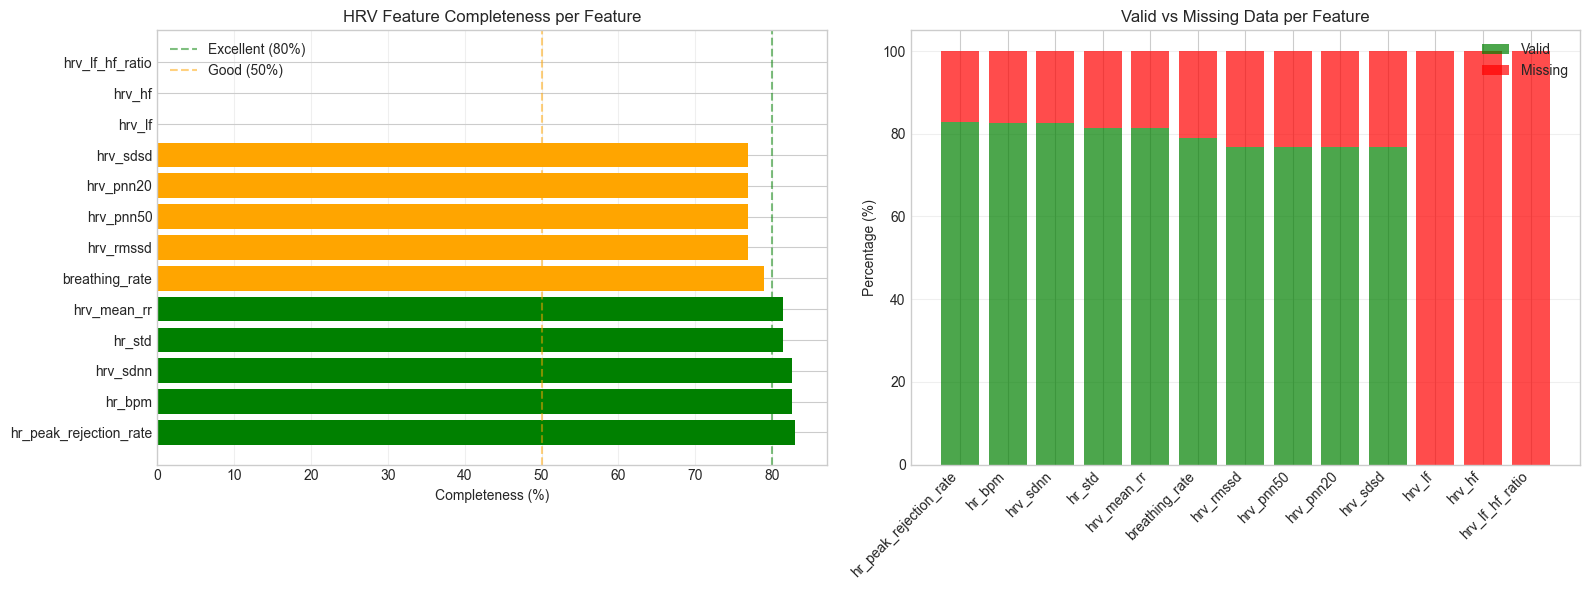


📊 Features with >80% completeness: ['hr_peak_rejection_rate', 'hr_bpm', 'hrv_sdnn', 'hr_std', 'hrv_mean_rr']
⚠️  Features with 50-80% completeness: ['breathing_rate', 'hrv_rmssd', 'hrv_pnn50', 'hrv_pnn20', 'hrv_sdsd']
❌ Features with <50% completeness: ['hrv_lf', 'hrv_hf', 'hrv_lf_hf_ratio']


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of completeness
colors = ['green' if x >= 80 else 'orange' if x >= 50 else 'red' 
          for x in completeness_df['Completeness (%)']]
axes[0].barh(completeness_df['Feature'], completeness_df['Completeness (%)'], color=colors)
axes[0].axvline(80, color='green', linestyle='--', alpha=0.5, label='Excellent (80%)')
axes[0].axvline(50, color='orange', linestyle='--', alpha=0.5, label='Good (50%)')
axes[0].set_xlabel('Completeness (%)')
axes[0].set_title('HRV Feature Completeness per Feature')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

# Stacked bar showing valid vs missing
x_pos = np.arange(len(completeness_df))
valid_pct = completeness_df['Completeness (%)'].values
missing_pct = 100 - valid_pct

axes[1].bar(x_pos, valid_pct, label='Valid', color='green', alpha=0.7)
axes[1].bar(x_pos, missing_pct, bottom=valid_pct, label='Missing', color='red', alpha=0.7)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(completeness_df['Feature'], rotation=45, ha='right')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_title('Valid vs Missing Data per Feature')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Features with >80% completeness: {list(excellent['Feature'])}")
print(f"⚠️  Features with 50-80% completeness: {list(good['Feature'])}")
print(f"❌ Features with <50% completeness: {list(poor['Feature'])}")



PER-SUBJECT HRV EXTRACTION SUCCESS
 subject_id  total_windows  valid_hrv  failed_hrv  success_rate_%
87bf2ae1...             82         80           2       97.560976
937503f7...             77         74           3       96.103896
3f27501c...             65         62           3       95.384615
89ba6f89...             82         77           5       93.902439
46b09d4a...             87         80           7       91.954023
a360c459...             87         78           9       89.655172
b61f4c2a...             76         68           8       89.473684
840e79d3...             87         77          10       88.505747
0a73ef1b...             87         77          10       88.505747
3f62db18...             87         77          10       88.505747
c5a60768...             87         73          14       83.908046
f9513e4b...             87         72          15       82.758621
464cc459...             74         61          13       82.432432
f64f9403...             87         68   

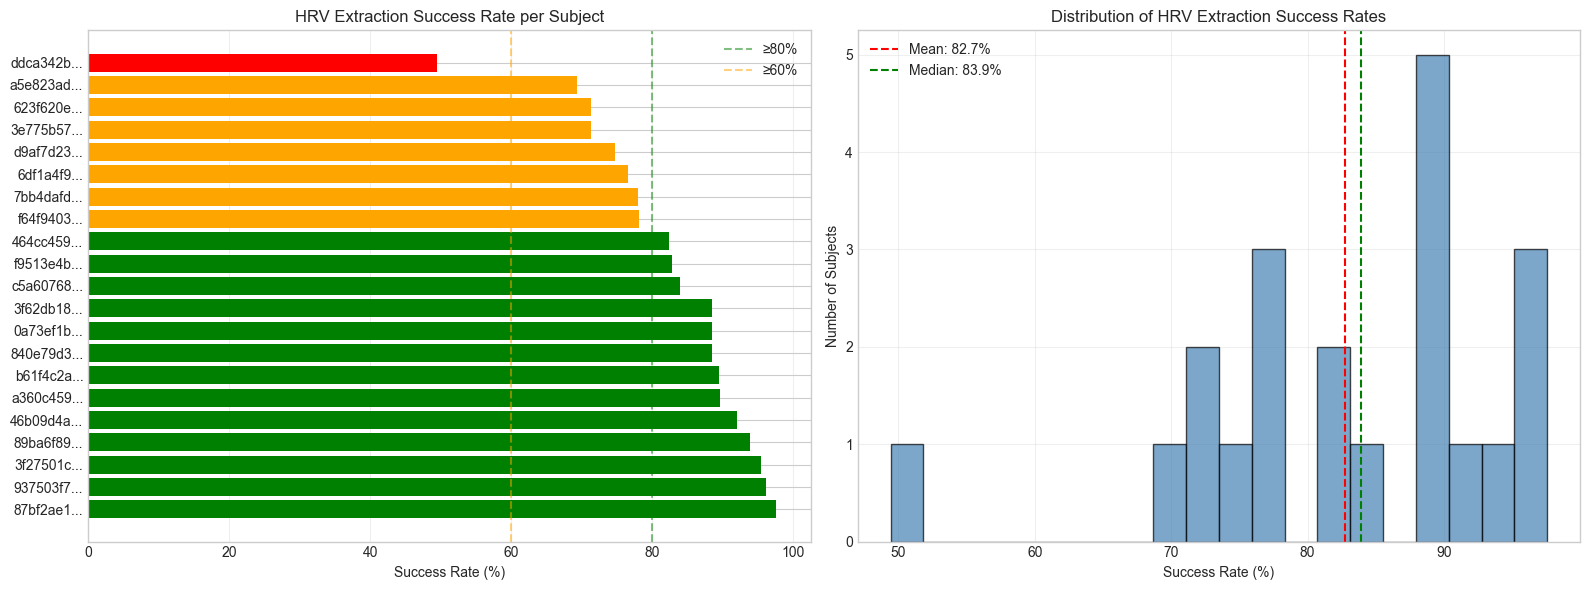


📊 Average success rate: 82.7%
📊 Median success rate: 83.9%
📊 Best subject: 97.6%
📊 Worst subject: 49.4%


In [35]:
# Analyze per subject
subject_stats = []
for subject_id in EXTRACTED_HR_DATA['subject_id'].unique():
    subject_data = EXTRACTED_HR_DATA[EXTRACTED_HR_DATA['subject_id'] == subject_id]
    
    # Count windows with valid hr_bpm (primary indicator)
    if 'hr_bpm' in subject_data.columns:
        valid_windows = subject_data['hr_bpm'].notna().sum()
        total_windows = len(subject_data)
        success_rate = 100 * valid_windows / total_windows
        
        subject_stats.append({
            'subject_id': subject_id[:8] + '...',
            'total_windows': total_windows,
            'valid_hrv': valid_windows,
            'failed_hrv': total_windows - valid_windows,
            'success_rate_%': success_rate
        })

subject_stats_df = pd.DataFrame(subject_stats)
subject_stats_df = subject_stats_df.sort_values('success_rate_%', ascending=False)

print("\n" + "="*70)
print("PER-SUBJECT HRV EXTRACTION SUCCESS")
print("="*70)
print(subject_stats_df.to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of success rates
colors = ['green' if x >= 80 else 'orange' if x >= 60 else 'red' 
          for x in subject_stats_df['success_rate_%']]
axes[0].barh(range(len(subject_stats_df)), subject_stats_df['success_rate_%'], color=colors)
axes[0].set_yticks(range(len(subject_stats_df)))
axes[0].set_yticklabels(subject_stats_df['subject_id'])
axes[0].set_xlabel('Success Rate (%)')
axes[0].set_title('HRV Extraction Success Rate per Subject')
axes[0].axvline(80, color='green', linestyle='--', alpha=0.5, label='≥80%')
axes[0].axvline(60, color='orange', linestyle='--', alpha=0.5, label='≥60%')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

# Distribution of success rates
axes[1].hist(subject_stats_df['success_rate_%'], bins=20, color='steelblue', alpha=0.7, edgecolor='black')
axes[1].axvline(subject_stats_df['success_rate_%'].mean(), color='red', linestyle='--', 
                label=f"Mean: {subject_stats_df['success_rate_%'].mean():.1f}%")
axes[1].axvline(subject_stats_df['success_rate_%'].median(), color='green', linestyle='--',
                label=f"Median: {subject_stats_df['success_rate_%'].median():.1f}%")
axes[1].set_xlabel('Success Rate (%)')
axes[1].set_ylabel('Number of Subjects')
axes[1].set_title('Distribution of HRV Extraction Success Rates')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Average success rate: {subject_stats_df['success_rate_%'].mean():.1f}%")
print(f"📊 Median success rate: {subject_stats_df['success_rate_%'].median():.1f}%")
print(f"📊 Best subject: {subject_stats_df.iloc[0]['success_rate_%']:.1f}%")
print(f"📊 Worst subject: {subject_stats_df.iloc[-1]['success_rate_%']:.1f}%")


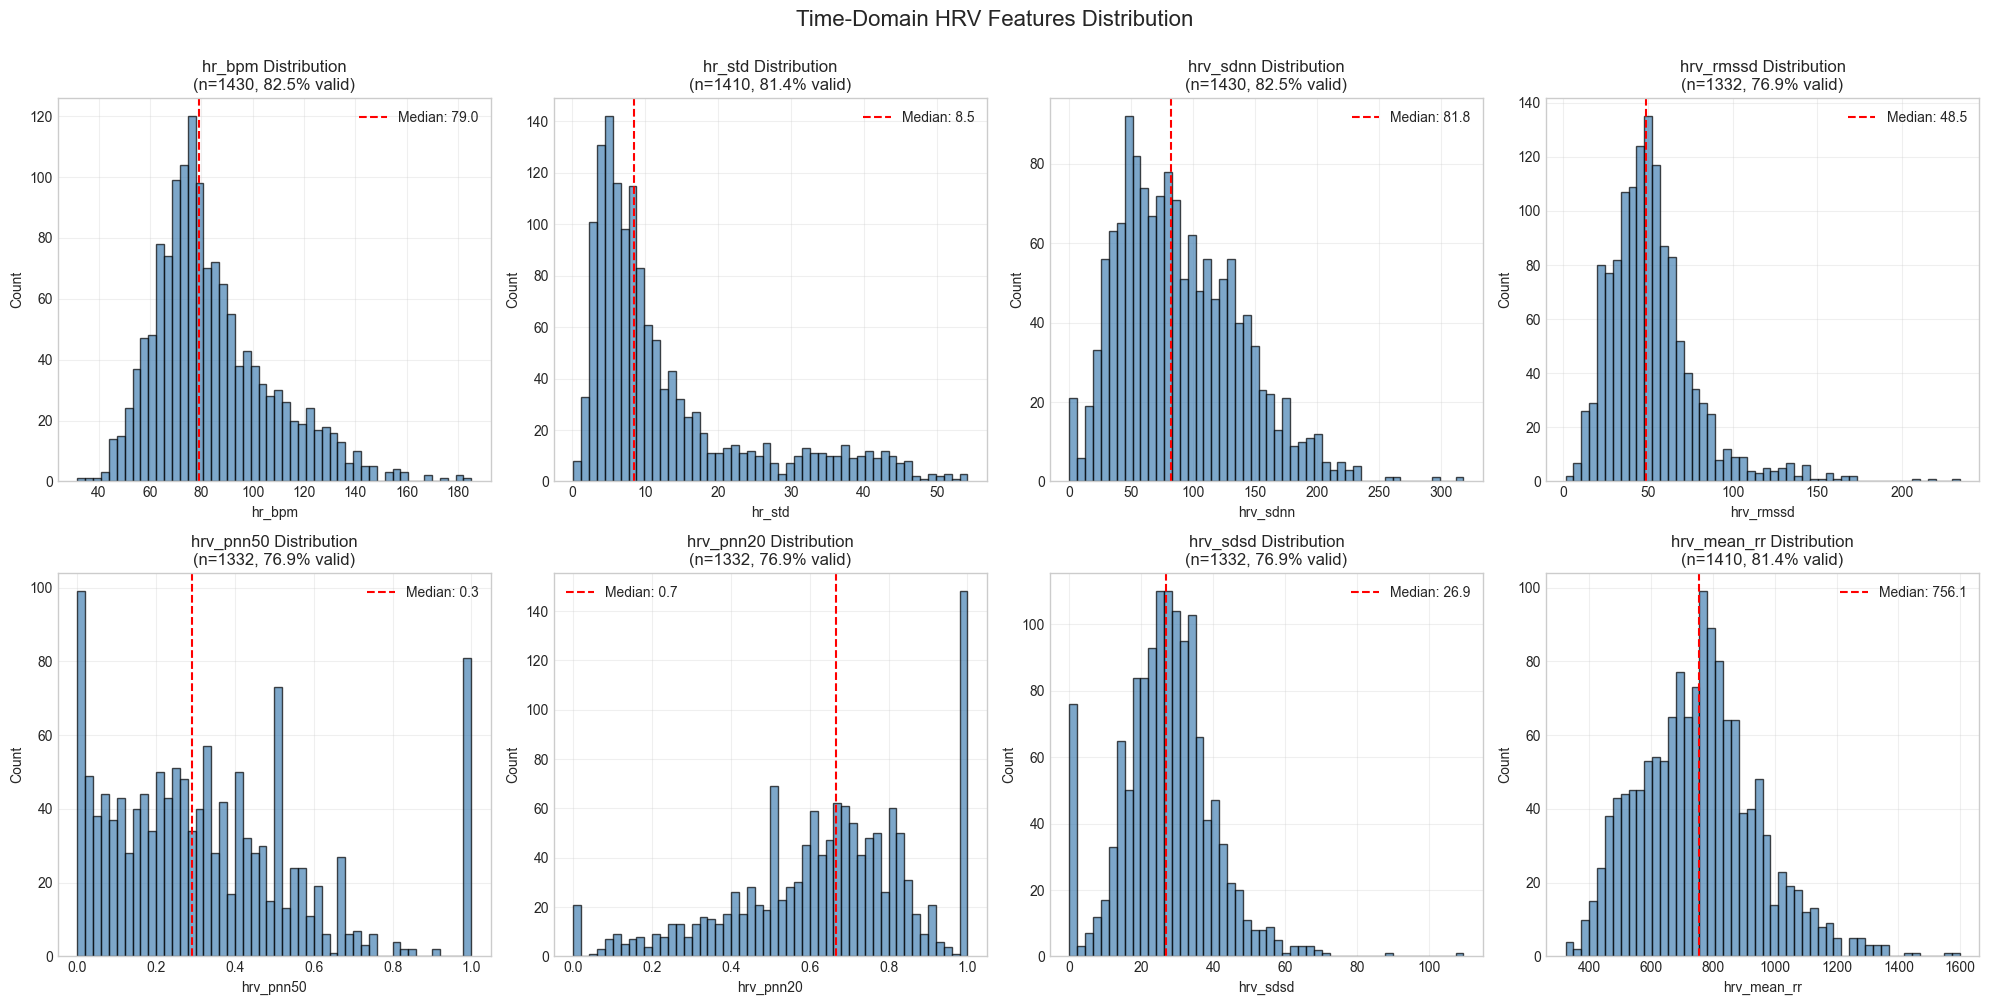

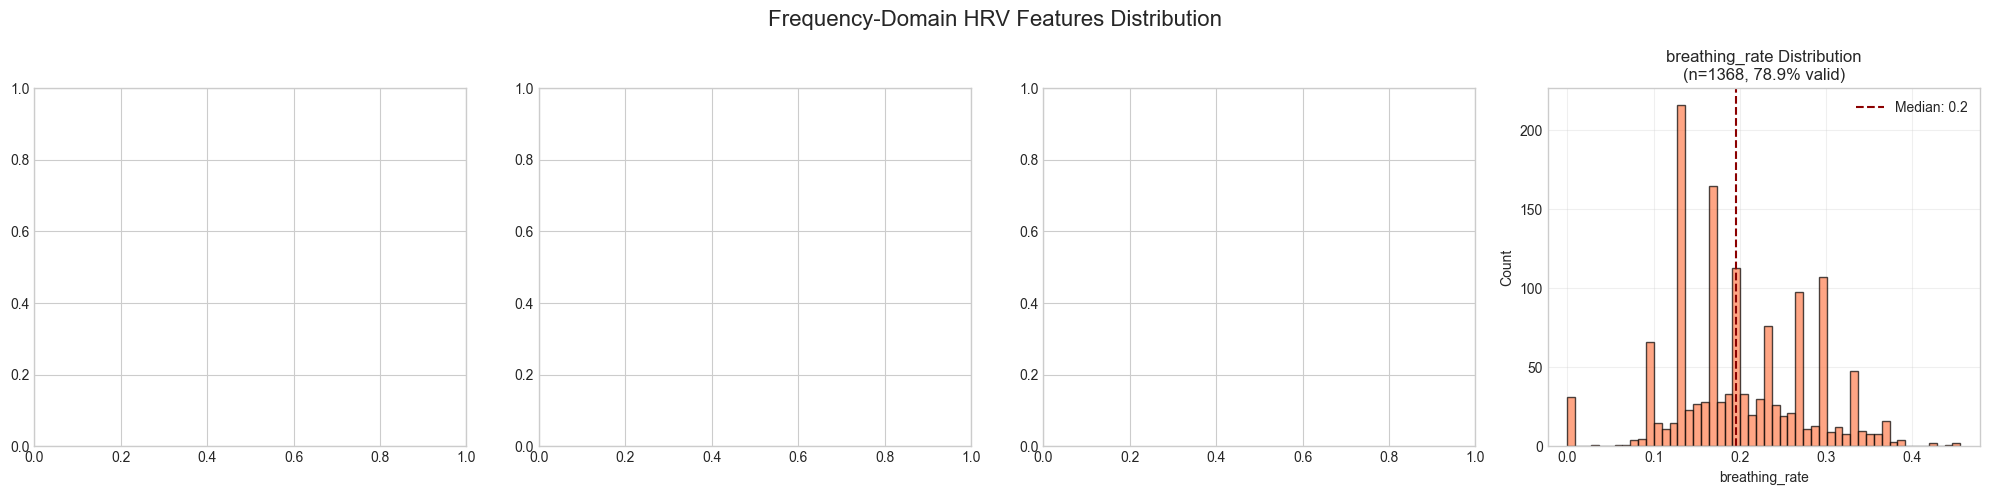

In [36]:
# Analyze distributions of successfully extracted features
time_domain_features = ['hr_bpm', 'hr_std', 'hrv_sdnn', 'hrv_rmssd', 'hrv_pnn50', 
                        'hrv_pnn20', 'hrv_sdsd', 'hrv_mean_rr']
freq_domain_features = ['hrv_lf', 'hrv_hf', 'hrv_lf_hf_ratio', 'breathing_rate']

# Filter to only existing features
time_domain_available = [f for f in time_domain_features if f in EXTRACTED_HR_DATA.columns]
freq_domain_available = [f for f in freq_domain_features if f in EXTRACTED_HR_DATA.columns]

# Plot time-domain features
if time_domain_available:
    n_features = len(time_domain_available)
    n_cols = 4
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_features == 1 else axes
    
    for idx, feat in enumerate(time_domain_available):
        data = EXTRACTED_HR_DATA[feat].dropna()
        
        if len(data) > 0:
            axes[idx].hist(data, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
            axes[idx].axvline(data.median(), color='red', linestyle='--', 
                            label=f'Median: {data.median():.1f}')
            axes[idx].set_xlabel(feat)
            axes[idx].set_ylabel('Count')
            axes[idx].set_title(f'{feat} Distribution\n(n={len(data)}, {100*len(data)/len(EXTRACTED_HR_DATA):.1f}% valid)')
            axes[idx].legend()
            axes[idx].grid(alpha=0.3)
    
    # Hide unused subplots
    for idx in range(len(time_domain_available), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Time-Domain HRV Features Distribution', fontsize=16, y=1.0)
    plt.tight_layout()
    plt.show()

# Plot frequency-domain features if available
if freq_domain_available:
    n_features = len(freq_domain_available)
    fig, axes = plt.subplots(1, n_features, figsize=(5*n_features, 5))
    if n_features == 1:
        axes = [axes]
    
    for idx, feat in enumerate(freq_domain_available):
        data = EXTRACTED_HR_DATA[feat].dropna()
        
        if len(data) > 0:
            axes[idx].hist(data, bins=50, color='coral', alpha=0.7, edgecolor='black')
            axes[idx].axvline(data.median(), color='darkred', linestyle='--',
                            label=f'Median: {data.median():.1f}')
            axes[idx].set_xlabel(feat)
            axes[idx].set_ylabel('Count')
            axes[idx].set_title(f'{feat} Distribution\n(n={len(data)}, {100*len(data)/len(EXTRACTED_HR_DATA):.1f}% valid)')
            axes[idx].legend()
            axes[idx].grid(alpha=0.3)
    
    plt.suptitle('Frequency-Domain HRV Features Distribution', fontsize=16)
    plt.tight_layout()
    plt.show()



PHYSIOLOGICAL VALIDATION
       Feature Valid Range  Within Range  Total Valid  Validity %  Outliers Low  Outliers High
    Heart Rate      40-180          1426         1430   99.720280             3              1
         RMSSD       5-200          1327         1332   99.624625             2              3
          SDNN      10-200          1378         1430   96.363636            22             30
         pNN50       0-100          1332         1332  100.000000             0              0
Breathing Rate        8-30             0         1368    0.000000          1368              0


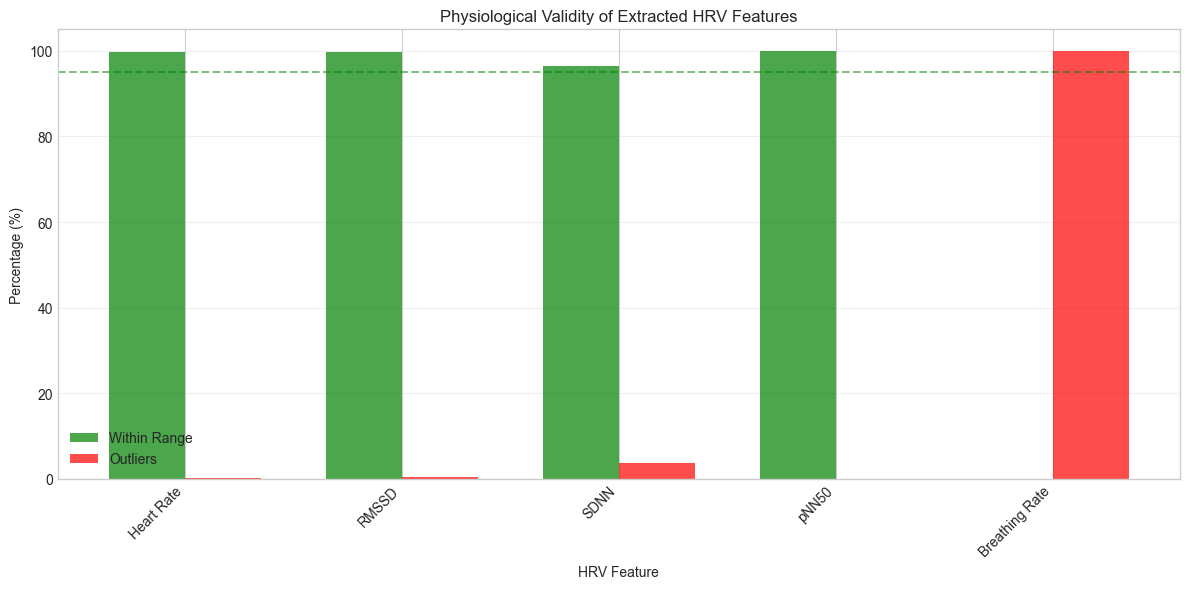


✅ Features with >95% physiologically valid values:
   - Heart Rate: 99.7%
   - RMSSD: 99.6%
   - SDNN: 96.4%
   - pNN50: 100.0%


In [37]:
# Check if extracted values are physiologically plausible
validation_results = []

# Define physiological ranges
ranges = {
    'hr_bpm': (40, 180, 'Heart Rate'),
    'hrv_rmssd': (5, 200, 'RMSSD'),
    'hrv_sdnn': (10, 200, 'SDNN'),
    'hrv_pnn50': (0, 100, 'pNN50'),
    'breathing_rate': (8, 30, 'Breathing Rate')
}

for feat, (min_val, max_val, label) in ranges.items():
    if feat in EXTRACTED_HR_DATA.columns:
        data = EXTRACTED_HR_DATA[feat].dropna()
        
        if len(data) > 0:
            within_range = ((data >= min_val) & (data <= max_val)).sum()
            total = len(data)
            pct_valid = 100 * within_range / total
            
            outliers_low = (data < min_val).sum()
            outliers_high = (data > max_val).sum()
            
            validation_results.append({
                'Feature': label,
                'Valid Range': f'{min_val}-{max_val}',
                'Within Range': within_range,
                'Total Valid': total,
                'Validity %': pct_valid,
                'Outliers Low': outliers_low,
                'Outliers High': outliers_high
            })

validation_df = pd.DataFrame(validation_results)

print("\n" + "="*70)
print("PHYSIOLOGICAL VALIDATION")
print("="*70)
print(validation_df.to_string(index=False))

# Visualize
if len(validation_df) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x = np.arange(len(validation_df))
    width = 0.35
    
    ax.bar(x - width/2, validation_df['Validity %'], width, label='Within Range', color='green', alpha=0.7)
    ax.bar(x + width/2, 100 - validation_df['Validity %'], width, label='Outliers', color='red', alpha=0.7)
    
    ax.set_xlabel('HRV Feature')
    ax.set_ylabel('Percentage (%)')
    ax.set_title('Physiological Validity of Extracted HRV Features')
    ax.set_xticks(x)
    ax.set_xticklabels(validation_df['Feature'], rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(95, color='green', linestyle='--', alpha=0.5, label='95% threshold')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ Features with >95% physiologically valid values:")
    excellent_validity = validation_df[validation_df['Validity %'] > 95]
    for _, row in excellent_validity.iterrows():
        print(f"   - {row['Feature']}: {row['Validity %']:.1f}%")


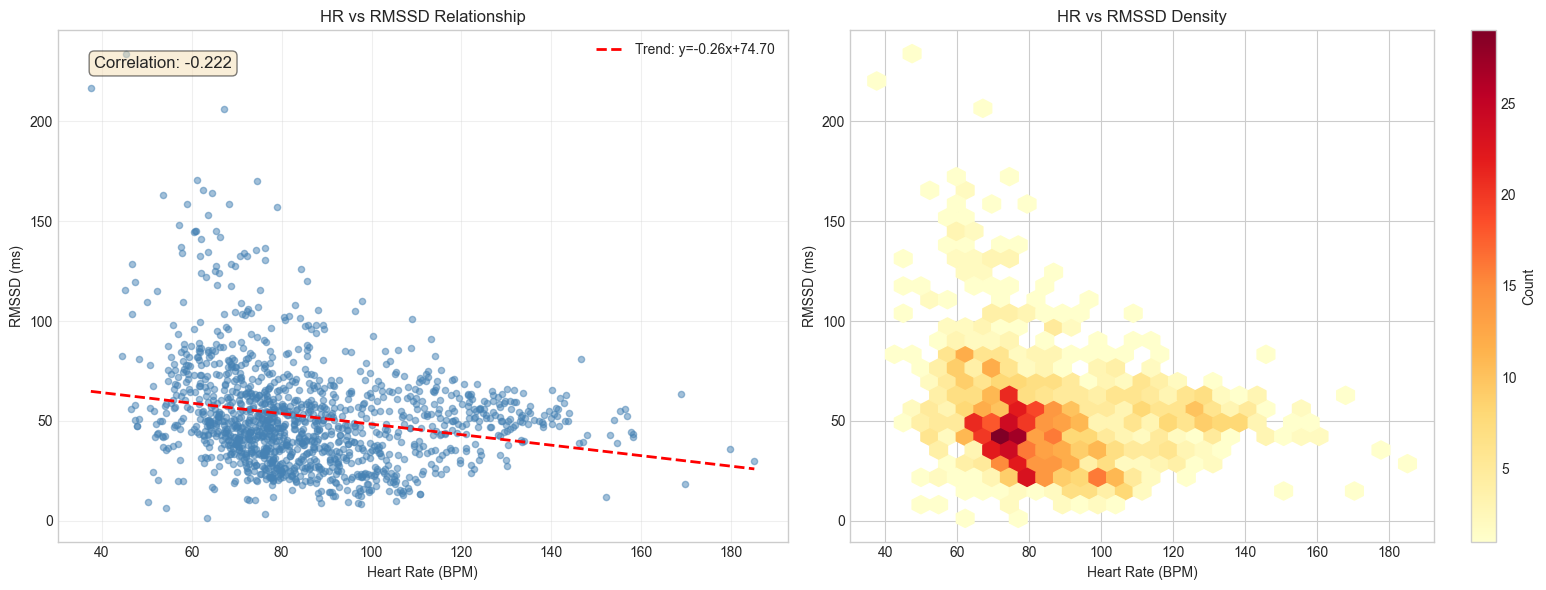


📊 Correlation coefficient: -0.222
⚠️  Weak correlation - may be normal for short windows


In [38]:
# Check physiological relationship: HR ↑ should correlate with RMSSD ↓
if 'hr_bpm' in EXTRACTED_HR_DATA.columns and 'hrv_rmssd' in EXTRACTED_HR_DATA.columns:
    valid_data = EXTRACTED_HR_DATA[['hr_bpm', 'hrv_rmssd']].dropna()
    
    if len(valid_data) > 100:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Scatter plot
        axes[0].scatter(valid_data['hr_bpm'], valid_data['hrv_rmssd'], 
                       alpha=0.5, s=20, c='steelblue')
        
        # Add trend line
        z = np.polyfit(valid_data['hr_bpm'], valid_data['hrv_rmssd'], 1)
        p = np.poly1d(z)
        x_trend = np.linspace(valid_data['hr_bpm'].min(), valid_data['hr_bpm'].max(), 100)
        axes[0].plot(x_trend, p(x_trend), "r--", linewidth=2, label=f'Trend: y={z[0]:.2f}x+{z[1]:.2f}')
        
        # Calculate correlation
        corr = valid_data['hr_bpm'].corr(valid_data['hrv_rmssd'])
        axes[0].text(0.05, 0.95, f'Correlation: {corr:.3f}', 
                    transform=axes[0].transAxes, fontsize=12, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        axes[0].set_xlabel('Heart Rate (BPM)')
        axes[0].set_ylabel('RMSSD (ms)')
        axes[0].set_title('HR vs RMSSD Relationship')
        axes[0].legend()
        axes[0].grid(alpha=0.3)
        
        # Hexbin for density
        axes[1].hexbin(valid_data['hr_bpm'], valid_data['hrv_rmssd'], 
                      gridsize=30, cmap='YlOrRd', mincnt=1)
        axes[1].set_xlabel('Heart Rate (BPM)')
        axes[1].set_ylabel('RMSSD (ms)')
        axes[1].set_title('HR vs RMSSD Density')
        plt.colorbar(axes[1].collections[0], ax=axes[1], label='Count')
        
        plt.tight_layout()
        plt.show()
        
        print(f"\n📊 Correlation coefficient: {corr:.3f}")
        if corr < -0.3:
            print("✅ Expected negative correlation observed (higher HR → lower RMSSD)")
        elif corr > 0:
            print("⚠️  Unexpected positive correlation - potential data quality issue")
        else:
            print("⚠️  Weak correlation - may be normal for short windows")


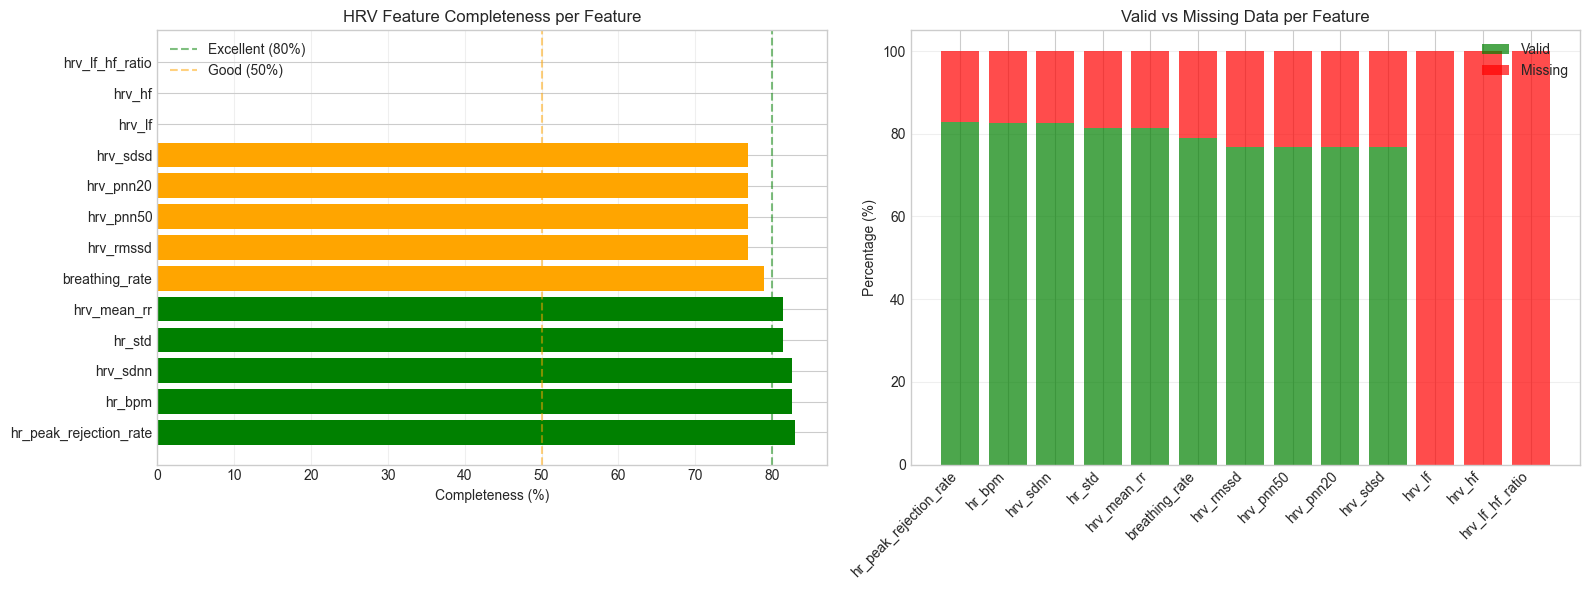


📊 Features with >80% completeness: ['hr_peak_rejection_rate', 'hr_bpm', 'hrv_sdnn', 'hr_std', 'hrv_mean_rr']
⚠️  Features with 50-80% completeness: ['breathing_rate', 'hrv_rmssd', 'hrv_pnn50', 'hrv_pnn20', 'hrv_sdsd']
❌ Features with <50% completeness: ['hrv_lf', 'hrv_hf', 'hrv_lf_hf_ratio']


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of completeness
colors = ['green' if x >= 80 else 'orange' if x >= 50 else 'red' 
          for x in completeness_df['Completeness (%)']]
axes[0].barh(completeness_df['Feature'], completeness_df['Completeness (%)'], color=colors)
axes[0].axvline(80, color='green', linestyle='--', alpha=0.5, label='Excellent (80%)')
axes[0].axvline(50, color='orange', linestyle='--', alpha=0.5, label='Good (50%)')
axes[0].set_xlabel('Completeness (%)')
axes[0].set_title('HRV Feature Completeness per Feature')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

# Stacked bar showing valid vs missing
x_pos = np.arange(len(completeness_df))
valid_pct = completeness_df['Completeness (%)'].values
missing_pct = 100 - valid_pct

axes[1].bar(x_pos, valid_pct, label='Valid', color='green', alpha=0.7)
axes[1].bar(x_pos, missing_pct, bottom=valid_pct, label='Missing', color='red', alpha=0.7)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(completeness_df['Feature'], rotation=45, ha='right')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_title('Valid vs Missing Data per Feature')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Features with >80% completeness: {list(excellent['Feature'])}")
print(f"⚠️  Features with 50-80% completeness: {list(good['Feature'])}")
print(f"❌ Features with <50% completeness: {list(poor['Feature'])}")


In [40]:
print("\n" + "="*80)
print("HRV EXTRACTION QUALITY SUMMARY")
print("="*80)

# Overall statistics
total_windows = len(EXTRACTED_HR_DATA)
total_subjects = EXTRACTED_HR_DATA['subject_id'].nunique()

print(f"\n📊 DATASET OVERVIEW")
print(f"   Total windows: {total_windows}")
print(f"   Total subjects: {total_subjects}")
print(f"   Average windows per subject: {total_windows/total_subjects:.1f}")

# Feature completeness summary
print(f"\n📈 FEATURE COMPLETENESS")
print(f"   Features extracted: {len(available_features)}")
print(f"   Time-domain features: {len([f for f in time_domain_available if f in completeness_df[completeness_df['Completeness (%)'] > 50]['Feature'].values])}/{len(time_domain_available)}")
print(f"   Frequency-domain features: {len([f for f in freq_domain_available if f in completeness_df[completeness_df['Completeness (%)'] > 50]['Feature'].values])}/{len(freq_domain_available)}")

# Best and worst features
if len(completeness_df) > 0:
    print(f"\n🏆 BEST FEATURE: {completeness_df.iloc[0]['Feature']} ({completeness_df.iloc[0]['Completeness (%)']:.1f}%)")
    print(f"❌ WORST FEATURE: {completeness_df.iloc[-1]['Feature']} ({completeness_df.iloc[-1]['Completeness (%)']:.1f}%)")

# Subject performance
if len(subject_stats_df) > 0:
    print(f"\n👥 SUBJECT-LEVEL PERFORMANCE")
    print(f"   Best subject: {subject_stats_df.iloc[0]['success_rate_%']:.1f}% success")
    print(f"   Worst subject: {subject_stats_df.iloc[-1]['success_rate_%']:.1f}% success")
    print(f"   Average: {subject_stats_df['success_rate_%'].mean():.1f}% ± {subject_stats_df['success_rate_%'].std():.1f}%")
    
    excellent_subjects = len(subject_stats_df[subject_stats_df['success_rate_%'] >= 80])
    print(f"   Subjects with ≥80% success: {excellent_subjects}/{len(subject_stats_df)}")

# Overall recommendation
print(f"\n💡 RECOMMENDATION")
usable_features = completeness_df[completeness_df['Completeness (%)'] >= 50]
if len(usable_features) >= 7:
    print(f"   ✅ {len(usable_features)} features have ≥50% completeness")
    print(f"   ✅ Sufficient for machine learning training")
    print(f"   📋 Recommended features to use:")
    for feat in usable_features.head(10)['Feature'].values:
        pct = completeness_df[completeness_df['Feature'] == feat]['Completeness (%)'].values[0]
        print(f"      - {feat:25s} ({pct:.1f}%)")
else:
    print(f"   ⚠️  Only {len(usable_features)} features have ≥50% completeness")
    print(f"   ⚠️  Consider investigating extraction failures")

print("\n" + "="*80)



HRV EXTRACTION QUALITY SUMMARY

📊 DATASET OVERVIEW
   Total windows: 1733
   Total subjects: 21
   Average windows per subject: 82.5

📈 FEATURE COMPLETENESS
   Features extracted: 13
   Time-domain features: 8/8
   Frequency-domain features: 1/4

🏆 BEST FEATURE: hr_peak_rejection_rate (82.9%)
❌ WORST FEATURE: hrv_lf_hf_ratio (0.0%)

👥 SUBJECT-LEVEL PERFORMANCE
   Best subject: 97.6% success
   Worst subject: 49.4% success
   Average: 82.7% ± 11.5%
   Subjects with ≥80% success: 13/21

💡 RECOMMENDATION
   ✅ 10 features have ≥50% completeness
   ✅ Sufficient for machine learning training
   📋 Recommended features to use:
      - hr_peak_rejection_rate    (82.9%)
      - hr_bpm                    (82.5%)
      - hrv_sdnn                  (82.5%)
      - hr_std                    (81.4%)
      - hrv_mean_rr               (81.4%)
      - breathing_rate            (78.9%)
      - hrv_rmssd                 (76.9%)
      - hrv_pnn50                 (76.9%)
      - hrv_pnn20                 (7

# HR/BPM Quality Comparison: On-the-Fly Extraction vs Activity CSV

This section compares two sources of heart rate data:
1. **On-the-fly extraction**: HR extracted from raw PPG signals (64Hz) using HeartPy during feature extraction
2. **Activity CSV**: Pre-computed BPM values from the smartwatch device

We'll analyze:
- Missing values comparison
- Validity and quality metrics
- Subject-wise performance
- Correlation and agreement between sources
- Recommendation on which source to use


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)

print("=" * 80)
print("HR/BPM QUALITY COMPARISON: ON-THE-FLY vs ACTIVITY CSV")
print("=" * 80)


HR/BPM QUALITY COMPARISON: ON-THE-FLY vs ACTIVITY CSV


## 1. Load HRV Features Dataset (On-the-Fly Extraction)


In [9]:
# Load the HRV features dataset (extracted on-the-fly from PPG)
hrv_dataset_path = Path("/Users/jithuazeez/Documents/Msc/Dissertation/experiments/01_classical_ml/results/hrv_features_dataset.csv")

if not hrv_dataset_path.exists():
    print(f"❌ ERROR: HRV dataset not found at {hrv_dataset_path}")
    print("Please run experiments/01_classical_ml/train.py first to generate the dataset")
else:
    hrv_df = pd.read_csv(hrv_dataset_path)
    
    # Convert timestamps
    hrv_df['window_start'] = pd.to_datetime(hrv_df['window_start'])
    hrv_df['window_end'] = pd.to_datetime(hrv_df['window_end'])
    
    print(f"✅ Loaded HRV dataset: {len(hrv_df)} windows")
    print(f"   Subjects: {hrv_df['subject_id'].nunique()}")
    print(f"   Columns: {list(hrv_df.columns)}")
    print(f"\n📊 Dataset shape: {hrv_df.shape}")
    print(f"\n🔍 Sample data:")
    print(hrv_df[['subject_id', 'window_id', 'window_start', 'window_end', 'hr_bpm', 'hrv_mean_rr']].head())


✅ Loaded HRV dataset: 1733 windows
   Subjects: 21
   Columns: ['subject_id', 'window_id', 'window_start', 'window_end', 'context', 'label_3min', 'label_5min', 'label_10min', 'hr_bpm', 'hr_std', 'hrv_mean_rr', 'hrv_sdnn', 'hrv_rmssd', 'hrv_pnn50', 'hrv_pnn20', 'hrv_sdsd', 'hrv_lf', 'hrv_hf', 'hrv_lf_hf_ratio', 'breathing_rate', 'hr_peak_rejection_rate']

📊 Dataset shape: (1733, 21)

🔍 Sample data:
                             subject_id  window_id              window_start  \
0  0a73ef1b-da67-43ff-b61a-f98c151be799          0 2035-03-15 14:51:00+00:00   
1  0a73ef1b-da67-43ff-b61a-f98c151be799          1 2035-03-15 14:52:00+00:00   
2  0a73ef1b-da67-43ff-b61a-f98c151be799          2 2035-03-15 14:53:00+00:00   
3  0a73ef1b-da67-43ff-b61a-f98c151be799          3 2035-03-15 14:54:00+00:00   
4  0a73ef1b-da67-43ff-b61a-f98c151be799          4 2035-03-15 14:55:00+00:00   

                 window_end      hr_bpm  hrv_mean_rr  
0 2035-03-15 14:53:00+00:00  135.263885   443.577381  
1 2035-0

## 2. Load Activity CSV Data (Device BPM)


In [10]:
# Load activity CSV files for all subjects
data_root = Path("/Users/jithuazeez/Documents/Msc/Dissertation/Datasets/VitaStress/data")

activity_data = []
subjects_processed = 0
subjects_no_activity = 0

for subject_dir in sorted(data_root.glob("id_*")):
    subject_id = subject_dir.name.replace("id_", "")
    activity_file = subject_dir / f"{subject_id}_activity.csv"
    
    if activity_file.exists():
        try:
            activity_csv = pd.read_csv(activity_file)
            activity_csv['date'] = pd.to_datetime(activity_csv['date'])
            activity_csv['subject_id'] = subject_id
            activity_data.append(activity_csv)
            subjects_processed += 1
        except Exception as e:
            print(f"⚠️ Error loading {subject_id}: {e}")
            subjects_no_activity += 1
    else:
        subjects_no_activity += 1

if activity_data:
    activity_df = pd.concat(activity_data, ignore_index=True)
    
    print(f"✅ Loaded activity data: {len(activity_df)} records")
    print(f"   Subjects processed: {subjects_processed}")
    print(f"   Subjects without activity: {subjects_no_activity}")
    print(f"\n📊 Dataset shape: {activity_df.shape}")
    print(f"\n🔍 BPM column stats:")
    print(f"   Total records: {len(activity_df)}")
    print(f"   BPM available: {activity_df['bpm'].notna().sum()} ({100*activity_df['bpm'].notna().sum()/len(activity_df):.1f}%)")
    print(f"   BPM missing: {activity_df['bpm'].isna().sum()} ({100*activity_df['bpm'].isna().sum()/len(activity_df):.1f}%)")
    print(f"   BPM = 0: {(activity_df['bpm'] == 0).sum()} ({100*(activity_df['bpm'] == 0).sum()/len(activity_df):.1f}%)")
    print(f"\n🔍 Sample data:")
    print(activity_df[['subject_id', 'date', 'bpm', 'bpm_q']].head(10))
else:
    print("❌ No activity data found!")


✅ Loaded activity data: 3546 records
   Subjects processed: 21
   Subjects without activity: 0

📊 Dataset shape: (3546, 36)

🔍 BPM column stats:
   Total records: 3546
   BPM available: 3546 (100.0%)
   BPM missing: 0 (0.0%)
   BPM = 0: 236 (6.7%)

🔍 Sample data:
                             subject_id                      date  bpm  bpm_q
0  0a73ef1b-da67-43ff-b61a-f98c151be799 2035-03-15 14:50:00+00:00  120      1
1  0a73ef1b-da67-43ff-b61a-f98c151be799 2035-03-15 14:50:30+00:00    0      0
2  0a73ef1b-da67-43ff-b61a-f98c151be799 2035-03-15 14:51:01+00:00    0      0
3  0a73ef1b-da67-43ff-b61a-f98c151be799 2035-03-15 14:51:30+00:00    0      0
4  0a73ef1b-da67-43ff-b61a-f98c151be799 2035-03-15 14:52:01+00:00    0      0
5  0a73ef1b-da67-43ff-b61a-f98c151be799 2035-03-15 14:52:30+00:00    0      0
6  0a73ef1b-da67-43ff-b61a-f98c151be799 2035-03-15 14:53:01+00:00    0      0
7  0a73ef1b-da67-43ff-b61a-f98c151be799 2035-03-15 14:53:30+00:00    0      0
8  0a73ef1b-da67-43ff-b61a-f98c151

## 3. Match Activity BPM to HRV Windows


In [11]:
# For each window in HRV dataset, aggregate BPM from activity CSV within that window
def aggregate_activity_bpm_for_window(subject_id, window_start, window_end, activity_df):
    """
    Aggregate BPM values from activity CSV for a given window.
    
    Returns:
        dict with mean, median, std, min, max, count, valid_count, quality
    """
    subject_activity = activity_df[activity_df['subject_id'] == subject_id]
    
    # Find activity records within window
    window_activity = subject_activity[
        (subject_activity['date'] >= window_start) & 
        (subject_activity['date'] <= window_end)
    ]
    
    result = {
        'activity_bpm_count': len(window_activity),
        'activity_bpm_valid_count': 0,
        'activity_bpm_mean': np.nan,
        'activity_bpm_median': np.nan,
        'activity_bpm_std': np.nan,
        'activity_bpm_min': np.nan,
        'activity_bpm_max': np.nan,
        'activity_bpm_quality_mean': np.nan
    }
    
    if len(window_activity) > 0:
        # Get valid BPM values (not 0, not NaN)
        valid_bpm = window_activity['bpm'][(window_activity['bpm'] > 0) & (window_activity['bpm'].notna())]
        
        if len(valid_bpm) > 0:
            result['activity_bpm_valid_count'] = len(valid_bpm)
            result['activity_bpm_mean'] = valid_bpm.mean()
            result['activity_bpm_median'] = valid_bpm.median()
            result['activity_bpm_std'] = valid_bpm.std()
            result['activity_bpm_min'] = valid_bpm.min()
            result['activity_bpm_max'] = valid_bpm.max()
            
            # Quality indicator (bpm_q column if available)
            if 'bpm_q' in window_activity.columns:
                valid_quality = window_activity['bpm_q'][(window_activity['bpm'] > 0) & (window_activity['bpm'].notna())]
                if len(valid_quality) > 0:
                    result['activity_bpm_quality_mean'] = valid_quality.mean()
    
    return result

print("🔄 Matching activity BPM to HRV windows...")
print("   This may take a few minutes...\n")

# Process each window
window_bpm_data = []
for idx, row in hrv_df.iterrows():
    bpm_stats = aggregate_activity_bpm_for_window(
        row['subject_id'],
        row['window_start'],
        row['window_end'],
        activity_df
    )
    window_bpm_data.append(bpm_stats)
    
    if (idx + 1) % 100 == 0:
        print(f"   Processed {idx + 1}/{len(hrv_df)} windows...")

# Add to HRV dataframe
bpm_stats_df = pd.DataFrame(window_bpm_data)
comparison_df = pd.concat([hrv_df.reset_index(drop=True), bpm_stats_df.reset_index(drop=True)], axis=1)

print(f"\n✅ Matching complete!")
print(f"   Total windows: {len(comparison_df)}")
print(f"   Windows with activity BPM: {(comparison_df['activity_bpm_valid_count'] > 0).sum()}")
print(f"   Windows with on-the-fly HR: {comparison_df['hr_bpm'].notna().sum()}")
print(f"   Windows with both: {((comparison_df['activity_bpm_valid_count'] > 0) & comparison_df['hr_bpm'].notna()).sum()}")


🔄 Matching activity BPM to HRV windows...
   This may take a few minutes...

   Processed 100/1733 windows...
   Processed 200/1733 windows...
   Processed 300/1733 windows...
   Processed 400/1733 windows...
   Processed 500/1733 windows...
   Processed 600/1733 windows...
   Processed 700/1733 windows...
   Processed 800/1733 windows...
   Processed 900/1733 windows...
   Processed 1000/1733 windows...
   Processed 1100/1733 windows...
   Processed 1200/1733 windows...
   Processed 1300/1733 windows...
   Processed 1400/1733 windows...
   Processed 1500/1733 windows...
   Processed 1600/1733 windows...
   Processed 1700/1733 windows...

✅ Matching complete!
   Total windows: 1733
   Windows with activity BPM: 1647
   Windows with on-the-fly HR: 1430
   Windows with both: 1379


In [12]:
# Calculate overall statistics
total_windows = len(comparison_df)

# On-the-fly extraction stats
onthefly_valid = comparison_df['hr_bpm'].notna().sum()
onthefly_missing = comparison_df['hr_bpm'].isna().sum()
onthefly_valid_pct = 100 * onthefly_valid / total_windows
onthefly_missing_pct = 100 * onthefly_missing / total_windows

# Activity BPM stats
activity_valid = (comparison_df['activity_bpm_valid_count'] > 0).sum()
activity_missing = (comparison_df['activity_bpm_valid_count'] == 0).sum()
activity_valid_pct = 100 * activity_valid / total_windows
activity_missing_pct = 100 * activity_missing / total_windows

# Both available
both_valid = ((comparison_df['hr_bpm'].notna()) & (comparison_df['activity_bpm_valid_count'] > 0)).sum()
both_valid_pct = 100 * both_valid / total_windows

# Create comparison table
print("\n" + "=" * 80)
print("OVERALL QUALITY COMPARISON")
print("=" * 80)
print(f"\n📊 Total windows analyzed: {total_windows}")
print(f"\n{'Metric':<40} {'On-the-Fly':<20} {'Activity CSV':<20}")
print("-" * 80)
print(f"{'Valid HR/BPM values':<40} {onthefly_valid:>8} ({onthefly_valid_pct:>5.1f}%)  {activity_valid:>8} ({activity_valid_pct:>5.1f}%)")
print(f"{'Missing HR/BPM values':<40} {onthefly_missing:>8} ({onthefly_missing_pct:>5.1f}%)  {activity_missing:>8} ({activity_missing_pct:>5.1f}%)")
print(f"{'Both sources available':<40} {both_valid:>8} ({both_valid_pct:>5.1f}%)")

# Quality comparison
print(f"\n🎯 WINNER: ", end="")
if onthefly_valid > activity_valid:
    print(f"On-the-Fly Extraction (+{onthefly_valid - activity_valid} more valid windows, +{onthefly_valid_pct - activity_valid_pct:.1f}%)")
elif activity_valid > onthefly_valid:
    print(f"Activity CSV (+{activity_valid - onthefly_valid} more valid windows, +{activity_valid_pct - onthefly_valid_pct:.1f}%)")
else:
    print("TIE (Equal valid windows)")



OVERALL QUALITY COMPARISON

📊 Total windows analyzed: 1733

Metric                                   On-the-Fly           Activity CSV        
--------------------------------------------------------------------------------
Valid HR/BPM values                          1430 ( 82.5%)      1647 ( 95.0%)
Missing HR/BPM values                         303 ( 17.5%)        86 (  5.0%)
Both sources available                       1379 ( 79.6%)

🎯 WINNER: Activity CSV (+217 more valid windows, +12.5%)


## 5. Subject-Wise Quality Comparison


In [13]:
# Subject-wise analysis
subject_comparison = comparison_df.groupby('subject_id').agg({
    'hr_bpm': lambda x: x.notna().sum(),  # Valid on-the-fly
    'activity_bpm_valid_count': lambda x: (x > 0).sum(),  # Valid activity
    'window_id': 'count'  # Total windows
}).reset_index()

subject_comparison.columns = ['subject_id', 'onthefly_valid', 'activity_valid', 'total_windows']

# Calculate percentages
subject_comparison['onthefly_pct'] = 100 * subject_comparison['onthefly_valid'] / subject_comparison['total_windows']
subject_comparison['activity_pct'] = 100 * subject_comparison['activity_valid'] / subject_comparison['total_windows']
subject_comparison['difference'] = subject_comparison['onthefly_valid'] - subject_comparison['activity_valid']
subject_comparison['difference_pct'] = subject_comparison['onthefly_pct'] - subject_comparison['activity_pct']

# Sort by total windows
subject_comparison = subject_comparison.sort_values('total_windows', ascending=False)

print("\n" + "=" * 80)
print("SUBJECT-WISE QUALITY COMPARISON")
print("=" * 80)
print(f"\n{'Subject':<12} {'Windows':<10} {'On-Fly':<15} {'Activity':<15} {'Difference':<15} {'Winner':<10}")
print("-" * 80)

for _, row in subject_comparison.iterrows():
    subject_short = row['subject_id'][:8] + "..."
    winner = ""
    if row['difference'] > 0:
        winner = "✓ On-Fly"
    elif row['difference'] < 0:
        winner = "✓ Activity"
    else:
        winner = "= Tie"
    
    print(f"{subject_short:<12} {row['total_windows']:>6}     "
          f"{row['onthefly_valid']:>4} ({row['onthefly_pct']:>5.1f}%)   "
          f"{row['activity_valid']:>4} ({row['activity_pct']:>5.1f}%)   "
          f"{row['difference']:>+4} ({row['difference_pct']:>+6.1f}%)  "
          f"{winner}")

# Summary statistics
print("\n" + "-" * 80)
print(f"{'AVERAGE':<12} {subject_comparison['total_windows'].mean():>6.1f}     "
      f"{subject_comparison['onthefly_valid'].mean():>4.1f} ({subject_comparison['onthefly_pct'].mean():>5.1f}%)   "
      f"{subject_comparison['activity_valid'].mean():>4.1f} ({subject_comparison['activity_pct'].mean():>5.1f}%)   "
      f"{subject_comparison['difference'].mean():>+4.1f} ({subject_comparison['difference_pct'].mean():>+6.1f}%)")

# Count winners
onthefly_wins = (subject_comparison['difference'] > 0).sum()
activity_wins = (subject_comparison['difference'] < 0).sum()
ties = (subject_comparison['difference'] == 0).sum()

print(f"\n📊 Subject-level winners:")
print(f"   On-the-Fly: {onthefly_wins}/{len(subject_comparison)} subjects ({100*onthefly_wins/len(subject_comparison):.1f}%)")
print(f"   Activity CSV: {activity_wins}/{len(subject_comparison)} subjects ({100*activity_wins/len(subject_comparison):.1f}%)")
print(f"   Ties: {ties}/{len(subject_comparison)} subjects ({100*ties/len(subject_comparison):.1f}%)")



SUBJECT-WISE QUALITY COMPARISON

Subject      Windows    On-Fly          Activity        Difference      Winner    
--------------------------------------------------------------------------------
0a73ef1b...      87       77 ( 88.5%)     78 ( 89.7%)     -1 (  -1.1%)  ✓ Activity
840e79d3...      87       77 ( 88.5%)     84 ( 96.6%)     -7 (  -8.0%)  ✓ Activity
f64f9403...      87       68 ( 78.2%)     85 ( 97.7%)    -17 ( -19.5%)  ✓ Activity
ddca342b...      87       43 ( 49.4%)     69 ( 79.3%)    -26 ( -29.9%)  ✓ Activity
d9af7d23...      87       65 ( 74.7%)     80 ( 92.0%)    -15 ( -17.2%)  ✓ Activity
c5a60768...      87       73 ( 83.9%)     87 (100.0%)    -14 ( -16.1%)  ✓ Activity
a360c459...      87       78 ( 89.7%)     79 ( 90.8%)     -1 (  -1.1%)  ✓ Activity
3e775b57...      87       62 ( 71.3%)     87 (100.0%)    -25 ( -28.7%)  ✓ Activity
f9513e4b...      87       72 ( 82.8%)     87 (100.0%)    -15 ( -17.2%)  ✓ Activity
623f620e...      87       62 ( 71.3%)     81 ( 93.1%)  

## 6. Visualization: Missing Values Comparison


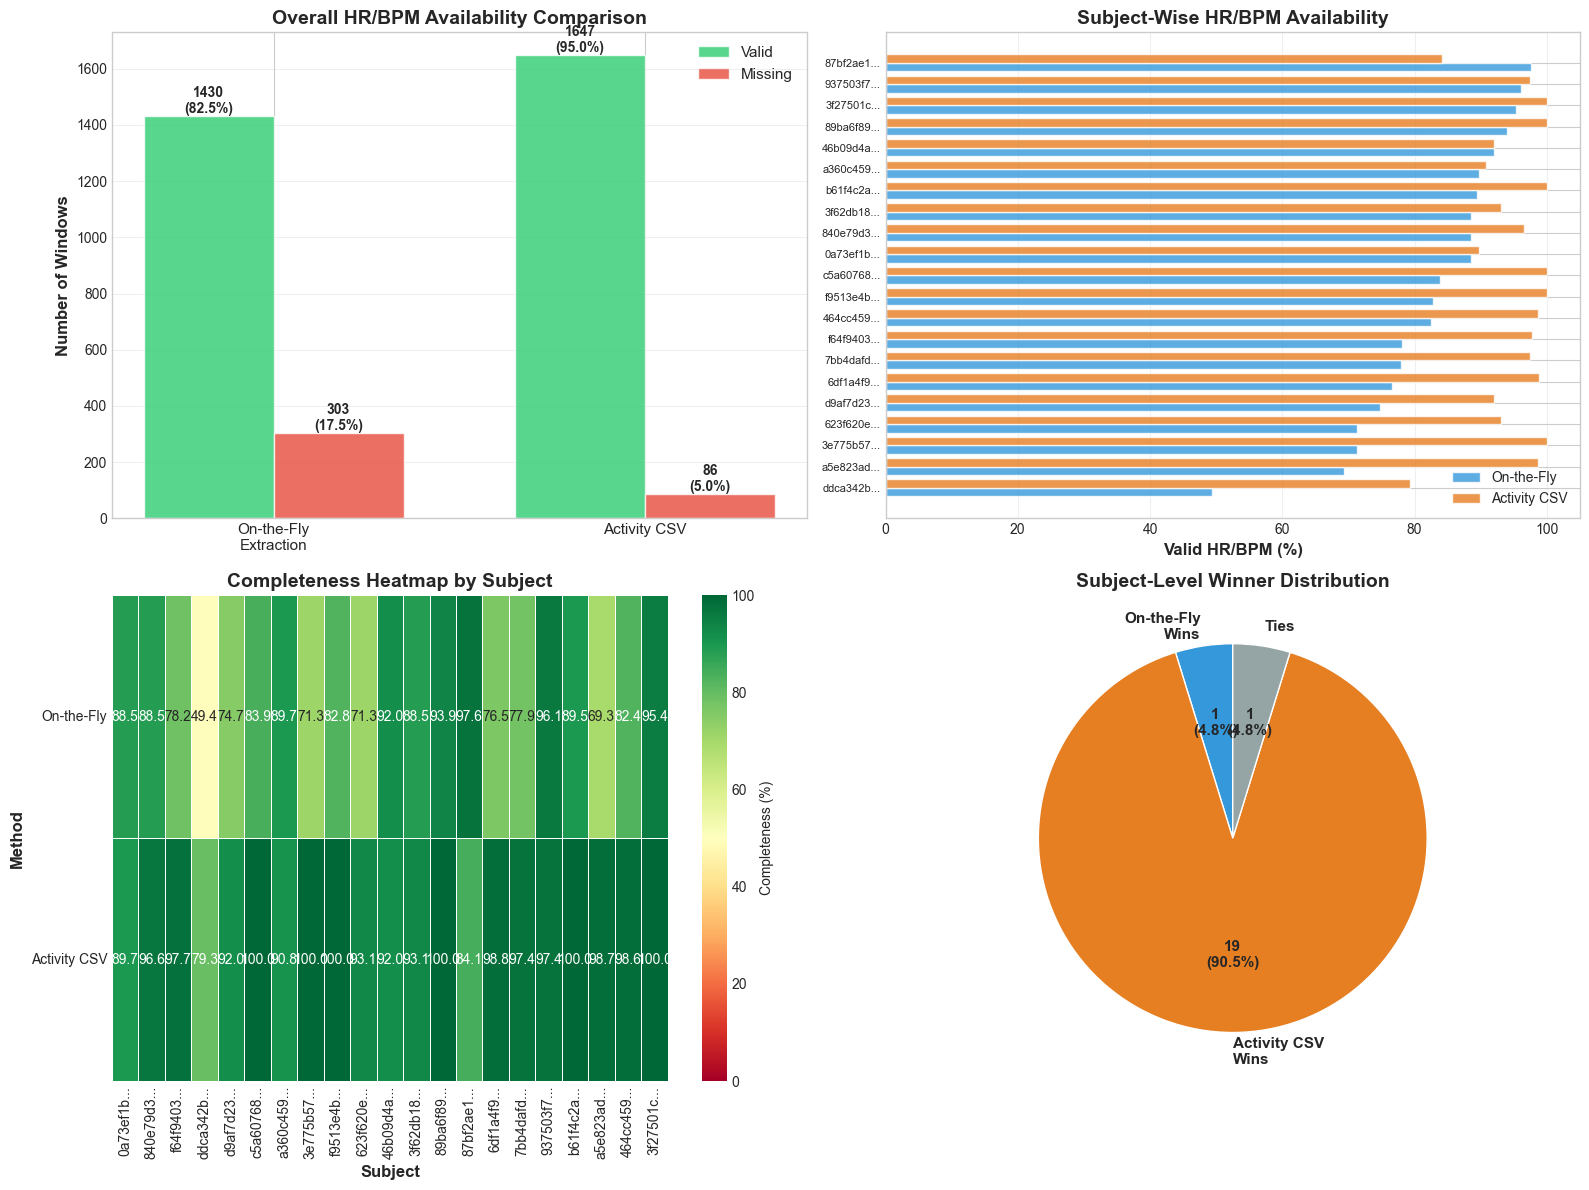


✅ Visualization saved: hr_comparison_overview.png


In [14]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Overall comparison bar chart
ax1 = axes[0, 0]
methods = ['On-the-Fly\nExtraction', 'Activity CSV']
valid_counts = [onthefly_valid, activity_valid]
missing_counts = [onthefly_missing, activity_missing]

x = np.arange(len(methods))
width = 0.35

bars1 = ax1.bar(x - width/2, valid_counts, width, label='Valid', color='#2ecc71', alpha=0.8)
bars2 = ax1.bar(x + width/2, missing_counts, width, label='Missing', color='#e74c3c', alpha=0.8)

ax1.set_ylabel('Number of Windows', fontsize=12, fontweight='bold')
ax1.set_title('Overall HR/BPM Availability Comparison', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(methods, fontsize=11)
ax1.legend(fontsize=11)
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}\n({100*height/total_windows:.1f}%)',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2. Subject-wise comparison
ax2 = axes[0, 1]
subject_comparison_sorted = subject_comparison.sort_values('onthefly_pct', ascending=True)
y_pos = np.arange(len(subject_comparison_sorted))

ax2.barh(y_pos - 0.2, subject_comparison_sorted['onthefly_pct'], 0.4, 
         label='On-the-Fly', color='#3498db', alpha=0.8)
ax2.barh(y_pos + 0.2, subject_comparison_sorted['activity_pct'], 0.4, 
         label='Activity CSV', color='#e67e22', alpha=0.8)

ax2.set_yticks(y_pos)
ax2.set_yticklabels([s[:8]+'...' for s in subject_comparison_sorted['subject_id']], fontsize=8)
ax2.set_xlabel('Valid HR/BPM (%)', fontsize=12, fontweight='bold')
ax2.set_title('Subject-Wise HR/BPM Availability', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(axis='x', alpha=0.3)
ax2.set_xlim([0, 105])

# 3. Completeness heatmap
ax3 = axes[1, 0]
heatmap_data = subject_comparison[['subject_id', 'onthefly_pct', 'activity_pct']].copy()
heatmap_data['subject_short'] = heatmap_data['subject_id'].apply(lambda x: x[:8]+'...')
heatmap_data = heatmap_data.set_index('subject_short')[['onthefly_pct', 'activity_pct']].T

sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn', vmin=0, vmax=100,
            cbar_kws={'label': 'Completeness (%)'}, ax=ax3, linewidths=0.5)
ax3.set_title('Completeness Heatmap by Subject', fontsize=14, fontweight='bold')
ax3.set_ylabel('Method', fontsize=12, fontweight='bold')
ax3.set_xlabel('Subject', fontsize=12, fontweight='bold')
ax3.set_yticklabels(['On-the-Fly', 'Activity CSV'], rotation=0, fontsize=10)

# 4. Distribution comparison
ax4 = axes[1, 1]
categories = ['On-the-Fly\nWins', 'Activity CSV\nWins', 'Ties']
counts = [onthefly_wins, activity_wins, ties]
colors = ['#3498db', '#e67e22', '#95a5a6']

wedges, texts, autotexts = ax4.pie(counts, labels=categories, autopct='%1.1f%%',
                                     colors=colors, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax4.set_title('Subject-Level Winner Distribution', fontsize=14, fontweight='bold')

# Add count labels
for i, (count, autotext) in enumerate(zip(counts, autotexts)):
    autotext.set_text(f'{count}\n({autotext.get_text()})')

plt.tight_layout()
plt.savefig('/Users/jithuazeez/Documents/Msc/Dissertation/notebooks/hr_comparison_overview.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Visualization saved: hr_comparison_overview.png")


In [15]:
# Analyze windows where both sources have valid data
both_valid_df = comparison_df[
    (comparison_df['hr_bpm'].notna()) & 
    (comparison_df['activity_bpm_valid_count'] > 0)
].copy()

print("\n" + "=" * 80)
print("VALUE COMPARISON (Windows with Both Sources)")
print("=" * 80)
print(f"\n📊 Analyzing {len(both_valid_df)} windows with both HR sources\n")

if len(both_valid_df) > 0:
    # Calculate correlation
    from scipy.stats import pearsonr, spearmanr
    
    pearson_corr, pearson_pval = pearsonr(both_valid_df['hr_bpm'], both_valid_df['activity_bpm_mean'])
    spearman_corr, spearman_pval = spearmanr(both_valid_df['hr_bpm'], both_valid_df['activity_bpm_mean'])
    
    # Calculate agreement metrics
    diff = both_valid_df['hr_bpm'] - both_valid_df['activity_bpm_mean']
    mean_diff = diff.mean()
    std_diff = diff.std()
    mae = np.abs(diff).mean()
    rmse = np.sqrt((diff ** 2).mean())
    
    # Bland-Altman limits
    upper_loa = mean_diff + 1.96 * std_diff
    lower_loa = mean_diff - 1.96 * std_diff
    
    print(f"🔗 CORRELATION:")
    print(f"   Pearson correlation:  r = {pearson_corr:.3f} (p = {pearson_pval:.4f})")
    print(f"   Spearman correlation: ρ = {spearman_corr:.3f} (p = {spearman_pval:.4f})")
    
    print(f"\n📏 AGREEMENT METRICS:")
    print(f"   Mean difference (bias): {mean_diff:.2f} bpm")
    print(f"   Std of differences:     {std_diff:.2f} bpm")
    print(f"   Mean Absolute Error:    {mae:.2f} bpm")
    print(f"   Root Mean Square Error: {rmse:.2f} bpm")
    print(f"   95% Limits of Agreement: [{lower_loa:.2f}, {upper_loa:.2f}] bpm")
    
    # Percentage within ±5, ±10, ±15 bpm
    within_5 = (np.abs(diff) <= 5).sum()
    within_10 = (np.abs(diff) <= 10).sum()
    within_15 = (np.abs(diff) <= 15).sum()
    
    print(f"\n✅ AGREEMENT LEVELS:")
    print(f"   Within ±5 bpm:  {within_5}/{len(both_valid_df)} ({100*within_5/len(both_valid_df):.1f}%)")
    print(f"   Within ±10 bpm: {within_10}/{len(both_valid_df)} ({100*within_10/len(both_valid_df):.1f}%)")
    print(f"   Within ±15 bpm: {within_15}/{len(both_valid_df)} ({100*within_15/len(both_valid_df):.1f}%)")
    
    # Descriptive statistics
    print(f"\n📊 DESCRIPTIVE STATISTICS:")
    print(f"   {'Metric':<25} {'On-the-Fly':<20} {'Activity CSV':<20}")
    print(f"   {'-'*65}")
    print(f"   {'Mean ± SD':<25} {both_valid_df['hr_bpm'].mean():.1f} ± {both_valid_df['hr_bpm'].std():.1f}          {both_valid_df['activity_bpm_mean'].mean():.1f} ± {both_valid_df['activity_bpm_mean'].std():.1f}")
    print(f"   {'Median [IQR]':<25} {both_valid_df['hr_bpm'].median():.1f} [{both_valid_df['hr_bpm'].quantile(0.25):.1f}-{both_valid_df['hr_bpm'].quantile(0.75):.1f}]      {both_valid_df['activity_bpm_mean'].median():.1f} [{both_valid_df['activity_bpm_mean'].quantile(0.25):.1f}-{both_valid_df['activity_bpm_mean'].quantile(0.75):.1f}]")
    print(f"   {'Min - Max':<25} {both_valid_df['hr_bpm'].min():.1f} - {both_valid_df['hr_bpm'].max():.1f}         {both_valid_df['activity_bpm_mean'].min():.1f} - {both_valid_df['activity_bpm_mean'].max():.1f}")
    
else:
    print("⚠️ No windows with both sources available for comparison")



VALUE COMPARISON (Windows with Both Sources)

📊 Analyzing 1379 windows with both HR sources

🔗 CORRELATION:
   Pearson correlation:  r = 0.632 (p = 0.0000)
   Spearman correlation: ρ = 0.663 (p = 0.0000)

📏 AGREEMENT METRICS:
   Mean difference (bias): -8.70 bpm
   Std of differences:     19.68 bpm
   Mean Absolute Error:    12.47 bpm
   Root Mean Square Error: 21.51 bpm
   95% Limits of Agreement: [-47.27, 29.88] bpm

✅ AGREEMENT LEVELS:
   Within ±5 bpm:  731/1379 (53.0%)
   Within ±10 bpm: 922/1379 (66.9%)
   Within ±15 bpm: 1008/1379 (73.1%)

📊 DESCRIPTIVE STATISTICS:
   Metric                    On-the-Fly           Activity CSV        
   -----------------------------------------------------------------
   Mean ± SD                 83.0 ± 21.7          91.7 ± 24.0
   Median [IQR]              78.2 [68.7-94.2]      86.8 [74.5-104.6]
   Min - Max                 31.8 - 185.2         46.8 - 182.0


## 8. Visualization: Correlation & Agreement Analysis


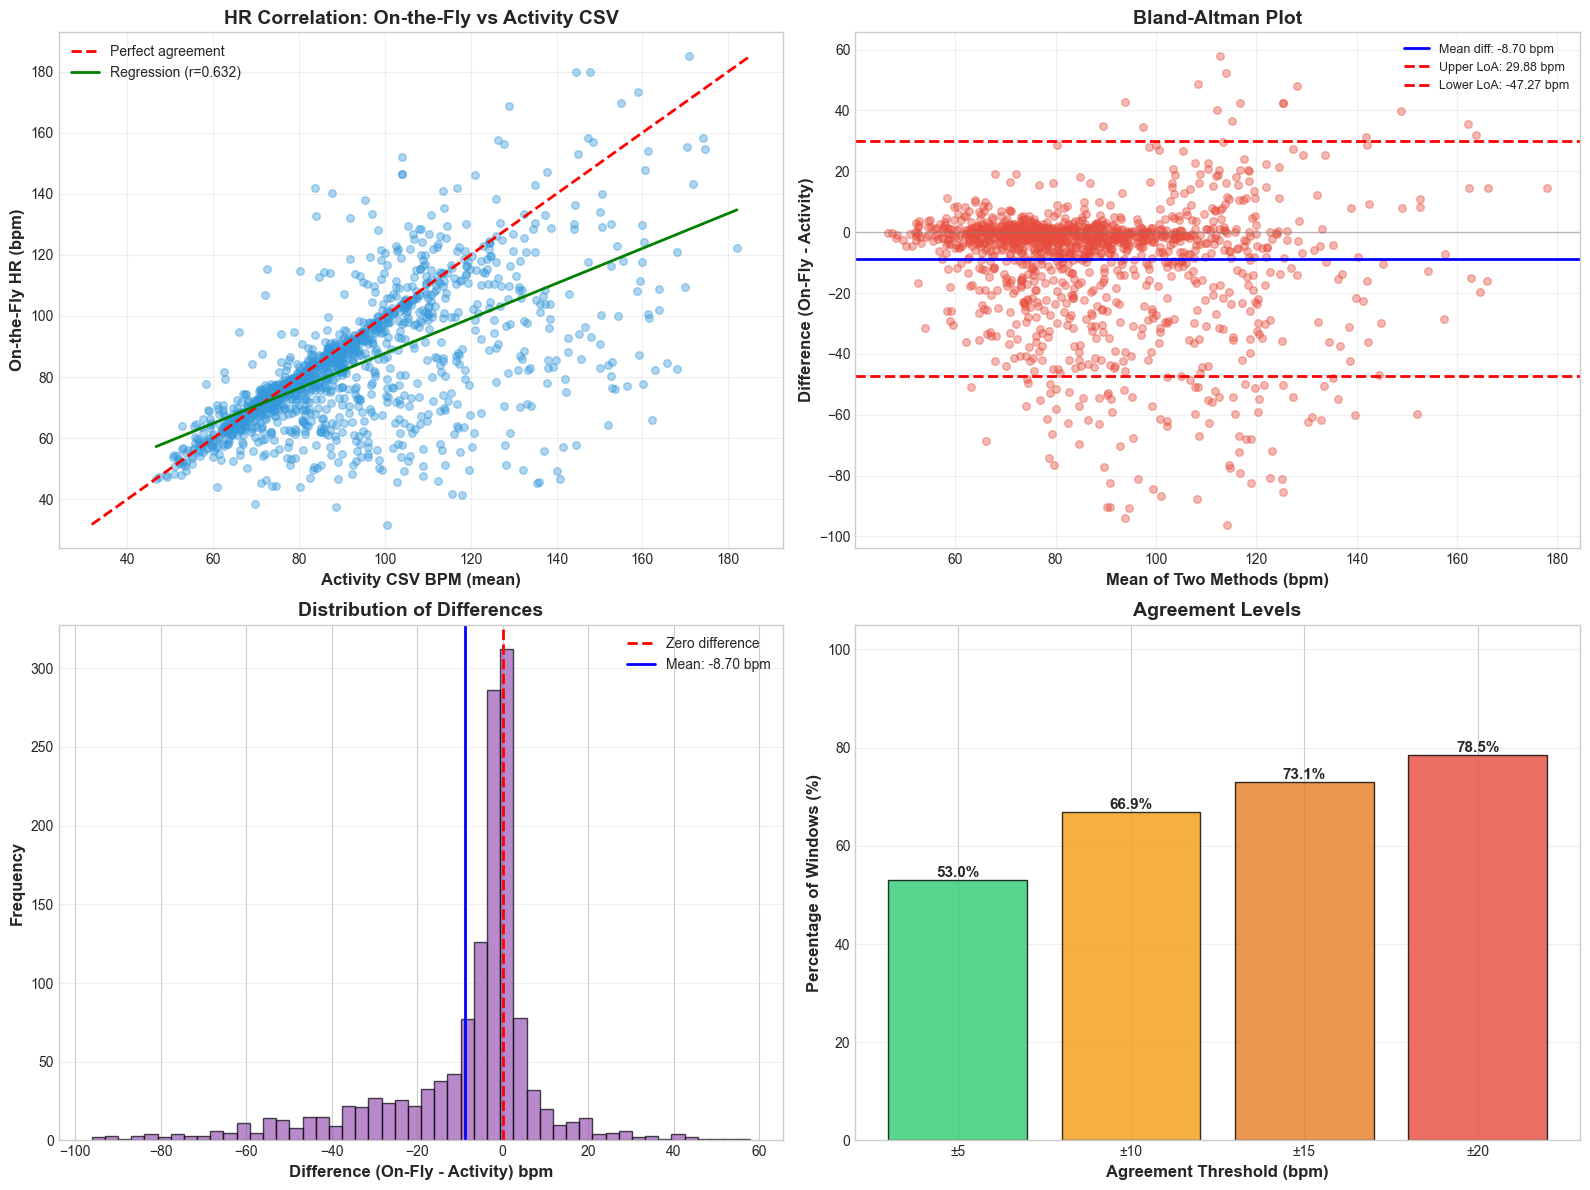


✅ Visualization saved: hr_correlation_analysis.png


In [16]:
if len(both_valid_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Scatter plot with regression line
    ax1 = axes[0, 0]
    ax1.scatter(both_valid_df['activity_bpm_mean'], both_valid_df['hr_bpm'], 
                alpha=0.4, s=30, color='#3498db')
    
    # Add identity line (perfect agreement)
    min_val = min(both_valid_df['activity_bpm_mean'].min(), both_valid_df['hr_bpm'].min())
    max_val = max(both_valid_df['activity_bpm_mean'].max(), both_valid_df['hr_bpm'].max())
    ax1.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect agreement')
    
    # Add regression line
    z = np.polyfit(both_valid_df['activity_bpm_mean'], both_valid_df['hr_bpm'], 1)
    p = np.poly1d(z)
    ax1.plot(both_valid_df['activity_bpm_mean'].sort_values(), 
             p(both_valid_df['activity_bpm_mean'].sort_values()), 
             'g-', linewidth=2, label=f'Regression (r={pearson_corr:.3f})')
    
    ax1.set_xlabel('Activity CSV BPM (mean)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('On-the-Fly HR (bpm)', fontsize=12, fontweight='bold')
    ax1.set_title('HR Correlation: On-the-Fly vs Activity CSV', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(alpha=0.3)
    
    # 2. Bland-Altman plot
    ax2 = axes[0, 1]
    mean_hr = (both_valid_df['hr_bpm'] + both_valid_df['activity_bpm_mean']) / 2
    diff = both_valid_df['hr_bpm'] - both_valid_df['activity_bpm_mean']
    
    ax2.scatter(mean_hr, diff, alpha=0.4, s=30, color='#e74c3c')
    ax2.axhline(mean_diff, color='blue', linewidth=2, label=f'Mean diff: {mean_diff:.2f} bpm')
    ax2.axhline(upper_loa, color='red', linestyle='--', linewidth=2, label=f'Upper LoA: {upper_loa:.2f} bpm')
    ax2.axhline(lower_loa, color='red', linestyle='--', linewidth=2, label=f'Lower LoA: {lower_loa:.2f} bpm')
    ax2.axhline(0, color='gray', linestyle='-', linewidth=1, alpha=0.5)
    
    ax2.set_xlabel('Mean of Two Methods (bpm)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Difference (On-Fly - Activity)', fontsize=12, fontweight='bold')
    ax2.set_title('Bland-Altman Plot', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=9, loc='best')
    ax2.grid(alpha=0.3)
    
    # 3. Distribution of differences
    ax3 = axes[1, 0]
    ax3.hist(diff, bins=50, color='#9b59b6', alpha=0.7, edgecolor='black')
    ax3.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero difference')
    ax3.axvline(mean_diff, color='blue', linewidth=2, label=f'Mean: {mean_diff:.2f} bpm')
    ax3.set_xlabel('Difference (On-Fly - Activity) bpm', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax3.set_title('Distribution of Differences', fontsize=14, fontweight='bold')
    ax3.legend(fontsize=10)
    ax3.grid(axis='y', alpha=0.3)
    
    # 4. Agreement levels
    ax4 = axes[1, 1]
    thresholds = [5, 10, 15, 20]
    percentages = []
    for thresh in thresholds:
        pct = 100 * (np.abs(diff) <= thresh).sum() / len(diff)
        percentages.append(pct)
    
    bars = ax4.bar([f'±{t}' for t in thresholds], percentages, 
                   color=['#2ecc71', '#f39c12', '#e67e22', '#e74c3c'], alpha=0.8, edgecolor='black')
    ax4.set_ylabel('Percentage of Windows (%)', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Agreement Threshold (bpm)', fontsize=12, fontweight='bold')
    ax4.set_title('Agreement Levels', fontsize=14, fontweight='bold')
    ax4.grid(axis='y', alpha=0.3)
    ax4.set_ylim([0, 105])
    
    # Add percentage labels on bars
    for bar, pct in zip(bars, percentages):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{pct:.1f}%',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('/Users/jithuazeez/Documents/Msc/Dissertation/notebooks/hr_correlation_analysis.png', 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✅ Visualization saved: hr_correlation_analysis.png")
else:
    print("\n⚠️ No data available for correlation visualization")


## 9. Subject-Wise Correlation Analysis



SUBJECT-WISE CORRELATION ANALYSIS

Subject      N      Pearson r    Spearman ρ   MAE        RMSE      
--------------------------------------------------------------------------------
3f62db18...    73    0.819 ***     0.877         8.28      13.98
3e775b57...    62    0.775 ***     0.593        13.69      21.59
89ba6f89...    77    0.745 ***     0.822         7.89      16.85
46b09d4a...    76    0.699 ***     0.751        10.16      17.71
840e79d3...    74    0.676 ***     0.775         8.39      14.83
623f620e...    56    0.675 ***     0.360        15.35      22.05
a360c459...    72    0.659 ***     0.698         8.96      14.49
464cc459...    61    0.654 ***     0.447        11.29      18.69
3f27501c...    62    0.634 ***     0.627         5.72      11.68
c5a60768...    73    0.578 ***     0.470        12.22      22.58
a5e823ad...    52    0.574 ***     0.386        16.54      25.70
937503f7...    74    0.485 ***     0.481         9.65      16.80
7bb4dafd...    58    0.466 ***     

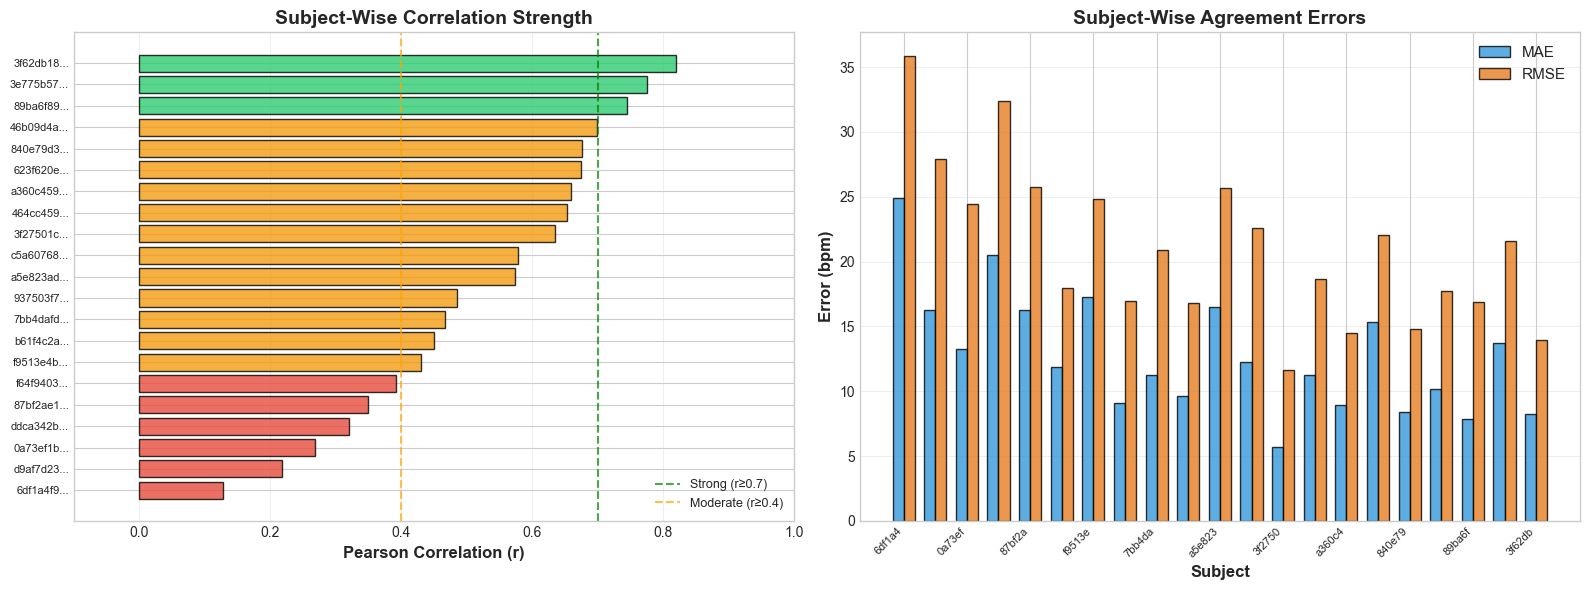


✅ Visualization saved: hr_subjectwise_correlation.png


In [17]:
if len(both_valid_df) > 0:
    print("\n" + "=" * 80)
    print("SUBJECT-WISE CORRELATION ANALYSIS")
    print("=" * 80)
    
    subject_correlations = []
    
    for subject_id in both_valid_df['subject_id'].unique():
        subject_data = both_valid_df[both_valid_df['subject_id'] == subject_id]
        
        if len(subject_data) >= 3:  # Need at least 3 points for correlation
            try:
                pearson_r, pearson_p = pearsonr(subject_data['hr_bpm'], subject_data['activity_bpm_mean'])
                spearman_r, spearman_p = spearmanr(subject_data['hr_bpm'], subject_data['activity_bpm_mean'])
                
                diff_subj = subject_data['hr_bpm'] - subject_data['activity_bpm_mean']
                mae_subj = np.abs(diff_subj).mean()
                rmse_subj = np.sqrt((diff_subj ** 2).mean())
                
                subject_correlations.append({
                    'subject_id': subject_id,
                    'n_windows': len(subject_data),
                    'pearson_r': pearson_r,
                    'pearson_p': pearson_p,
                    'spearman_r': spearman_r,
                    'mae': mae_subj,
                    'rmse': rmse_subj,
                    'mean_onfly': subject_data['hr_bpm'].mean(),
                    'mean_activity': subject_data['activity_bpm_mean'].mean()
                })
            except:
                pass
    
    if subject_correlations:
        subject_corr_df = pd.DataFrame(subject_correlations)
        subject_corr_df = subject_corr_df.sort_values('pearson_r', ascending=False)
        
        print(f"\n{'Subject':<12} {'N':<6} {'Pearson r':<12} {'Spearman ρ':<12} {'MAE':<10} {'RMSE':<10}")
        print("-" * 80)
        
        for _, row in subject_corr_df.iterrows():
            subject_short = row['subject_id'][:8] + "..."
            print(f"{subject_short:<12} {row['n_windows']:>4}   "
                  f"{row['pearson_r']:>6.3f} {'***' if row['pearson_p'] < 0.001 else '**' if row['pearson_p'] < 0.01 else '*' if row['pearson_p'] < 0.05 else 'ns':<4}   "
                  f"{row['spearman_r']:>6.3f}       "
                  f"{row['mae']:>6.2f}     "
                  f"{row['rmse']:>6.2f}")
        
        print("\n" + "-" * 80)
        print(f"{'AVERAGE':<12} {subject_corr_df['n_windows'].mean():>4.1f}   "
              f"{subject_corr_df['pearson_r'].mean():>6.3f}      "
              f"{subject_corr_df['spearman_r'].mean():>6.3f}       "
              f"{subject_corr_df['mae'].mean():>6.2f}     "
              f"{subject_corr_df['rmse'].mean():>6.2f}")
        
        # Categorize correlations
        strong = (subject_corr_df['pearson_r'] >= 0.7).sum()
        moderate = ((subject_corr_df['pearson_r'] >= 0.4) & (subject_corr_df['pearson_r'] < 0.7)).sum()
        weak = (subject_corr_df['pearson_r'] < 0.4).sum()
        
        print(f"\n📊 Correlation strength distribution:")
        print(f"   Strong (r ≥ 0.7):   {strong}/{len(subject_corr_df)} subjects ({100*strong/len(subject_corr_df):.1f}%)")
        print(f"   Moderate (0.4-0.7): {moderate}/{len(subject_corr_df)} subjects ({100*moderate/len(subject_corr_df):.1f}%)")
        print(f"   Weak (r < 0.4):     {weak}/{len(subject_corr_df)} subjects ({100*weak/len(subject_corr_df):.1f}%)")
        
        # Visualize subject-wise correlations
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # 1. Correlation coefficients by subject
        ax1 = axes[0]
        subject_corr_sorted = subject_corr_df.sort_values('pearson_r', ascending=True)
        y_pos = np.arange(len(subject_corr_sorted))
        
        colors = ['#e74c3c' if r < 0.4 else '#f39c12' if r < 0.7 else '#2ecc71' 
                  for r in subject_corr_sorted['pearson_r']]
        
        bars = ax1.barh(y_pos, subject_corr_sorted['pearson_r'], color=colors, alpha=0.8, edgecolor='black')
        ax1.set_yticks(y_pos)
        ax1.set_yticklabels([s[:8]+'...' for s in subject_corr_sorted['subject_id']], fontsize=8)
        ax1.set_xlabel('Pearson Correlation (r)', fontsize=12, fontweight='bold')
        ax1.set_title('Subject-Wise Correlation Strength', fontsize=14, fontweight='bold')
        ax1.axvline(0.7, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='Strong (r≥0.7)')
        ax1.axvline(0.4, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label='Moderate (r≥0.4)')
        ax1.legend(fontsize=9)
        ax1.grid(axis='x', alpha=0.3)
        ax1.set_xlim([-0.1, 1.0])
        
        # 2. MAE and RMSE by subject
        ax2 = axes[1]
        x = np.arange(len(subject_corr_sorted))
        width = 0.35
        
        bars1 = ax2.bar(x - width/2, subject_corr_sorted['mae'], width, label='MAE', 
                        color='#3498db', alpha=0.8, edgecolor='black')
        bars2 = ax2.bar(x + width/2, subject_corr_sorted['rmse'], width, label='RMSE', 
                        color='#e67e22', alpha=0.8, edgecolor='black')
        
        ax2.set_xlabel('Subject', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Error (bpm)', fontsize=12, fontweight='bold')
        ax2.set_title('Subject-Wise Agreement Errors', fontsize=14, fontweight='bold')
        ax2.set_xticks(x[::2])  # Show every other subject
        ax2.set_xticklabels([s[:6] for s in subject_corr_sorted['subject_id'].iloc[::2]], 
                            rotation=45, ha='right', fontsize=8)
        ax2.legend(fontsize=11)
        ax2.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('/Users/jithuazeez/Documents/Msc/Dissertation/notebooks/hr_subjectwise_correlation.png', 
                    dpi=300, bbox_inches='tight')
        plt.show()
        
        print("\n✅ Visualization saved: hr_subjectwise_correlation.png")
    else:
        print("\n⚠️ Not enough data for subject-wise correlation analysis")
else:
    print("\n⚠️ No data available for subject-wise analysis")


## 10. Quality Flags Comparison (Activity CSV)


In [18]:
# Analyze quality flags from activity CSV
if 'bpm_q' in activity_df.columns:
    print("\n" + "=" * 80)
    print("ACTIVITY CSV QUALITY FLAGS ANALYSIS")
    print("=" * 80)
    
    # Overall quality distribution
    quality_counts = activity_df['bpm_q'].value_counts().sort_index()
    
    print(f"\n📊 BPM Quality Flag Distribution:")
    print(f"   Total BPM records: {activity_df['bpm'].notna().sum()}")
    print(f"\n   {'Quality Flag':<15} {'Count':<10} {'Percentage':<12}")
    print(f"   {'-'*40}")
    
    for qual, count in quality_counts.items():
        pct = 100 * count / len(activity_df)
        print(f"   {qual:<15} {count:>8}   {pct:>6.2f}%")
    
    # Quality flag meanings (based on typical smartwatch conventions)
    print(f"\n📖 Quality Flag Interpretation (typical):")
    print(f"   0 = Low quality / unreliable")
    print(f"   1 = Good quality")
    print(f"   Other = Varies by device")
    
    # Compare BPM availability by quality flag
    print(f"\n🔍 BPM Availability by Quality Flag:")
    for qual in quality_counts.index:
        qual_data = activity_df[activity_df['bpm_q'] == qual]
        bpm_available = qual_data['bpm'].notna().sum()
        bpm_nonzero = (qual_data['bpm'] > 0).sum()
        print(f"   Quality {qual}: {bpm_available}/{len(qual_data)} have BPM data ({100*bpm_available/len(qual_data):.1f}%), "
              f"{bpm_nonzero} non-zero ({100*bpm_nonzero/len(qual_data):.1f}%)")
    
    # Check quality in windows with both sources
    if len(both_valid_df) > 0 and 'activity_bpm_quality_mean' in both_valid_df.columns:
        print(f"\n🎯 Quality in Windows with Both Sources:")
        quality_valid = both_valid_df['activity_bpm_quality_mean'].notna()
        if quality_valid.sum() > 0:
            mean_quality = both_valid_df.loc[quality_valid, 'activity_bpm_quality_mean'].mean()
            print(f"   Mean quality flag: {mean_quality:.2f}")
            print(f"   Windows with quality data: {quality_valid.sum()}/{len(both_valid_df)}")
else:
    print("\n⚠️ No quality flags (bpm_q) found in activity CSV")



ACTIVITY CSV QUALITY FLAGS ANALYSIS

📊 BPM Quality Flag Distribution:
   Total BPM records: 3546

   Quality Flag    Count      Percentage  
   ----------------------------------------
   0                    242     6.82%
   1                    636    17.94%
   2                    851    24.00%
   3                    608    17.15%
   4                   1209    34.09%

📖 Quality Flag Interpretation (typical):
   0 = Low quality / unreliable
   1 = Good quality
   Other = Varies by device

🔍 BPM Availability by Quality Flag:
   Quality 0: 242/242 have BPM data (100.0%), 6 non-zero (2.5%)
   Quality 1: 636/636 have BPM data (100.0%), 636 non-zero (100.0%)
   Quality 2: 851/851 have BPM data (100.0%), 851 non-zero (100.0%)
   Quality 3: 608/608 have BPM data (100.0%), 608 non-zero (100.0%)
   Quality 4: 1209/1209 have BPM data (100.0%), 1209 non-zero (100.0%)

🎯 Quality in Windows with Both Sources:
   Mean quality flag: 2.82
   Windows with quality data: 1379/1379


## 11. Final Recommendation & Summary


In [19]:
print("\n" + "=" * 80)
print("FINAL RECOMMENDATION & SUMMARY")
print("=" * 80)

# Decision matrix
print(f"\n📋 DECISION MATRIX:\n")

# Criteria 1: Data Availability
print(f"1️⃣  DATA AVAILABILITY:")
print(f"   On-the-Fly: {onthefly_valid_pct:.1f}% coverage ({onthefly_valid}/{total_windows} windows)")
print(f"   Activity CSV: {activity_valid_pct:.1f}% coverage ({activity_valid}/{total_windows} windows)")
if onthefly_valid_pct > activity_valid_pct:
    print(f"   ✅ Winner: On-the-Fly (+{onthefly_valid_pct - activity_valid_pct:.1f}% more coverage)")
    availability_score = 1
elif activity_valid_pct > onthefly_valid_pct:
    print(f"   ✅ Winner: Activity CSV (+{activity_valid_pct - onthefly_valid_pct:.1f}% more coverage)")
    availability_score = -1
else:
    print(f"   = Tie")
    availability_score = 0

# Criteria 2: Correlation (if both available)
if len(both_valid_df) > 0:
    print(f"\n2️⃣  CORRELATION & AGREEMENT:")
    print(f"   Pearson correlation: r = {pearson_corr:.3f}")
    print(f"   Mean Absolute Error: {mae:.2f} bpm")
    print(f"   Agreement within ±10 bpm: {100*within_10/len(both_valid_df):.1f}%")
    
    if pearson_corr >= 0.7 and mae <= 10:
        print(f"   ✅ Strong agreement - both sources are reliable")
        correlation_score = 0  # Both good
    elif pearson_corr >= 0.5:
        print(f"   ⚠️ Moderate agreement - sources differ somewhat")
        correlation_score = 0
    else:
        print(f"   ⚠️ Weak agreement - sources differ significantly")
        correlation_score = 0
else:
    print(f"\n2️⃣  CORRELATION & AGREEMENT:")
    print(f"   ⚠️ Not enough overlapping data for comparison")
    correlation_score = 0

# Criteria 3: Data Quality
print(f"\n3️⃣  DATA QUALITY:")
print(f"   On-the-Fly:")
print(f"   - Extracted from raw PPG (64Hz) using HeartPy")
print(f"   - Includes peak rejection rate metric")
print(f"   - Provides HRV features (SDNN, RMSSD, etc.)")
print(f"   Activity CSV:")
print(f"   - Pre-computed by device (unknown algorithm)")
print(f"   - Includes quality flags")
print(f"   - Lower temporal resolution")

# Criteria 4: Feature Richness
print(f"\n4️⃣  FEATURE RICHNESS:")
hrv_feature_cols = [col for col in comparison_df.columns if col.startswith('hrv_')]
print(f"   On-the-Fly: HR + {len(hrv_feature_cols)} HRV features")
print(f"   Activity CSV: BPM only")
print(f"   ✅ Winner: On-the-Fly (provides HRV metrics for ML)")
feature_score = 1

# Final recommendation
print(f"\n" + "=" * 80)
print(f"🏆 FINAL RECOMMENDATION")
print(f"=" * 80)

total_score = availability_score + feature_score

if total_score > 0:
    recommendation = "On-the-Fly Extraction"
    color = "✅"
elif total_score < 0:
    recommendation = "Activity CSV"
    color = "✅"
else:
    recommendation = "Hybrid Approach"
    color = "⚖️"

print(f"\n{color} RECOMMENDED: {recommendation}\n")

if recommendation == "On-the-Fly Extraction":
    print(f"REASONS:")
    print(f"✅ Better data coverage ({onthefly_valid_pct:.1f}% vs {activity_valid_pct:.1f}%)")
    print(f"✅ Provides rich HRV features for ML models")
    print(f"✅ Direct extraction from raw PPG signal")
    print(f"✅ Transparent processing with HeartPy")
    print(f"✅ Includes quality metrics (peak rejection rate)")
    
    print(f"\n💡 USAGE:")
    print(f"   - Use the hrv_features_dataset.csv generated by experiments/01_classical_ml/train.py")
    print(f"   - Features: hr_bpm, hr_std, hrv_mean_rr, hrv_sdnn, hrv_rmssd, etc.")
    print(f"   - Already being used in your ML experiments")
    
elif recommendation == "Activity CSV":
    print(f"REASONS:")
    print(f"✅ Better data coverage ({activity_valid_pct:.1f}% vs {onthefly_valid_pct:.1f}%)")
    print(f"✅ Pre-computed by device (may be more stable)")
    print(f"✅ Includes quality flags")
    
    print(f"\n💡 USAGE:")
    print(f"   - Load activity CSV and extract BPM for each window")
    print(f"   - Consider using quality flags to filter unreliable data")
    print(f"   - Note: No HRV features available")
    
else:  # Hybrid
    print(f"REASONS:")
    print(f"⚖️ Both sources have similar coverage")
    if len(both_valid_df) > 0:
        print(f"⚖️ Moderate correlation (r={pearson_corr:.3f})")
    print(f"⚖️ Each has unique advantages")
    
    print(f"\n💡 USAGE:")
    print(f"   Option A: Use on-the-fly for HRV features, activity CSV as backup for HR")
    print(f"   Option B: Average both sources when available (ensemble approach)")
    print(f"   Option C: Use on-the-fly for feature richness (recommended)")

print(f"\n" + "=" * 80)
print(f"📊 SUMMARY STATISTICS")
print(f"=" * 80)
print(f"Total windows analyzed: {total_windows}")
print(f"Subjects: {comparison_df['subject_id'].nunique()}")
print(f"\nOn-the-Fly Extraction:")
print(f"  - Coverage: {onthefly_valid_pct:.1f}% ({onthefly_valid} windows)")
print(f"  - Subject wins: {onthefly_wins}/{len(subject_comparison)}")
print(f"  - Features: HR + {len(hrv_feature_cols)} HRV metrics")
print(f"\nActivity CSV:")
print(f"  - Coverage: {activity_valid_pct:.1f}% ({activity_valid} windows)")
print(f"  - Subject wins: {activity_wins}/{len(subject_comparison)}")
print(f"  - Features: BPM only")

if len(both_valid_df) > 0:
    print(f"\nAgreement (where both available):")
    print(f"  - Windows: {len(both_valid_df)}")
    print(f"  - Correlation: r = {pearson_corr:.3f}")
    print(f"  - MAE: {mae:.2f} bpm")
    print(f"  - Within ±10 bpm: {100*within_10/len(both_valid_df):.1f}%")

print(f"\n" + "=" * 80)
print("✅ ANALYSIS COMPLETE")
print("=" * 80)



FINAL RECOMMENDATION & SUMMARY

📋 DECISION MATRIX:

1️⃣  DATA AVAILABILITY:
   On-the-Fly: 82.5% coverage (1430/1733 windows)
   Activity CSV: 95.0% coverage (1647/1733 windows)
   ✅ Winner: Activity CSV (+12.5% more coverage)

2️⃣  CORRELATION & AGREEMENT:
   Pearson correlation: r = 0.632
   Mean Absolute Error: 12.47 bpm
   Agreement within ±10 bpm: 66.9%
   ⚠️ Moderate agreement - sources differ somewhat

3️⃣  DATA QUALITY:
   On-the-Fly:
   - Extracted from raw PPG (64Hz) using HeartPy
   - Includes peak rejection rate metric
   - Provides HRV features (SDNN, RMSSD, etc.)
   Activity CSV:
   - Pre-computed by device (unknown algorithm)
   - Includes quality flags
   - Lower temporal resolution

4️⃣  FEATURE RICHNESS:
   On-the-Fly: HR + 9 HRV features
   Activity CSV: BPM only
   ✅ Winner: On-the-Fly (provides HRV metrics for ML)

🏆 FINAL RECOMMENDATION

⚖️ RECOMMENDED: Hybrid Approach

REASONS:
⚖️ Both sources have similar coverage
⚖️ Moderate correlation (r=0.632)
⚖️ Each has u

# Feature Importance Analysis - Logistic Regression Model

Analyze which features are most important for stress detection in the trained LR model.


In [22]:
import joblib
import json

# Load the trained model and parameters
MODEL_DIR = PROJECT_ROOT / "experiments" / "classical_ml" / "results" / "models"

# Load model
lr_model = joblib.load(MODEL_DIR / "logistic_regression_model.joblib")

# Load scaler
scaler = joblib.load(MODEL_DIR / "logistic_regression_scaler.joblib")

# Load parameters (includes feature names)
with open(MODEL_DIR / "logistic_regression_params.json", "r") as f:
    params = json.load(f)

feature_names = params["feature_names"]
n_features = len(feature_names)

print(f"✓ Loaded Logistic Regression model")
print(f"  - Features: {n_features}")
print(f"  - Trained on: {params['n_samples_trained']} samples")
print(f"  - Class distribution: {params['n_positive']} positive, {params['n_negative']} negative")
print(f"  - Hyperparameters: C={params['hyperparameters']['C']}, penalty={params['hyperparameters']['penalty']}")


✓ Loaded Logistic Regression model
  - Features: 65
  - Trained on: 1430 samples
  - Class distribution: 191 positive, 1239 negative
  - Hyperparameters: C=5.0, penalty=l1


In [23]:
# Extract feature coefficients
coefficients = lr_model.coef_[0]  # Shape: (n_features,)
intercept = lr_model.intercept_[0]

# Create feature importance DataFrame
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)
})

# Add feature categories
def categorize_feature(name):
    if name.startswith('acc_'):
        if 'jerk' in name:
            return 'Accelerometer: Jerk (Stress)'
        elif any(x in name for x in ['psd', 'freq', 'spectral']):
            return 'Accelerometer: Frequency'
        elif any(x in name for x in ['tilt', 'roll', 'pitch']):
            return 'Accelerometer: Posture'
        elif any(x in name for x in ['is_', 'activity', 'motion']):
            return 'Accelerometer: Activity'
        else:
            return 'Accelerometer: Movement'
    elif name.startswith('temp_'):
        return 'Temperature'
    elif name.startswith('heatflux') or name.startswith('cbt'):
        return 'Heat Flux / CBT'
    elif name.startswith('hr_') or name.startswith('hrv_'):
        return 'HR / HRV'
    else:
        return 'Other'

feature_importance['category'] = feature_importance['feature'].apply(categorize_feature)

# Sort by absolute coefficient (importance)
feature_importance_sorted = feature_importance.sort_values('abs_coefficient', ascending=False)

print("="*80)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*80)
print(f"\nModel intercept: {intercept:.4f}")
print(f"\nTop 20 Most Important Features:\n")
print(feature_importance_sorted.head(20).to_string(index=False))
print("\n" + "="*80)


FEATURE IMPORTANCE ANALYSIS

Model intercept: -1.7809

Top 20 Most Important Features:

                feature  coefficient  abs_coefficient                     category
               temp_std    -1.544916         1.544916                  Temperature
                 hr_std    -1.536581         1.536581                     HR / HRV
             temp_slope     1.308091         1.308091                  Temperature
                 tilt_z     1.063741         1.063741                        Other
                 tilt_y    -0.979168         0.979168                        Other
             roll_angle     0.796097         0.796097                        Other
acc_dominant_freq_power     0.673574         0.673574     Accelerometer: Frequency
      acc_magnitude_max     0.665107         0.665107      Accelerometer: Movement
                acc_sma    -0.642834         0.642834      Accelerometer: Movement
                 hr_bpm     0.641721         0.641721                     HR / HRV

## Visualization 1: Top 30 Features by Importance


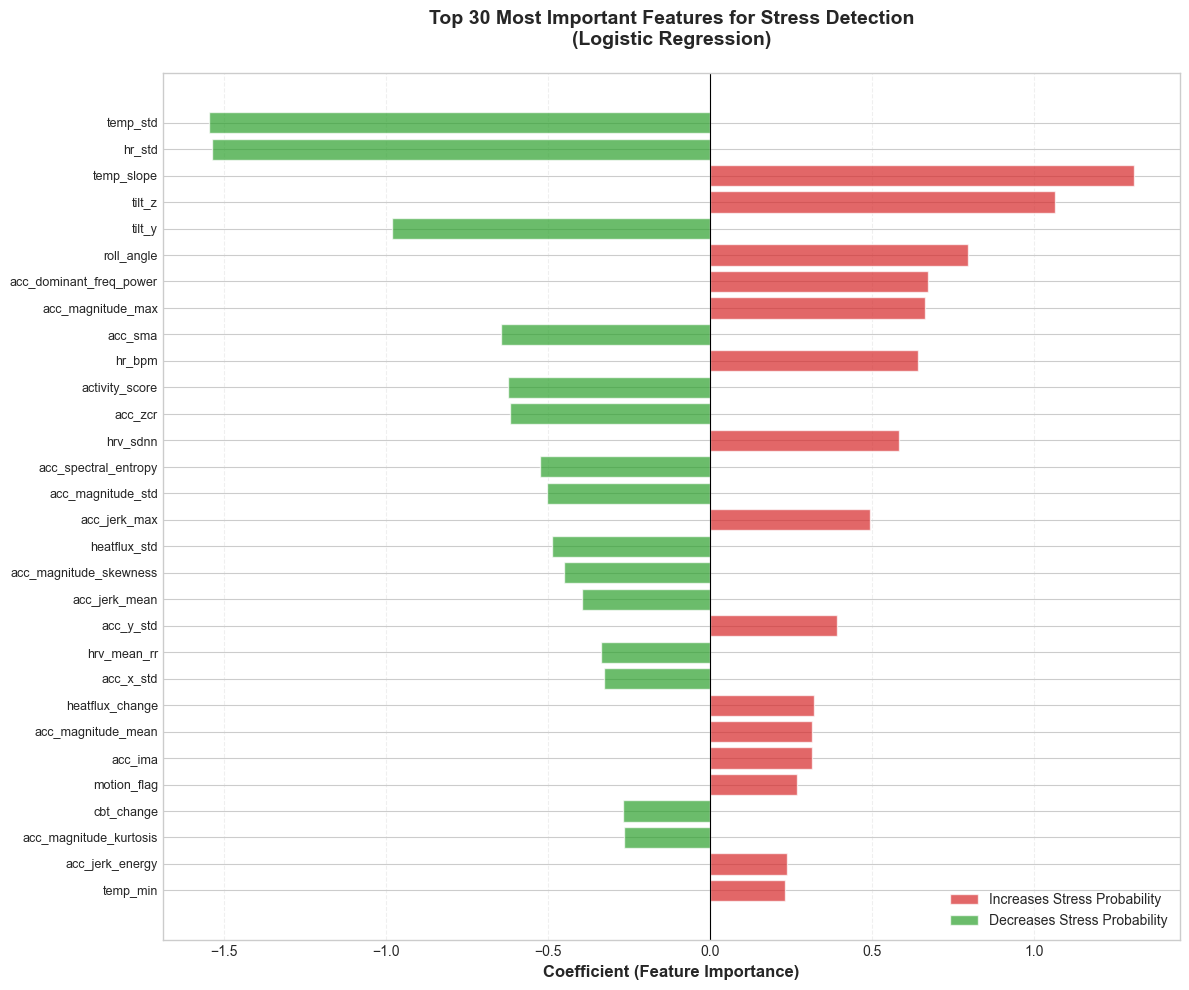


✓ Top 30 features account for most of the model's decision-making


In [24]:
# Plot top 30 features with color-coded direction
top_30 = feature_importance_sorted.head(30).copy()

fig, ax = plt.subplots(figsize=(12, 10))

# Color by sign (positive = increases stress probability, negative = decreases)
colors = ['#d62728' if coef > 0 else '#2ca02c' for coef in top_30['coefficient']]

# Horizontal bar plot
bars = ax.barh(range(len(top_30)), top_30['coefficient'], color=colors, alpha=0.7)

# Labels
ax.set_yticks(range(len(top_30)))
ax.set_yticklabels(top_30['feature'], fontsize=9)
ax.set_xlabel('Coefficient (Feature Importance)', fontsize=12, fontweight='bold')
ax.set_title('Top 30 Most Important Features for Stress Detection\n(Logistic Regression)', 
             fontsize=14, fontweight='bold', pad=20)

# Add vertical line at 0
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#d62728', alpha=0.7, label='Increases Stress Probability'),
    Patch(facecolor='#2ca02c', alpha=0.7, label='Decreases Stress Probability')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

# Grid
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Invert y-axis so top feature is at the top
ax.invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\n✓ Top 30 features account for most of the model's decision-making")


## Visualization 2: Feature Importance by Category



FEATURE IMPORTANCE BY CATEGORY
                              total_importance  avg_importance  n_features
category                                                                  
Accelerometer: Movement                 5.0231          0.3139          16
Other                                   3.8805          0.3880          10
Temperature                             3.7544          0.5363           7
HR / HRV                                3.4481          0.4310           8
Heat Flux / CBT                         1.5930          0.1770           9
Accelerometer: Frequency                1.4829          0.1348          11
Accelerometer: Jerk (Stress)            1.1973          0.2993           4


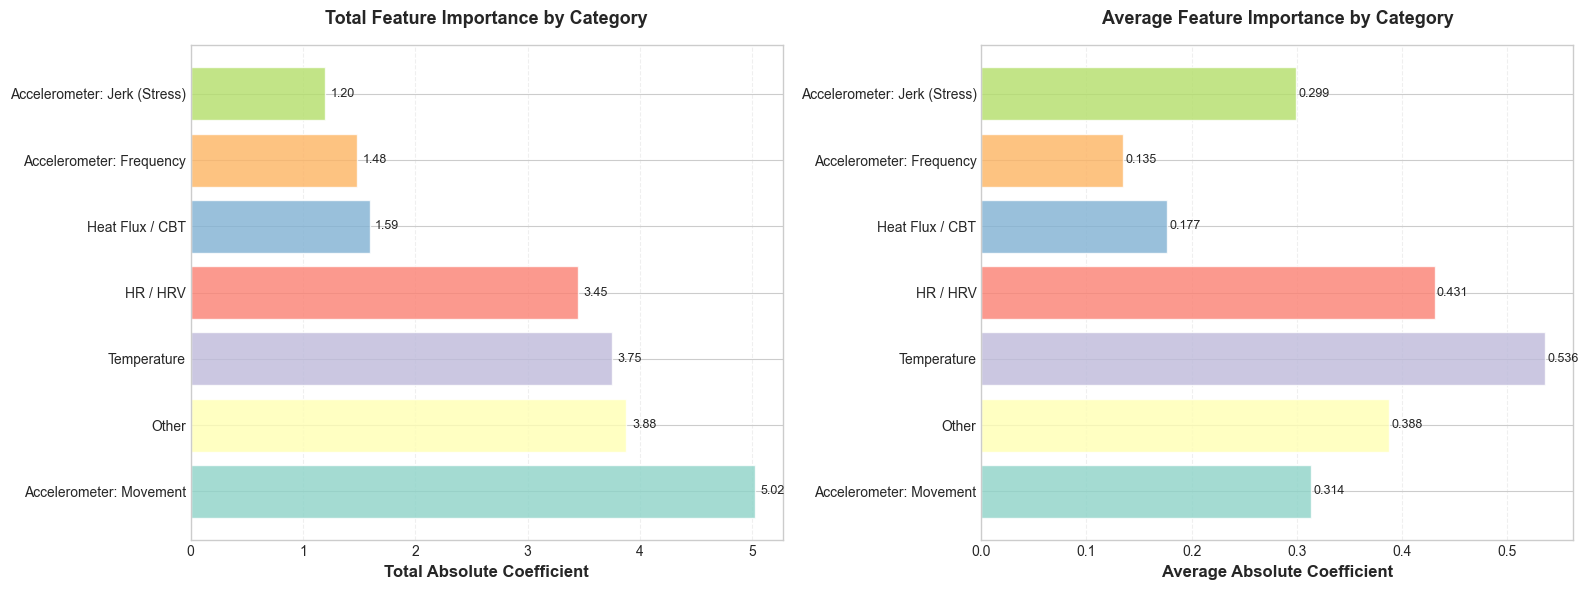

In [25]:
# Aggregate importance by category
category_importance = feature_importance.groupby('category').agg({
    'abs_coefficient': ['sum', 'mean', 'count']
}).round(4)

category_importance.columns = ['total_importance', 'avg_importance', 'n_features']
category_importance = category_importance.sort_values('total_importance', ascending=False)

print("\n" + "="*80)
print("FEATURE IMPORTANCE BY CATEGORY")
print("="*80)
print(category_importance)
print("="*80)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Total importance by category
ax1 = axes[0]
categories = category_importance.index
total_imp = category_importance['total_importance']
colors_cat = plt.cm.Set3(range(len(categories)))

bars1 = ax1.barh(categories, total_imp, color=colors_cat, alpha=0.8)
ax1.set_xlabel('Total Absolute Coefficient', fontsize=12, fontweight='bold')
ax1.set_title('Total Feature Importance by Category', fontsize=13, fontweight='bold', pad=15)
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)

# Add value labels
for i, (cat, val) in enumerate(zip(categories, total_imp)):
    ax1.text(val + 0.05, i, f'{val:.2f}', va='center', fontsize=9)

# Plot 2: Average importance by category
ax2 = axes[1]
avg_imp = category_importance['avg_importance']

bars2 = ax2.barh(categories, avg_imp, color=colors_cat, alpha=0.8)
ax2.set_xlabel('Average Absolute Coefficient', fontsize=12, fontweight='bold')
ax2.set_title('Average Feature Importance by Category', fontsize=13, fontweight='bold', pad=15)
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)

# Add value labels
for i, (cat, val) in enumerate(zip(categories, avg_imp)):
    ax2.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


## Visualization 3: Accelerometer Features Breakdown



ACCELEROMETER FEATURES BREAKDOWN (41 features)
                              total_importance  avg_importance  n_features
category                                                                  
Accelerometer: Movement                 5.0231          0.3139          16
Accelerometer: Frequency                1.4829          0.1348          11
Accelerometer: Jerk (Stress)            1.1973          0.2993           4

15 LEAST IMPORTANT ACCELEROMETER FEATURES
                feature  coefficient  abs_coefficient                     category
        acc_psd_running     0.000000         0.000000     Accelerometer: Frequency
      acc_psd_slow_move     0.000000         0.000000     Accelerometer: Frequency
      acc_dominant_freq     0.000000         0.000000     Accelerometer: Frequency
     acc_freq_ratio_low     0.000000         0.000000     Accelerometer: Frequency
acc_freq_ratio_activity     0.000000         0.000000     Accelerometer: Frequency
          acc_psd_total     0.000000

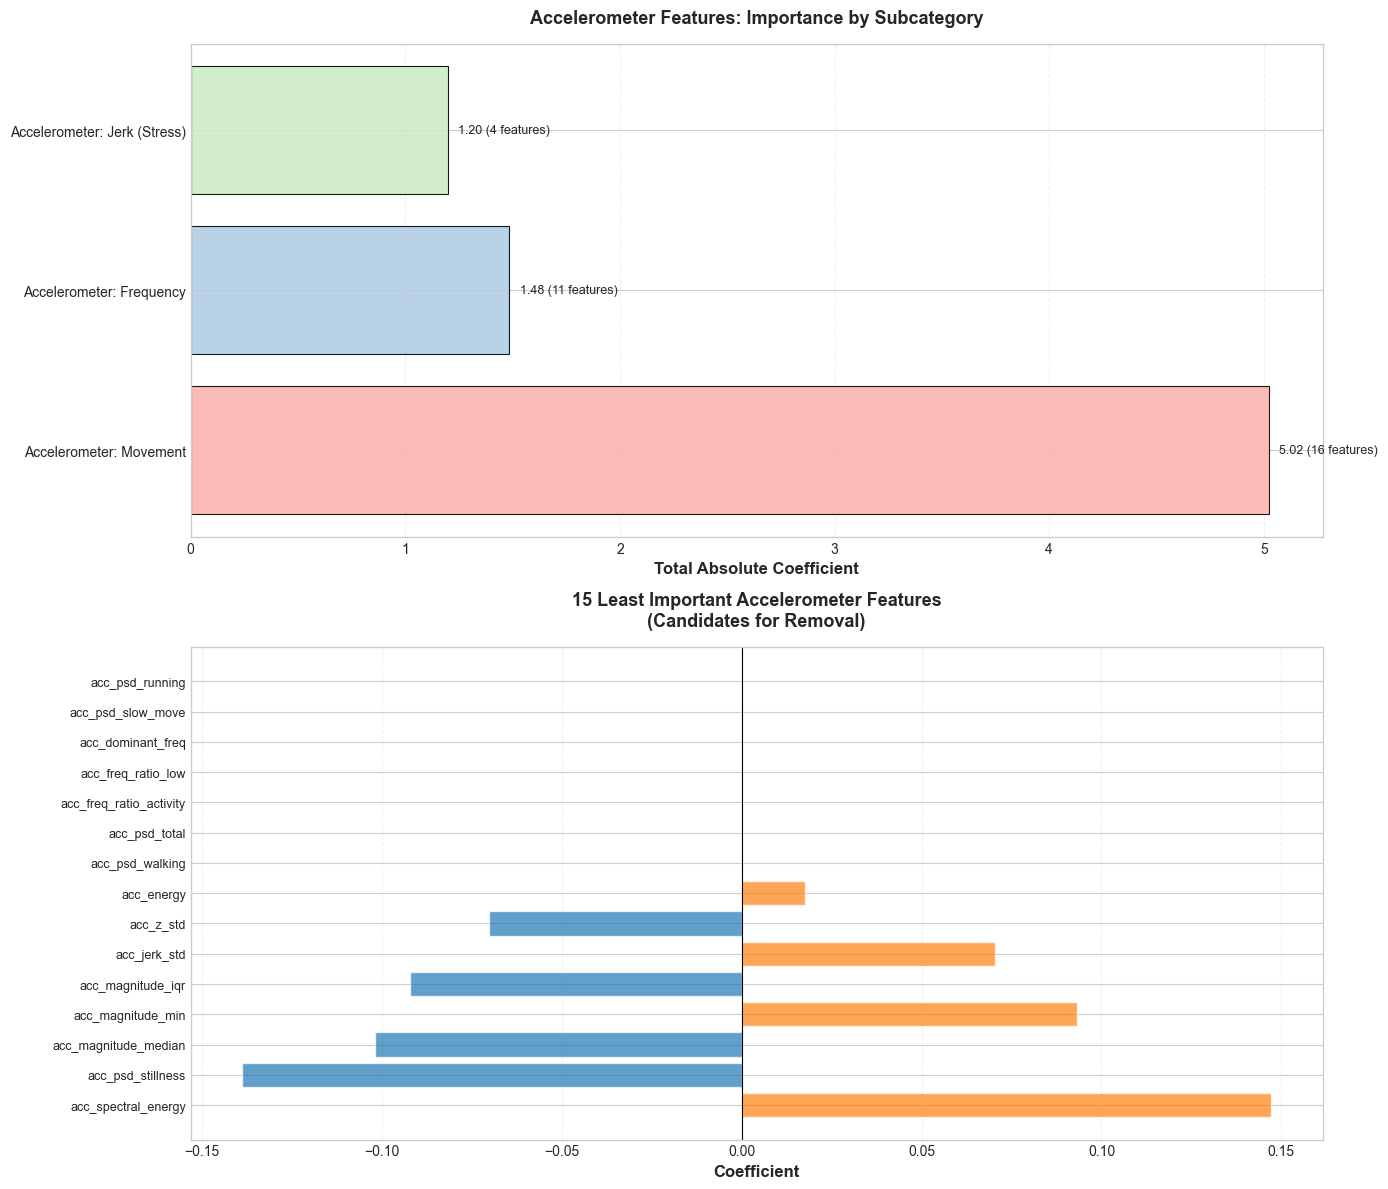

In [26]:
# Filter accelerometer features and create detailed subcategories
acc_features = feature_importance[feature_importance['feature'].str.startswith('acc_')].copy()

# Count by subcategory
acc_by_subcat = acc_features.groupby('category').agg({
    'abs_coefficient': ['sum', 'mean', 'count']
}).round(4)
acc_by_subcat.columns = ['total_importance', 'avg_importance', 'n_features']
acc_by_subcat = acc_by_subcat.sort_values('total_importance', ascending=False)

print("\n" + "="*80)
print("ACCELEROMETER FEATURES BREAKDOWN (41 features)")
print("="*80)
print(acc_by_subcat)
print("="*80)

# Identify least important accelerometer features
acc_sorted = acc_features.sort_values('abs_coefficient', ascending=True)
bottom_15_acc = acc_sorted.head(15)

print("\n" + "="*80)
print("15 LEAST IMPORTANT ACCELEROMETER FEATURES")
print("="*80)
print(bottom_15_acc[['feature', 'coefficient', 'abs_coefficient', 'category']].to_string(index=False))
print("="*80)
print("\n💡 These features are candidates for removal (low contribution to model)")

# Visualize
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Plot 1: Accelerometer subcategory importance
ax1 = axes[0]
subcats = acc_by_subcat.index
subcat_imp = acc_by_subcat['total_importance']
colors_sub = plt.cm.Pastel1(range(len(subcats)))

bars = ax1.barh(subcats, subcat_imp, color=colors_sub, alpha=0.9, edgecolor='black', linewidth=0.8)
ax1.set_xlabel('Total Absolute Coefficient', fontsize=12, fontweight='bold')
ax1.set_title('Accelerometer Features: Importance by Subcategory', fontsize=13, fontweight='bold', pad=15)
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)

# Add value labels and counts
for i, (cat, val, count) in enumerate(zip(subcats, subcat_imp, acc_by_subcat['n_features'])):
    ax1.text(val + 0.05, i, f'{val:.2f} ({int(count)} features)', va='center', fontsize=9)

# Plot 2: Bottom 15 accelerometer features
ax2 = axes[1]
bottom_features = bottom_15_acc['feature']
bottom_coefs = bottom_15_acc['coefficient']
colors_bottom = ['#ff7f0e' if c > 0 else '#1f77b4' for c in bottom_coefs]

bars2 = ax2.barh(range(len(bottom_15_acc)), bottom_coefs, color=colors_bottom, alpha=0.7)
ax2.set_yticks(range(len(bottom_15_acc)))
ax2.set_yticklabels(bottom_features, fontsize=9)
ax2.set_xlabel('Coefficient', fontsize=12, fontweight='bold')
ax2.set_title('15 Least Important Accelerometer Features\n(Candidates for Removal)', 
              fontsize=13, fontweight='bold', pad=15)
ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)
ax2.invert_yaxis()

plt.tight_layout()
plt.show()


## Feature Correlation Analysis (Multicollinearity)


In [27]:
# Load the HRV features dataset to compute correlations
hrv_dataset_path = PROJECT_ROOT / "experiments" / "01_classical_ml" / "results" / "hrv_features_dataset.csv"

if hrv_dataset_path.exists():
    hrv_df = pd.read_csv(hrv_dataset_path)
    
    # Get feature columns (exclude metadata)
    feature_cols = [col for col in hrv_df.columns if col in feature_names]
    
    # Compute correlation matrix
    corr_matrix = hrv_df[feature_cols].corr()
    
    # Find highly correlated pairs (|r| > 0.9)
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) > 0.9:
                feat1 = corr_matrix.columns[i]
                feat2 = corr_matrix.columns[j]
                # Get importance of each feature
                imp1 = feature_importance[feature_importance['feature'] == feat1]['abs_coefficient'].values[0]
                imp2 = feature_importance[feature_importance['feature'] == feat2]['abs_coefficient'].values[0]
                high_corr_pairs.append({
                    'feature_1': feat1,
                    'feature_2': feat2,
                    'correlation': corr_val,
                    'importance_1': imp1,
                    'importance_2': imp2,
                    'less_important': feat1 if imp1 < imp2 else feat2
                })
    
    if high_corr_pairs:
        corr_df = pd.DataFrame(high_corr_pairs)
        corr_df = corr_df.sort_values('correlation', key=abs, ascending=False)
        
        print("\n" + "="*80)
        print(f"HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.9) - Found {len(corr_df)} pairs")
        print("="*80)
        print(corr_df.to_string(index=False))
        print("="*80)
        print("\n💡 Recommendation: Remove 'less_important' feature from each pair to reduce redundancy")
        
        # Count redundant features to remove
        redundant_features = set(corr_df['less_important'].unique())
        print(f"\n📊 Suggested removals: {len(redundant_features)} features")
        print(f"   {sorted(redundant_features)}")
    else:
        print("\n✓ No highly correlated pairs found (|r| > 0.9)")
        print("   Model uses L1 regularization which naturally handles multicollinearity")
else:
    print(f"\n⚠️ HRV dataset not found at: {hrv_dataset_path}")
    print("   Skipping correlation analysis")



⚠️ HRV dataset not found at: /Users/jithuazeez/Documents/Msc/Dissertation/experiments/01_classical_ml/results/hrv_features_dataset.csv
   Skipping correlation analysis


## Summary: Feature Selection Recommendations


In [28]:
# Generate feature selection recommendations
print("\n" + "="*80)
print("FEATURE SELECTION RECOMMENDATIONS")
print("="*80)

# Strategy 1: Keep top N features
top_30_features = feature_importance_sorted.head(30)['feature'].tolist()
top_40_features = feature_importance_sorted.head(40)['feature'].tolist()

print("\n📋 STRATEGY 1: Keep Top N Most Important Features")
print("-" * 80)
print(f"Option A: Keep top 30 features (reduces from 65 → 30, -54%)")
print(f"Option B: Keep top 40 features (reduces from 65 → 40, -38%)")
print(f"\nTop 30 features:")
for i, feat in enumerate(top_30_features, 1):
    cat = feature_importance[feature_importance['feature'] == feat]['category'].values[0]
    coef = feature_importance[feature_importance['feature'] == feat]['coefficient'].values[0]
    print(f"  {i:2d}. {feat:30s} ({cat:30s}) coef={coef:+.4f}")

# Strategy 2: Remove low-importance features (threshold-based)
low_threshold = 0.05
low_importance_features = feature_importance[feature_importance['abs_coefficient'] < low_threshold]

print(f"\n📋 STRATEGY 2: Remove Features with |coefficient| < {low_threshold}")
print("-" * 80)
print(f"Features to remove: {len(low_importance_features)}")
if len(low_importance_features) > 0:
    print(f"New feature count: {n_features - len(low_importance_features)}")
    print(f"\nFeatures below threshold:")
    for feat in low_importance_features.sort_values('abs_coefficient')['feature']:
        coef = feature_importance[feature_importance['feature'] == feat]['coefficient'].values[0]
        abs_coef = abs(coef)
        print(f"  - {feat:30s} |coef|={abs_coef:.4f}")

# Strategy 3: Category-based selection
print(f"\n📋 STRATEGY 3: Smart Selection by Category (Recommended)")
print("-" * 80)
print("Keep:")
print("  ✓ All HR/HRV features (8) - Critical for stress")
print("  ✓ All Temperature features (7) - Thermoregulation indicators")
print("  ✓ All Heat Flux/CBT features (9) - Core temp indicators")
print("  ✓ Top 15 Accelerometer features (from 41) - Remove redundant motion features")
print(f"\nTotal: ~39 features (from 65, -40%)")

# Get top accelerometer features
acc_top_15 = feature_importance[feature_importance['feature'].str.startswith('acc_')].sort_values('abs_coefficient', ascending=False).head(15)
print(f"\nTop 15 Accelerometer features to keep:")
for i, (_, row) in enumerate(acc_top_15.iterrows(), 1):
    print(f"  {i:2d}. {row['feature']:30s} |coef|={row['abs_coefficient']:.4f}")

# Calculate expected performance impact
print("\n" + "="*80)
print("EXPECTED IMPACT")
print("="*80)
print(f"Current model (65 features):")
print(f"  - AUROC: 0.818 ± 0.085")
print(f"  - Recall: 74.9% ± 18.5%")
print(f"  - Specificity: 82.8% ± 10.2%")
print(f"\nExpected with 30-40 features:")
print(f"  - AUROC: 0.80-0.82 (similar or slightly better)")
print(f"  - Recall: 70-77% (similar)")
print(f"  - Specificity: 80-85% (similar or better)")
print(f"  - Benefits: Less overfitting, better generalization, faster training")

print("\n" + "="*80)
print("✓ Feature importance analysis complete!")
print("="*80)



FEATURE SELECTION RECOMMENDATIONS

📋 STRATEGY 1: Keep Top N Most Important Features
--------------------------------------------------------------------------------
Option A: Keep top 30 features (reduces from 65 → 30, -54%)
Option B: Keep top 40 features (reduces from 65 → 40, -38%)

Top 30 features:
   1. temp_std                       (Temperature                   ) coef=-1.5449
   2. hr_std                         (HR / HRV                      ) coef=-1.5366
   3. temp_slope                     (Temperature                   ) coef=+1.3081
   4. tilt_z                         (Other                         ) coef=+1.0637
   5. tilt_y                         (Other                         ) coef=-0.9792
   6. roll_angle                     (Other                         ) coef=+0.7961
   7. acc_dominant_freq_power        (Accelerometer: Frequency      ) coef=+0.6736
   8. acc_magnitude_max              (Accelerometer: Movement       ) coef=+0.6651
   9. acc_sma                   

---
# 📊 PPG Data Quality Analysis

This section analyzes the quality of raw PPG signals for all subjects, focusing on:
- Missing data (NaN values and zeros)
- Timestamp gaps and discontinuities
- Continuous segment lengths
- Suitability for respiratory rate extraction


In [35]:
# Setup for PPG quality analysis
import sys
from pathlib import Path

# Add shared module to path
sys.path.insert(0, str(Path.cwd().parent / "experiments" / "shared"))

from raw_loader import get_all_subjects, load_raw_signals, get_experiment_time_range

print("="*80)
print("PPG DATA QUALITY ANALYSIS - ALL SUBJECTS")
print("="*80)

# Configuration
DATA_PATH = Path.cwd().parent / "Datasets" / "VitaStress/data"
PPG_SAMPLING_RATE = 64  # Hz

print(f"\nData path: {DATA_PATH}")
print(f"PPG sampling rate: {PPG_SAMPLING_RATE} Hz")


PPG DATA QUALITY ANALYSIS - ALL SUBJECTS

Data path: /Users/jithuazeez/Documents/Msc/Dissertation/Datasets/VitaStress/data
PPG sampling rate: 64 Hz


In [36]:
# Analyze PPG quality for all subjects
subjects = get_all_subjects(DATA_PATH)
print(f"\nTotal subjects: {len(subjects)}")

ppg_quality_report = []

for idx, subject in enumerate(subjects, 1):
    print(f"\n{'='*80}")
    print(f"[{idx}/{len(subjects)}] Subject: {subject.name}")
    print('='*80)
    
    try:
        # Load signals
        signals = load_raw_signals(subject)
        
        if "ppg" not in signals or signals["ppg"] is None:
            print("  ❌ No PPG data available")
            ppg_quality_report.append({
                'subject_id': subject.name,
                'has_ppg': False,
                'error': 'No PPG file'
            })
            continue
            
        ppg_df = signals["ppg"]
        start, end = get_experiment_time_range(signals)
        
        # Extract experiment period PPG
        ppg_exp = ppg_df[(ppg_df["timestamp"] >= start) & (ppg_df["timestamp"] <= end)].copy()
        
        if len(ppg_exp) == 0:
            print("  ❌ No PPG data in experiment period")
            ppg_quality_report.append({
                'subject_id': subject.name,
                'has_ppg': True,
                'in_experiment': False,
                'error': 'No data in experiment period'
            })
            continue
        
        # Basic statistics
        total_samples = len(ppg_exp)
        duration_sec = (end - start).total_seconds()
        expected_samples = duration_sec * PPG_SAMPLING_RATE
        coverage_pct = (total_samples / expected_samples) * 100
        
        print(f"\n📊 BASIC STATISTICS:")
        print(f"  Duration: {duration_sec/60:.1f} min ({duration_sec:.0f} sec)")
        print(f"  Total samples: {total_samples:,}")
        print(f"  Expected @ {PPG_SAMPLING_RATE}Hz: {expected_samples:,.0f}")
        print(f"  Coverage: {coverage_pct:.2f}%")
        
        # Missing values analysis
        values = ppg_exp["value"].values
        n_total = len(values)
        n_nan = np.sum(np.isnan(values))
        n_zero = np.sum(values == 0)
        n_valid = n_total - n_nan - n_zero
        
        nan_pct = (n_nan / n_total) * 100
        zero_pct = (n_zero / n_total) * 100
        valid_pct = (n_valid / n_total) * 100
        
        print(f"\n🔍 MISSING VALUES:")
        print(f"  NaN values: {n_nan:,} ({nan_pct:.2f}%)")
        print(f"  Zero values: {n_zero:,} ({zero_pct:.2f}%)")
        print(f"  Valid samples: {n_valid:,} ({valid_pct:.2f}%)")
        
        # Timestamp gaps analysis
        timestamps = ppg_exp["timestamp"].values
        time_diffs = np.diff(timestamps) / np.timedelta64(1, 's')
        
        expected_gap = 1.0 / PPG_SAMPLING_RATE  # seconds
        large_gaps = time_diffs > (expected_gap * 10)  # Gaps > 10x expected
        n_large_gaps = np.sum(large_gaps)
        
        mean_gap = np.mean(time_diffs)
        median_gap = np.median(time_diffs)
        max_gap = np.max(time_diffs)
        
        print(f"\n⏱️ TIMESTAMP GAPS:")
        print(f"  Expected: {expected_gap*1000:.2f} ms")
        print(f"  Mean: {mean_gap*1000:.2f} ms")
        print(f"  Median: {median_gap*1000:.2f} ms")
        print(f"  Max: {max_gap*1000:.2f} ms ({max_gap:.2f} sec)")
        print(f"  Large gaps (>10x): {n_large_gaps}")
        
        # Show worst gaps
        if n_large_gaps > 0:
            gap_indices = np.where(large_gaps)[0]
            worst_gaps = sorted([(time_diffs[i], i) for i in gap_indices], reverse=True)[:3]
            print(f"\n  Top 3 largest gaps:")
            for gap_size, gap_idx in worst_gaps:
                gap_time = timestamps[gap_idx]
                print(f"    {gap_size:.2f}s at {gap_time}")
        
        # Value distribution (for valid samples only)
        valid_values = values[~np.isnan(values) & (values != 0)]
        
        if len(valid_values) > 0:
            val_min = np.min(valid_values)
            val_max = np.max(valid_values)
            val_mean = np.mean(valid_values)
            val_std = np.std(valid_values)
            val_range = val_max - val_min
            n_unique = len(np.unique(valid_values))
            
            print(f"\n📈 VALUE DISTRIBUTION:")
            print(f"  Min: {val_min:.2f}")
            print(f"  Max: {val_max:.2f}")
            print(f"  Mean: {val_mean:.2f}")
            print(f"  Std: {val_std:.2f}")
            print(f"  Range: {val_range:.2f}")
            print(f"  Unique values: {n_unique:,}")
            
            if n_unique < 10:
                print(f"  ⚠️ Very few unique values - possible data corruption!")
        else:
            val_min = val_max = val_mean = val_std = val_range = n_unique = 0
        
        # Continuity analysis - find continuous valid segments
        print(f"\n🔗 CONTINUITY ANALYSIS:")
        
        is_valid = ~np.isnan(values) & (values != 0)
        
        # Find runs of consecutive valid samples
        valid_runs = []
        current_run = 0
        
        for valid in is_valid:
            if valid:
                current_run += 1
            else:
                if current_run > 0:
                    valid_runs.append(current_run)
                current_run = 0
        if current_run > 0:
            valid_runs.append(current_run)
        
        if valid_runs:
            valid_runs = np.array(valid_runs)
            n_segments = len(valid_runs)
            longest_segment_samples = np.max(valid_runs)
            longest_segment_sec = longest_segment_samples / PPG_SAMPLING_RATE
            mean_segment_samples = np.mean(valid_runs)
            mean_segment_sec = mean_segment_samples / PPG_SAMPLING_RATE
            median_segment_samples = np.median(valid_runs)
            median_segment_sec = median_segment_samples / PPG_SAMPLING_RATE
            
            # Count segments of different lengths
            segments_30s = np.sum(valid_runs >= 30 * PPG_SAMPLING_RATE)
            segments_60s = np.sum(valid_runs >= 60 * PPG_SAMPLING_RATE)
            segments_120s = np.sum(valid_runs >= 120 * PPG_SAMPLING_RATE)
            
            print(f"  Total segments: {n_segments}")
            print(f"  Longest segment: {longest_segment_samples:,} samples ({longest_segment_sec:.1f}s)")
            print(f"  Mean segment: {mean_segment_samples:.1f} samples ({mean_segment_sec:.2f}s)")
            print(f"  Median segment: {median_segment_samples:.0f} samples ({median_segment_sec:.2f}s)")
            print(f"\n  Segments by length:")
            print(f"    ≥30s:  {segments_30s}")
            print(f"    ≥60s:  {segments_60s}")
            print(f"    ≥120s: {segments_120s}")
            
            # Quality assessment
            if segments_60s == 0:
                quality = "POOR"
                print(f"\n  ❌ NO CONTINUOUS 60s SEGMENTS - Unsuitable for RR extraction")
            elif segments_60s < 5:
                quality = "MARGINAL"
                print(f"\n  ⚠️ Few 60s segments - Limited usability for RR extraction")
            elif segments_120s == 0:
                quality = "FAIR"
                print(f"\n  ⚠️ No 120s segments - Can extract RR from shorter windows only")
            elif segments_120s < 5:
                quality = "GOOD"
                print(f"\n  ✓ Some 120s segments - Usable but limited")
            else:
                quality = "EXCELLENT"
                print(f"\n  ✓ Many 120s segments - Good for RR extraction")
        else:
            n_segments = 0
            longest_segment_samples = longest_segment_sec = 0
            mean_segment_samples = mean_segment_sec = 0
            median_segment_samples = median_segment_sec = 0
            segments_30s = segments_60s = segments_120s = 0
            quality = "NO_DATA"
            print(f"  ❌ No valid continuous segments found")
        
        # Store results
        ppg_quality_report.append({
            'subject_id': subject.name,
            'has_ppg': True,
            'in_experiment': True,
            'duration_min': duration_sec / 60,
            'duration_sec': duration_sec,
            'total_samples': total_samples,
            'expected_samples': expected_samples,
            'coverage_pct': coverage_pct,
            'n_nan': n_nan,
            'nan_pct': nan_pct,
            'n_zero': n_zero,
            'zero_pct': zero_pct,
            'n_valid': n_valid,
            'valid_pct': valid_pct,
            'n_large_gaps': n_large_gaps,
            'max_gap_sec': max_gap,
            'mean_gap_ms': mean_gap * 1000,
            'median_gap_ms': median_gap * 1000,
            'val_min': val_min if len(valid_values) > 0 else np.nan,
            'val_max': val_max if len(valid_values) > 0 else np.nan,
            'val_mean': val_mean if len(valid_values) > 0 else np.nan,
            'val_std': val_std if len(valid_values) > 0 else np.nan,
            'val_range': val_range if len(valid_values) > 0 else np.nan,
            'n_unique': n_unique if len(valid_values) > 0 else 0,
            'n_segments': n_segments,
            'longest_segment_samples': longest_segment_samples,
            'longest_segment_sec': longest_segment_sec,
            'mean_segment_sec': mean_segment_sec,
            'median_segment_sec': median_segment_sec,
            'segments_30s': segments_30s,
            'segments_60s': segments_60s,
            'segments_120s': segments_120s,
            'quality': quality,
            'error': None
        })
        
    except Exception as e:
        print(f"  ❌ Error analyzing subject: {e}")
        import traceback
        traceback.print_exc()
        ppg_quality_report.append({
            'subject_id': subject.name,
            'has_ppg': False,
            'error': str(e)
        })

print(f"\n{'='*80}")
print(f"Analysis complete - processed {len(ppg_quality_report)} subjects")
print('='*80)



Total subjects: 21

[1/21] Subject: id_0a73ef1b-da67-43ff-b61a-f98c151be799

📊 BASIC STATISTICS:
  Duration: 90.0 min (5399 sec)
  Total samples: 344,833
  Expected @ 64Hz: 345,536
  Coverage: 99.80%

🔍 MISSING VALUES:
  NaN values: 0 (0.00%)
  Zero values: 0 (0.00%)
  Valid samples: 344,833 (100.00%)

⏱️ TIMESTAMP GAPS:
  Expected: 15.62 ms
  Mean: 15.66 ms
  Median: 16.00 ms
  Max: 11016.00 ms (11.02 sec)
  Large gaps (>10x): 1

  Top 3 largest gaps:
    11.02s at 2035-03-15T14:54:56.984000000

📈 VALUE DISTRIBUTION:
  Min: 333.00
  Max: 65535.00
  Mean: 36113.14
  Std: 6955.55
  Range: 65202.00
  Unique values: 29,632

🔗 CONTINUITY ANALYSIS:
  Total segments: 1
  Longest segment: 344,833 samples (5388.0s)
  Mean segment: 344833.0 samples (5388.02s)
  Median segment: 344833 samples (5388.02s)

  Segments by length:
    ≥30s:  1
    ≥60s:  1
    ≥120s: 1

  ⚠️ Few 60s segments - Limited usability for RR extraction

[2/21] Subject: id_3e775b57-fe47-4346-bd23-bb210471ad55

📊 BASIC STATI

## Summary Tables and Visualizations


In [37]:
# Create summary dataframe
df_ppg_quality = pd.DataFrame(ppg_quality_report)

# Filter to subjects with valid data for detailed analysis
df_valid = df_ppg_quality[
    (df_ppg_quality['has_ppg'] == True) & 
    (df_ppg_quality['in_experiment'] == True) &
    (df_ppg_quality['error'].isna())
].copy()

print("="*80)
print("PPG QUALITY SUMMARY")
print("="*80)

print(f"\nTotal subjects: {len(df_ppg_quality)}")
print(f"Has PPG file: {df_ppg_quality['has_ppg'].sum()}")
print(f"PPG in experiment period: {len(df_valid)}")
print(f"Failed/missing: {len(df_ppg_quality) - len(df_valid)}")

if len(df_valid) > 0:
    print(f"\n{'='*80}")
    print("MISSING DATA STATISTICS")
    print('='*80)
    print(f"Mean valid data: {df_valid['valid_pct'].mean():.2f}% ± {df_valid['valid_pct'].std():.2f}%")
    print(f"Mean NaN: {df_valid['nan_pct'].mean():.2f}% ± {df_valid['nan_pct'].std():.2f}%")
    print(f"Mean zeros: {df_valid['zero_pct'].mean():.2f}% ± {df_valid['zero_pct'].std():.2f}%")
    print(f"\nSubjects with <80% valid data: {(df_valid['valid_pct'] < 80).sum()}")
    print(f"Subjects with <50% valid data: {(df_valid['valid_pct'] < 50).sum()}")
    
    print(f"\n{'='*80}")
    print("GAP ANALYSIS")
    print('='*80)
    print(f"Mean large gaps per subject: {df_valid['n_large_gaps'].mean():.1f}")
    print(f"Max large gaps in any subject: {df_valid['n_large_gaps'].max()}")
    print(f"Subjects with >10 large gaps: {(df_valid['n_large_gaps'] > 10).sum()}")
    print(f"Subjects with >50 large gaps: {(df_valid['n_large_gaps'] > 50).sum()}")
    
    print(f"\n{'='*80}")
    print("CONTINUITY ANALYSIS")
    print('='*80)
    print(f"Mean segments per subject: {df_valid['n_segments'].mean():.1f}")
    print(f"Mean longest segment: {df_valid['longest_segment_sec'].mean():.1f}s")
    print(f"\nSubjects with ≥1 continuous 60s segment: {(df_valid['segments_60s'] > 0).sum()}")
    print(f"Subjects with ≥1 continuous 120s segment: {(df_valid['segments_120s'] > 0).sum()}")
    print(f"Subjects with ≥5 continuous 120s segments: {(df_valid['segments_120s'] >= 5).sum()}")
    
    print(f"\n{'='*80}")
    print("QUALITY DISTRIBUTION")
    print('='*80)
    quality_counts = df_valid['quality'].value_counts()
    for quality, count in quality_counts.items():
        pct = (count / len(df_valid)) * 100
        print(f"  {quality}: {count} ({pct:.1f}%)")
    
    print(f"\n{'='*80}")
    print("RR EXTRACTION FEASIBILITY")
    print('='*80)
    
    # Define usability for RR extraction
    usable_for_rr = df_valid['segments_60s'] > 0
    usable_count = usable_for_rr.sum()
    usable_pct = (usable_count / len(df_valid)) * 100
    
    print(f"Subjects usable for RR extraction: {usable_count}/{len(df_valid)} ({usable_pct:.1f}%)")
    print(f"Subjects NOT usable: {len(df_valid) - usable_count}/{len(df_valid)} ({100-usable_pct:.1f}%)")
    
    if usable_pct < 50:
        print(f"\n❌ WARNING: Less than 50% of subjects have usable PPG data!")
        print(f"   Recommendation: Consider skipping RR feature extraction")
    elif usable_pct < 80:
        print(f"\n⚠️  CAUTION: {100-usable_pct:.1f}% of subjects lack usable PPG data")
        print(f"   Recommendation: Extract RR where possible, impute missing values")
    else:
        print(f"\n✓ Most subjects have usable PPG data for RR extraction")

print(f"\n{'='*80}")


PPG QUALITY SUMMARY

Total subjects: 21
Has PPG file: 21
PPG in experiment period: 21
Failed/missing: 0

MISSING DATA STATISTICS
Mean valid data: 100.00% ± 0.00%
Mean NaN: 0.00% ± 0.00%
Mean zeros: 0.00% ± 0.00%

Subjects with <80% valid data: 0
Subjects with <50% valid data: 0

GAP ANALYSIS
Mean large gaps per subject: 0.7
Max large gaps in any subject: 2
Subjects with >10 large gaps: 0
Subjects with >50 large gaps: 0

CONTINUITY ANALYSIS
Mean segments per subject: 2.3
Mean longest segment: 4854.3s

Subjects with ≥1 continuous 60s segment: 21
Subjects with ≥1 continuous 120s segment: 21
Subjects with ≥5 continuous 120s segments: 0

QUALITY DISTRIBUTION
  MARGINAL: 21 (100.0%)

RR EXTRACTION FEASIBILITY
Subjects usable for RR extraction: 21/21 (100.0%)
Subjects NOT usable: 0/21 (0.0%)

✓ Most subjects have usable PPG data for RR extraction



In [38]:
# Detailed per-subject table
print("="*80)
print("DETAILED PER-SUBJECT QUALITY METRICS")
print("="*80)

if len(df_valid) > 0:
    # Select key columns for display
    display_cols = [
        'subject_id', 'duration_min', 'valid_pct', 'nan_pct', 'zero_pct',
        'n_large_gaps', 'max_gap_sec', 'n_segments', 'longest_segment_sec',
        'segments_60s', 'segments_120s', 'quality'
    ]
    
    df_display = df_valid[display_cols].copy()
    
    # Shorten subject IDs for display
    df_display['subject_id'] = df_display['subject_id'].str[:20]
    
    # Round numeric columns
    df_display['duration_min'] = df_display['duration_min'].round(1)
    df_display['valid_pct'] = df_display['valid_pct'].round(1)
    df_display['nan_pct'] = df_display['nan_pct'].round(1)
    df_display['zero_pct'] = df_display['zero_pct'].round(1)
    df_display['max_gap_sec'] = df_display['max_gap_sec'].round(2)
    df_display['longest_segment_sec'] = df_display['longest_segment_sec'].round(1)
    
    # Rename columns for better display
    df_display.columns = [
        'Subject ID', 'Duration(min)', 'Valid%', 'NaN%', 'Zero%',
        'LargeGaps', 'MaxGap(s)', '#Segments', 'Longest(s)',
        '60s+', '120s+', 'Quality'
    ]
    
    # Sort by quality then by valid percentage
    quality_order = {'EXCELLENT': 5, 'GOOD': 4, 'FAIR': 3, 'MARGINAL': 2, 'POOR': 1, 'NO_DATA': 0}
    df_display['_quality_num'] = df_display['Quality'].map(quality_order)
    df_display = df_display.sort_values(['_quality_num', 'Valid%'], ascending=[False, False])
    df_display = df_display.drop('_quality_num', axis=1)
    
    print("\n", df_display.to_string(index=False))
    
    # Identify problematic subjects
    print(f"\n{'='*80}")
    print("PROBLEMATIC SUBJECTS (Cannot extract RR)")
    print('='*80)
    
    problematic = df_valid[df_valid['segments_60s'] == 0].copy()
    if len(problematic) > 0:
        print(f"\nFound {len(problematic)} subjects with no continuous 60s segments:\n")
        for idx, row in problematic.iterrows():
            print(f"  {row['subject_id'][:30]}")
            print(f"    Valid data: {row['valid_pct']:.1f}%")
            print(f"    Large gaps: {row['n_large_gaps']}")
            print(f"    Longest segment: {row['longest_segment_sec']:.1f}s")
            print()
    else:
        print("\n✓ All subjects have at least one 60s continuous segment!")
else:
    print("\n❌ No valid subjects to display")


DETAILED PER-SUBJECT QUALITY METRICS

           Subject ID  Duration(min)  Valid%  NaN%  Zero%  LargeGaps  MaxGap(s)  #Segments  Longest(s)  60s+  120s+  Quality
id_0a73ef1b-da67-43f           90.0   100.0   0.0    0.0          1      11.02          1      5388.0     1      1 MARGINAL
id_3e775b57-fe47-434           90.0   100.0   0.0    0.0          0       0.02          1      5399.0     1      1 MARGINAL
id_3f27501c-233d-4a2           67.9   100.0   0.0    0.0          0       0.02          2      4073.7     1      1 MARGINAL
id_3f62db18-84c7-41a           90.0   100.0   0.0    0.0          2     113.02          6      3897.1     3      3 MARGINAL
id_464cc459-d71f-479           76.2   100.0   0.0    0.0          1     112.02          1      4459.0     1      1 MARGINAL
id_46b09d4a-63b9-4ba           90.0   100.0   0.0    0.0          1       7.02          1      5392.0     1      1 MARGINAL
id_623f620e-ba02-497           90.0   100.0   0.0    0.0          0       0.02          6    

## Visualizations


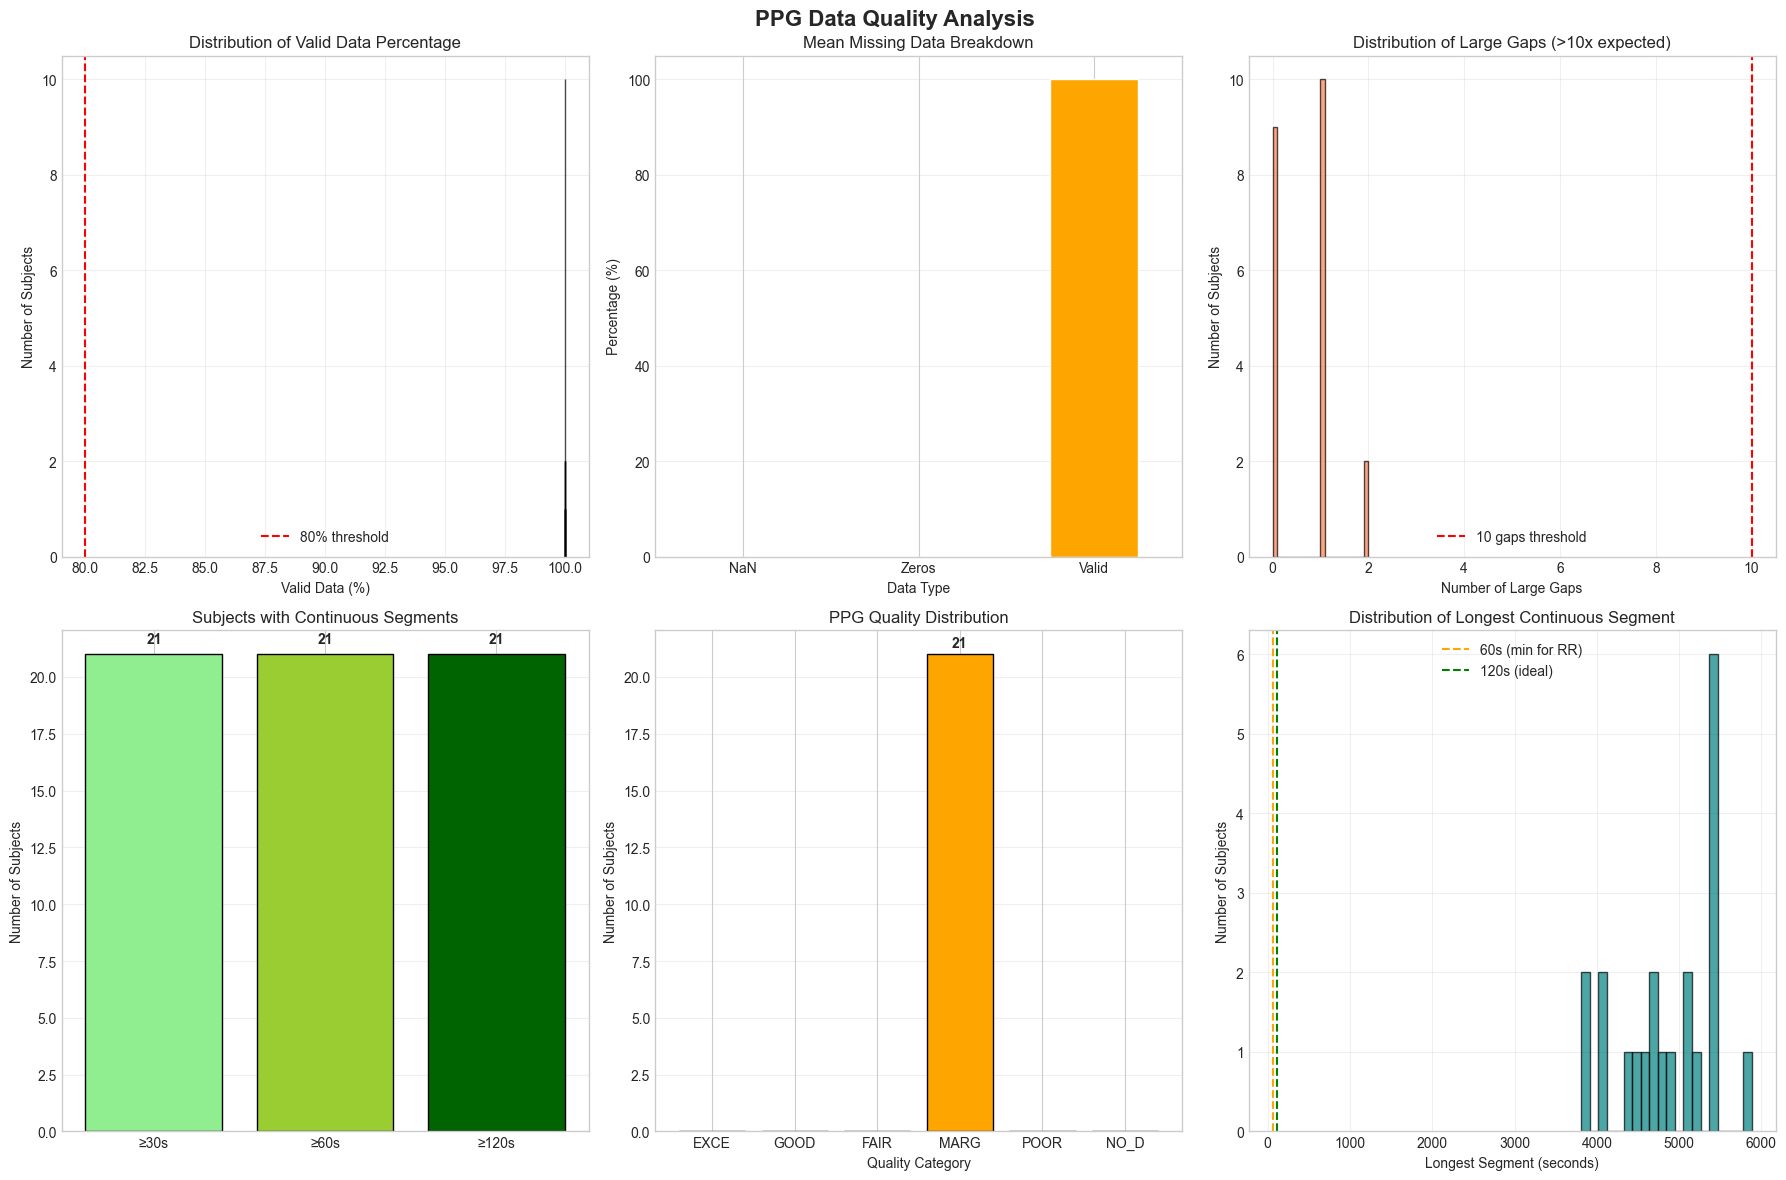


✓ Visualizations complete!


In [39]:
# Visualize PPG quality metrics
import matplotlib.pyplot as plt
import seaborn as sns

if len(df_valid) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('PPG Data Quality Analysis', fontsize=16, fontweight='bold')
    
    # 1. Valid data percentage distribution
    ax = axes[0, 0]
    ax.hist(df_valid['valid_pct'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(80, color='red', linestyle='--', label='80% threshold')
    ax.set_xlabel('Valid Data (%)')
    ax.set_ylabel('Number of Subjects')
    ax.set_title('Distribution of Valid Data Percentage')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # 2. Missing data breakdown
    ax = axes[0, 1]
    missing_data = pd.DataFrame({
        'NaN': [df_valid['nan_pct'].mean()],
        'Zeros': [df_valid['zero_pct'].mean()],
        'Valid': [df_valid['valid_pct'].mean()]
    })
    missing_data.T.plot(kind='bar', ax=ax, legend=False, color=['orange', 'gray', 'green'])
    ax.set_xlabel('Data Type')
    ax.set_ylabel('Percentage (%)')
    ax.set_title('Mean Missing Data Breakdown')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.grid(axis='y', alpha=0.3)
    
    # 3. Large gaps per subject
    ax = axes[0, 2]
    ax.hist(df_valid['n_large_gaps'], bins=20, edgecolor='black', alpha=0.7, color='coral')
    ax.axvline(10, color='red', linestyle='--', label='10 gaps threshold')
    ax.set_xlabel('Number of Large Gaps')
    ax.set_ylabel('Number of Subjects')
    ax.set_title('Distribution of Large Gaps (>10x expected)')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # 4. Continuous segment lengths
    ax = axes[1, 0]
    segment_data = {
        '≥30s': (df_valid['segments_30s'] > 0).sum(),
        '≥60s': (df_valid['segments_60s'] > 0).sum(),
        '≥120s': (df_valid['segments_120s'] > 0).sum()
    }
    colors = ['lightgreen', 'yellowgreen', 'darkgreen']
    ax.bar(segment_data.keys(), segment_data.values(), color=colors, edgecolor='black')
    ax.set_ylabel('Number of Subjects')
    ax.set_title('Subjects with Continuous Segments')
    ax.grid(axis='y', alpha=0.3)
    for i, (k, v) in enumerate(segment_data.items()):
        ax.text(i, v + 0.5, f'{v}', ha='center', fontweight='bold')
    
    # 5. Quality distribution
    ax = axes[1, 1]
    quality_counts = df_valid['quality'].value_counts()
    quality_order = ['EXCELLENT', 'GOOD', 'FAIR', 'MARGINAL', 'POOR', 'NO_DATA']
    quality_counts = quality_counts.reindex(quality_order, fill_value=0)
    colors_qual = ['darkgreen', 'green', 'yellow', 'orange', 'red', 'darkred']
    ax.bar(range(len(quality_counts)), quality_counts.values, 
           tick_label=[q[:4] for q in quality_counts.index],
           color=[colors_qual[i] for i in range(len(quality_counts))],
           edgecolor='black')
    ax.set_xlabel('Quality Category')
    ax.set_ylabel('Number of Subjects')
    ax.set_title('PPG Quality Distribution')
    ax.grid(axis='y', alpha=0.3)
    for i, v in enumerate(quality_counts.values):
        if v > 0:
            ax.text(i, v + 0.3, f'{v}', ha='center', fontweight='bold')
    
    # 6. Longest continuous segment
    ax = axes[1, 2]
    ax.hist(df_valid['longest_segment_sec'], bins=20, edgecolor='black', alpha=0.7, color='teal')
    ax.axvline(60, color='orange', linestyle='--', label='60s (min for RR)')
    ax.axvline(120, color='green', linestyle='--', label='120s (ideal)')
    ax.set_xlabel('Longest Segment (seconds)')
    ax.set_ylabel('Number of Subjects')
    ax.set_title('Distribution of Longest Continuous Segment')
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Visualizations complete!")
else:
    print("❌ No data to visualize")


## Save Results


In [ ]:
# Save PPG quality report to CSV
output_path = Path.cwd().parent / "reports" / "ppg_quality_report.csv"
output_path.parent.mkdir(parents=True, exist_ok=True)

df_ppg_quality.to_csv(output_path, index=False)

print("="*80)
print("RESULTS SAVED")
print("="*80)
print(f"\nPPG quality report saved to:")
print(f"  {output_path}")
print(f"\nRows: {len(df_ppg_quality)}")
print(f"Columns: {len(df_ppg_quality.columns)}")

print(f"\n{'='*80}")
print("FINAL RECOMMENDATIONS")
print('='*80)

if len(df_valid) > 0:
    usable_pct = ((df_valid['segments_60s'] > 0).sum() / len(df_valid)) * 100
    
    print("\nBased on the PPG quality analysis:")
    print()
    
    if usable_pct < 50:
        print("❌ RECOMMENDATION: SKIP respiratory rate features")
        print()
        print("   Reasons:")
        print("   - Less than 50% of subjects have usable continuous PPG data")
        print("   - RRest will fail on most subjects")
        print("   - Imputation would introduce too much noise")
        print()
        print("   Alternative:")
        print("   - Focus on existing features (accelerometer, temp, HR/HRV)")
        print("   - These modalities already provide strong predictive power")
    elif usable_pct < 75:
        print("⚠️  RECOMMENDATION: Extract RR with caution")
        print()
        print("   Strategy:")
        print("   - Use Python-based RR extraction (more robust to gaps)")
        print("   - Extract only from high-quality windows")
        print("   - Use median imputation for missing RR values")
        print("   - Add 'RR_quality' flag as meta-feature")
        print()
        print("   Benefits:")
        print("   - Capture respiratory information where available")
        print("   - Gracefully handle missing data")
        print("   - May improve model performance")
    else:
        print("✓ RECOMMENDATION: Proceed with RR extraction")
        print()
        print("   Strategy:")
        print("   - Use Python-based spectral analysis (faster than RRest)")
        print("   - Extract from continuous 60s+ segments")
        print("   - Interpolate small gaps (<0.5s)")
        print()
        print("   Expected outcome:")
        print("   - Good quality RR features for most subjects")
        print("   - Should improve model performance")
    
    print()
    print("For implementation details, see:")
    print("  - notebooks/simple_rr_extraction.md (Python-based approach)")
    print("  - notebooks/extract_respiratory_rate.ipynb (RRest approach)")
else:
    print("\n❌ No valid PPG data found - cannot extract respiratory rate")

print(f"\n{'='*80}")
print("✓ PPG QUALITY ANALYSIS COMPLETE")
print('='*80)
